# Global Retail Sales Price Prediction

**PROJECT TITLE :** Predictive Sales Insights - Anticipating Retail  Market  Analysis

# Model Performance:
* **Model Accuracy**:
  * Random Forest           :    **0.99**
  * Gradient Boosting       :    **0.99**
  * Decision Tree           :    **0.99**
  * Bagging Regressor       :    **0.99**
  * Extra Tree Regressor    :    **0.99**
  * XGBoost                 :    **0.99**
  * Adaptive Boosting       :    **0.92**
  * K-Nearest Neighbour     :    **0.90**
  * Linear Regression       :    **0.82**
  * Support Vector Machine  :    **0.60**


  

* **Steps to Build this Assigment :**
  1. Import the Necessary Libraries
  2. Read the Dataset
  3. Data Exploration
  4. Handling Missing Values
  5. Exploratory Data Analysis
      * Univariate Analysis
      * Bivariate Analysis
      * Multivariate Analysis
  6. Feature Engineering
      * Feature Encoding
  7. Train Test Split
  8. Feature Scaling
  9. Model Building :
      * Logistic Regression
      * Random Forest - Random Forest Regressor
      * Support Vector Machine(SVM) - Support Vector Regressor(SVR)
      * K-Nearest Neighbor - KNeighbor Regressor
      * Decision Tree - Decision Tree Regressor
      * Boosting Algorithms:
          * Gradient Boosting - Gradient Boost Regressor
          * Adaptive Boosting - AdaBoost Regressor
          * XGBoost - XGBoost Regressor
      * Bagging Regressor
      * Extra Tree Regressor
  10. Model Evaluation :
      * R2 Score
      * Mean Absolute Error
      * Mean Squared Error
      * Explained Variance Error
      * Median Absolute Error
      * Root Mean Square Error
  11. Model Deployment Using Streamlit

## Import the Necessary Libraries

Import all the Required Libraries for the Dataset

In [ ]:
# load the libraries
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

## Read the CSV File

This is to read the Dataset.This Dataset is a **Comma-Separated Values(CSV) File** so we use **pd.read_csv()**.

In [ ]:
# read a csv file
df = pd.read_csv('/content/merch_sales.csv')
df.head()

,Order ID,Order Date,Product ID,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Review
0,189440,2024-07-21,BF1543,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,The delivery team handled the product with care.
1,187385,2024-07-20,BF1543,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,Had slight delays but the product was in good ...
2,181844,2024-07-21,BF1544,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,Waste of Money.
3,197934,2024-08-19,BF1544,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,Had slight delays but the product was in good ...
4,122470,2024-01-06,BF1545,Other,Female,19,Miami,No,10,0,10,3,30,5,Lack of delivery delays is greatly appreciated.


## Data Exploration

**Data Exploration** gives a **clear understanding about the Overall Dataset.** This deals with analysing the **Overall Insights** and the **Statistical Insights** about the Dataset.

In [ ]:
# get the rows and columns
df.shape

(7394, 15)

In [ ]:
# Analyse the Overall Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7394 entries, 0 to 7393
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                7394 non-null   int64 
 1   Order Date              7394 non-null   object
 2   Product ID              7394 non-null   object
 3   Product Category        7394 non-null   object
 4   Buyer Gender            7394 non-null   object
 5   Buyer Age               7394 non-null   int64 
 6   Order Location          7394 non-null   object
 7   International Shipping  7394 non-null   object
 8   Sales Price             7394 non-null   int64 
 9   Shipping Charges        7394 non-null   int64 
 10  Sales per Unit          7394 non-null   int64 
 11  Quantity                7394 non-null   int64 
 12  Total Sales             7394 non-null   int64 
 13  Rating                  7394 non-null   int64 
 14  Review                  7394 non-null   object
dtypes: i

In [ ]:
# Analyse the Statistical Description
df.describe()

,Order ID,Buyer Age,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating
count,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000
mean,159735.134028,26.455504,55.165404,14.633487,69.798891,1.668109,115.832026,3.499053
std,23040.247194,5.208202,39.575614,24.815719,46.702326,1.081398,118.067960,1.389731
min,120005.000000,18.000000,9.000000,0.000000,9.000000,1.000000,9.000000,1.000000
25%,139895.750000,22.000000,15.000000,0.000000,20.000000,1.000000,40.000000,3.000000
50%,159577.500000,26.000000,65.000000,0.000000,65.000000,1.000000,90.000000,4.000000
75%,179869.750000,31.000000,97.000000,40.000000,100.000000,2.000000,137.000000,5.000000
max,199994.000000,35.000000,130.000000,100.000000,230.000000,5.000000,1000.000000,5.000000


In [ ]:
# Analyse the Statistical Description with transpose()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Order ID,7394.0,159735.134028,23040.247194,120005.0,139895.75,159577.5,179869.75,199994.0
Buyer Age,7394.0,26.455504,5.208202,18.0,22.00,26.0,31.00,35.0
Sales Price,7394.0,55.165404,39.575614,9.0,15.00,65.0,97.00,130.0
Shipping Charges,7394.0,14.633487,24.815719,0.0,0.00,0.0,40.00,100.0
Sales per Unit,7394.0,69.798891,46.702326,9.0,20.00,65.0,100.00,230.0
Quantity,7394.0,1.668109,1.081398,1.0,1.00,1.0,2.00,5.0
Total Sales,7394.0,115.832026,118.067960,9.0,40.00,90.0,137.00,1000.0
Rating,7394.0,3.499053,1.389731,1.0,3.00,4.0,5.00,5.0


In [ ]:
# get all the column names
df.columns

Index(['Order ID', 'Order Date', 'Product ID', 'Product Category',
       'Buyer Gender', 'Buyer Age', 'Order Location', 'International Shipping',
       'Sales Price', 'Shipping Charges', 'Sales per Unit', 'Quantity',
       'Total Sales', 'Rating', 'Review'],
      dtype='object')

In [ ]:
# get all categorical columns
df.select_dtypes(include='object').columns

Index(['Order Date', 'Product ID', 'Product Category', 'Buyer Gender',
       'Order Location', 'International Shipping', 'Review'],
      dtype='object')

In [ ]:
# get all numerical columns
df.select_dtypes(include='number').columns

Index(['Order ID', 'Buyer Age', 'Sales Price', 'Shipping Charges',
       'Sales per Unit', 'Quantity', 'Total Sales', 'Rating'],
      dtype='object')

## Handling Missing Values

This is where the **Data cleaning Process** comes into play. This is a very **Core Concept** this deals with having a **Good Understanding** about the Dataset and **Good Domain Knowledge.**If the **Data is not Cleaned** it might **affect** the **Overall Model Performance.**

In [ ]:
# check for missing values
df.isnull().sum()

,0
Order ID,0
Order Date,0
Product ID,0
Product Category,0
Buyer Gender,0
Buyer Age,0
Order Location,0
International Shipping,0
Sales Price,0
Shipping Charges,0


In [ ]:
# check for missing values
df.isnull().sum().any()

False

## Drop Unnecessary Columns

In [ ]:
# drop all the unnecessary columns
df = df.drop(['Order ID','Product ID','Review'],axis=1)
df.head()

,Order Date,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating
0,2024-07-21,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4
1,2024-07-20,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3
2,2024-07-21,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2
3,2024-08-19,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3
4,2024-01-06,Other,Female,19,Miami,No,10,0,10,3,30,5


## Extract Insights from DateTime Columns

**DateTime Columns** gives use some **Meaningful Insights** but **cannot be used directly** so **we use** a **Feature Engineering Method of Extracting Information** to make the **DateTime values look more meaningful.**

In [ ]:
# extract the day,month and year from the Order_Date
df['Year'] = pd.DatetimeIndex(df['Order Date']).year
df['Month'] = pd.DatetimeIndex(df['Order Date']).month
df['Day'] = pd.DatetimeIndex(df['Order Date']).day
df.head()

,Order Date,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
0,2024-07-21,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,2024,7,21
1,2024-07-20,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,2024,7,20
2,2024-07-21,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,2024,7,21
3,2024-08-19,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,2024,8,19
4,2024-01-06,Other,Female,19,Miami,No,10,0,10,3,30,5,2024,1,6


In [ ]:
# drop the Order_Date column
df = df.drop(['Order Date'],axis=1)
df.head()

,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
0,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,2024,7,21
1,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,2024,7,20
2,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,2024,7,21
3,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,2024,8,19
4,Other,Female,19,Miami,No,10,0,10,3,30,5,2024,1,6


## Data Exploration on Clean Dataset

**Data Exploration** gives a **clear understanding** about the **Overall Dataset.** This deals with analysing the **Overall Insights** and the **Statistical Insights** about the **Cleaned Dataset.**

In [ ]:
# get the rows and columns
df.shape

(7394, 14)

In [ ]:
# Analyse the Overall Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7394 entries, 0 to 7393
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Product Category        7394 non-null   object
 1   Buyer Gender            7394 non-null   object
 2   Buyer Age               7394 non-null   int64 
 3   Order Location          7394 non-null   object
 4   International Shipping  7394 non-null   object
 5   Sales Price             7394 non-null   int64 
 6   Shipping Charges        7394 non-null   int64 
 7   Sales per Unit          7394 non-null   int64 
 8   Quantity                7394 non-null   int64 
 9   Total Sales             7394 non-null   int64 
 10  Rating                  7394 non-null   int64 
 11  Year                    7394 non-null   int32 
 12  Month                   7394 non-null   int32 
 13  Day                     7394 non-null   int32 
dtypes: int32(3), int64(7), object(4)
memory usage: 722.2+ KB

In [ ]:
# Analyse the Statistical Description
df.describe()

,Buyer Age,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
count,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000
mean,26.455504,55.165404,14.633487,69.798891,1.668109,115.832026,3.499053,2023.844198,6.414390,15.980795
std,5.208202,39.575614,24.815719,46.702326,1.081398,118.067960,1.389731,0.362692,3.478447,8.825673
min,18.000000,9.000000,0.000000,9.000000,1.000000,9.000000,1.000000,2023.000000,1.000000,1.000000
25%,22.000000,15.000000,0.000000,20.000000,1.000000,40.000000,3.000000,2024.000000,3.000000,8.000000
50%,26.000000,65.000000,0.000000,65.000000,1.000000,90.000000,4.000000,2024.000000,6.000000,16.000000
75%,31.000000,97.000000,40.000000,100.000000,2.000000,137.000000,5.000000,2024.000000,9.000000,24.000000
max,35.000000,130.000000,100.000000,230.000000,5.000000,1000.000000,5.000000,2024.000000,12.000000,31.000000


In [ ]:
# Analyse the Statistical Description with transpose()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Buyer Age,7394.0,26.455504,5.208202,18.0,22.0,26.0,31.0,35.0
Sales Price,7394.0,55.165404,39.575614,9.0,15.0,65.0,97.0,130.0
Shipping Charges,7394.0,14.633487,24.815719,0.0,0.0,0.0,40.0,100.0
Sales per Unit,7394.0,69.798891,46.702326,9.0,20.0,65.0,100.0,230.0
Quantity,7394.0,1.668109,1.081398,1.0,1.0,1.0,2.0,5.0
Total Sales,7394.0,115.832026,118.067960,9.0,40.0,90.0,137.0,1000.0
Rating,7394.0,3.499053,1.389731,1.0,3.0,4.0,5.0,5.0
Year,7394.0,2023.844198,0.362692,2023.0,2024.0,2024.0,2024.0,2024.0
Month,7394.0,6.414390,3.478447,1.0,3.0,6.0,9.0,12.0
Day,7394.0,15.980795,8.825673,1.0,8.0,16.0,24.0,31.0


In [ ]:
# get all the column names
df.columns

Index(['Product Category', 'Buyer Gender', 'Buyer Age', 'Order Location',
       'International Shipping', 'Sales Price', 'Shipping Charges',
       'Sales per Unit', 'Quantity', 'Total Sales', 'Rating', 'Year', 'Month',
       'Day'],
      dtype='object')

In [ ]:
# get all categorical columns
df.select_dtypes(include='object').columns

Index(['Product Category', 'Buyer Gender', 'Order Location',
       'International Shipping'],
      dtype='object')

In [ ]:
# get all numerical columns
df.select_dtypes(include='number').columns

Index(['Buyer Age', 'Sales Price', 'Shipping Charges', 'Sales per Unit',
       'Quantity', 'Total Sales', 'Rating', 'Year', 'Month', 'Day'],
      dtype='object')

## EDA - Exploratory Data Analysis

**Exploratory Data Analysis (EDA)** is the process of **investigating a dataset** to understand its **main characteristics, patterns, and potential issues.**

### Univariate Analysis

**Univariate analysis** is the **simplest form of data analysis** where you focus on exploring **each variable in your dataset individually.** It involves **examining the distribution, central tendency, and dispersion of a single variable.**

In [ ]:
# get all the numerical columns
numerical = df.select_dtypes(exclude='object').columns
numerical

Index(['Buyer Age', 'Sales Price', 'Shipping Charges', 'Sales per Unit',
       'Quantity', 'Total Sales', 'Rating', 'Year', 'Month', 'Day'],
      dtype='object')

In [ ]:
# get all the categorical columns
categorical = df.select_dtypes(include='object').columns
categorical

Index(['Product Category', 'Buyer Gender', 'Order Location',
       'International Shipping'],
      dtype='object')

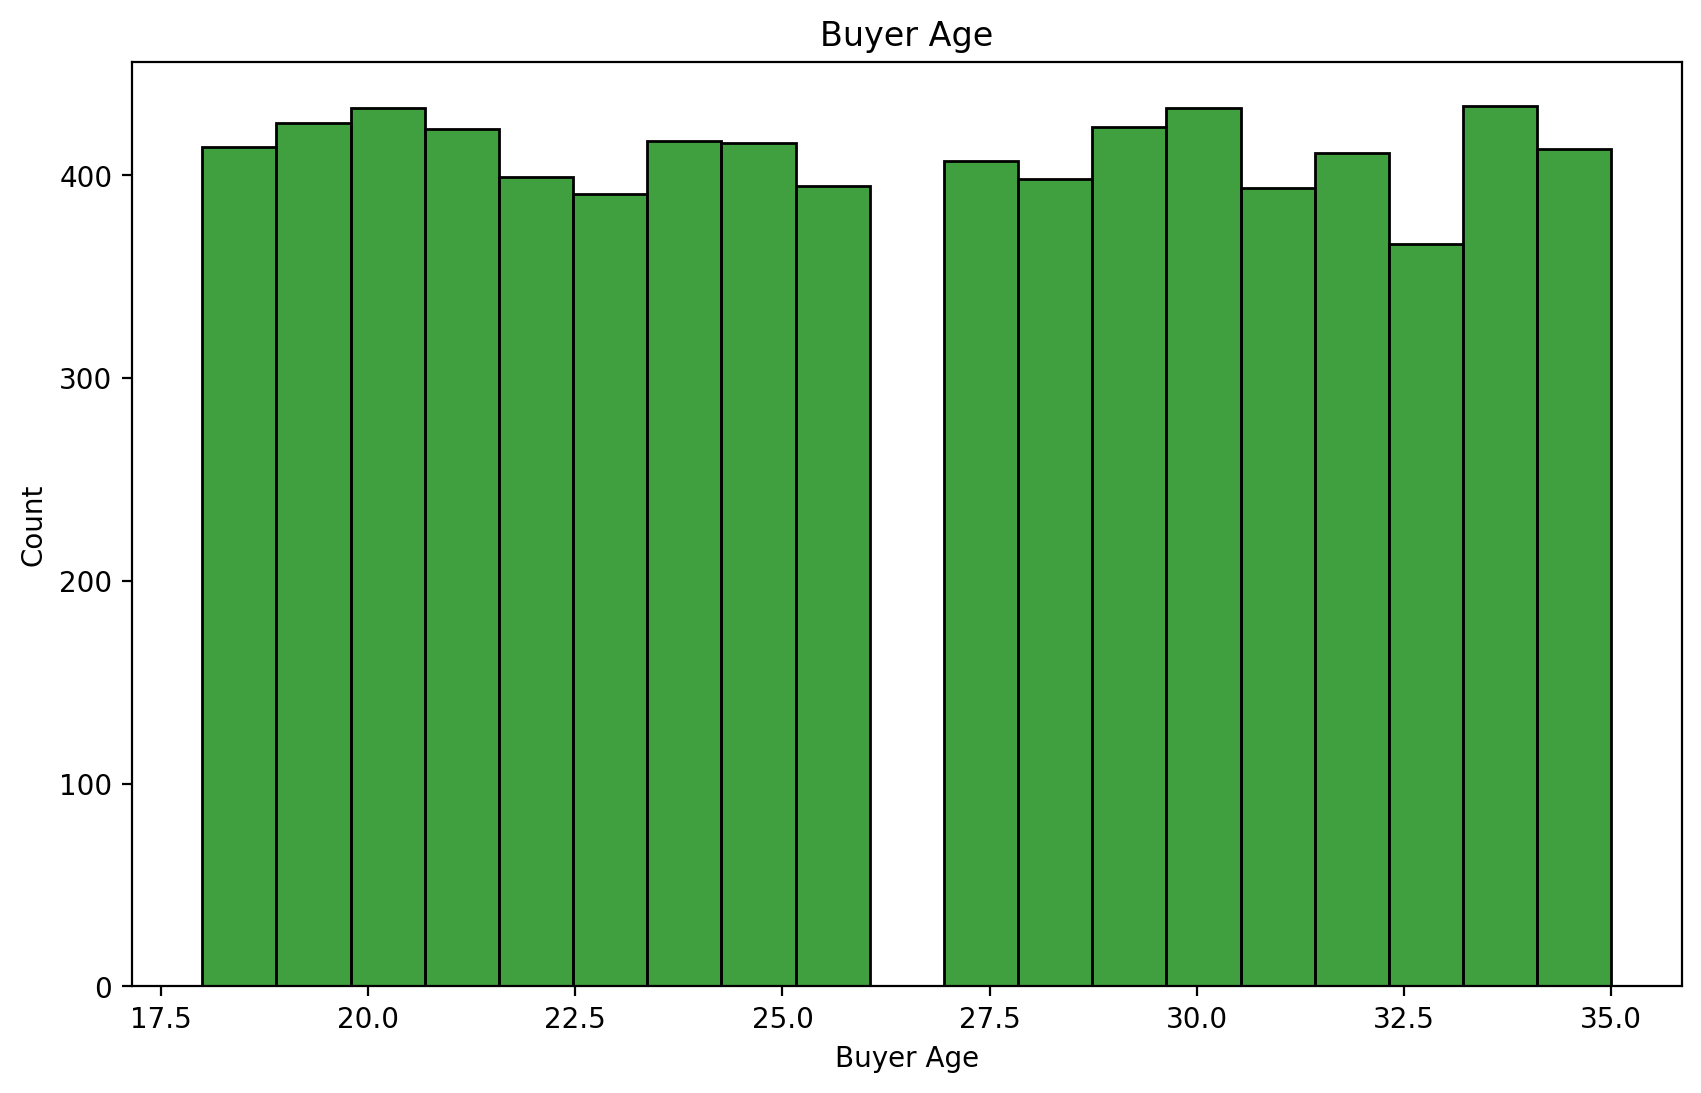

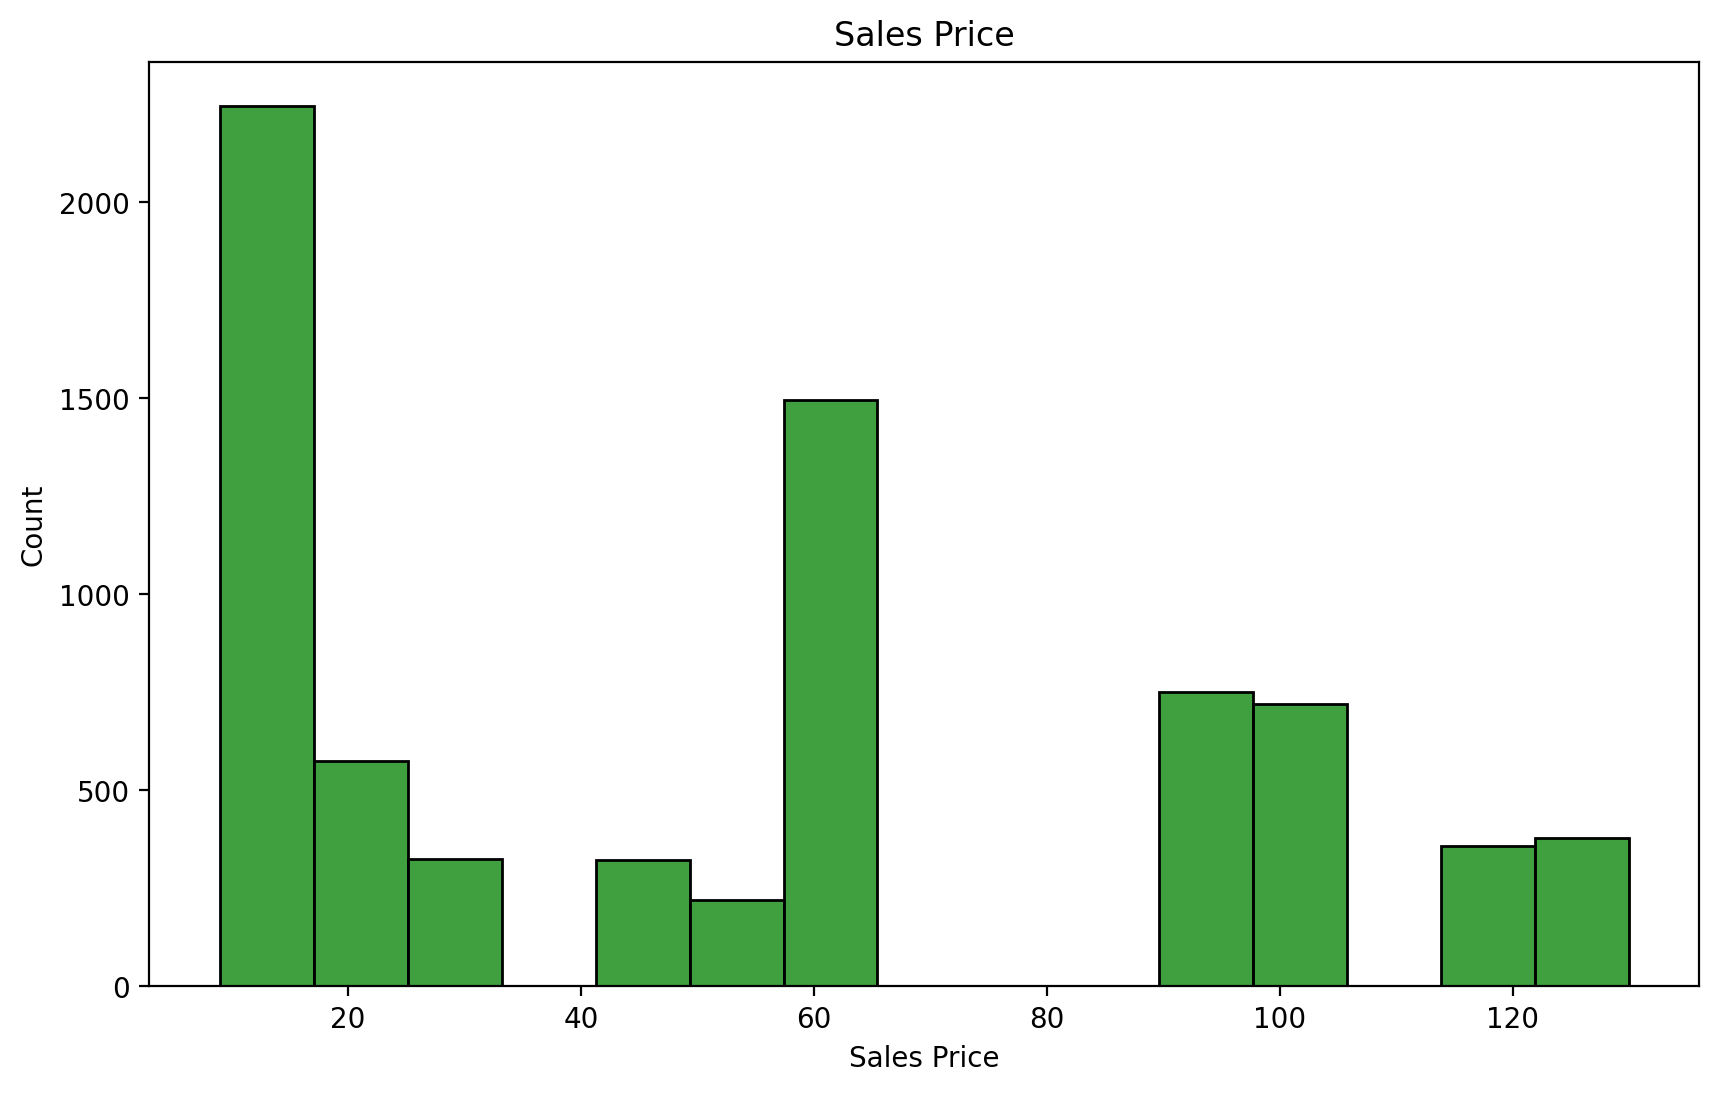

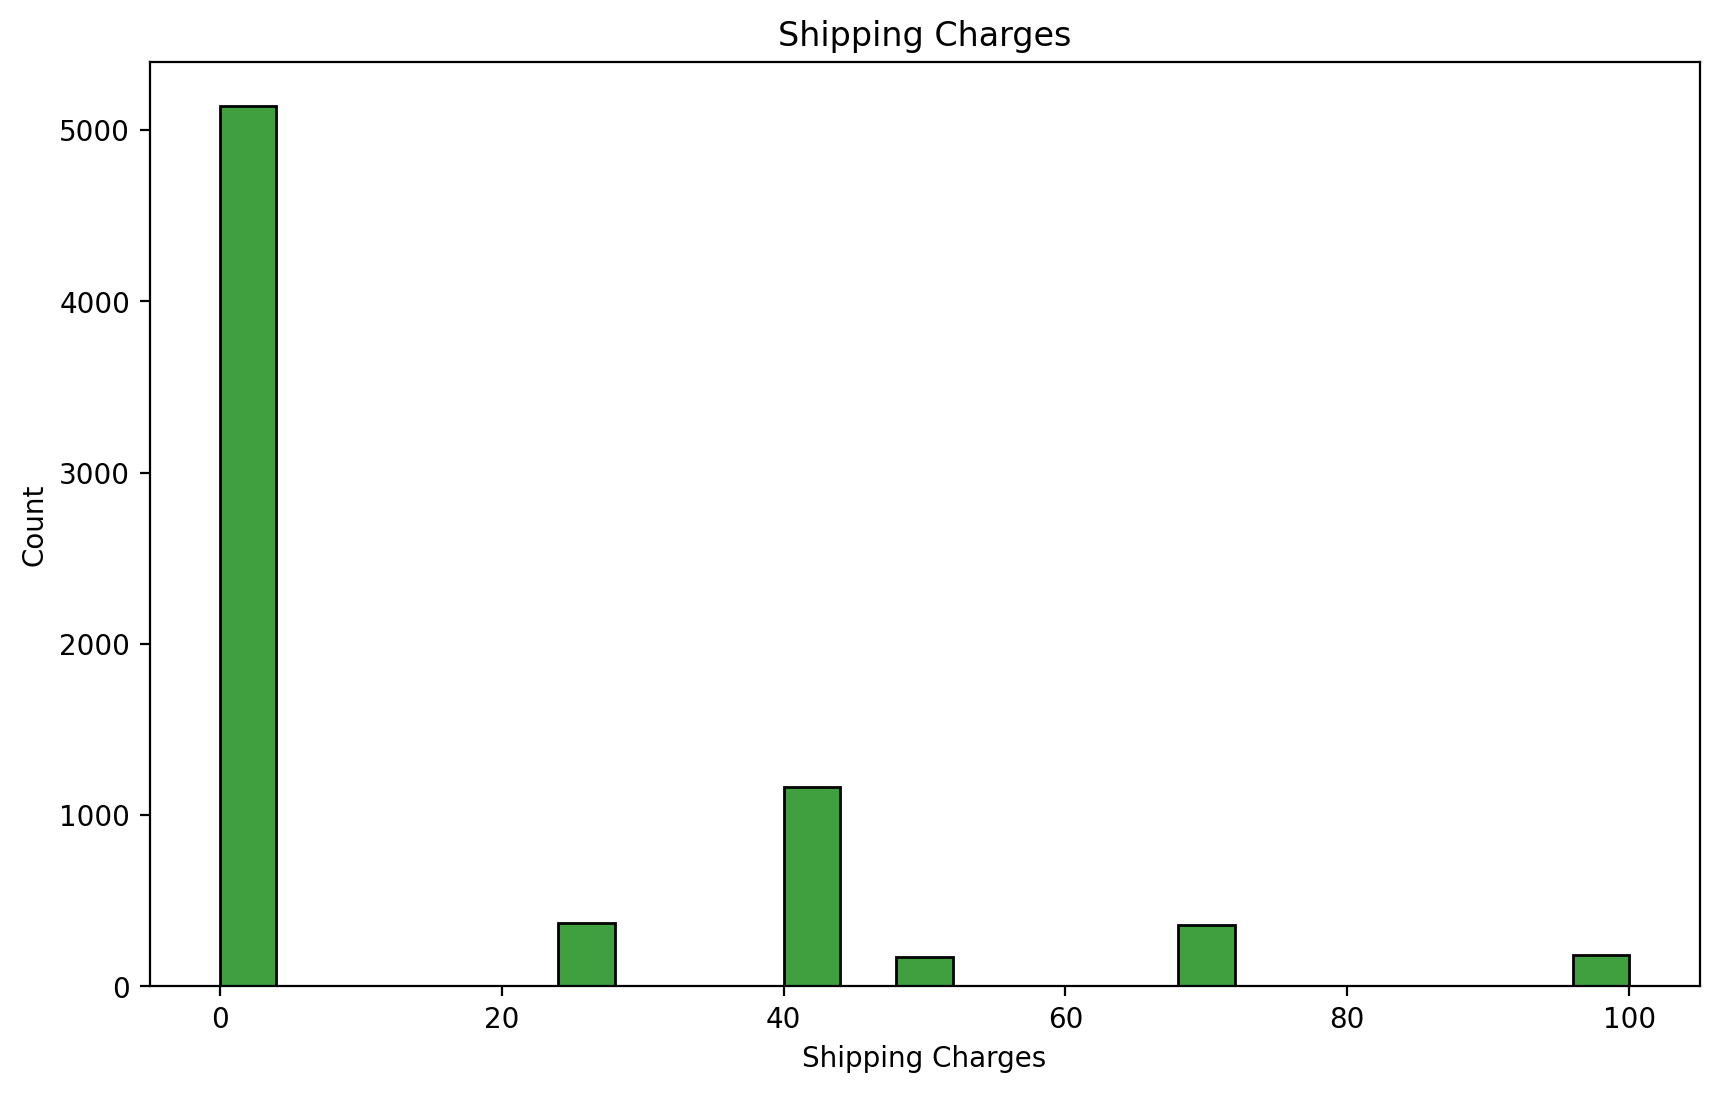

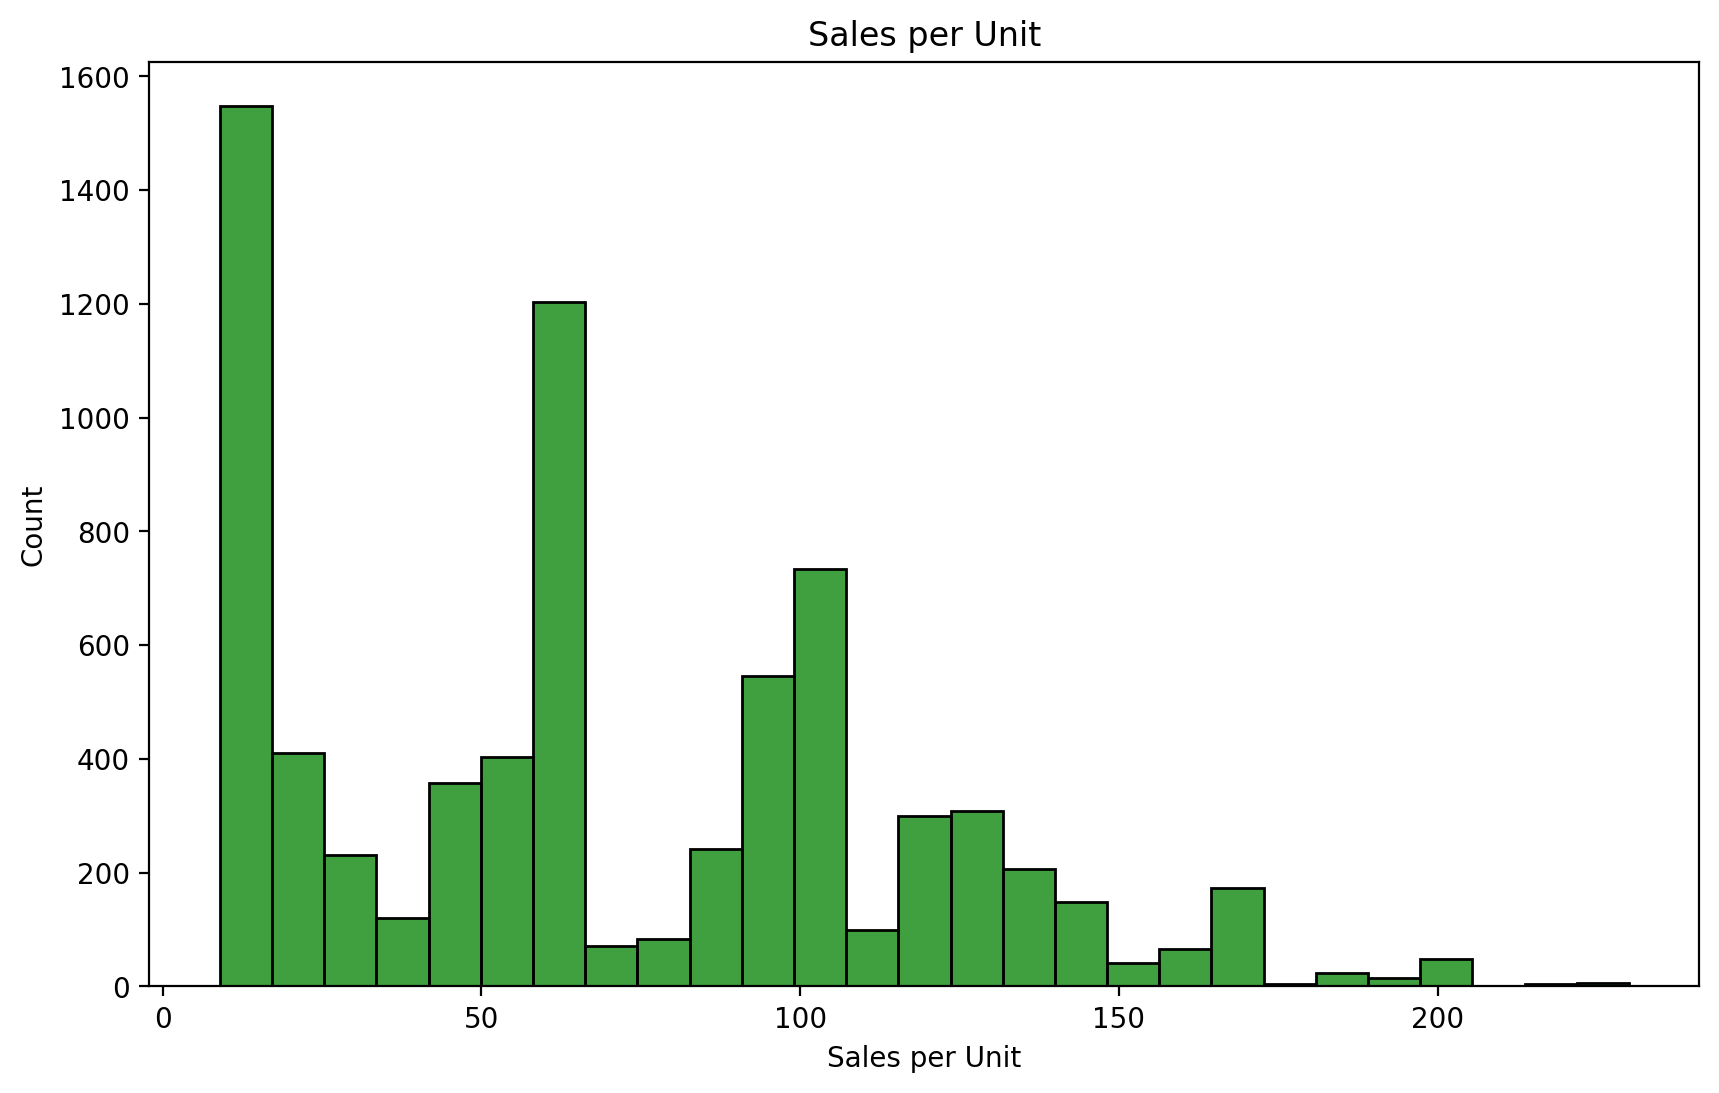

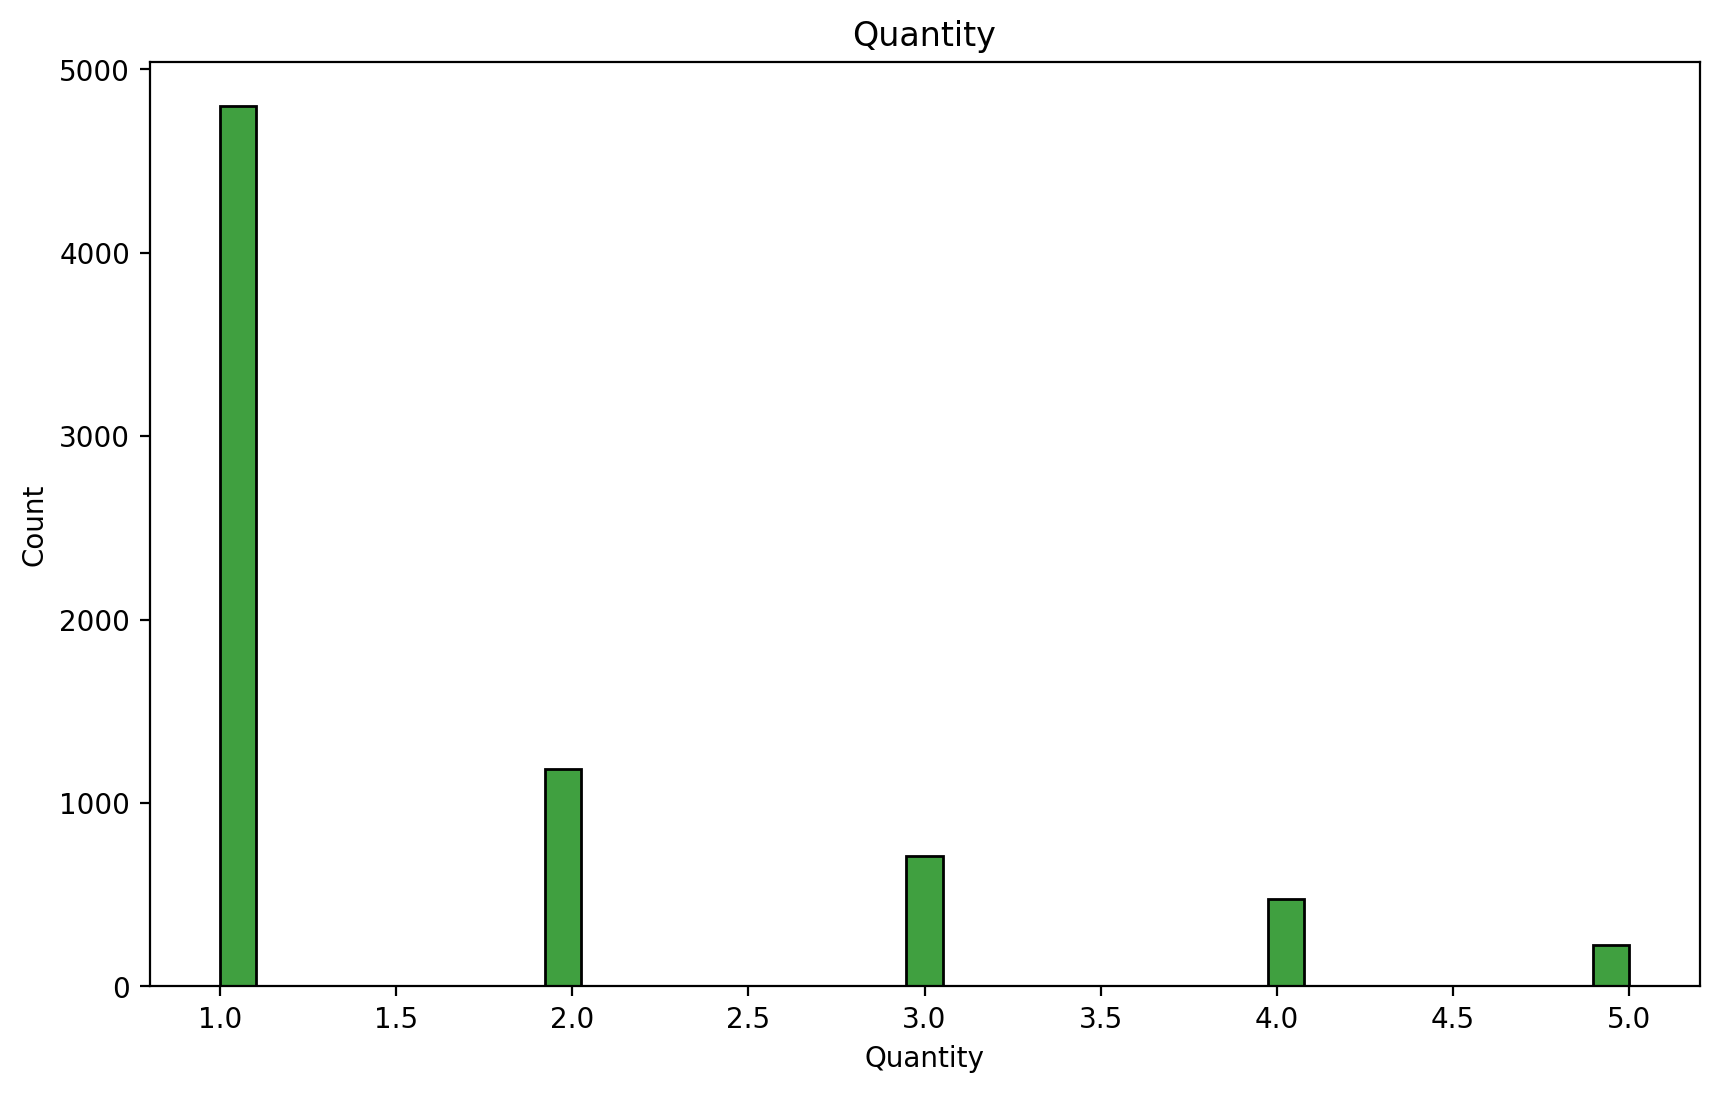

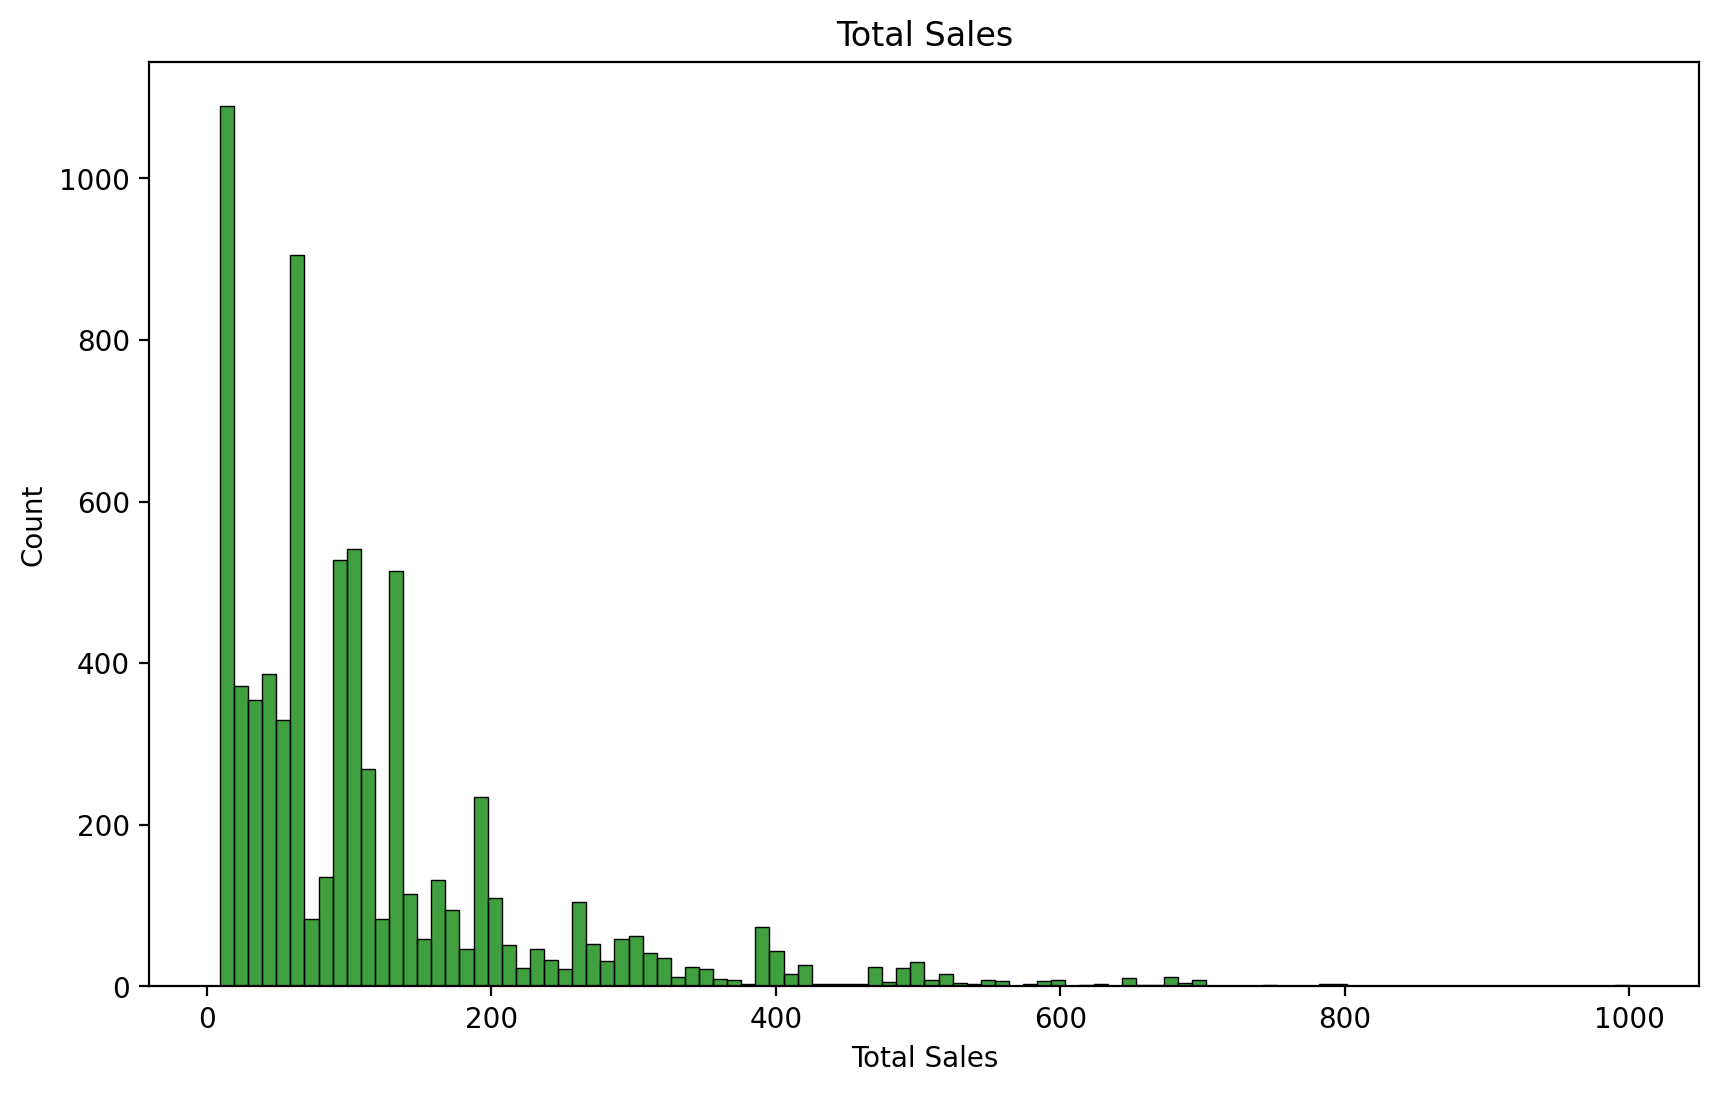

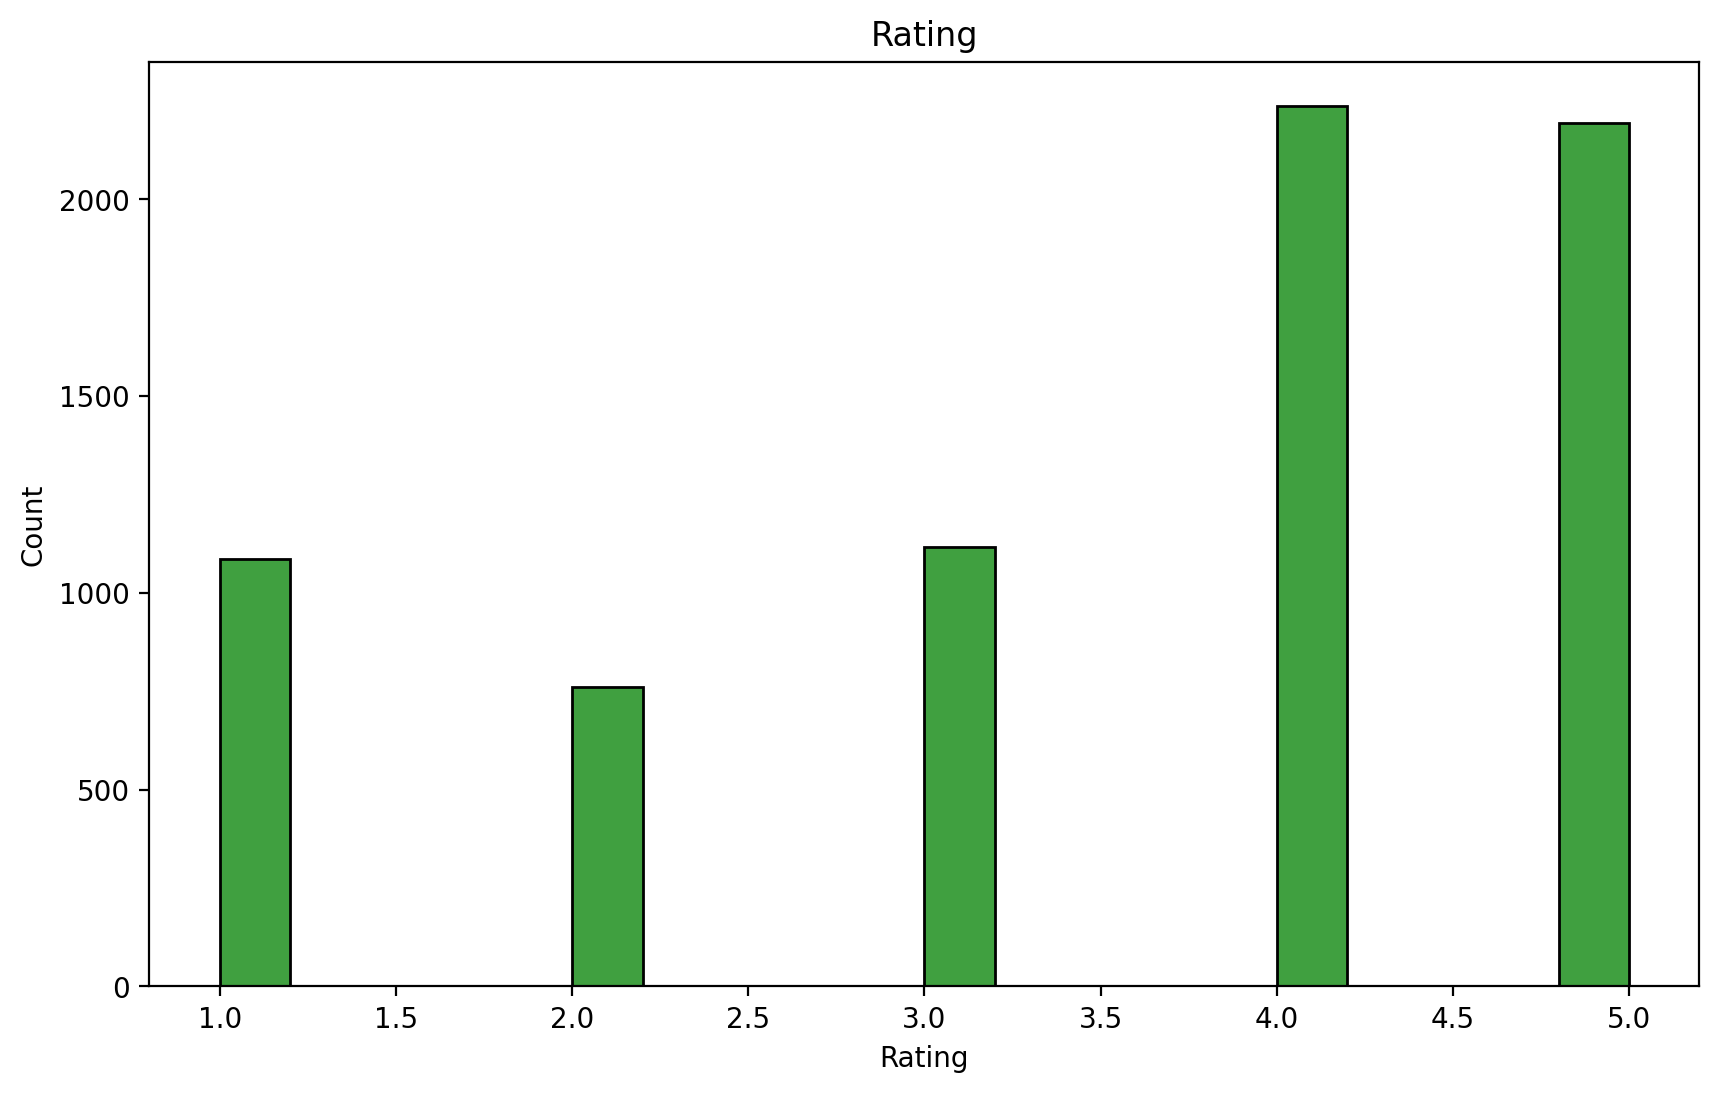

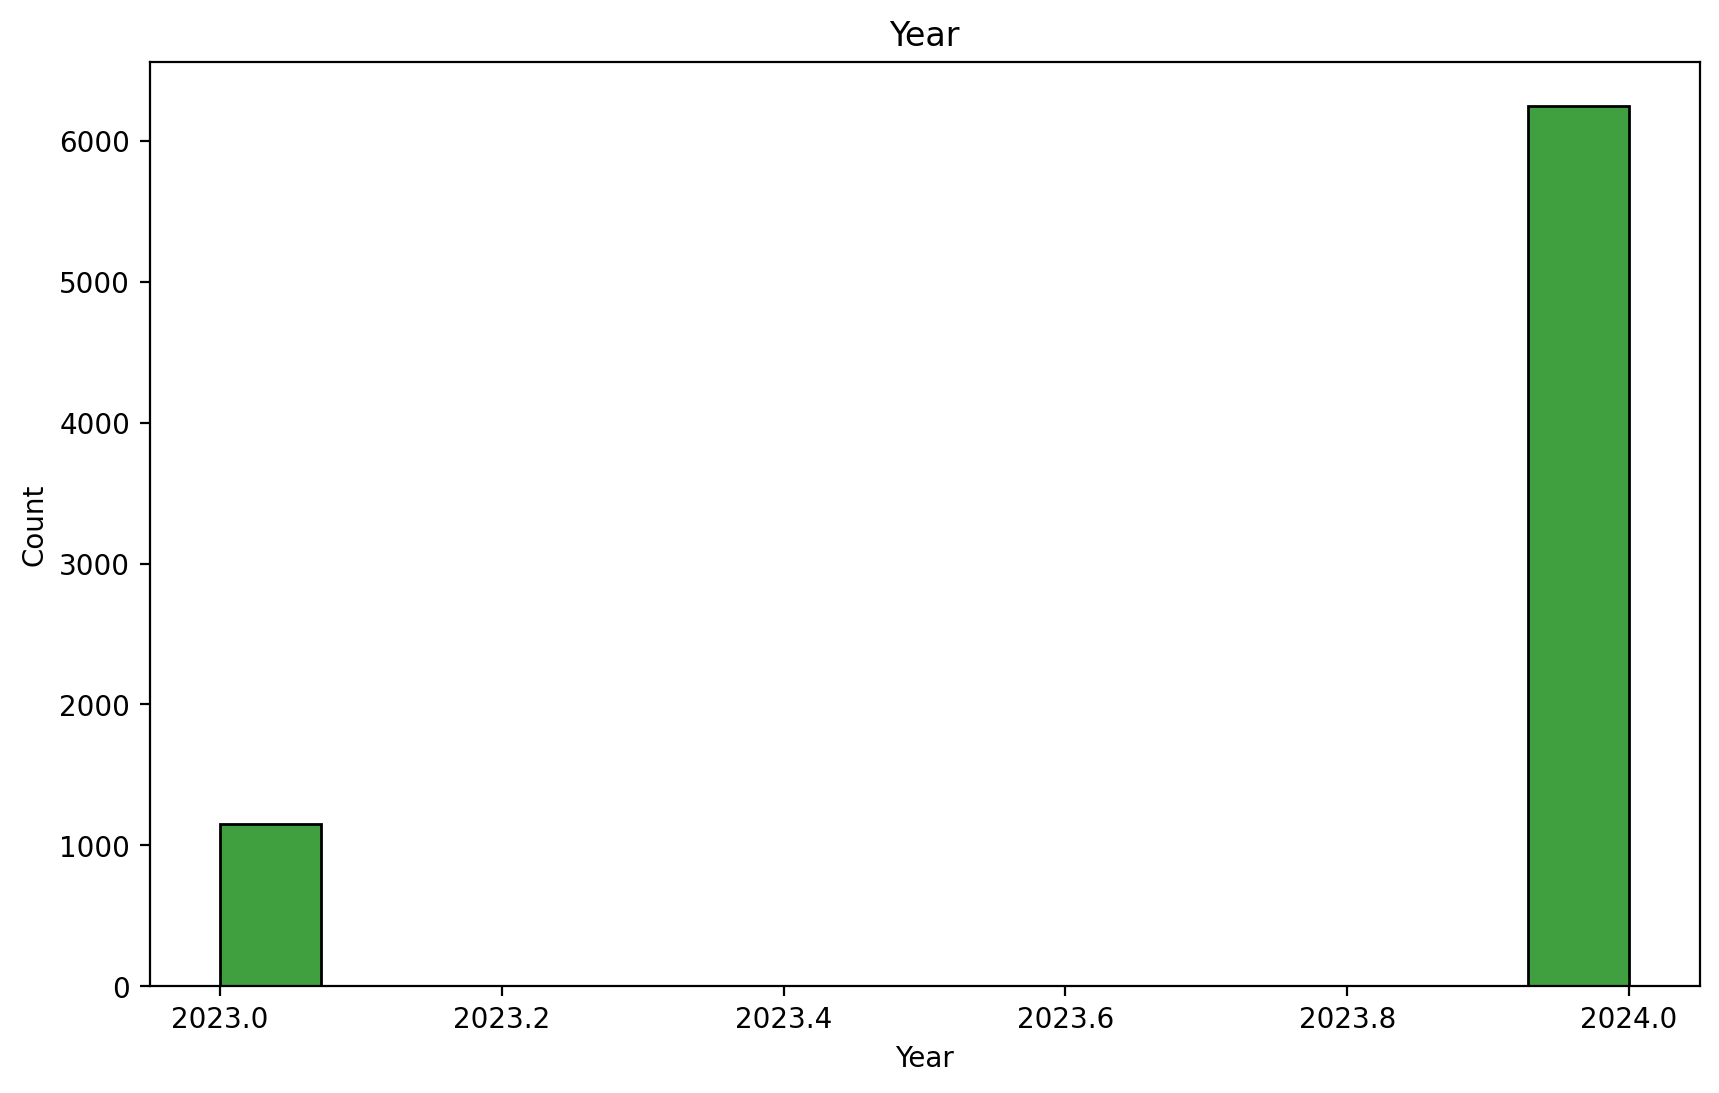

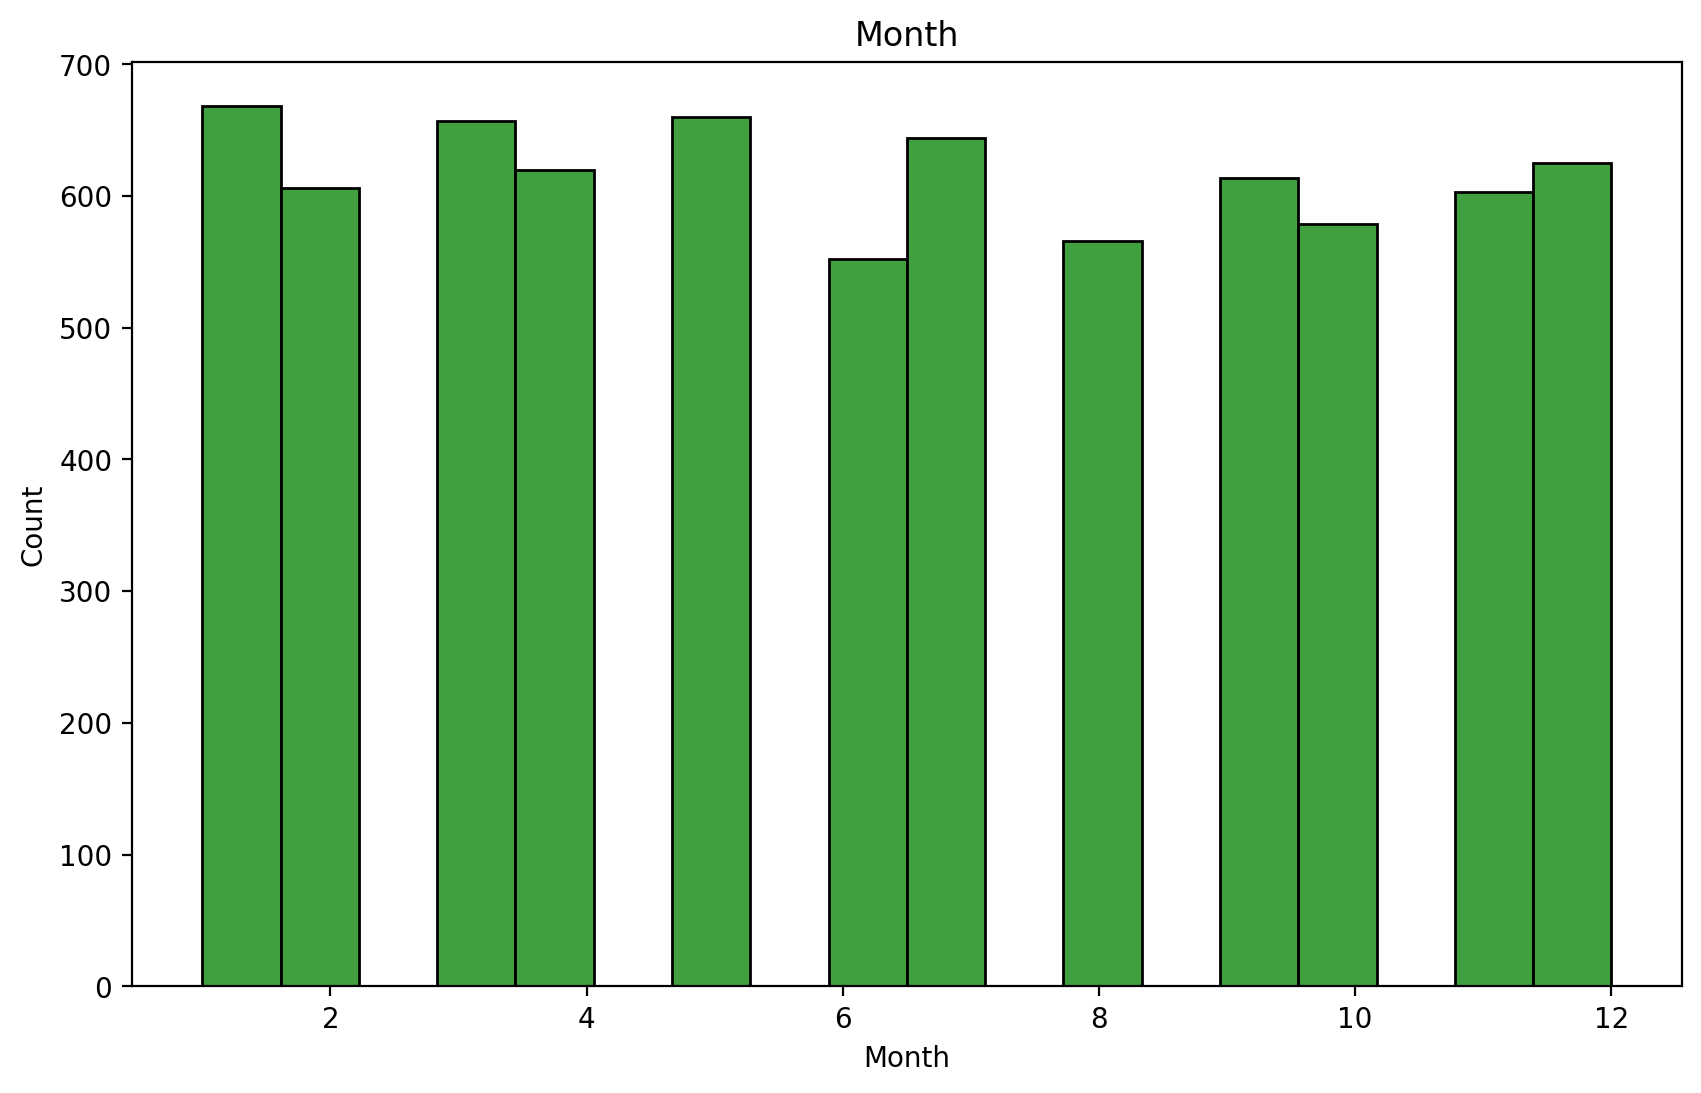

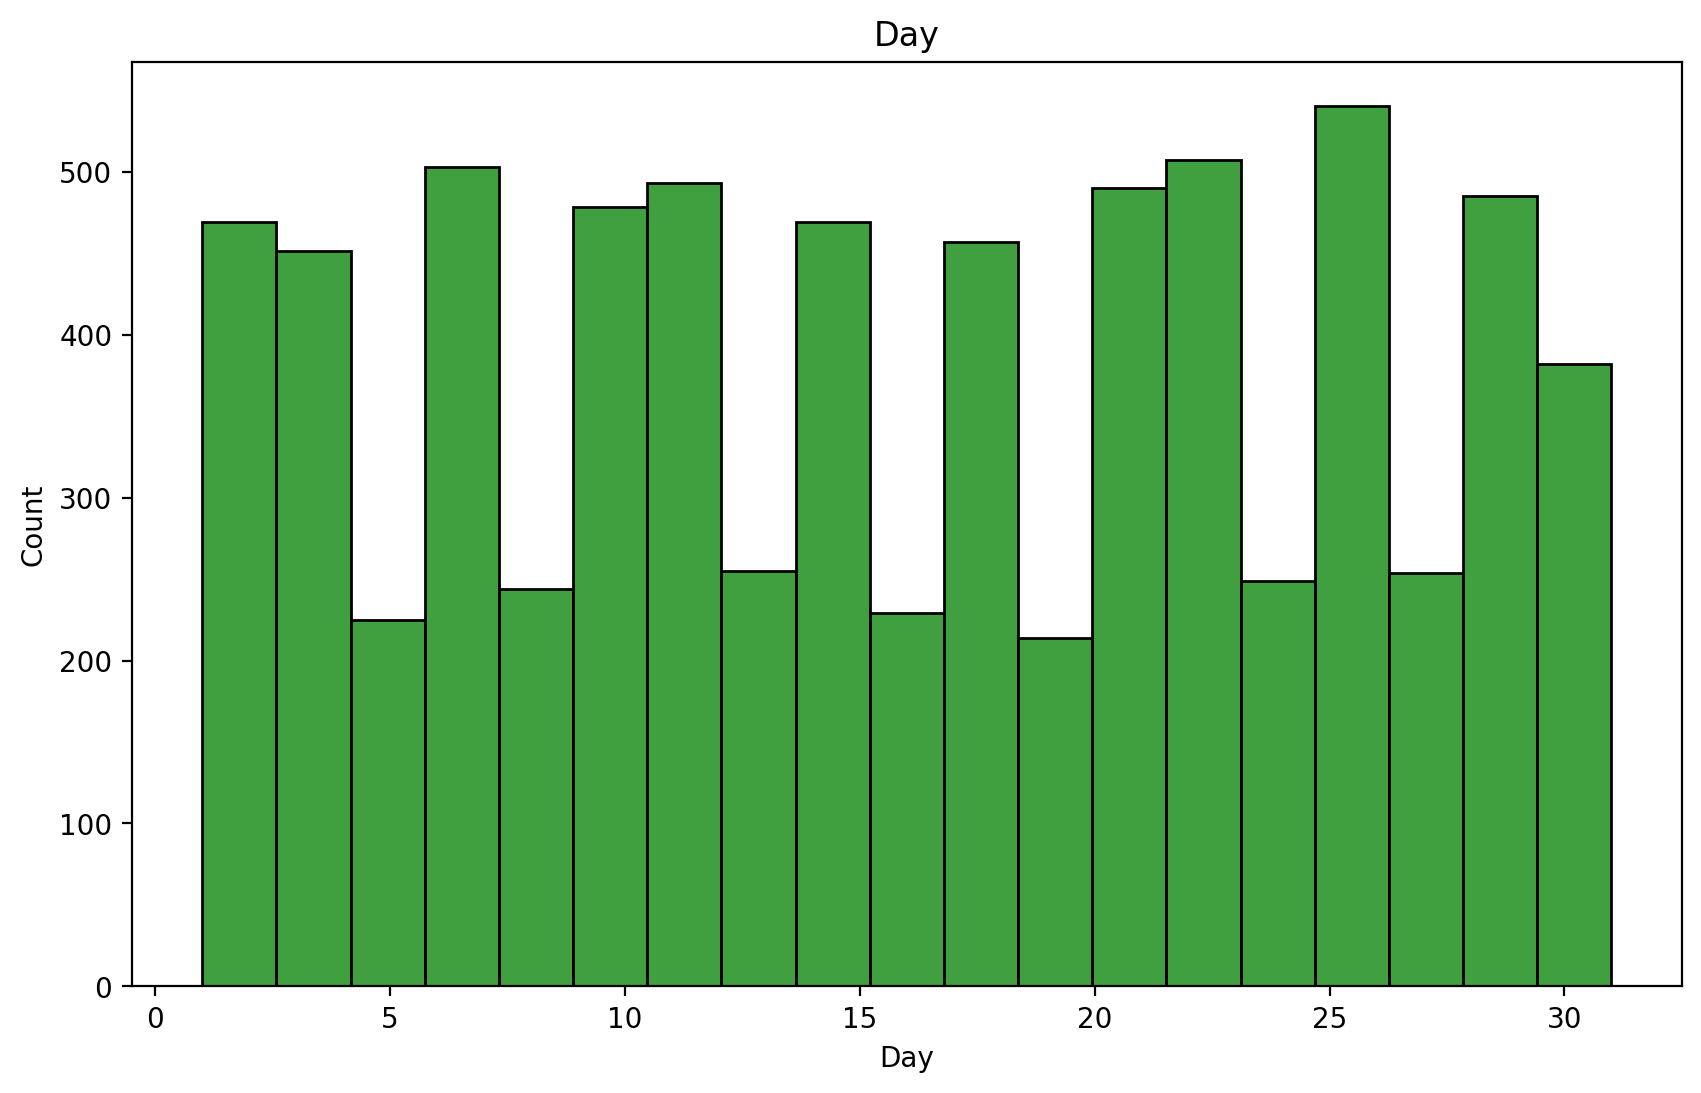

In [ ]:
# plot a histogram for numerical columns
for column in numerical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.histplot(df[column],color = 'green',edgecolor = 'black')
  plt.title(column)
  plt.xlabel(column)
  plt.show()

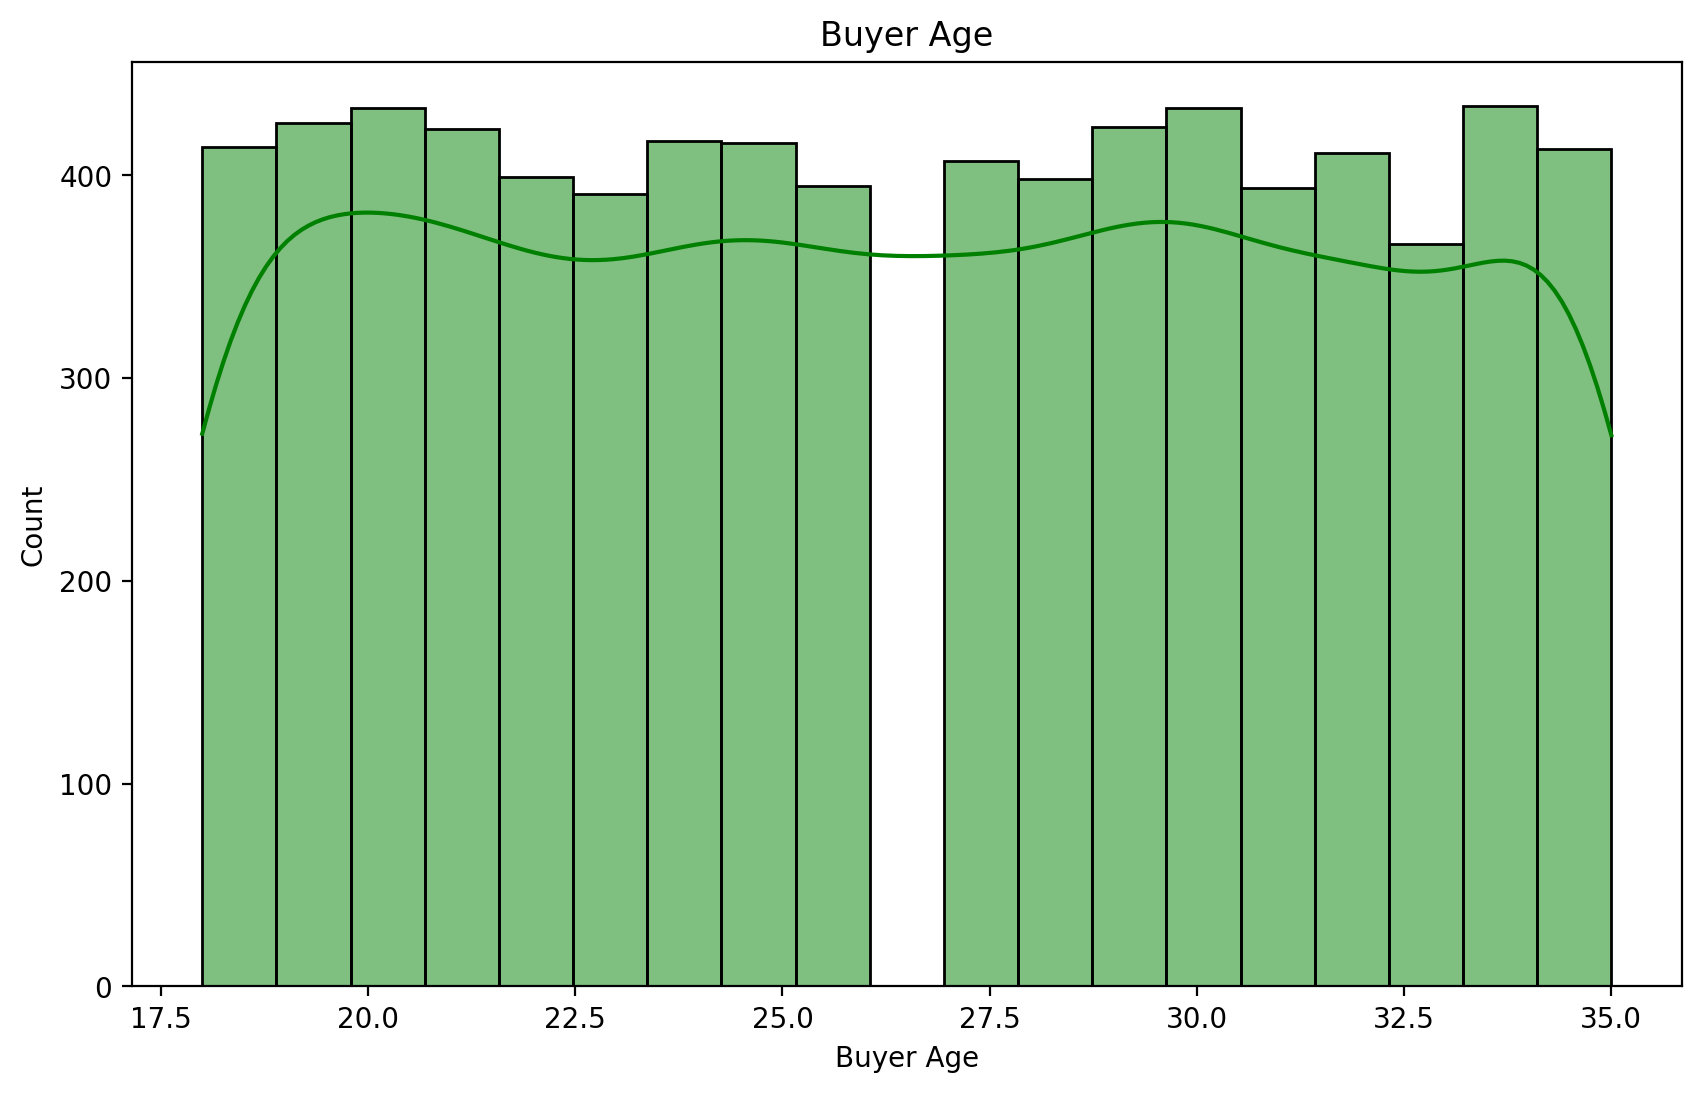

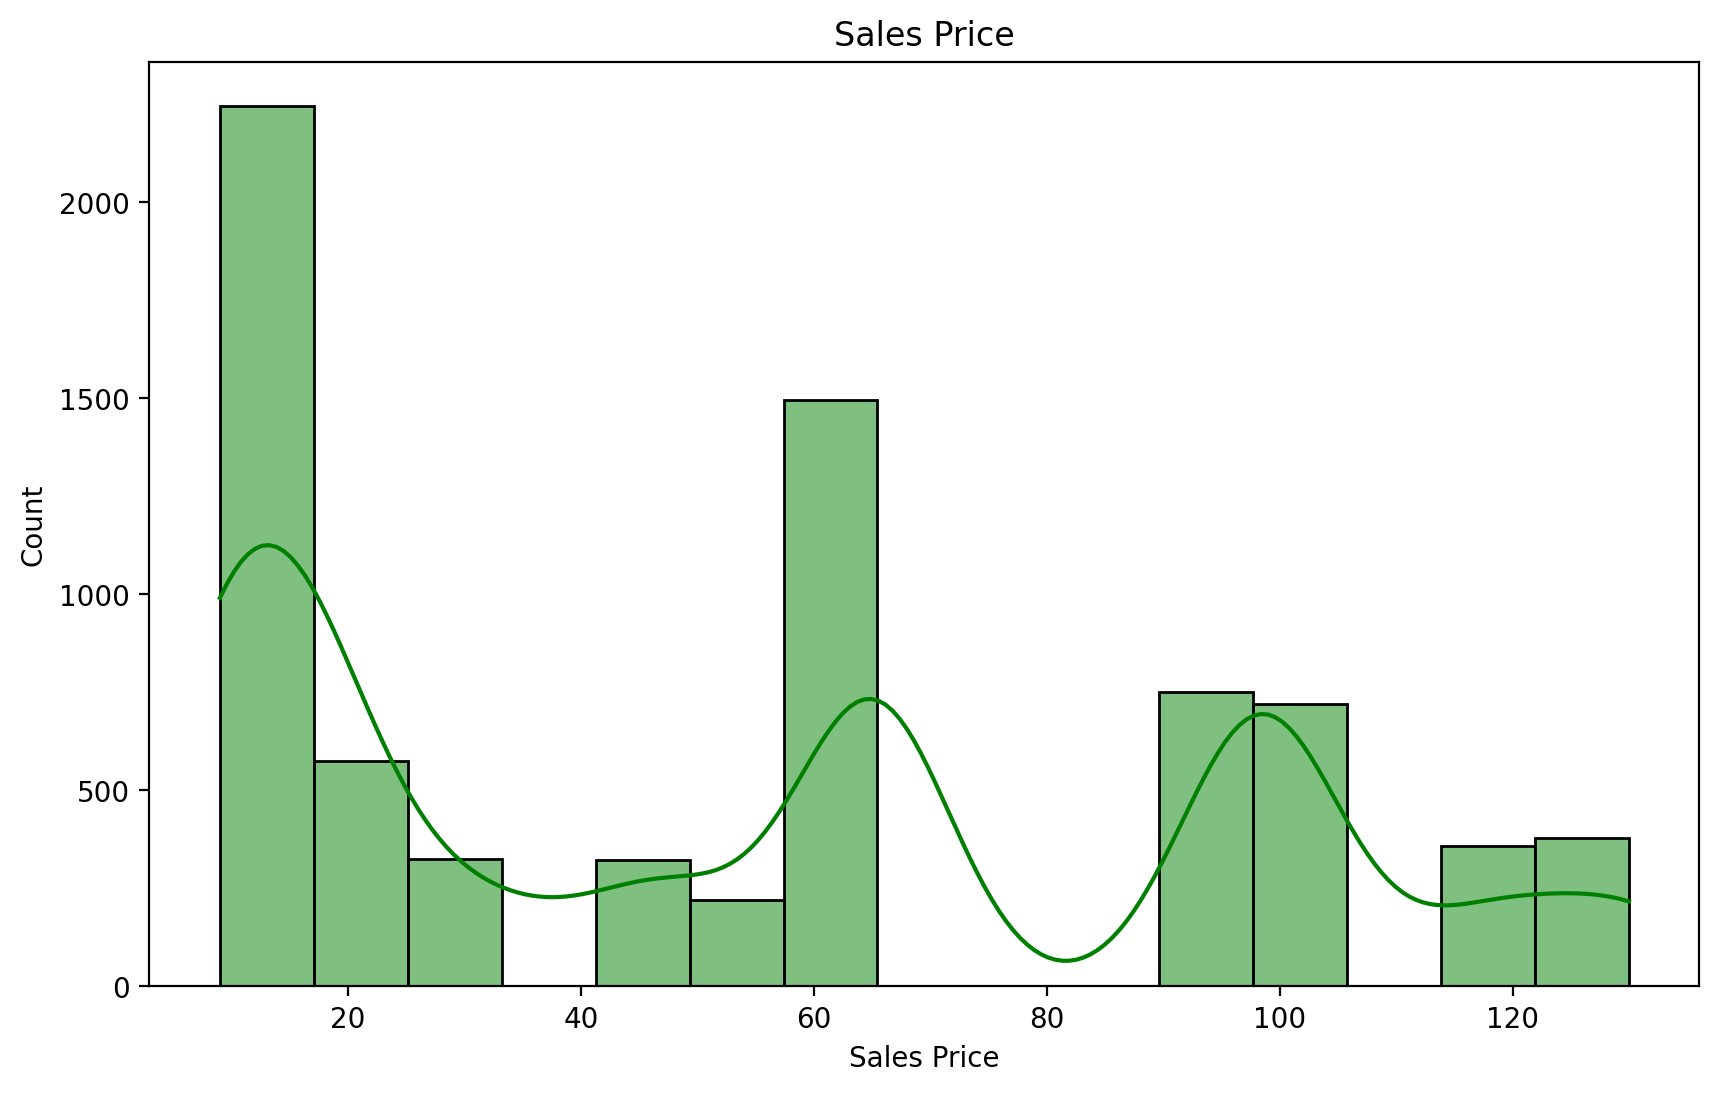

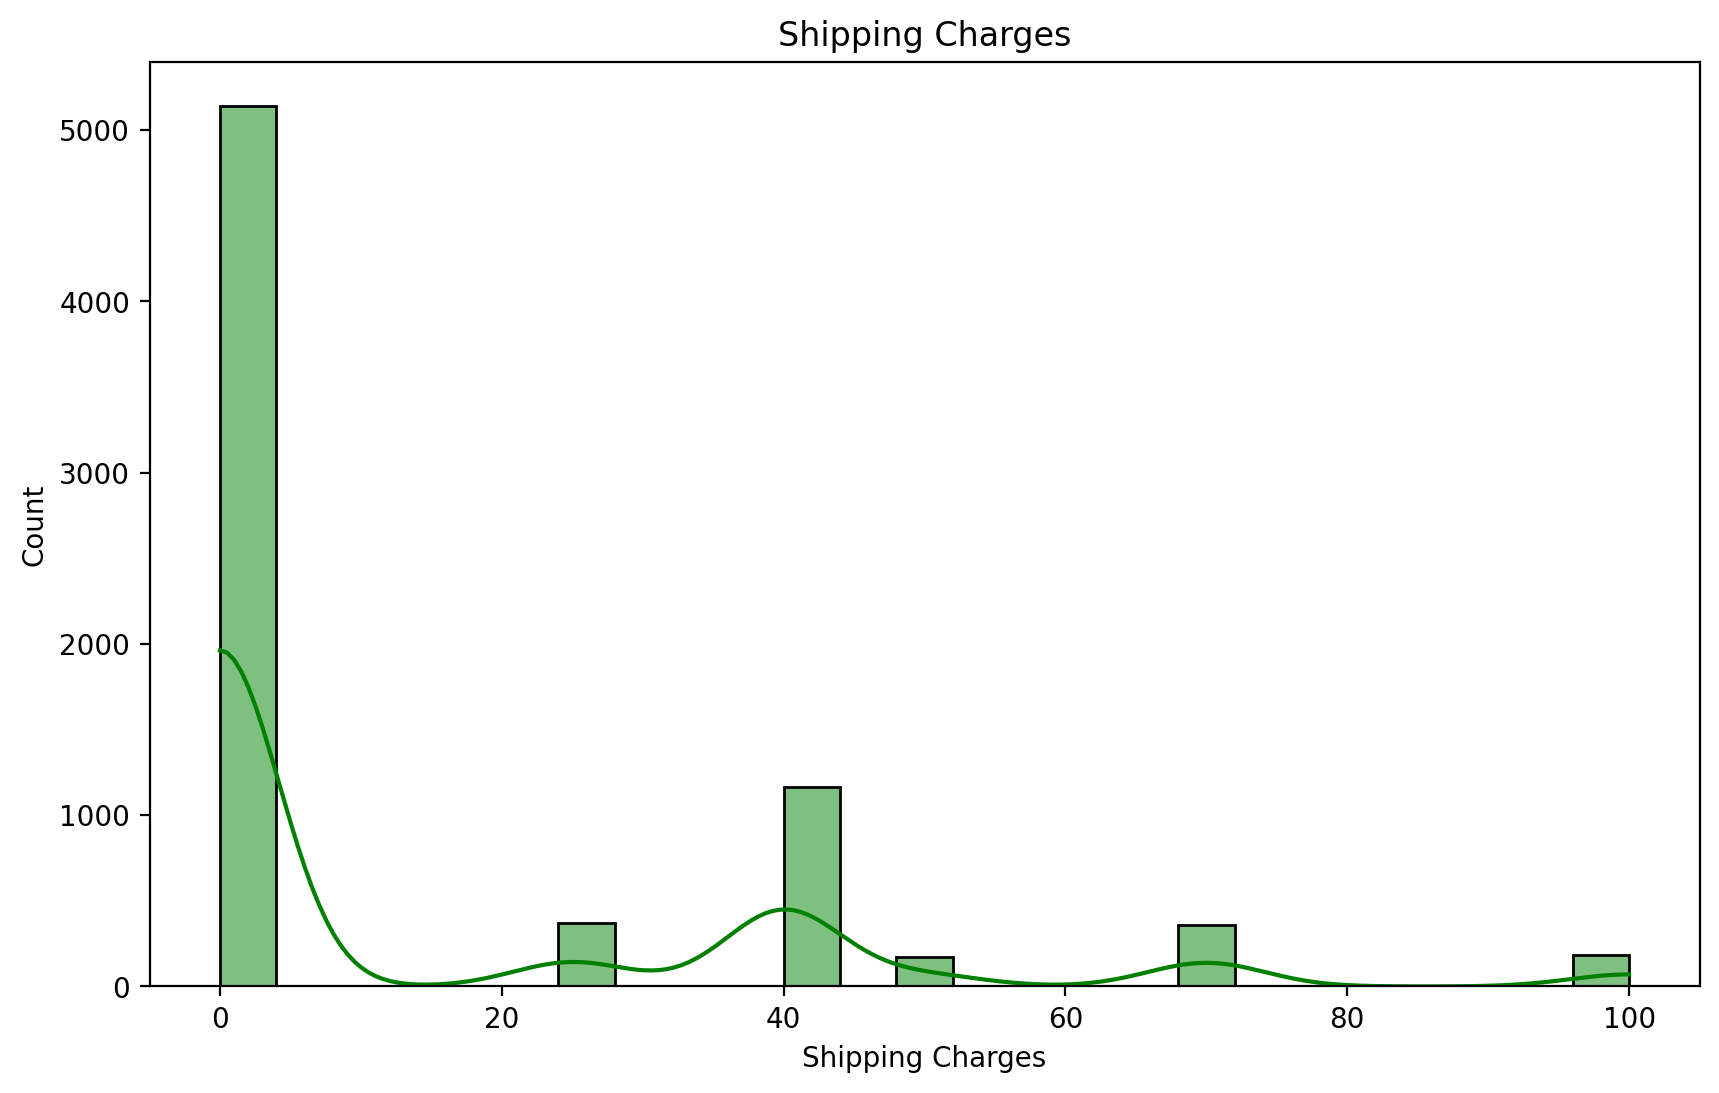

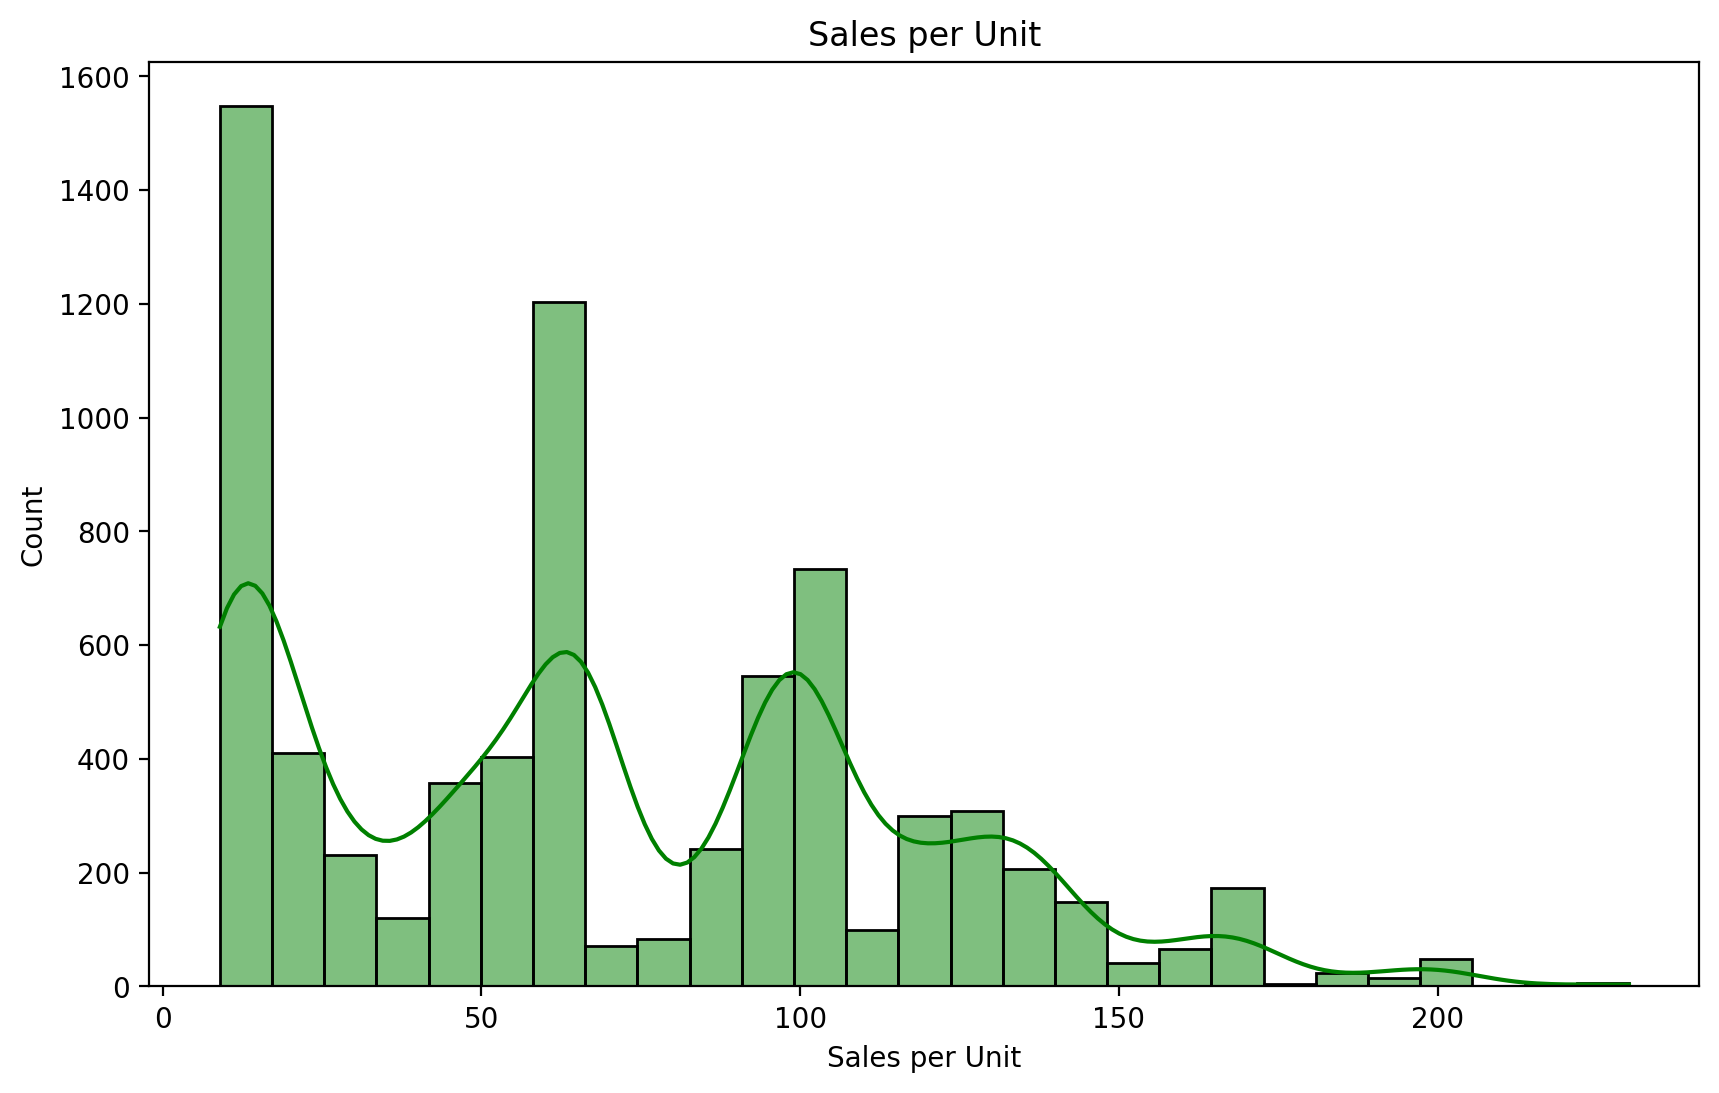

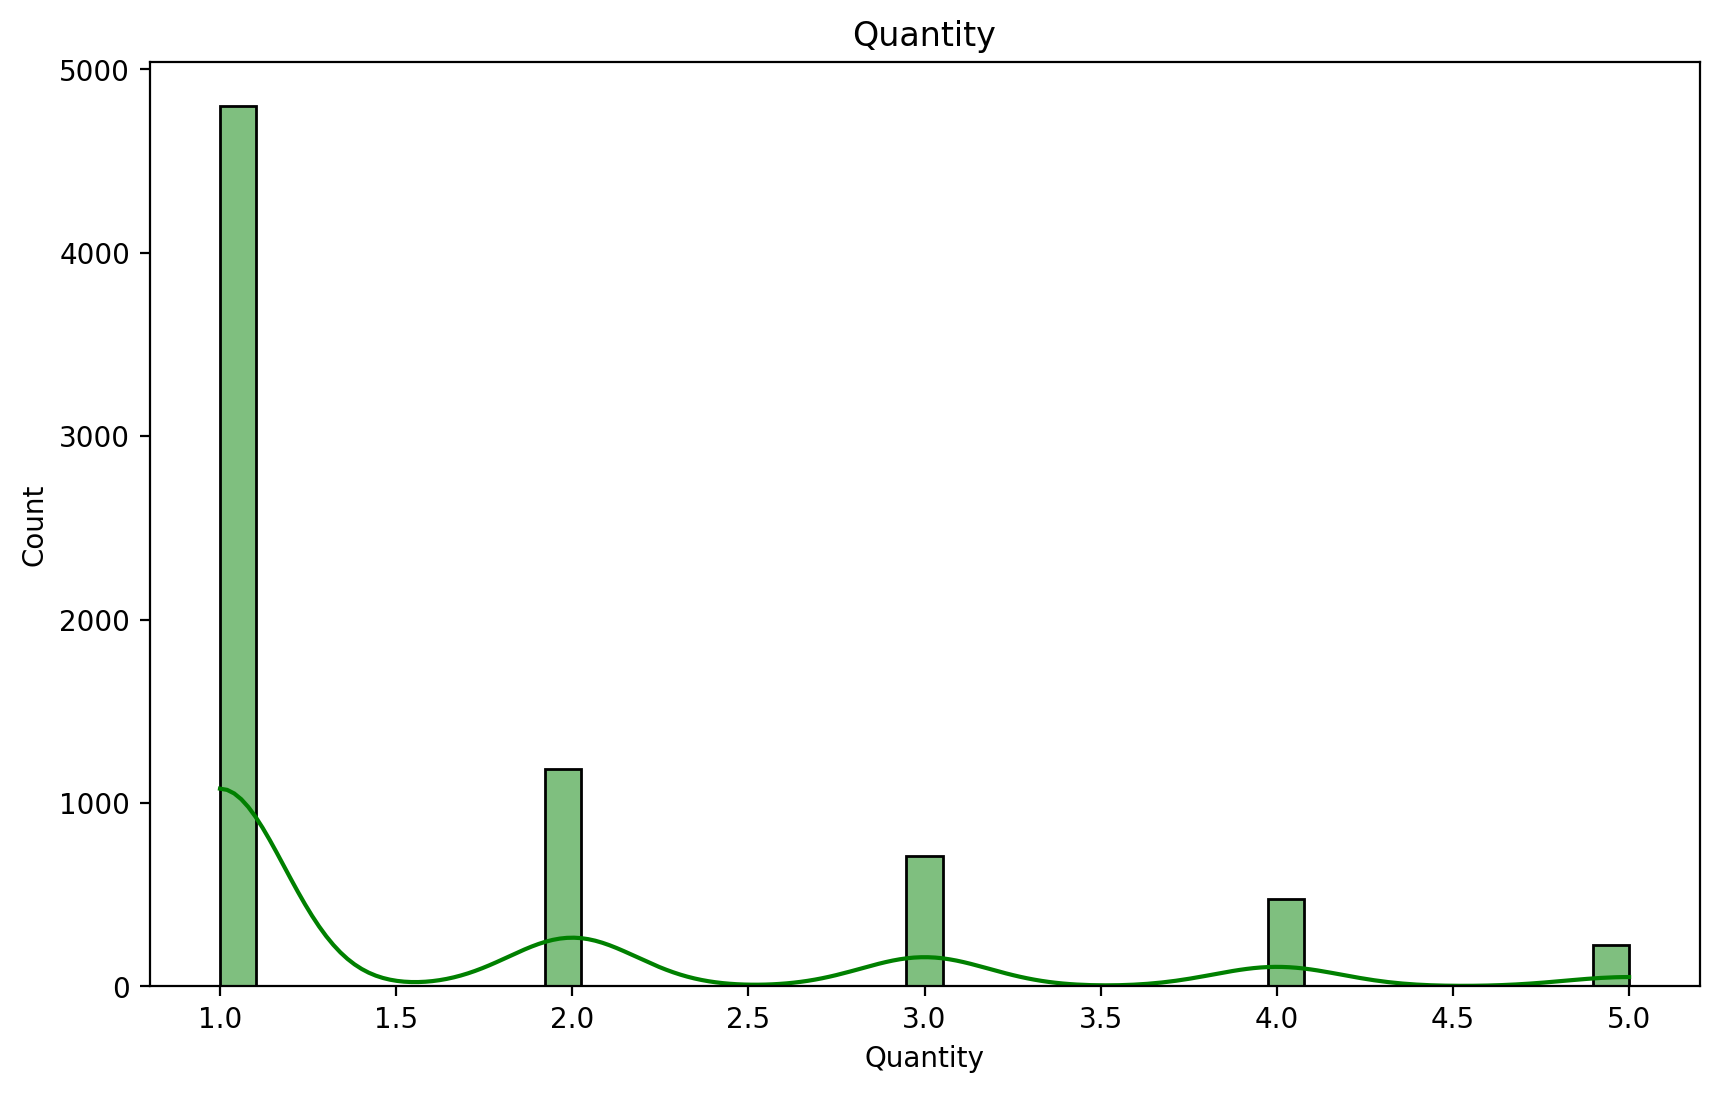

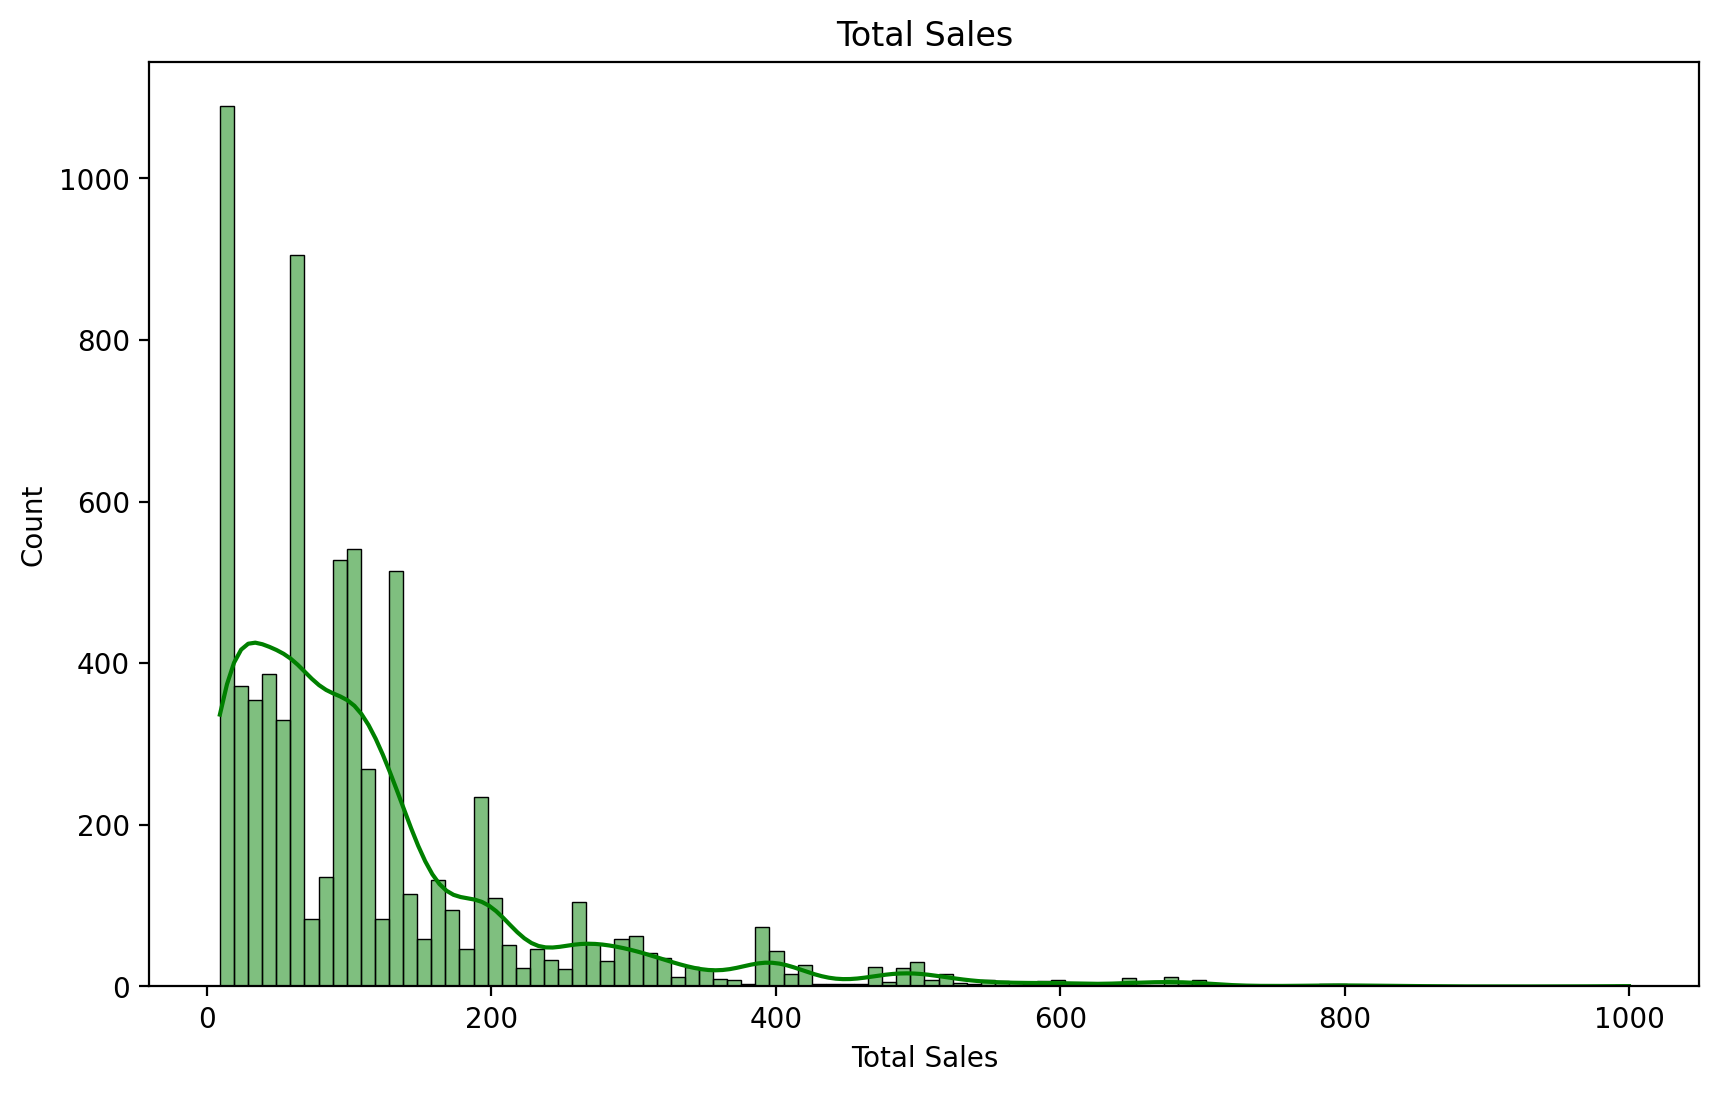

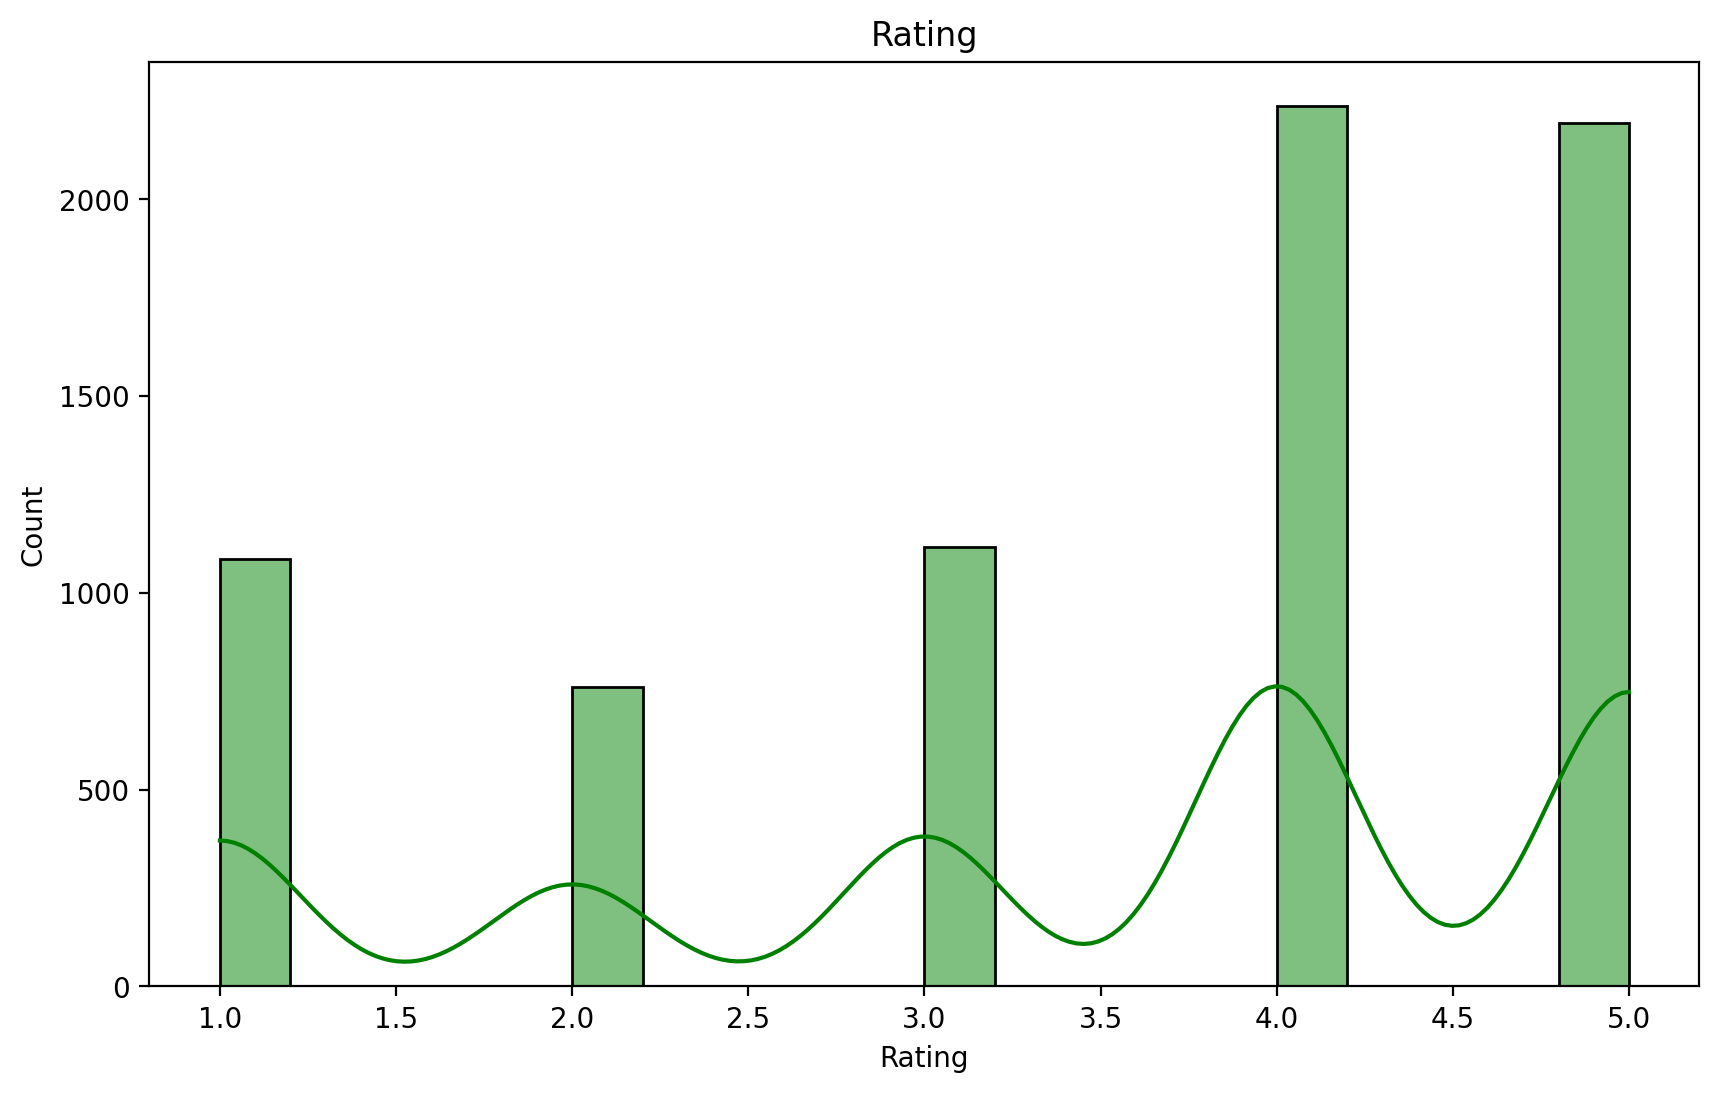

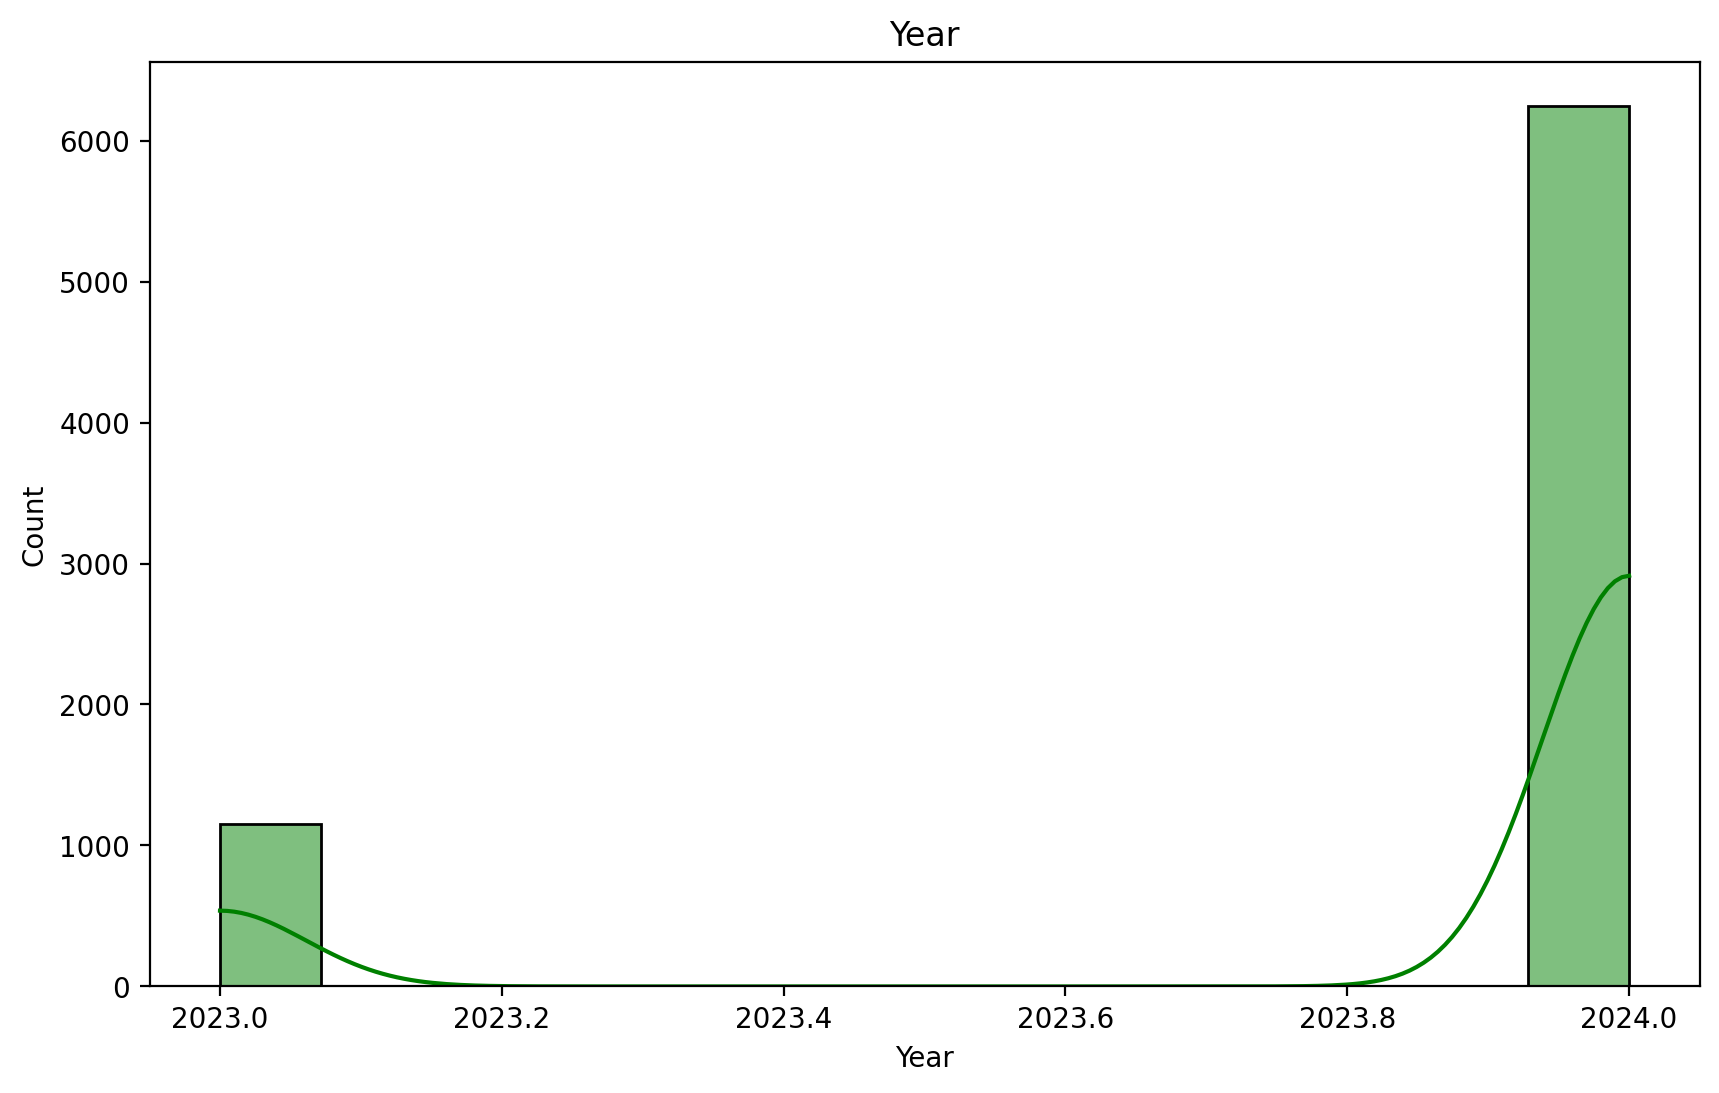

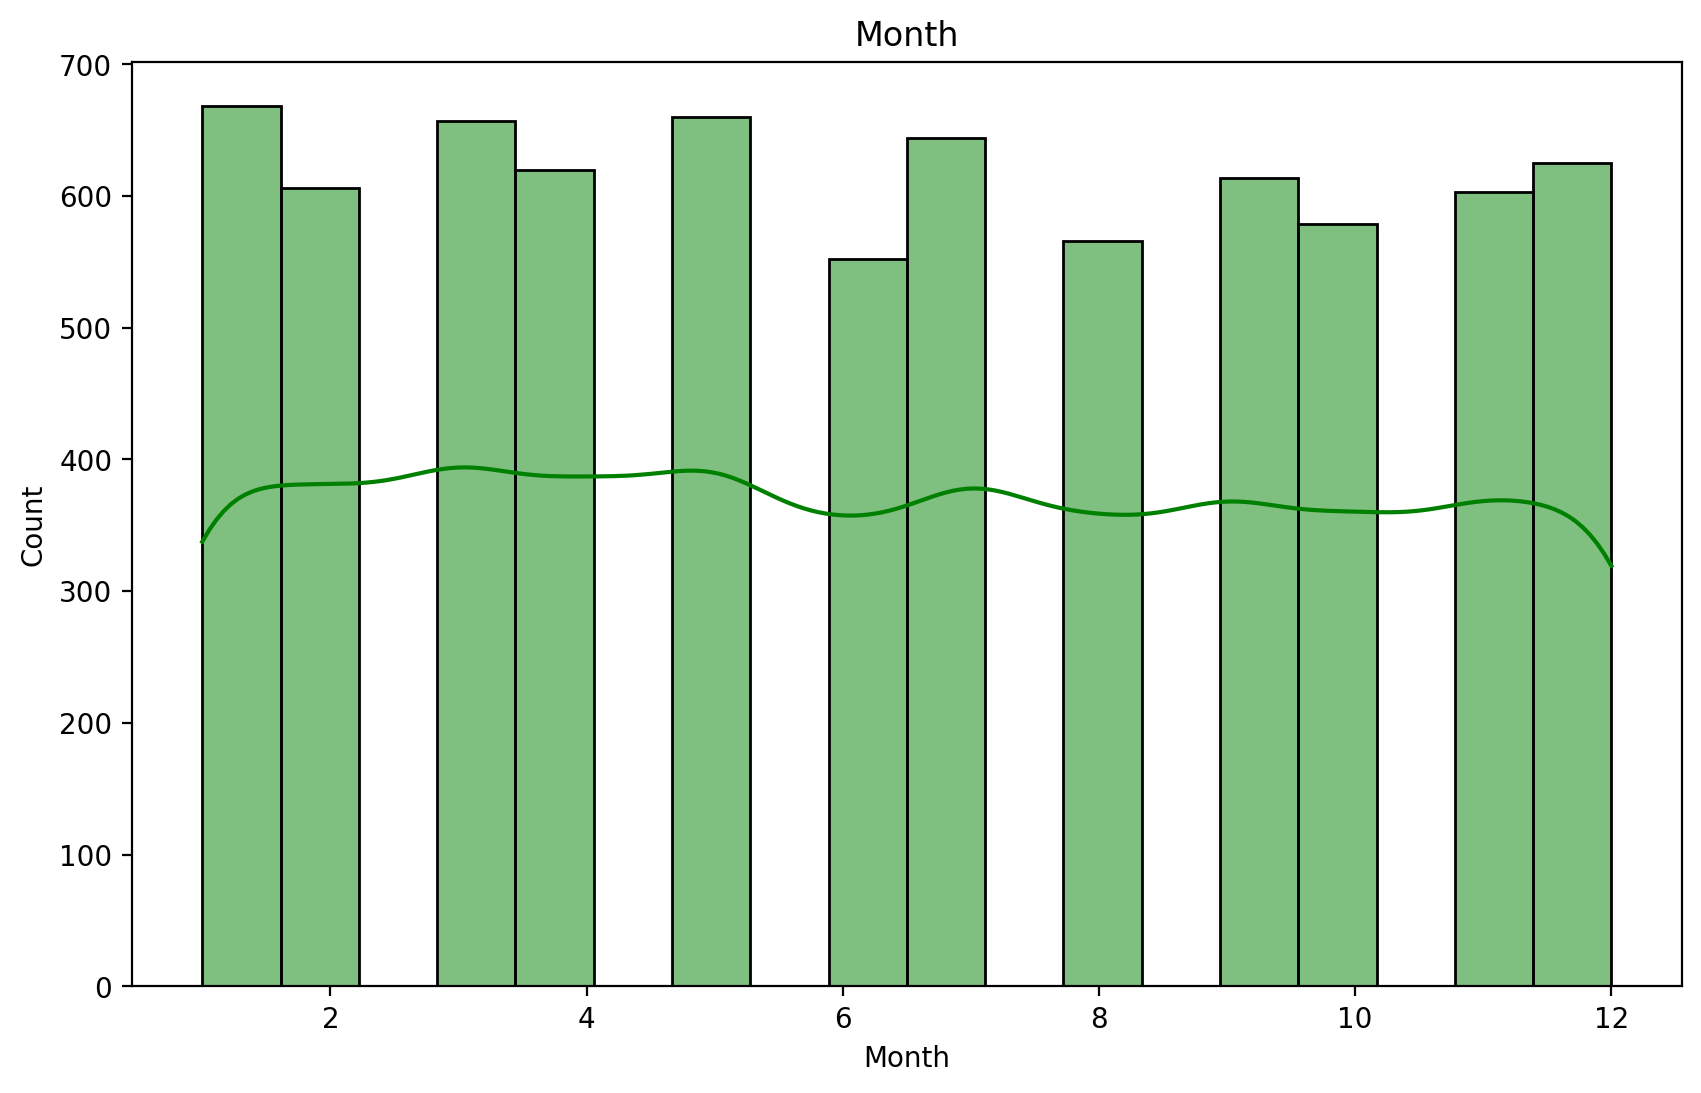

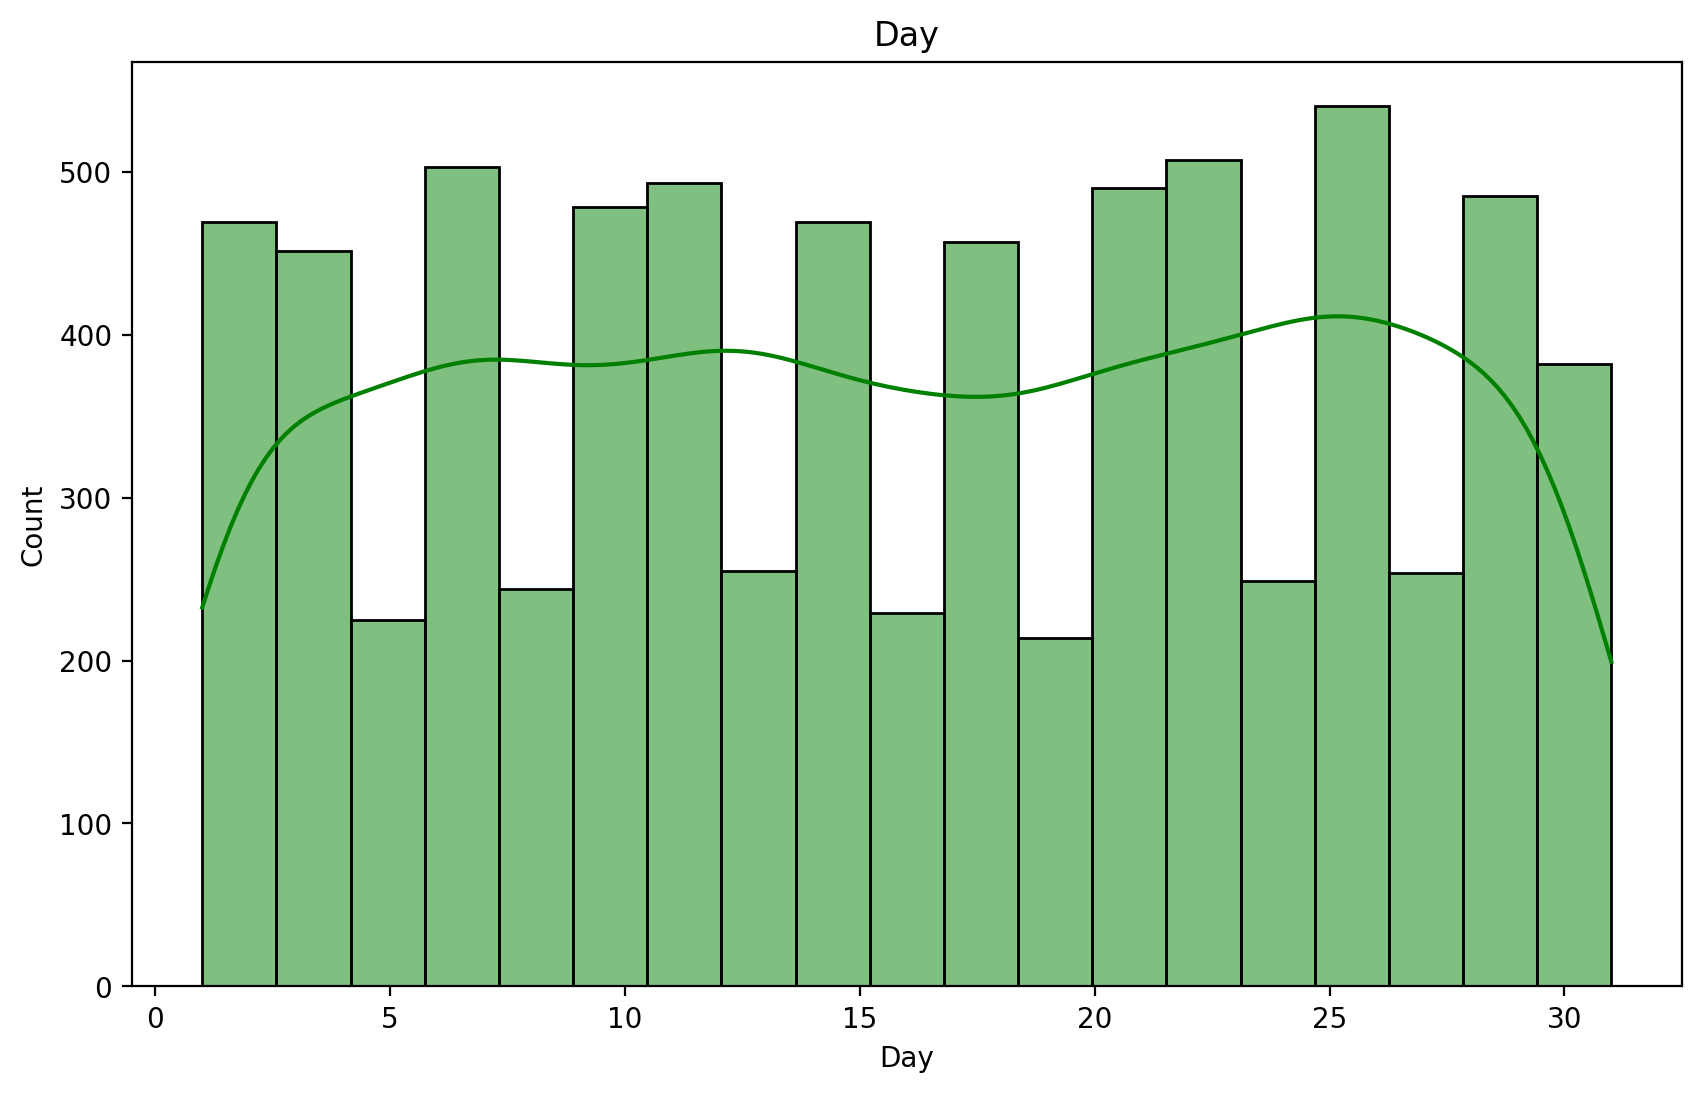

In [ ]:
# plot a histogram for numerical columns along with kernel density estimator
for column in numerical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.histplot(df[column],color = 'green',edgecolor = 'black',kde='True')
  plt.title(column)
  plt.xlabel(column)
  plt.show()

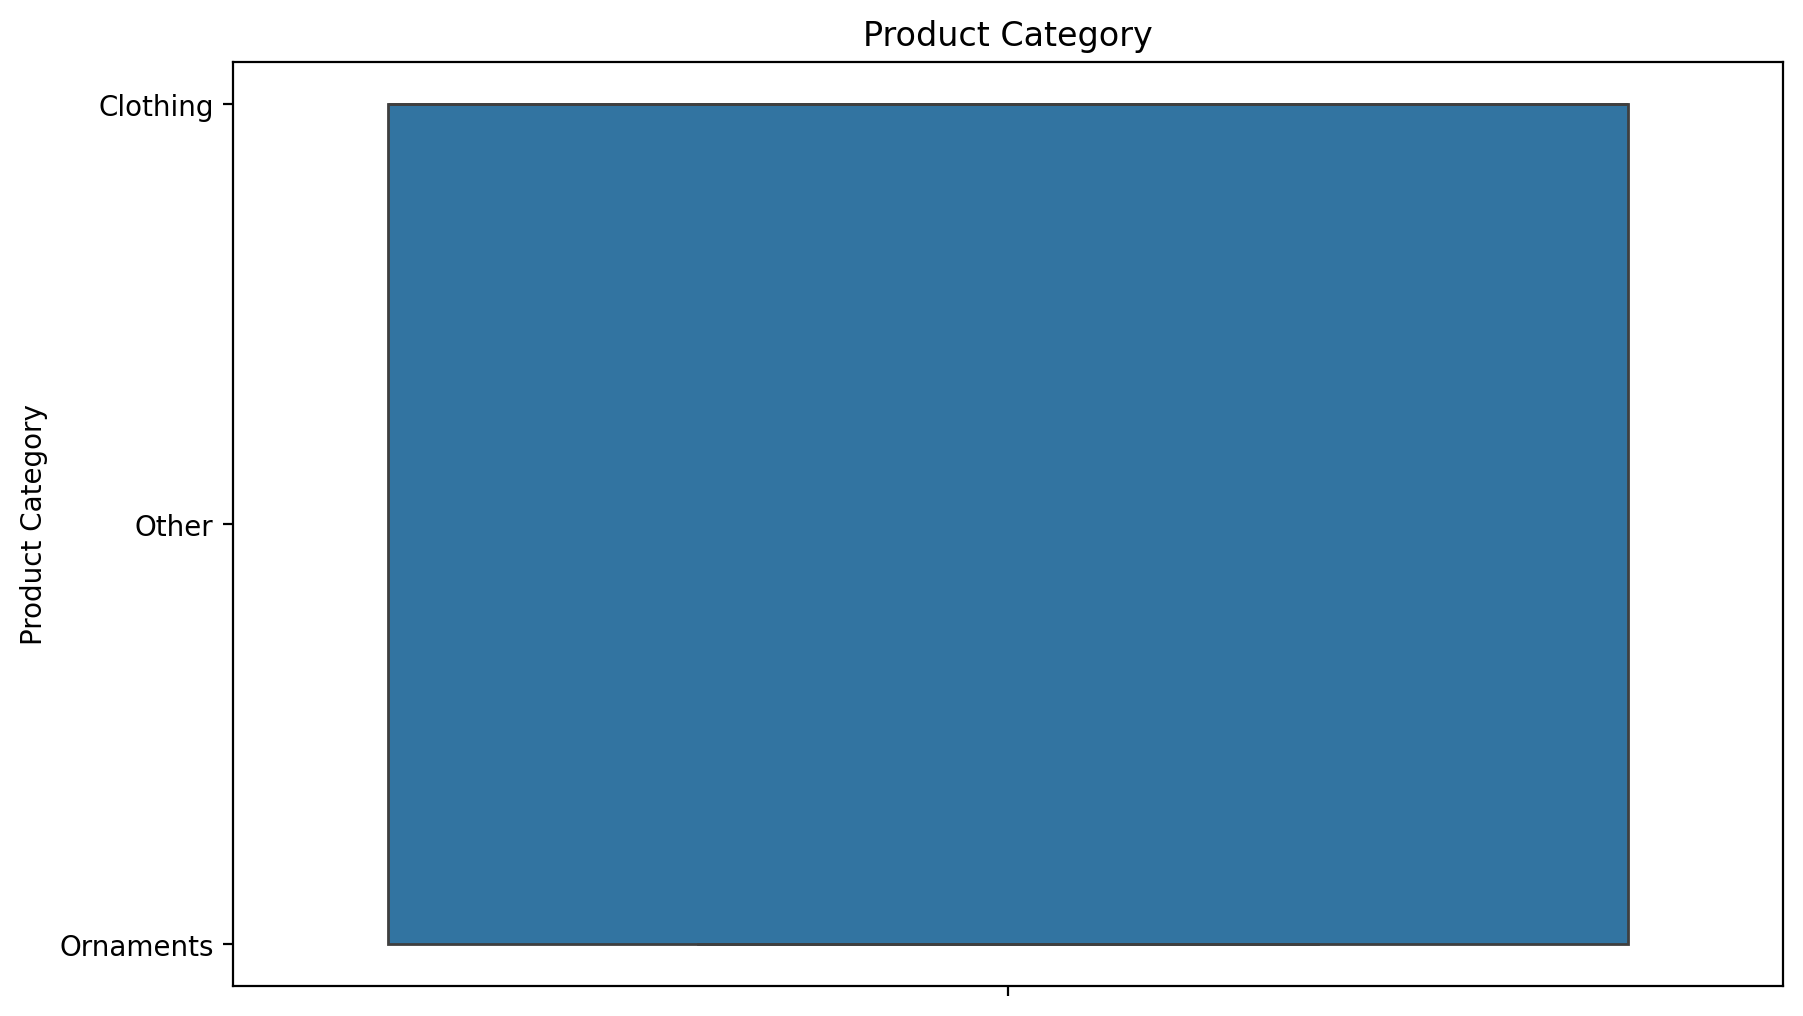

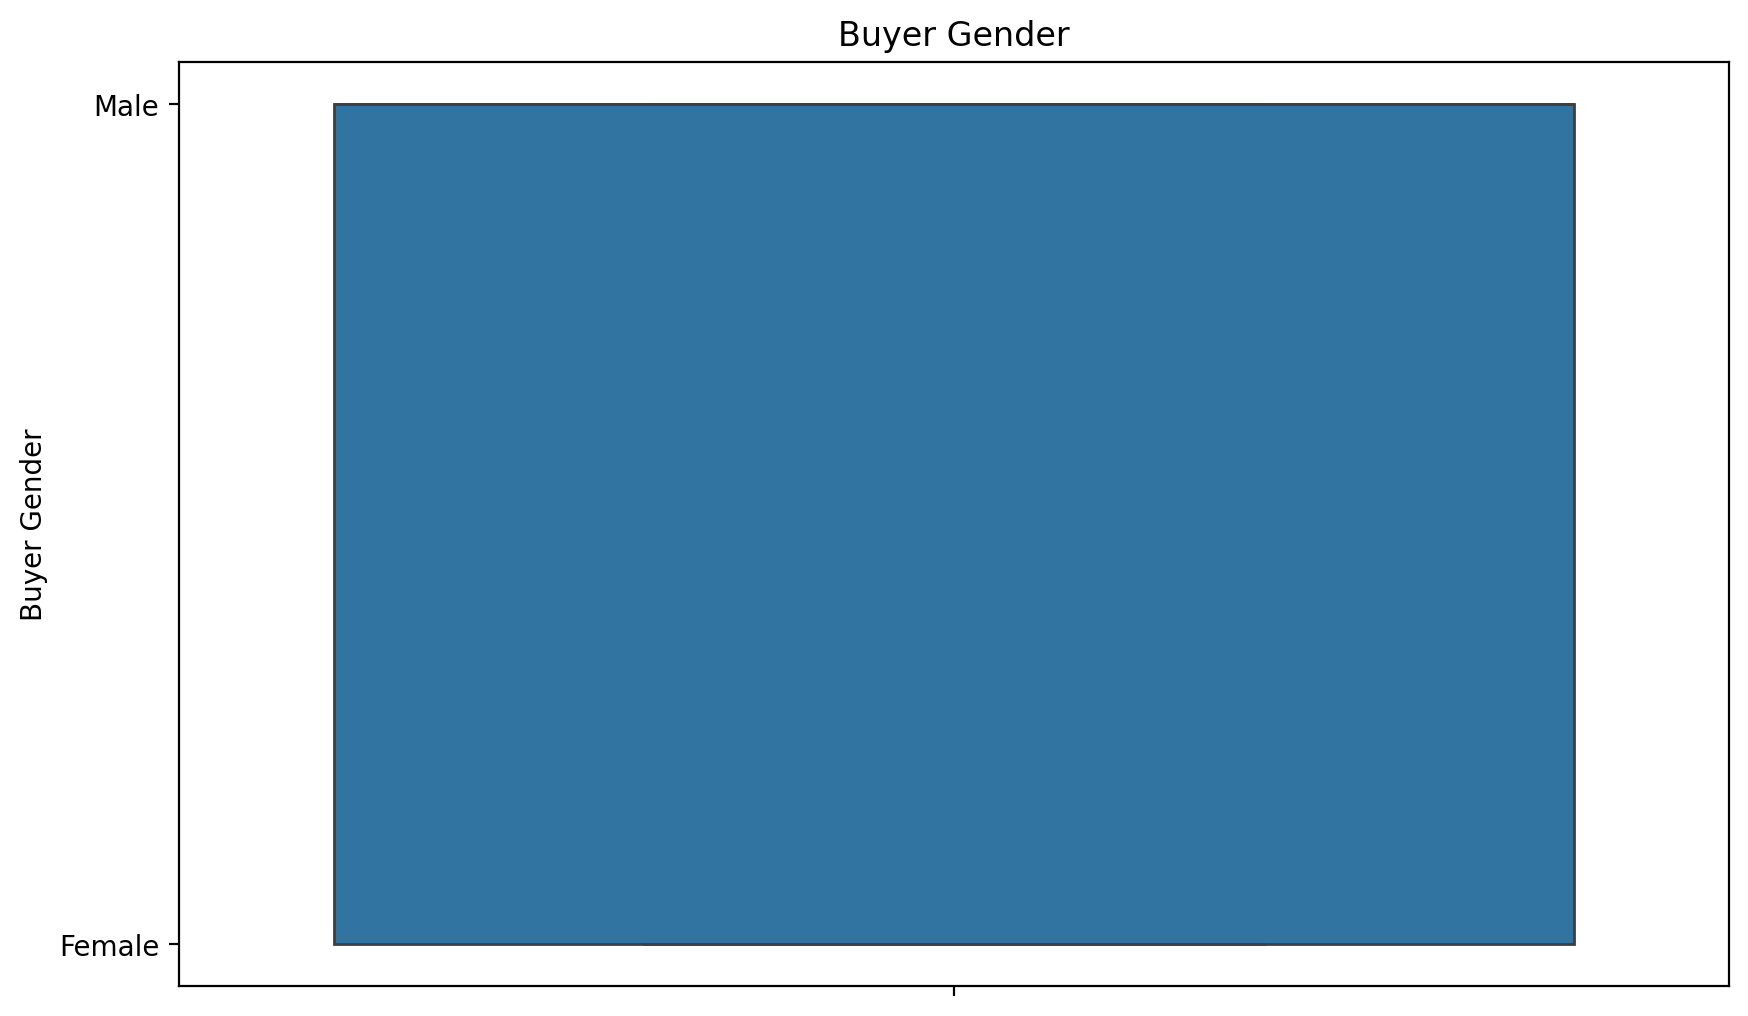

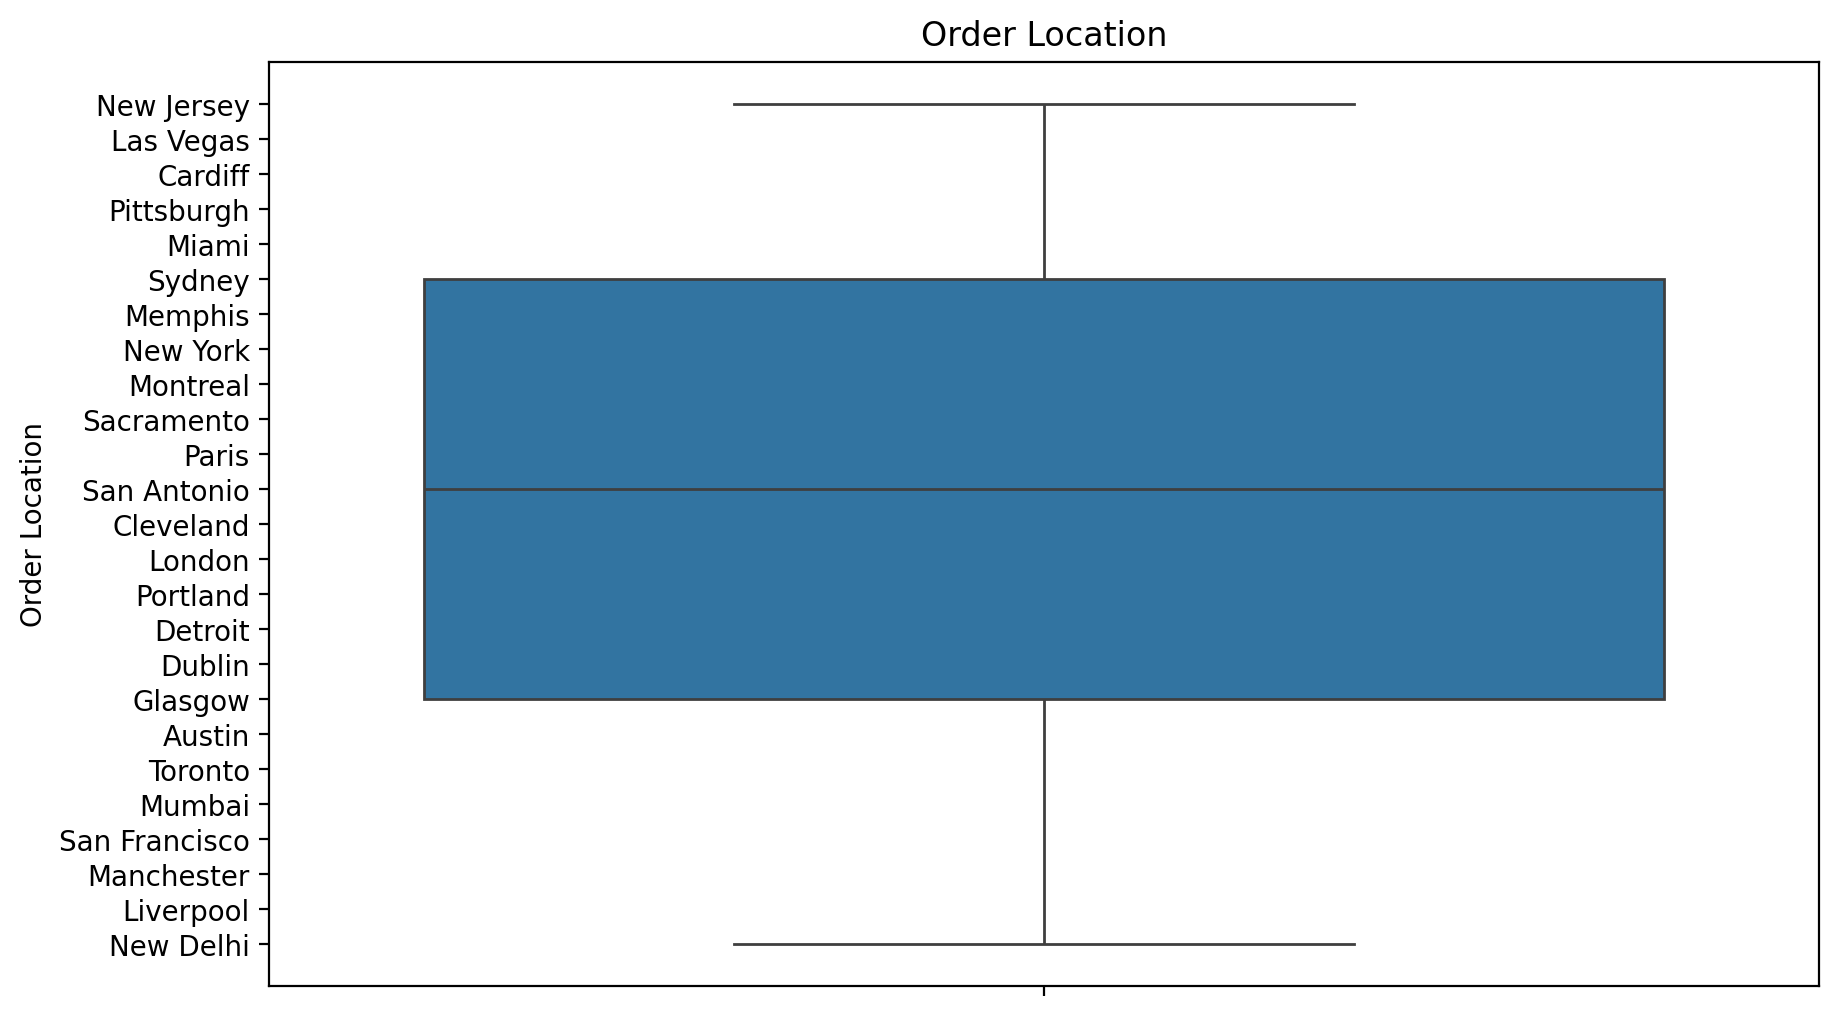

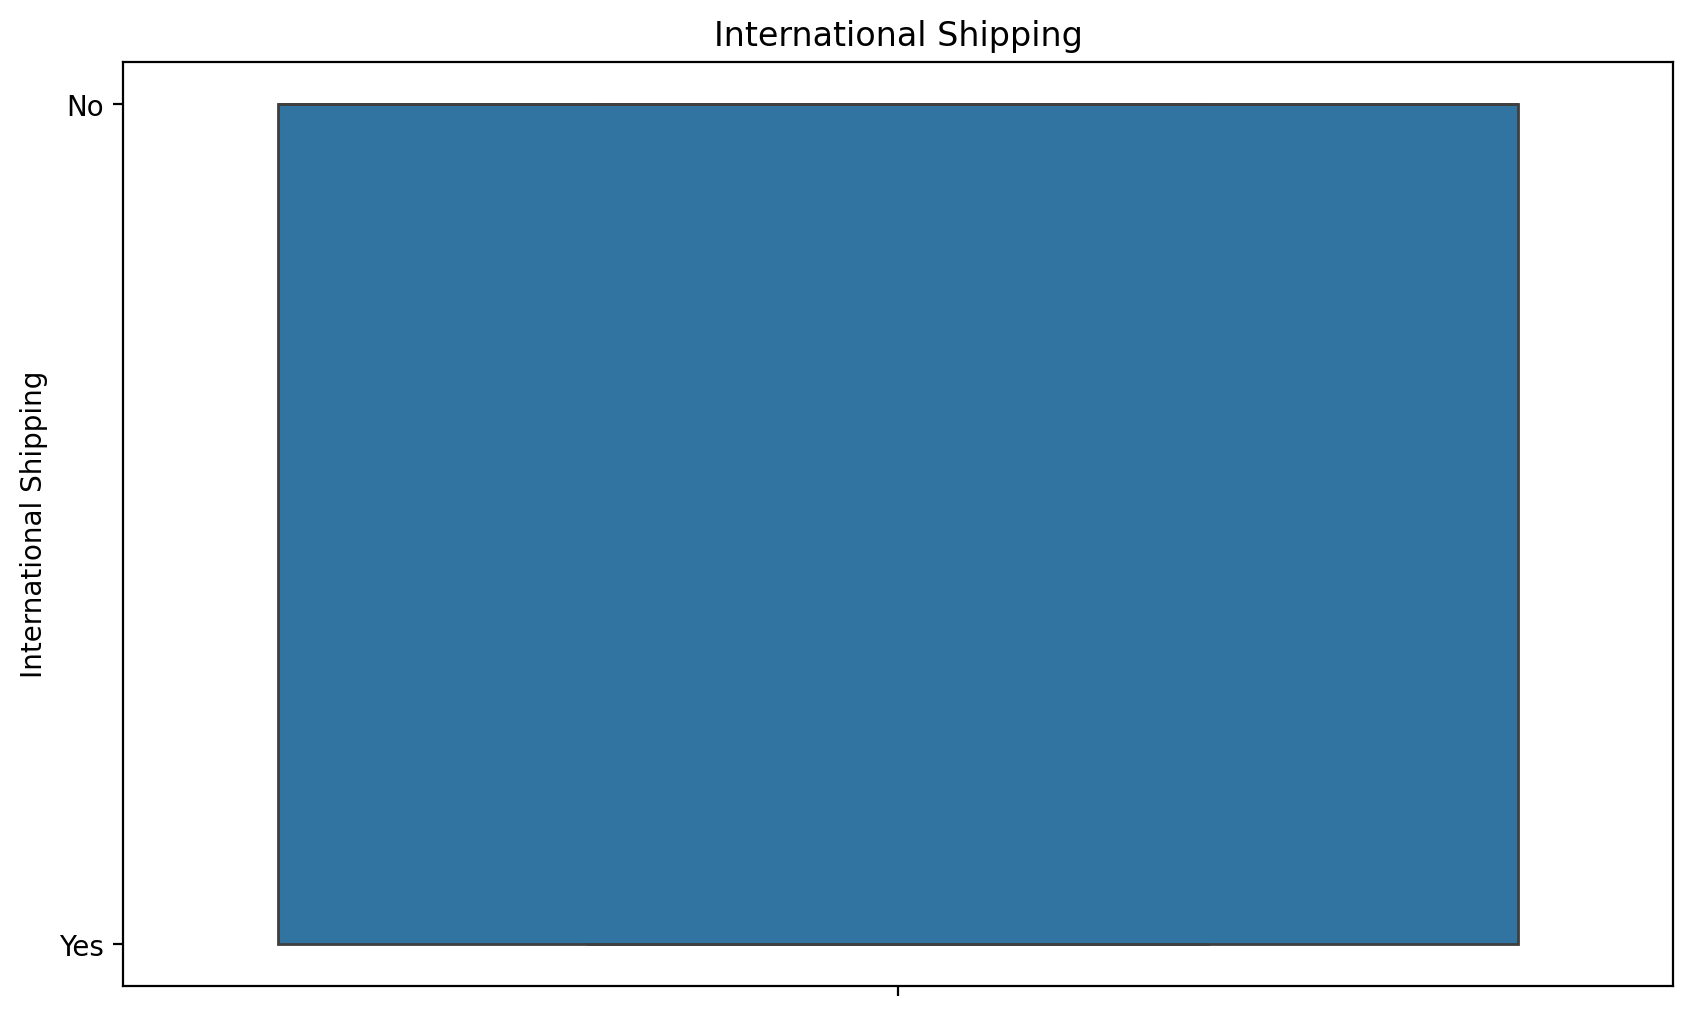

In [ ]:
# plot a boxplot for categorical columns
for column in categorical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.boxplot(df[column])
  plt.title(column)

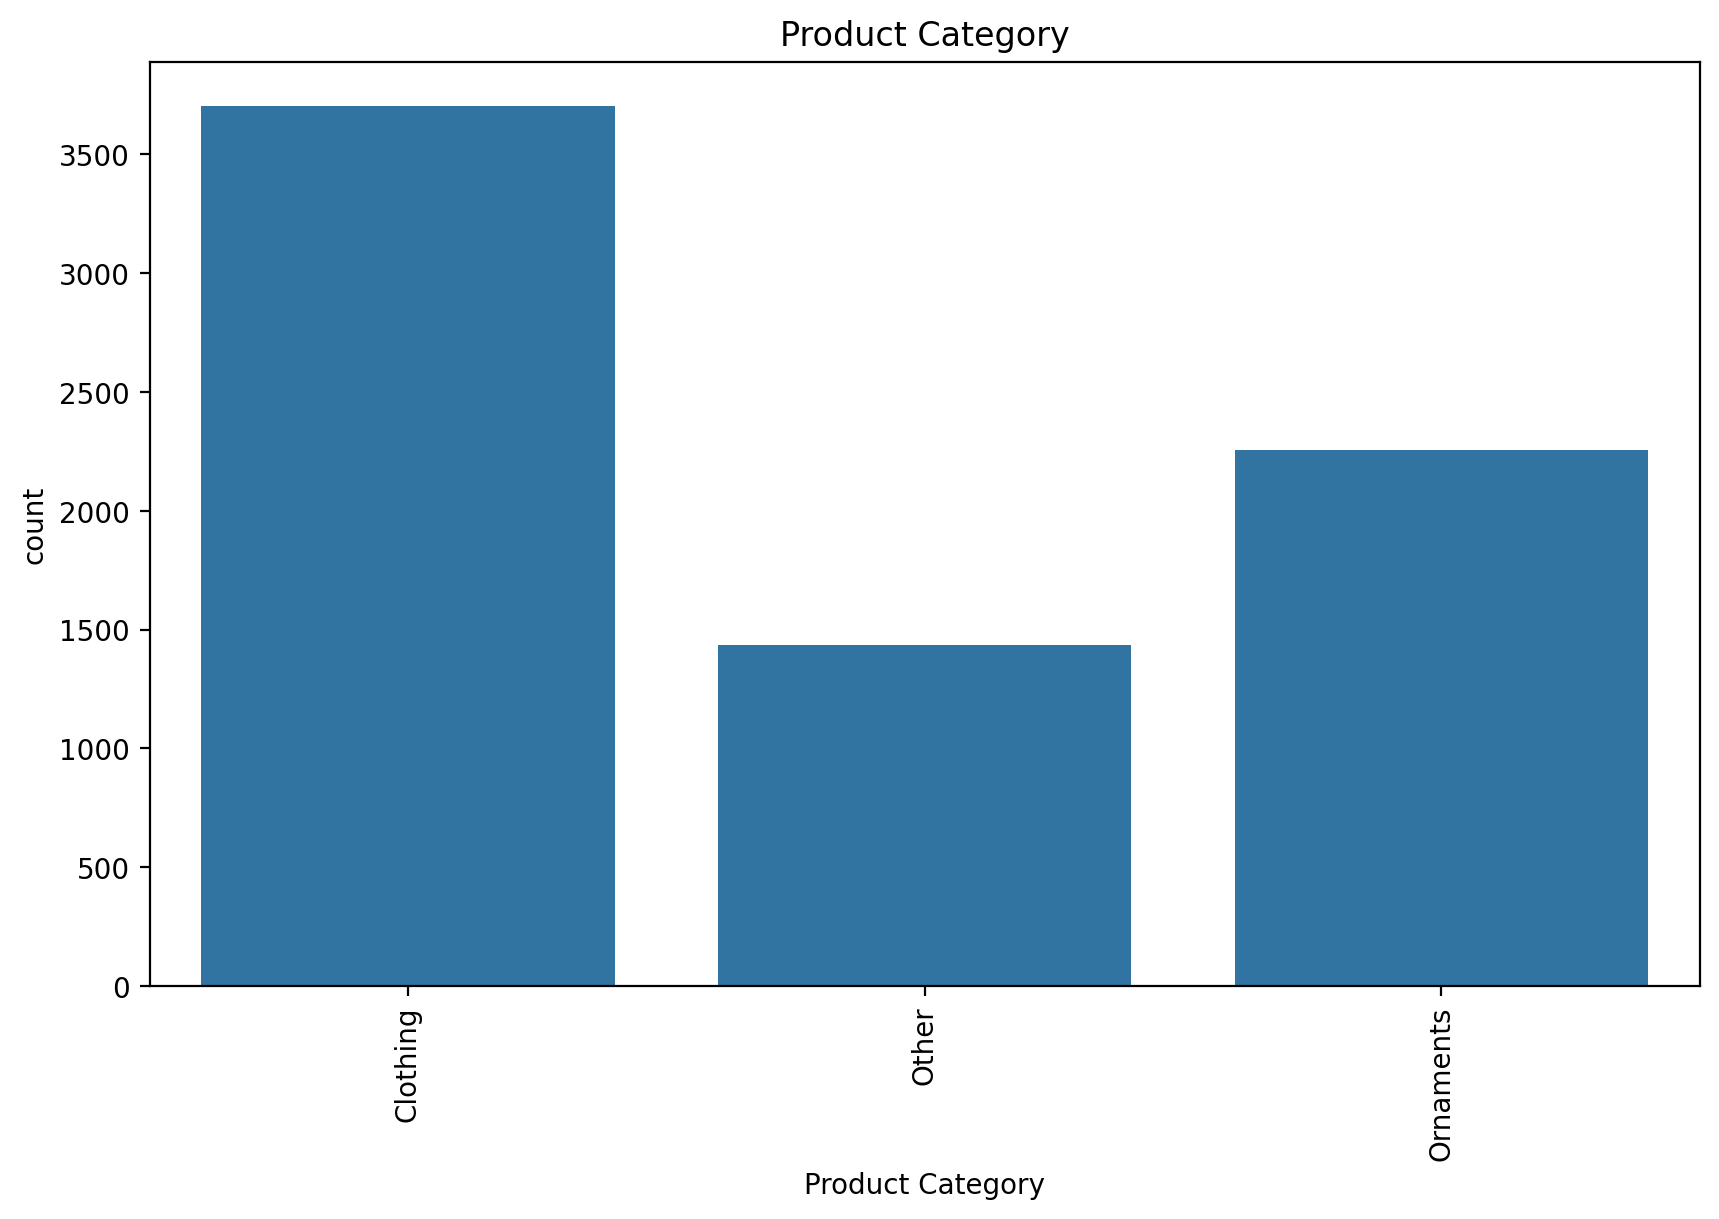

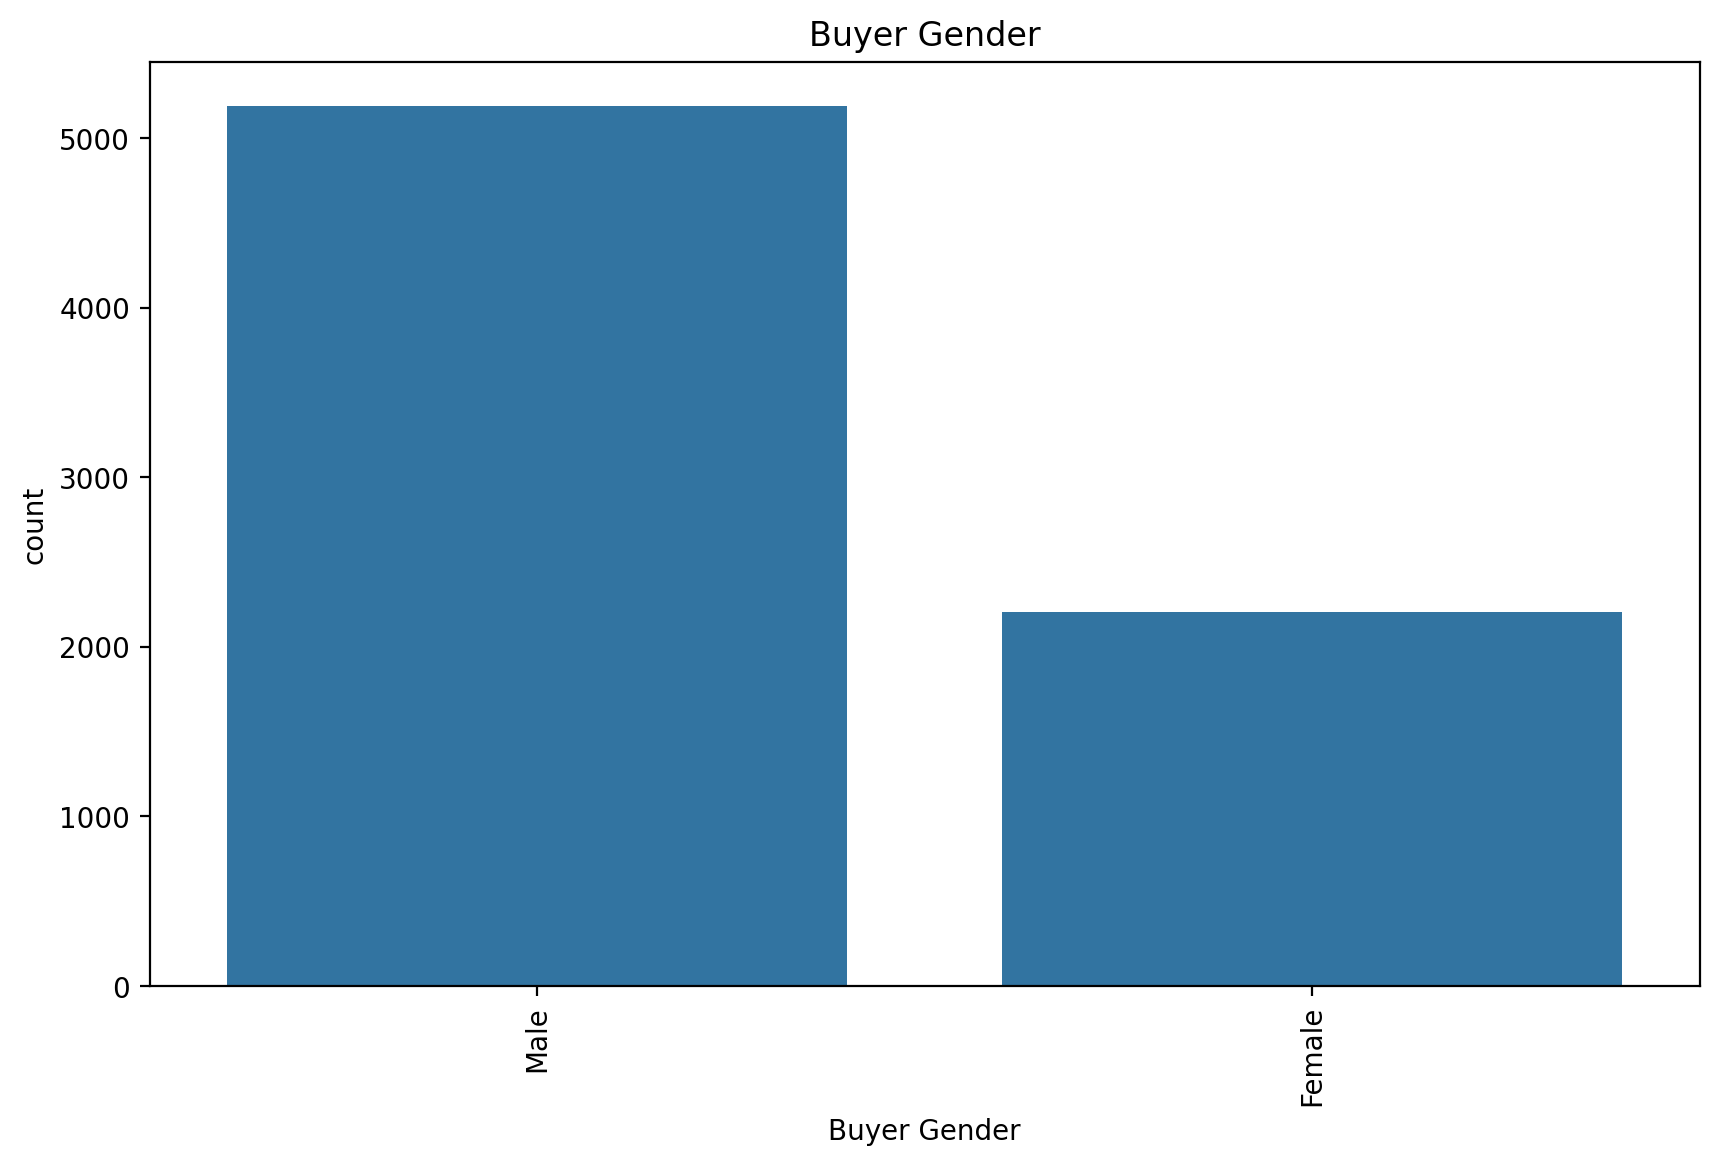

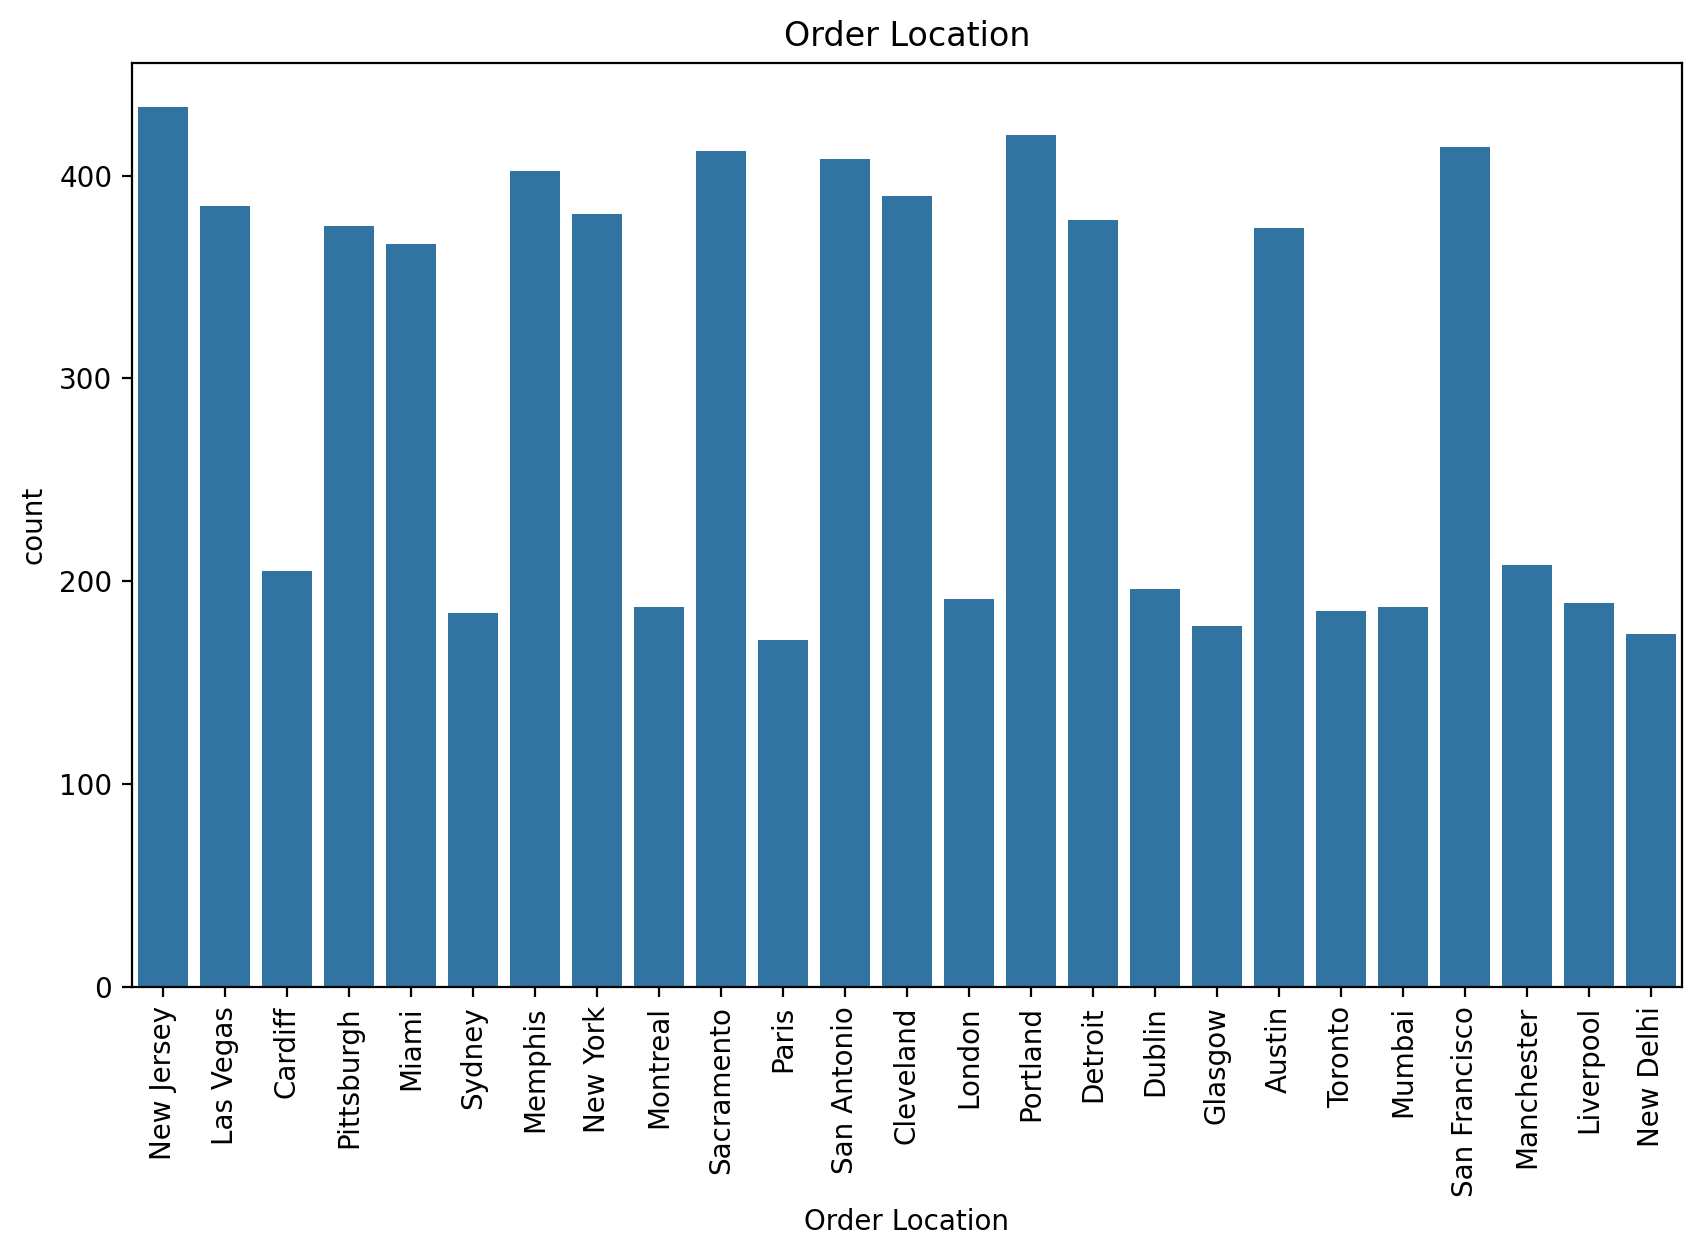

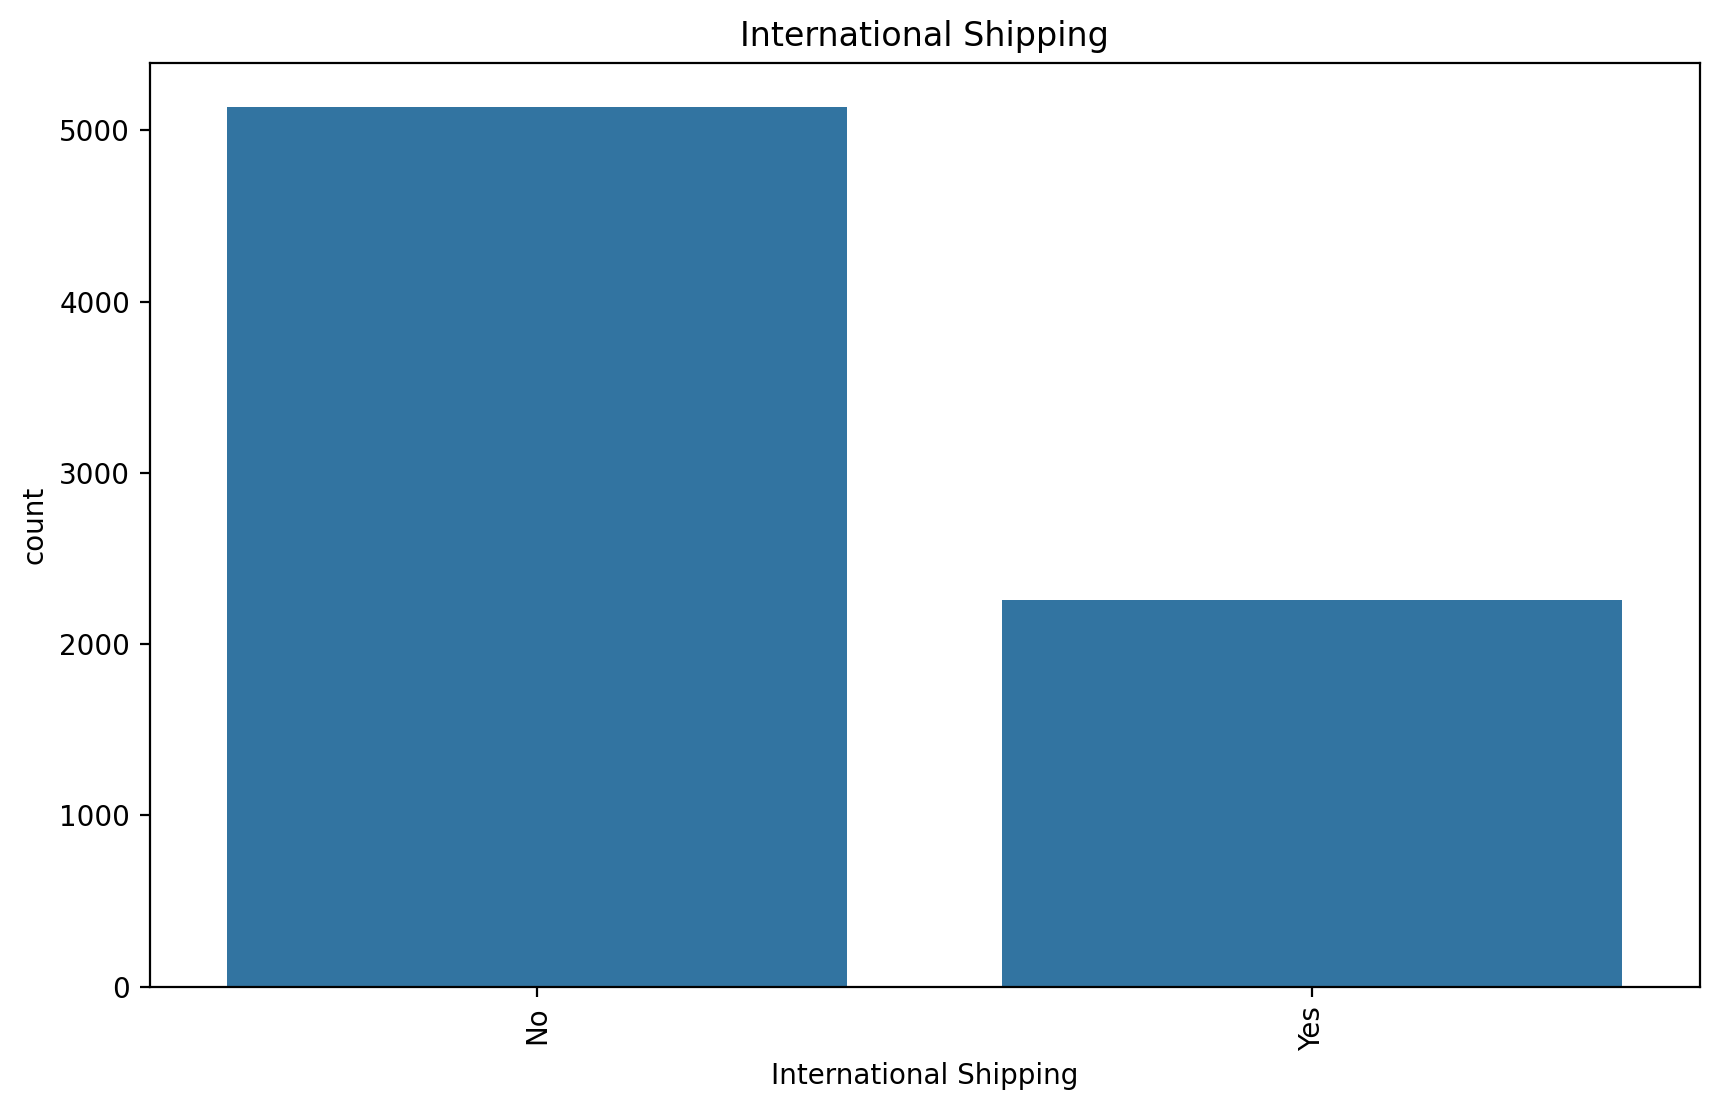

In [ ]:
# plot a count plot for categorical columns
for column in categorical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.countplot(data=df,x=df[column])
  plt.xticks(rotation=90)
  plt.title(column)

### Bivariate Analysis

**Bivariate analysis** is a statistical method that **explores the relationship between two variables.** It aims to determine if there is an **association or correlation between the variables** and the **strength the relationship between that Features.**

In [ ]:
# get all the column names
df.columns

Index(['Product Category', 'Buyer Gender', 'Buyer Age', 'Order Location',
       'International Shipping', 'Sales Price', 'Shipping Charges',
       'Sales per Unit', 'Quantity', 'Total Sales', 'Rating', 'Year', 'Month',
       'Day'],
      dtype='object')

In [ ]:
# get all the features
features = df.drop(['Total Sales'],axis=1)
features.columns

Index(['Product Category', 'Buyer Gender', 'Buyer Age', 'Order Location',
       'International Shipping', 'Sales Price', 'Shipping Charges',
       'Sales per Unit', 'Quantity', 'Rating', 'Year', 'Month', 'Day'],
      dtype='object')

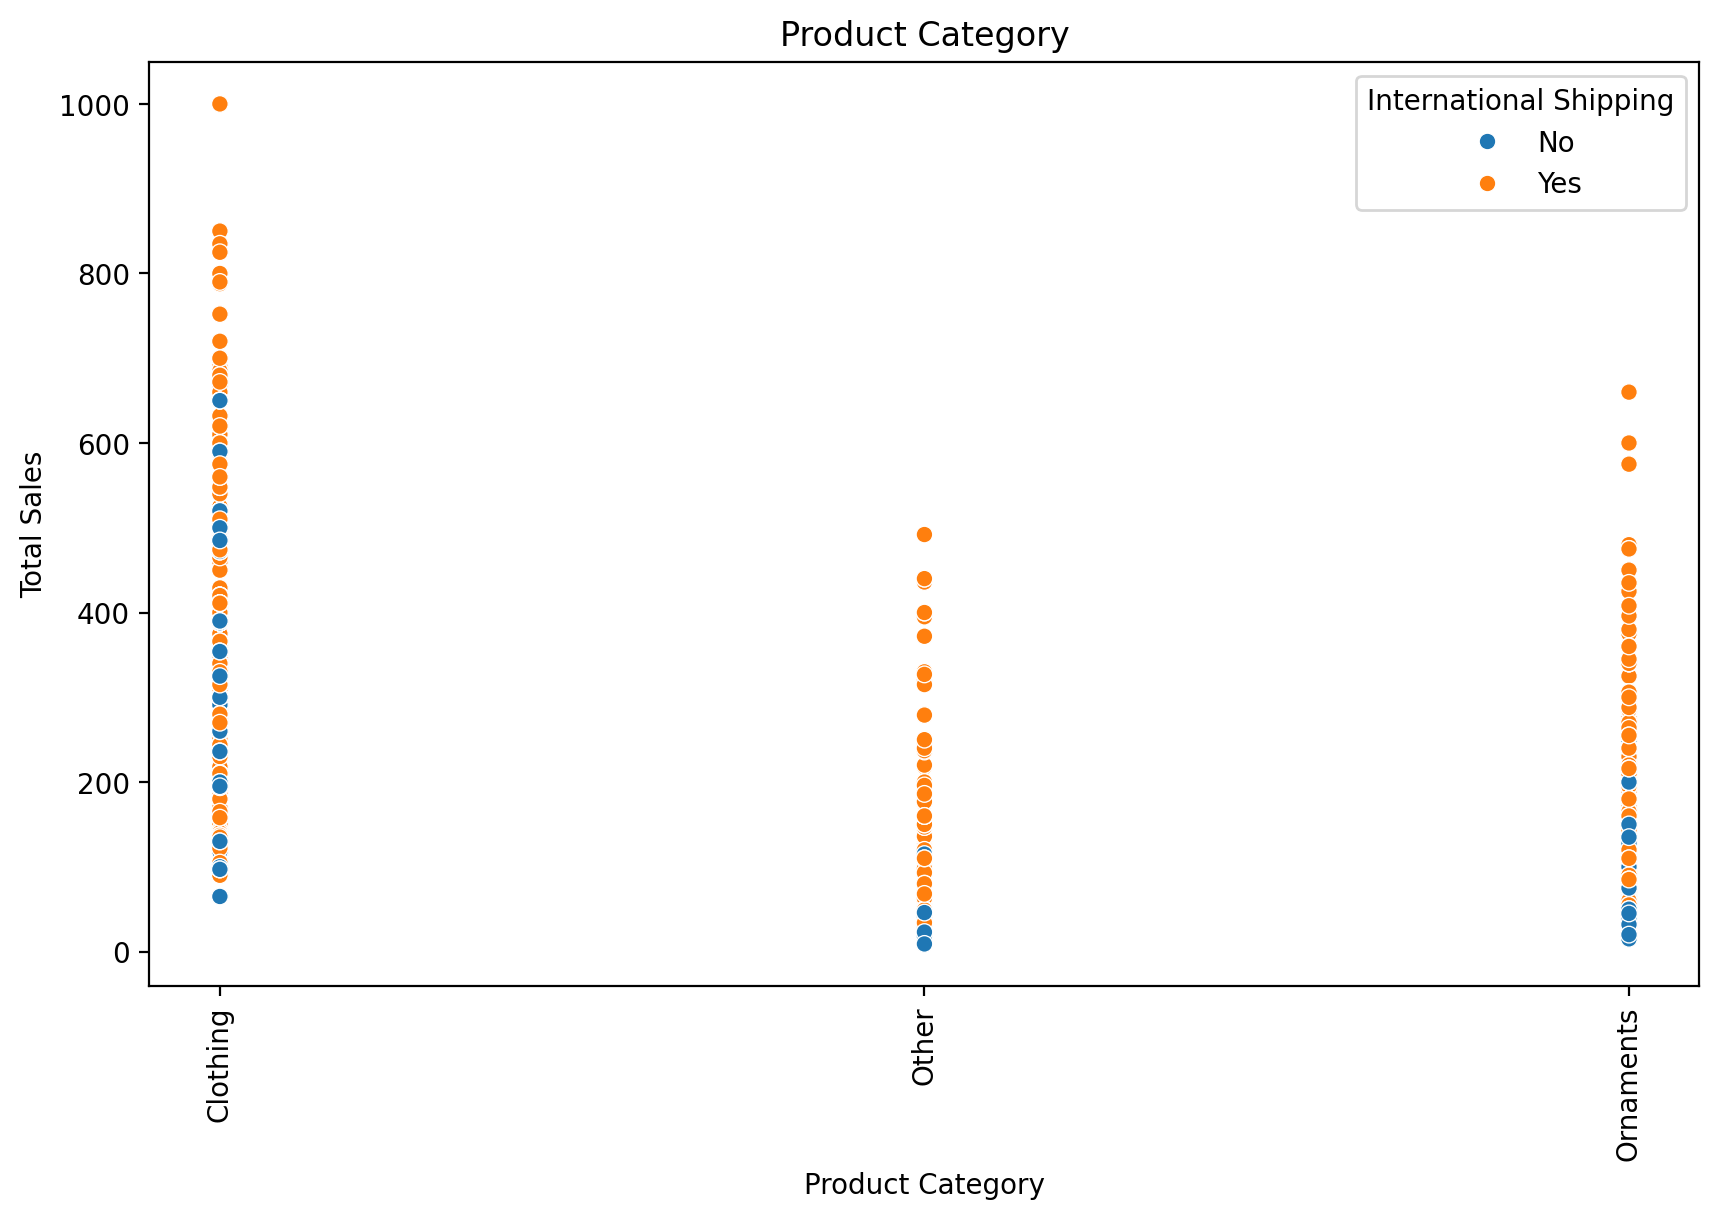

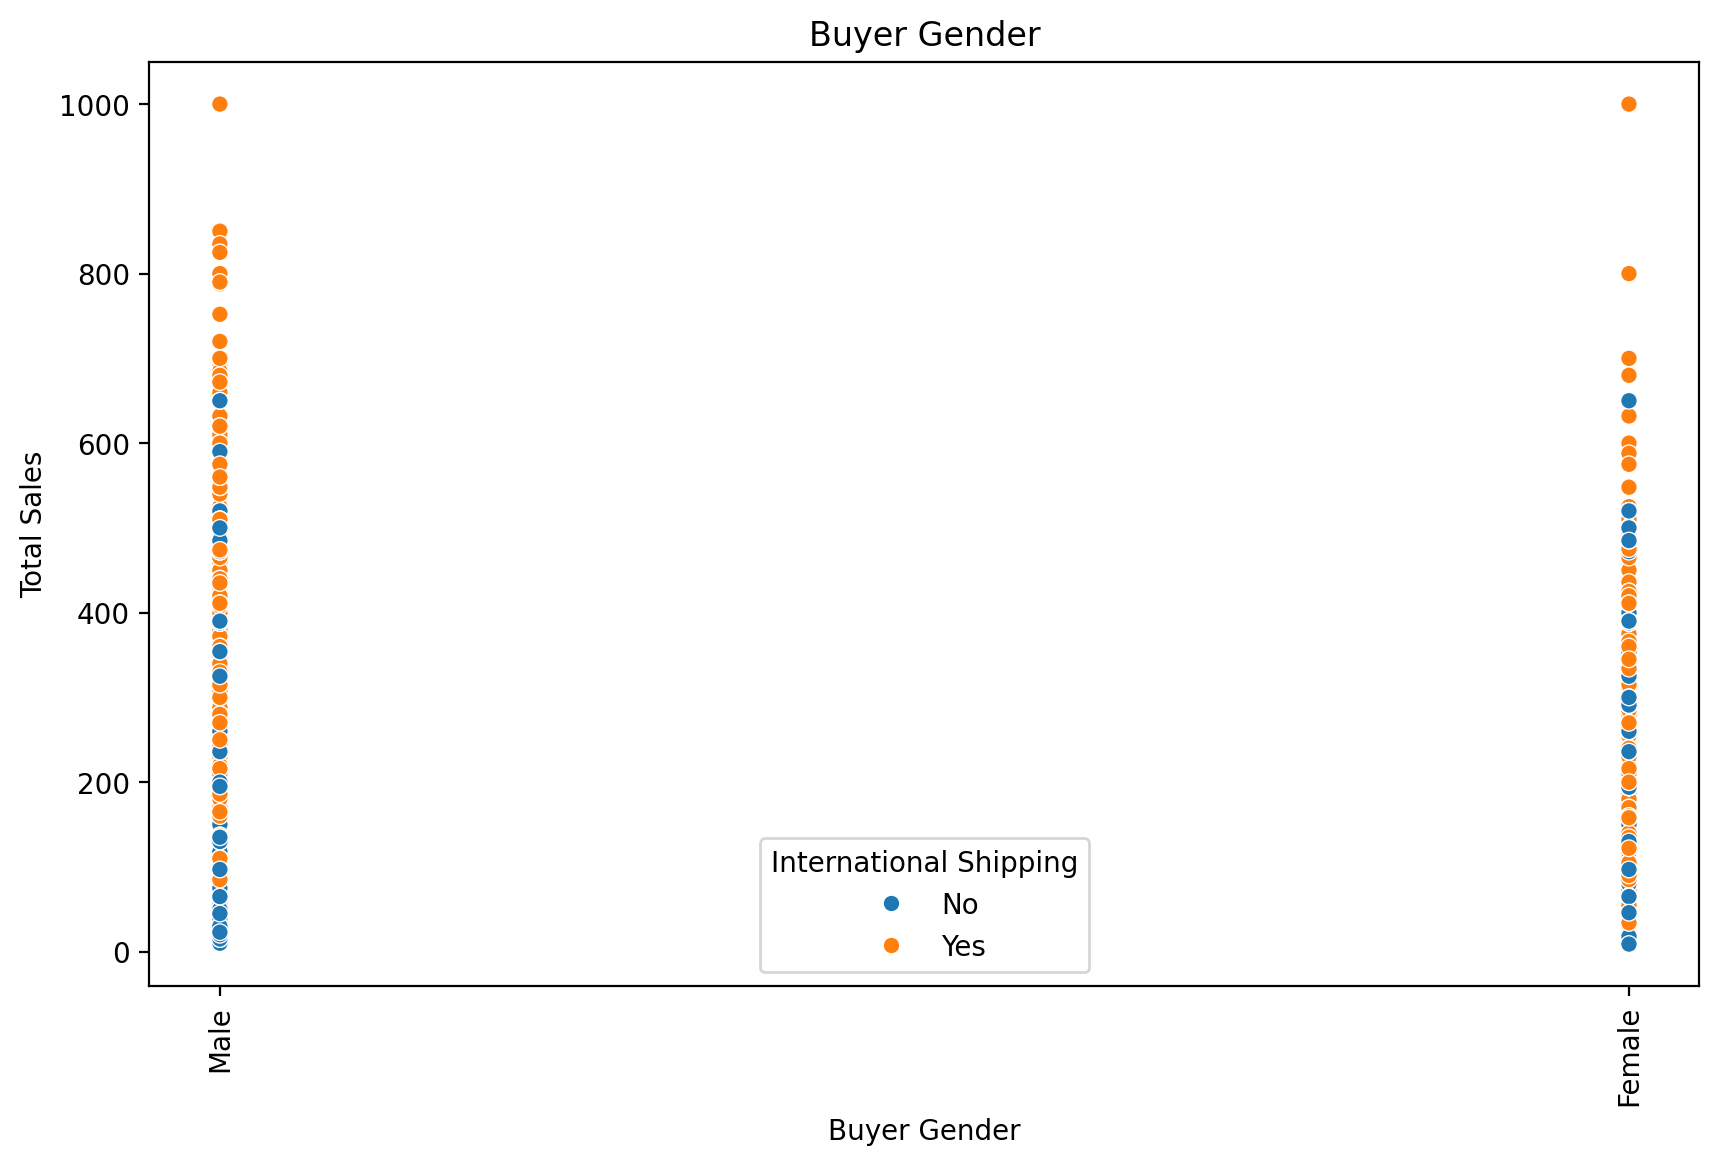

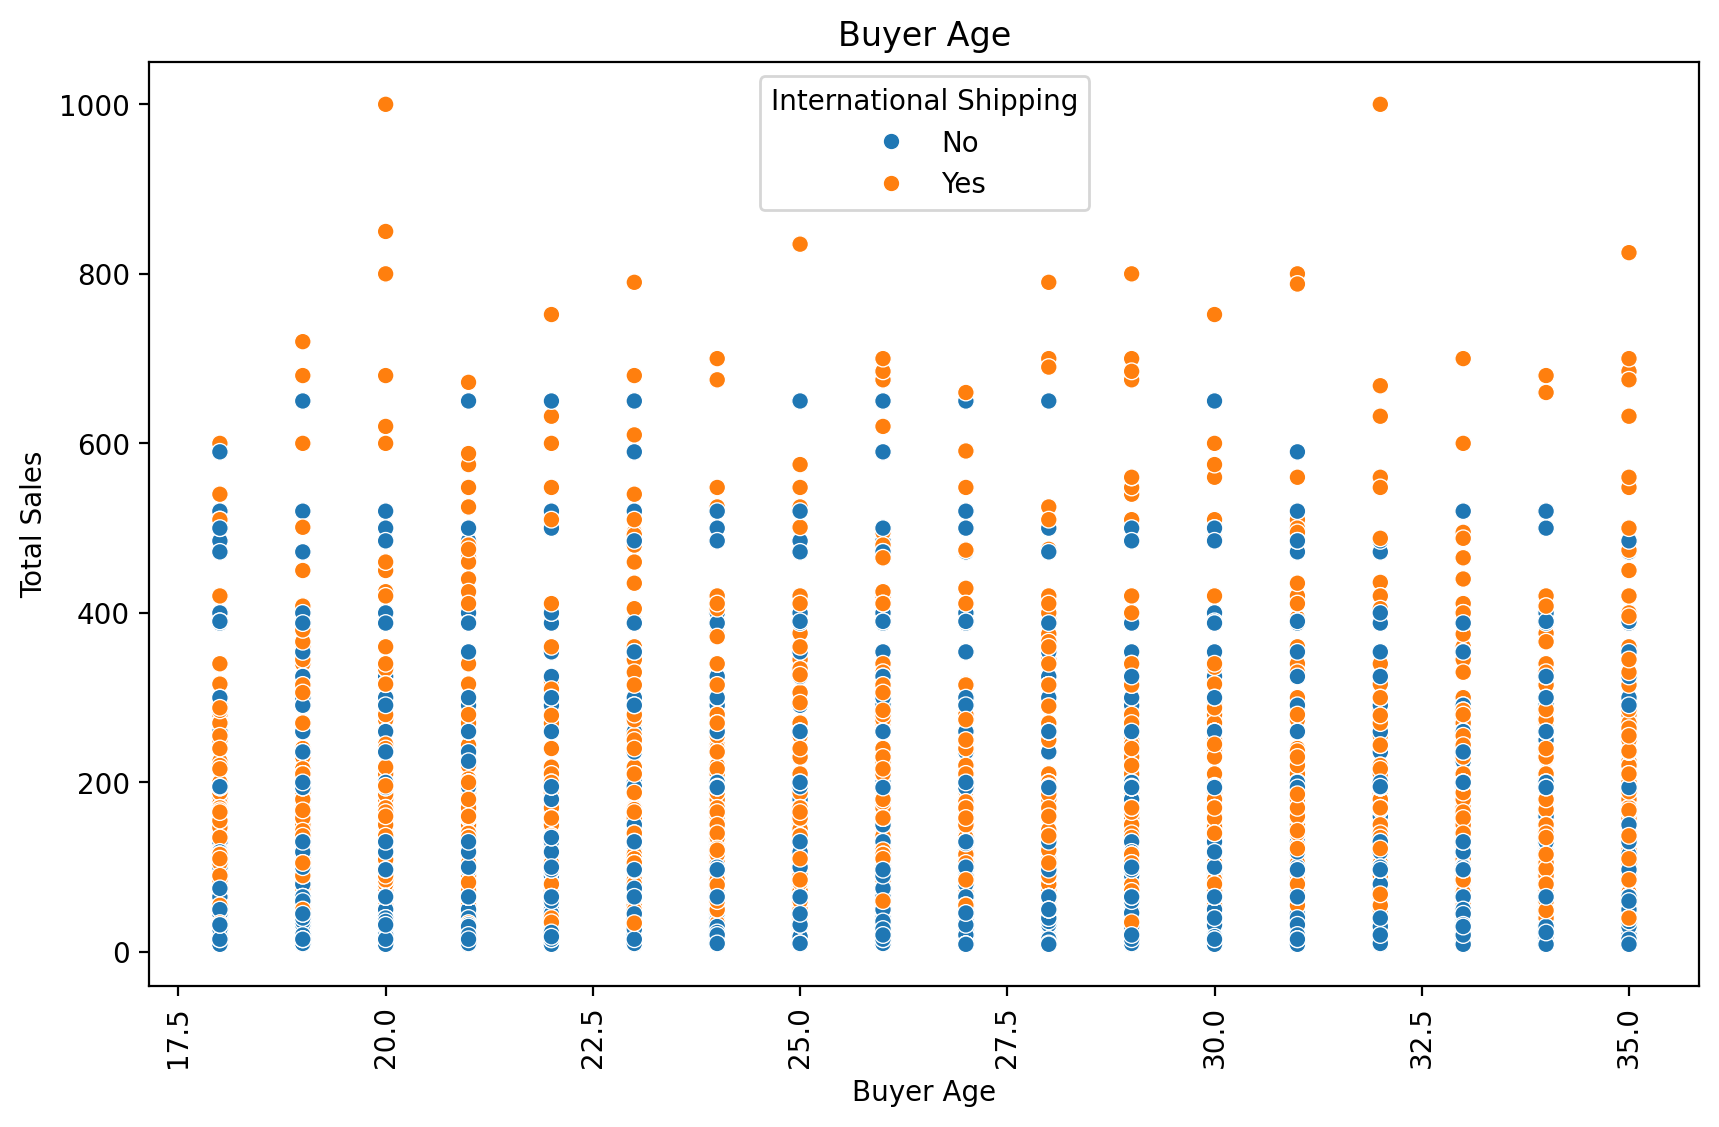

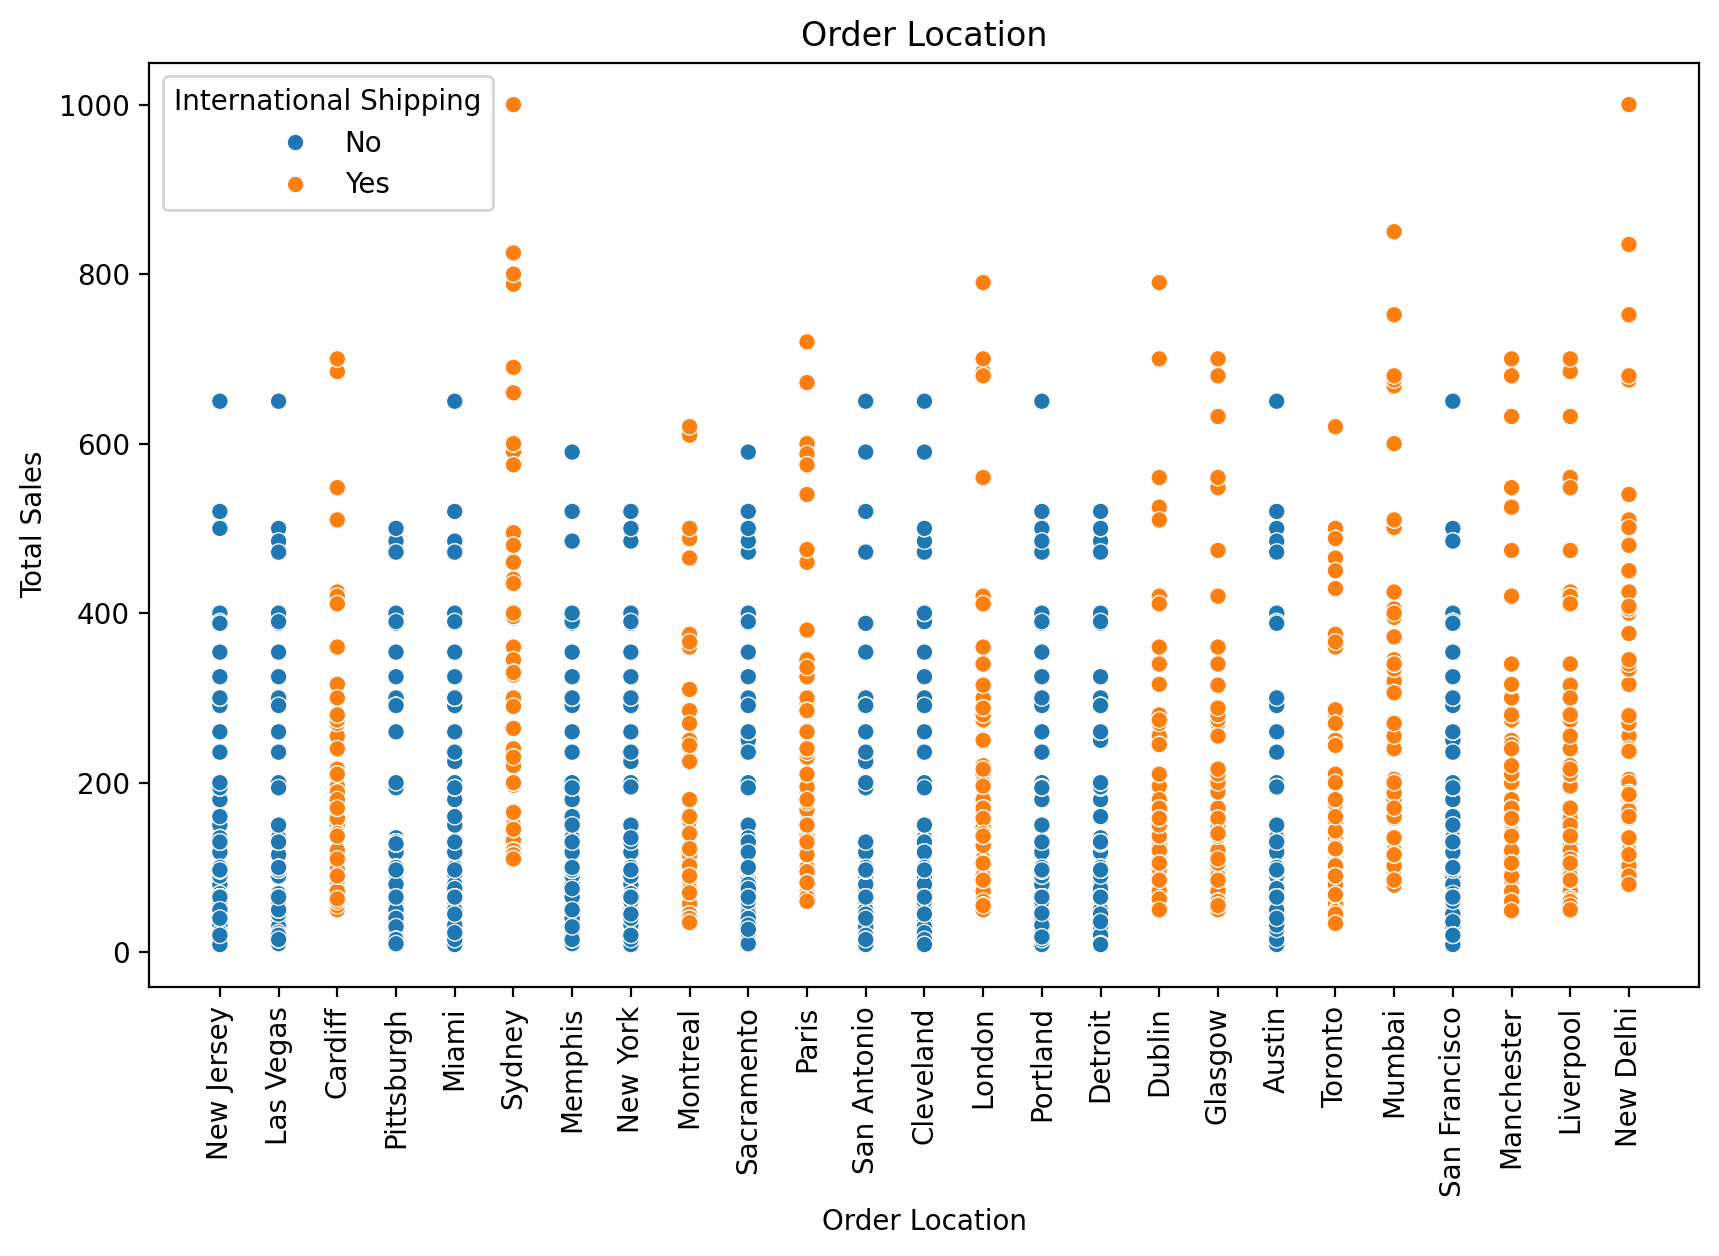

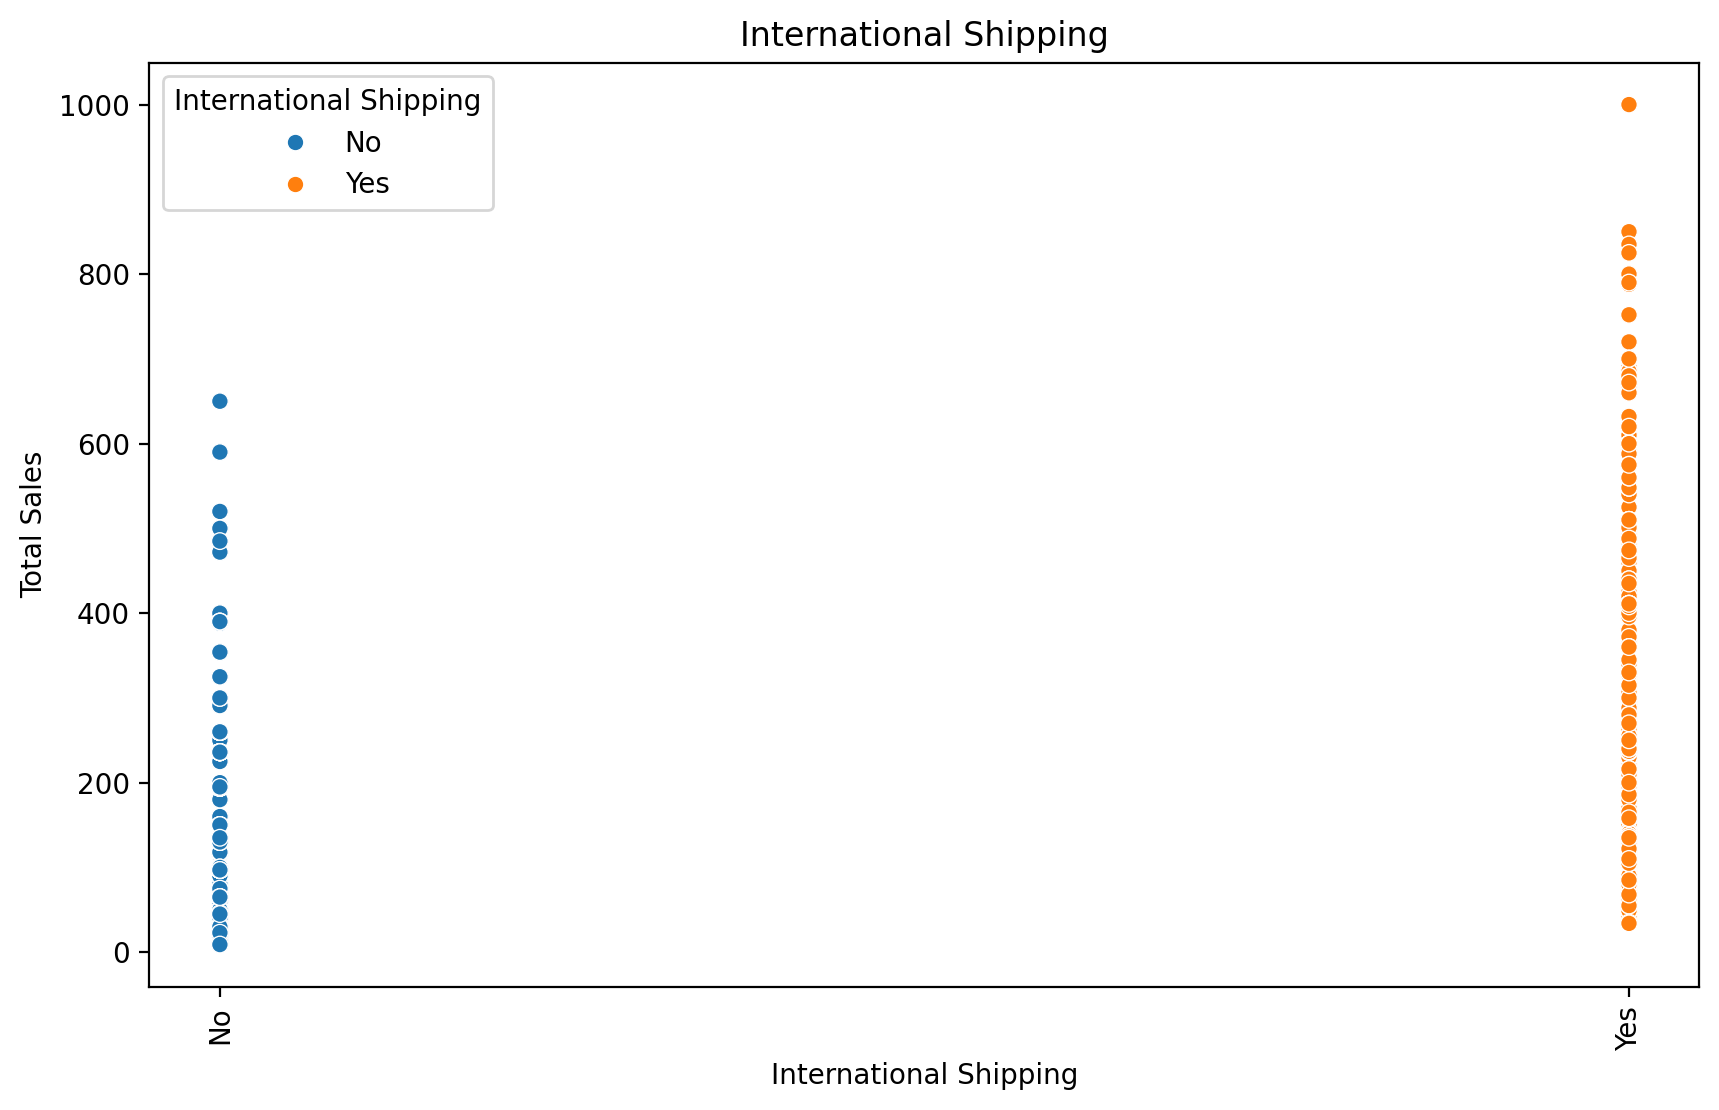

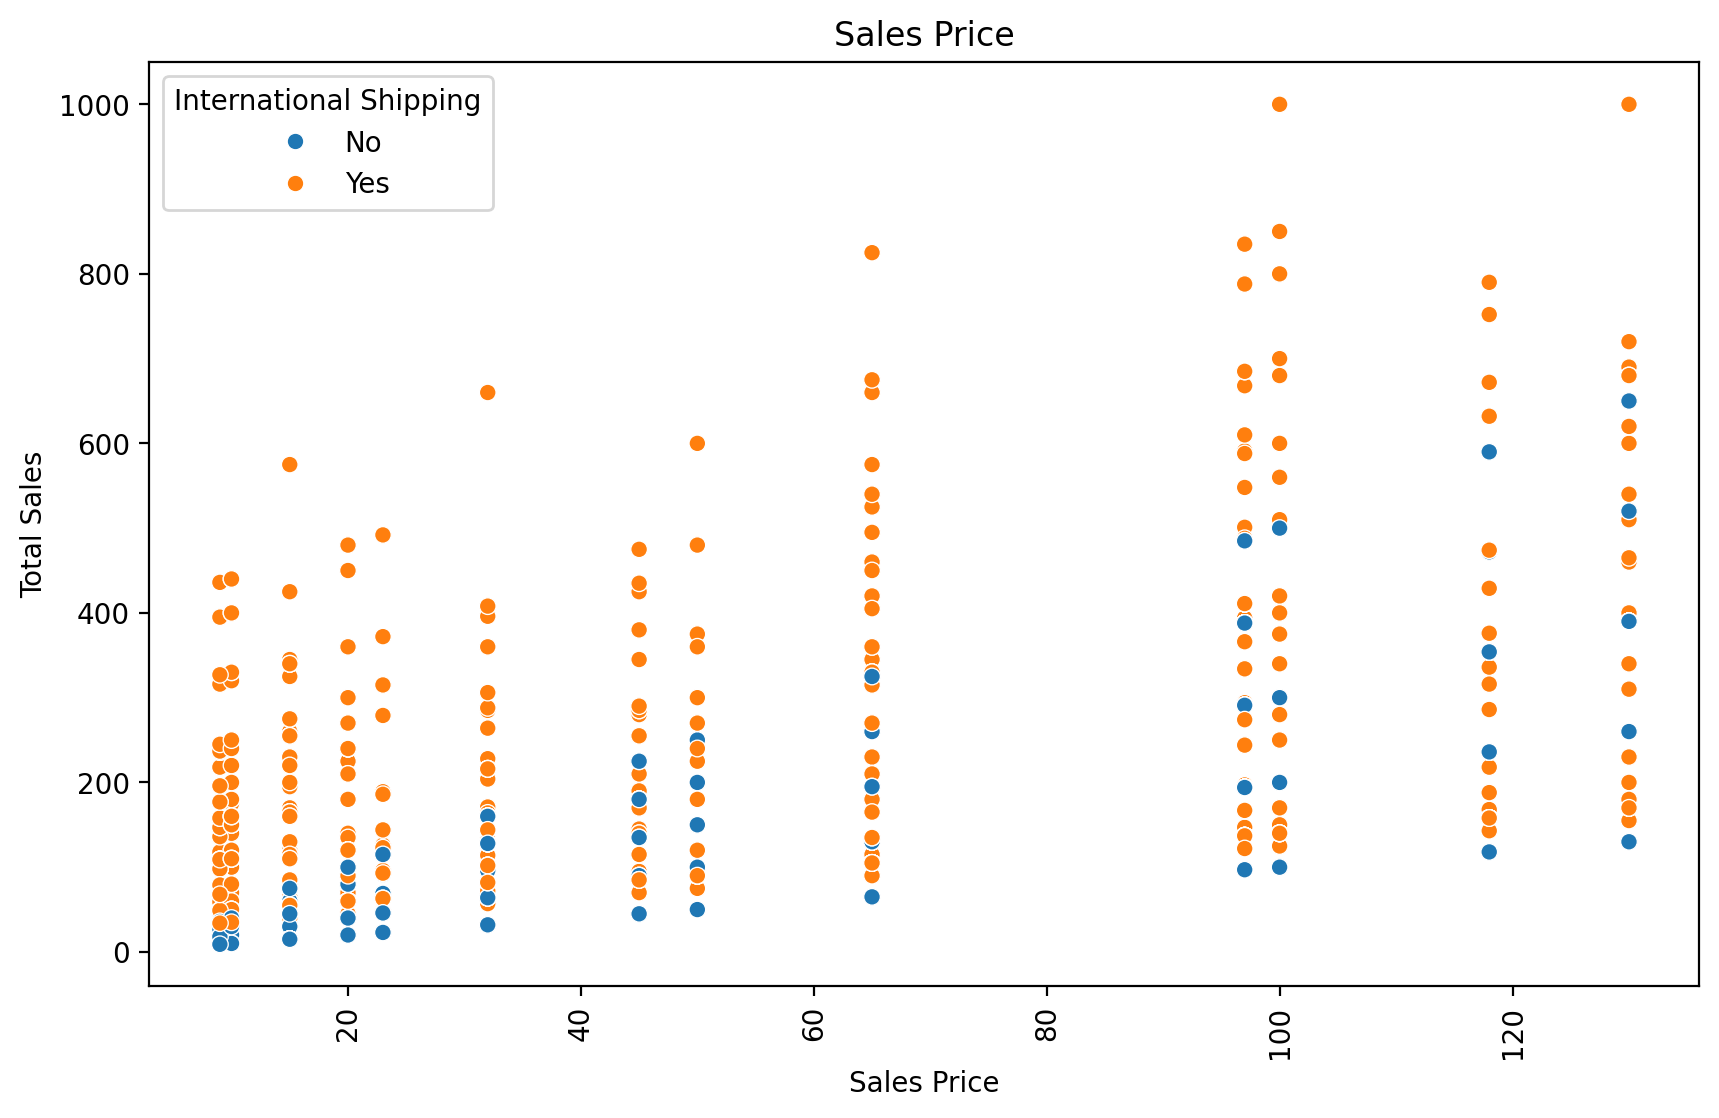

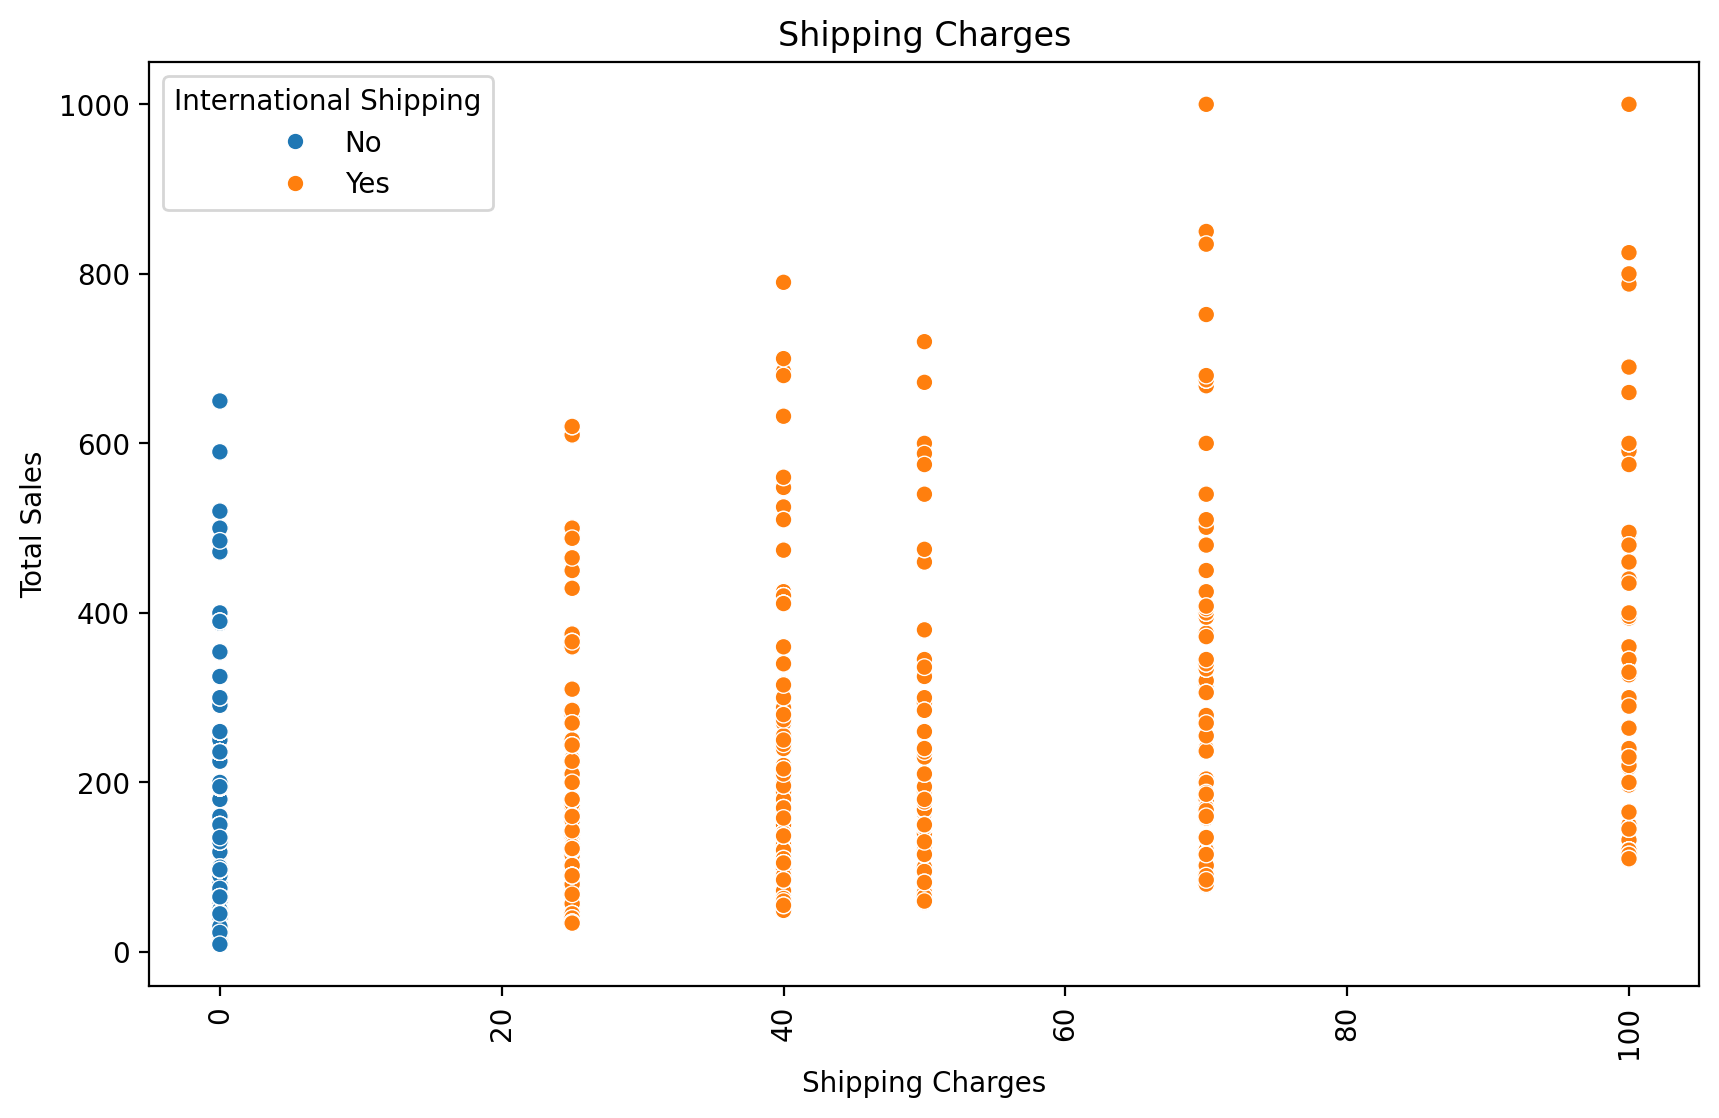

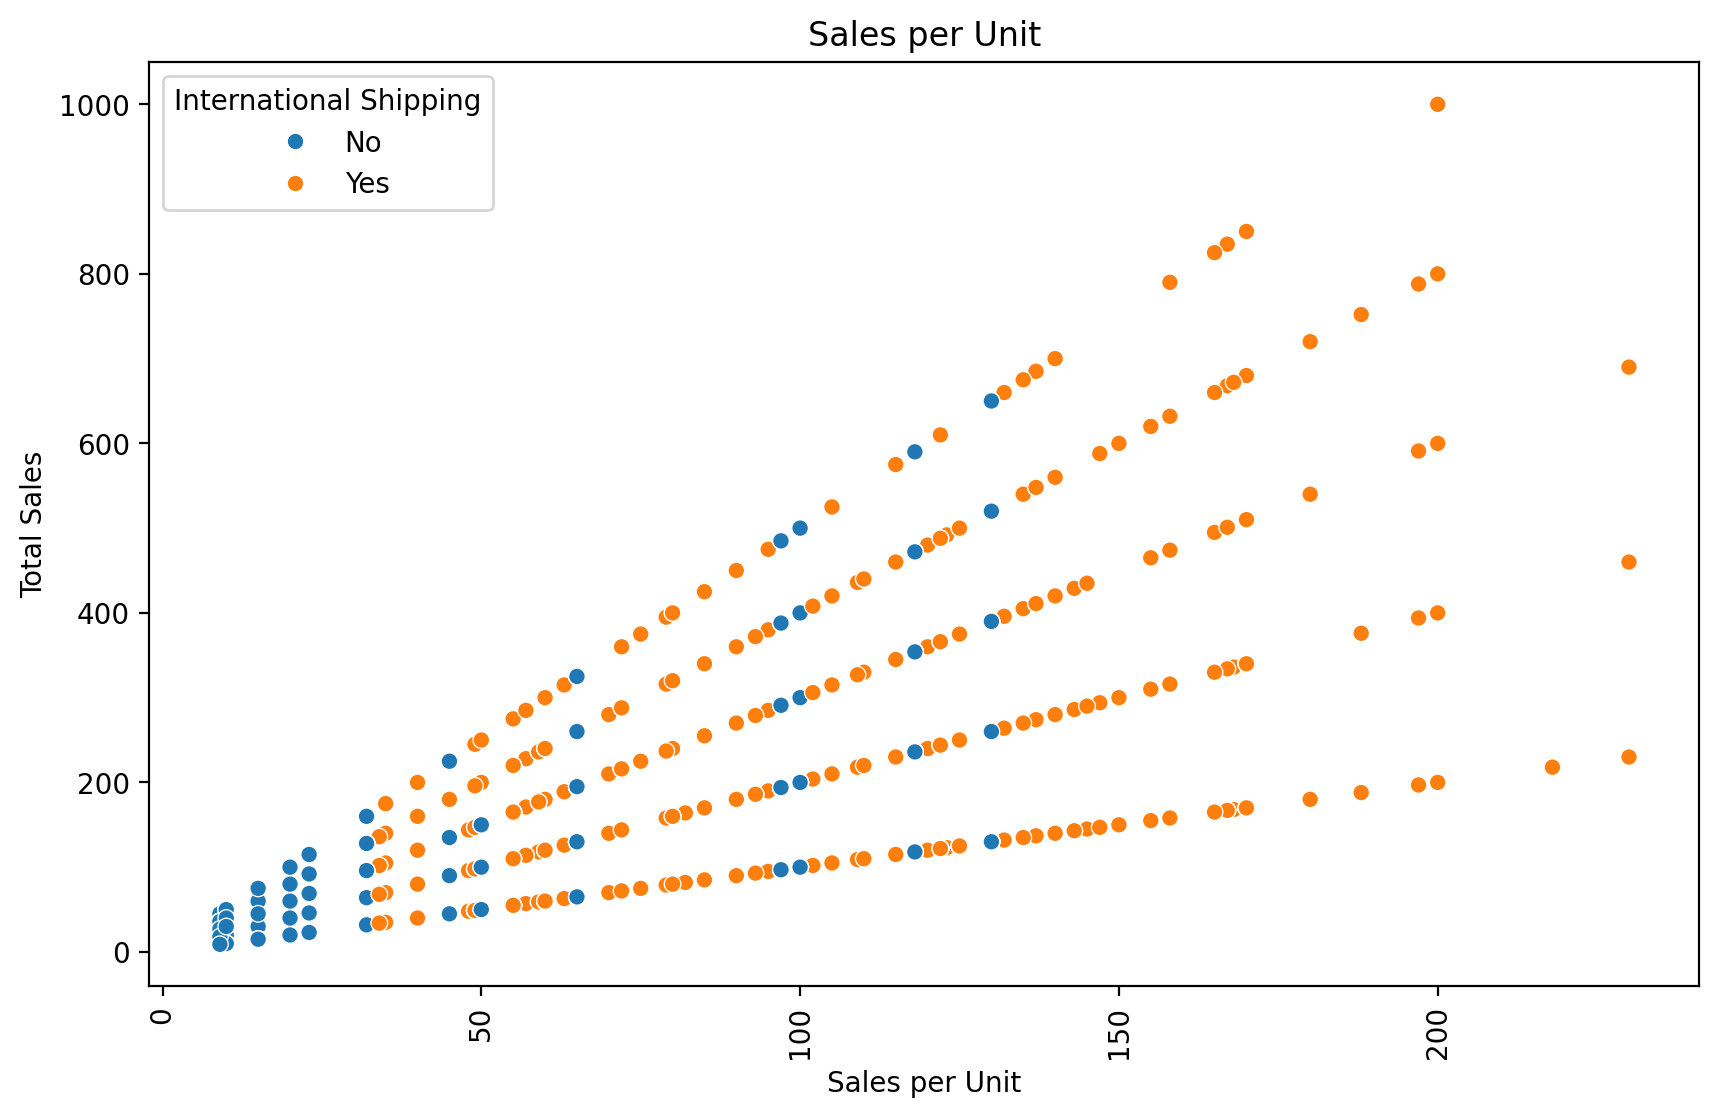

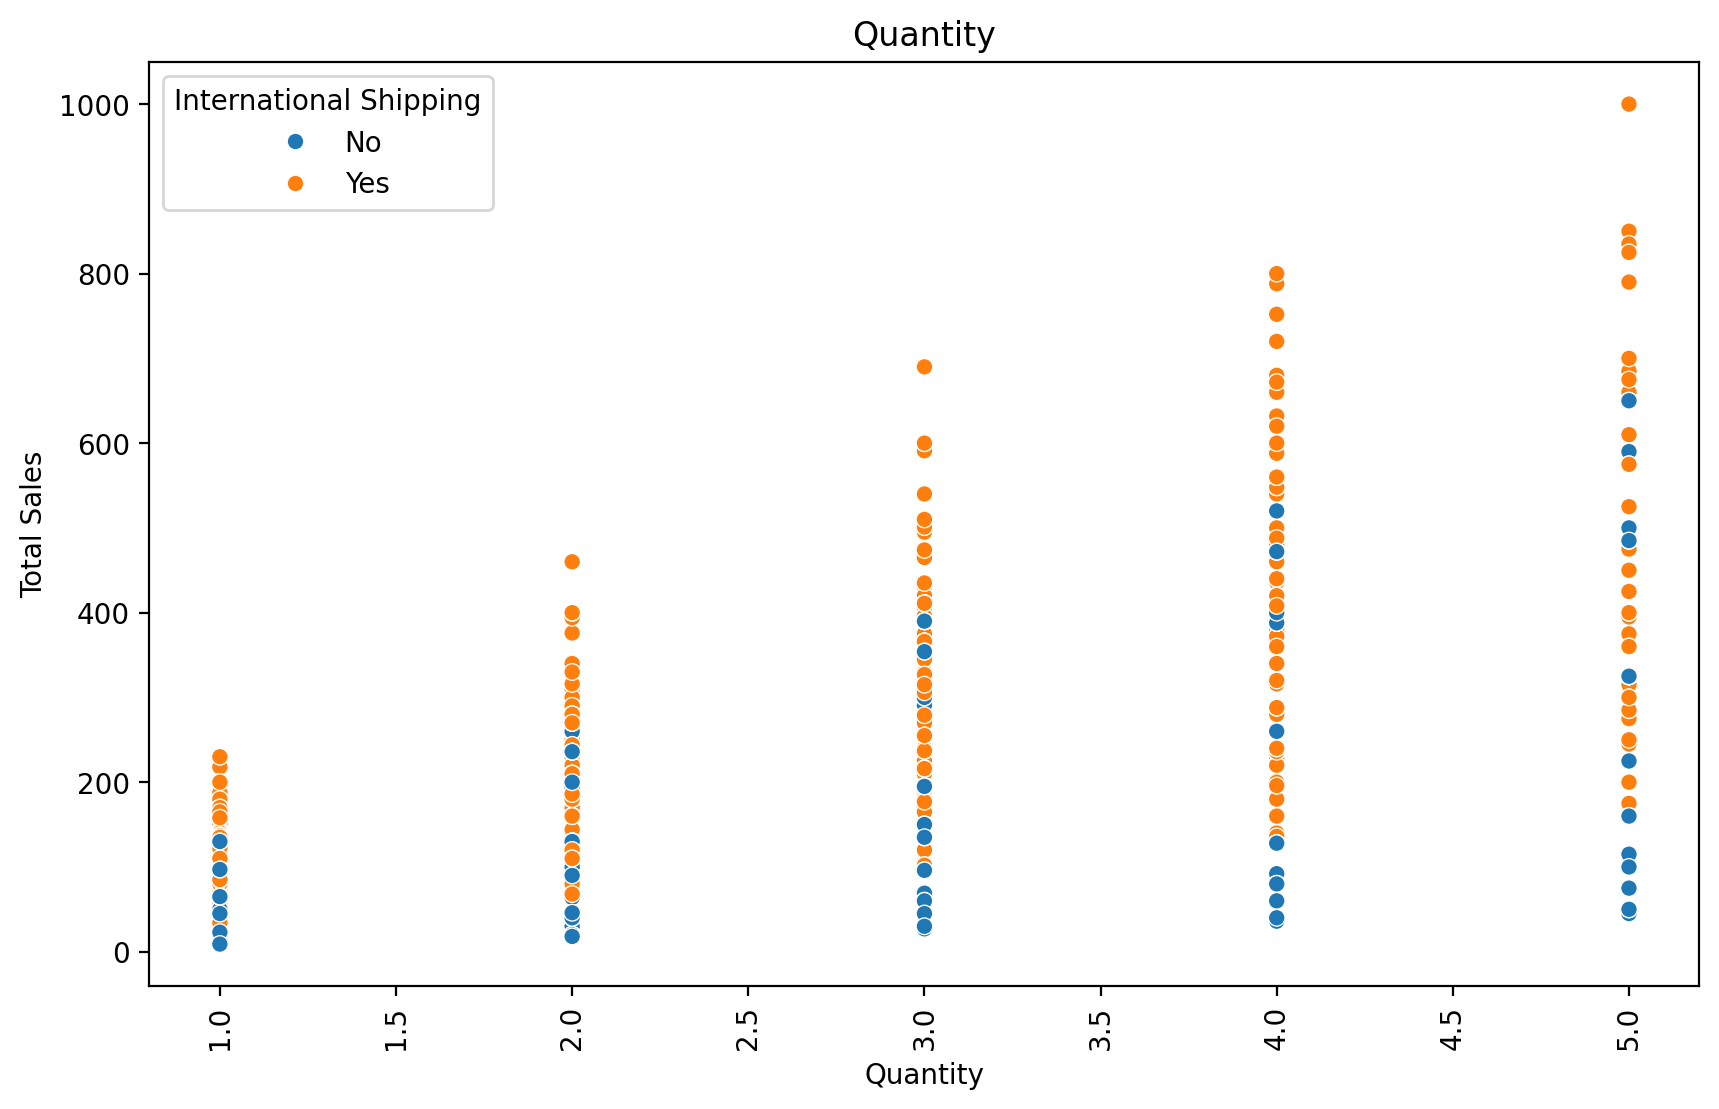

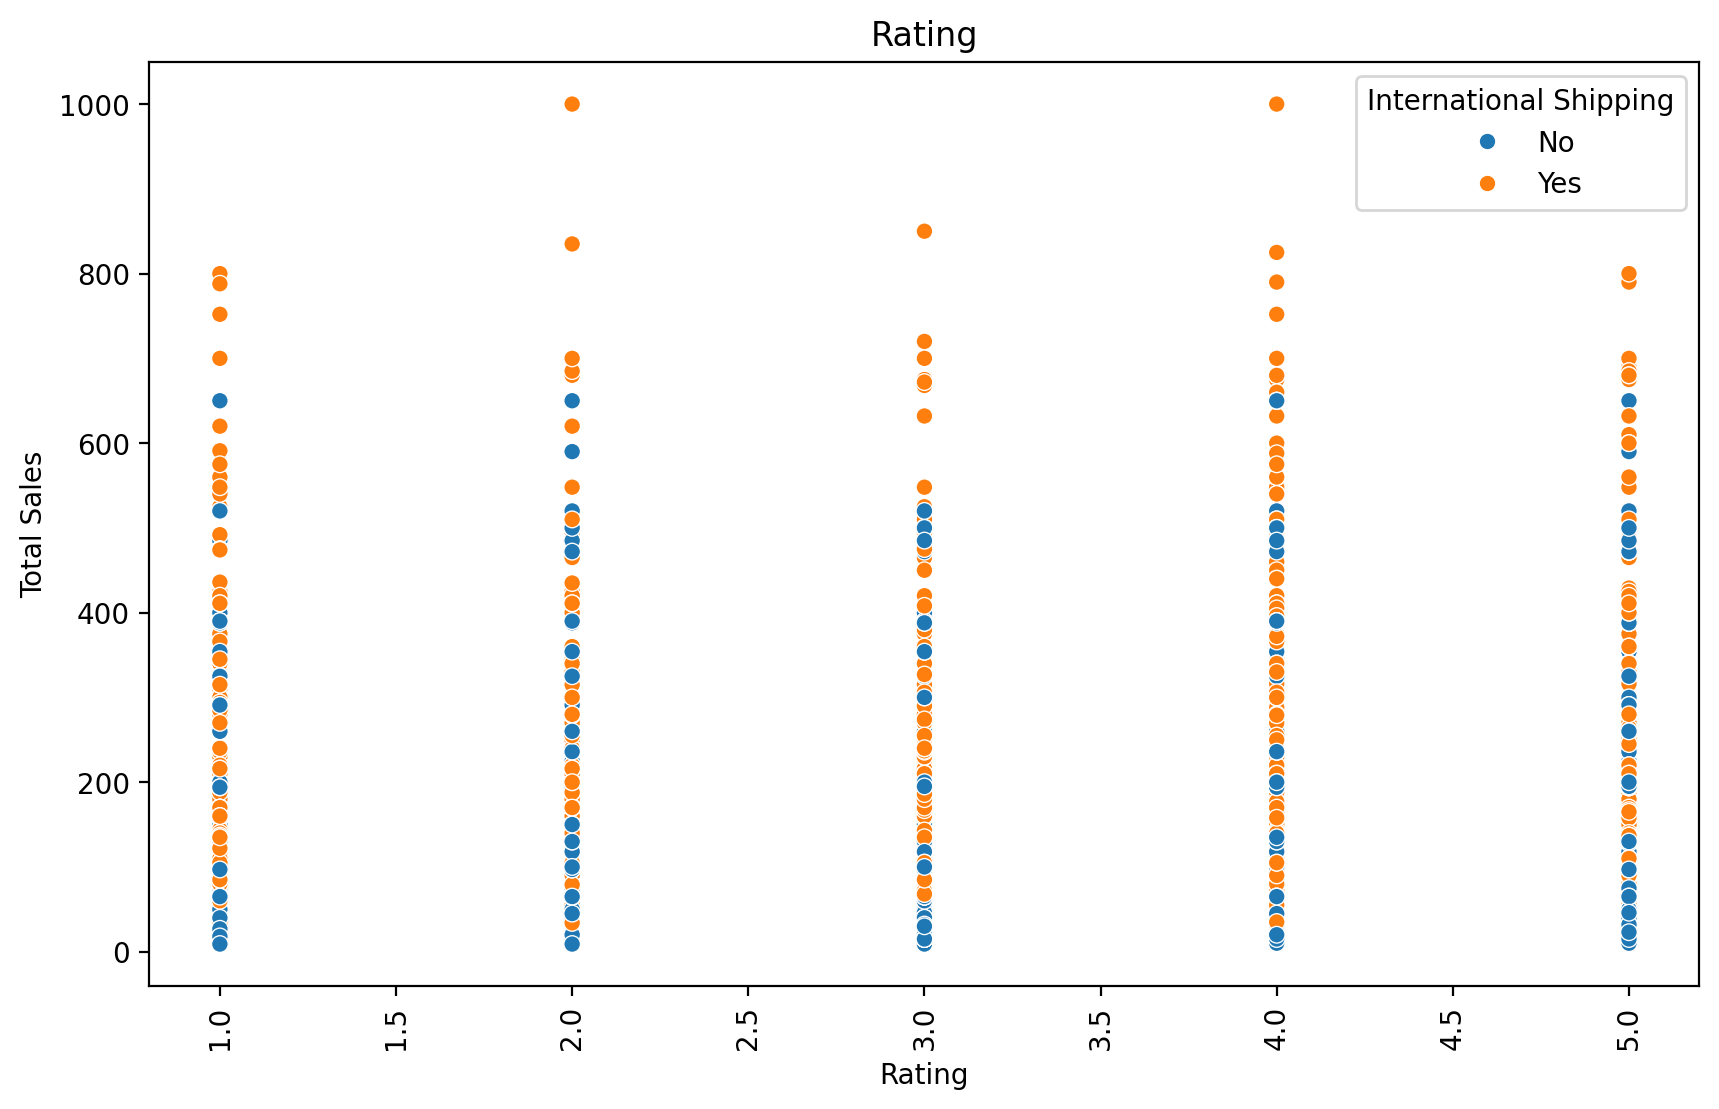

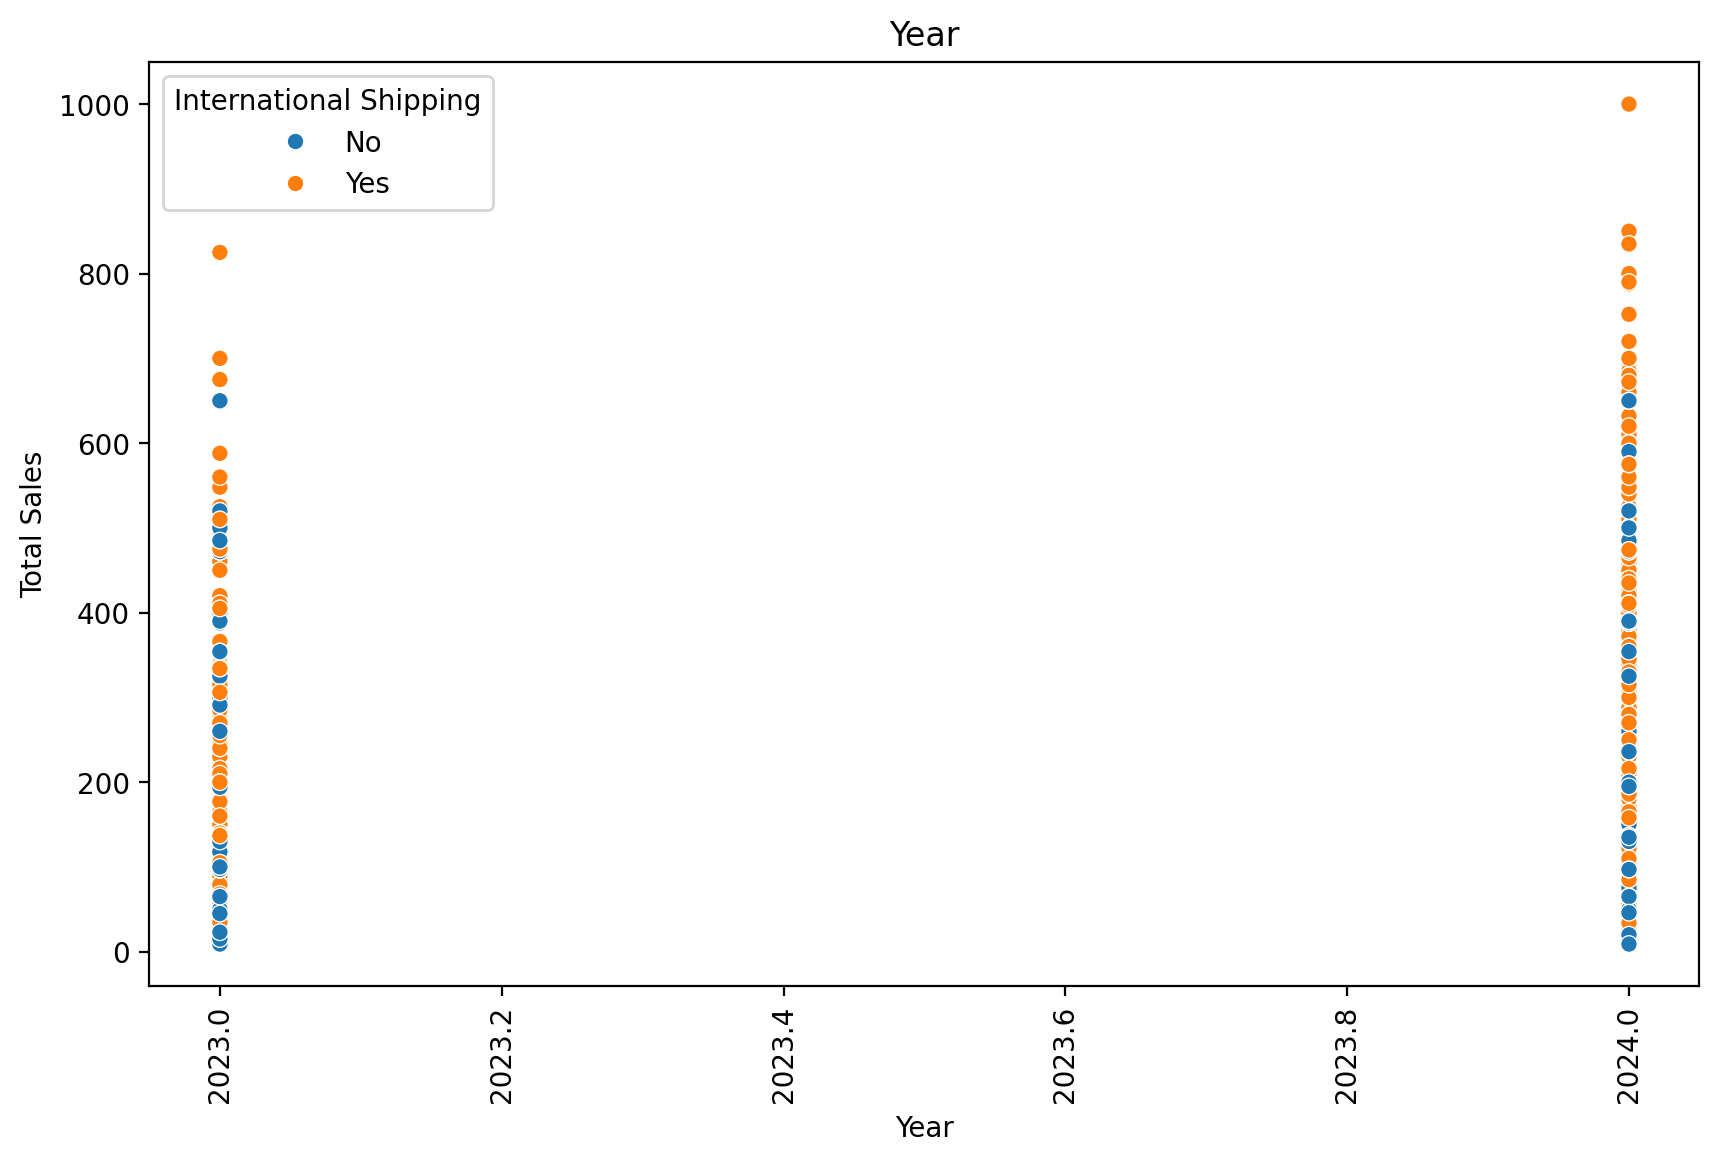

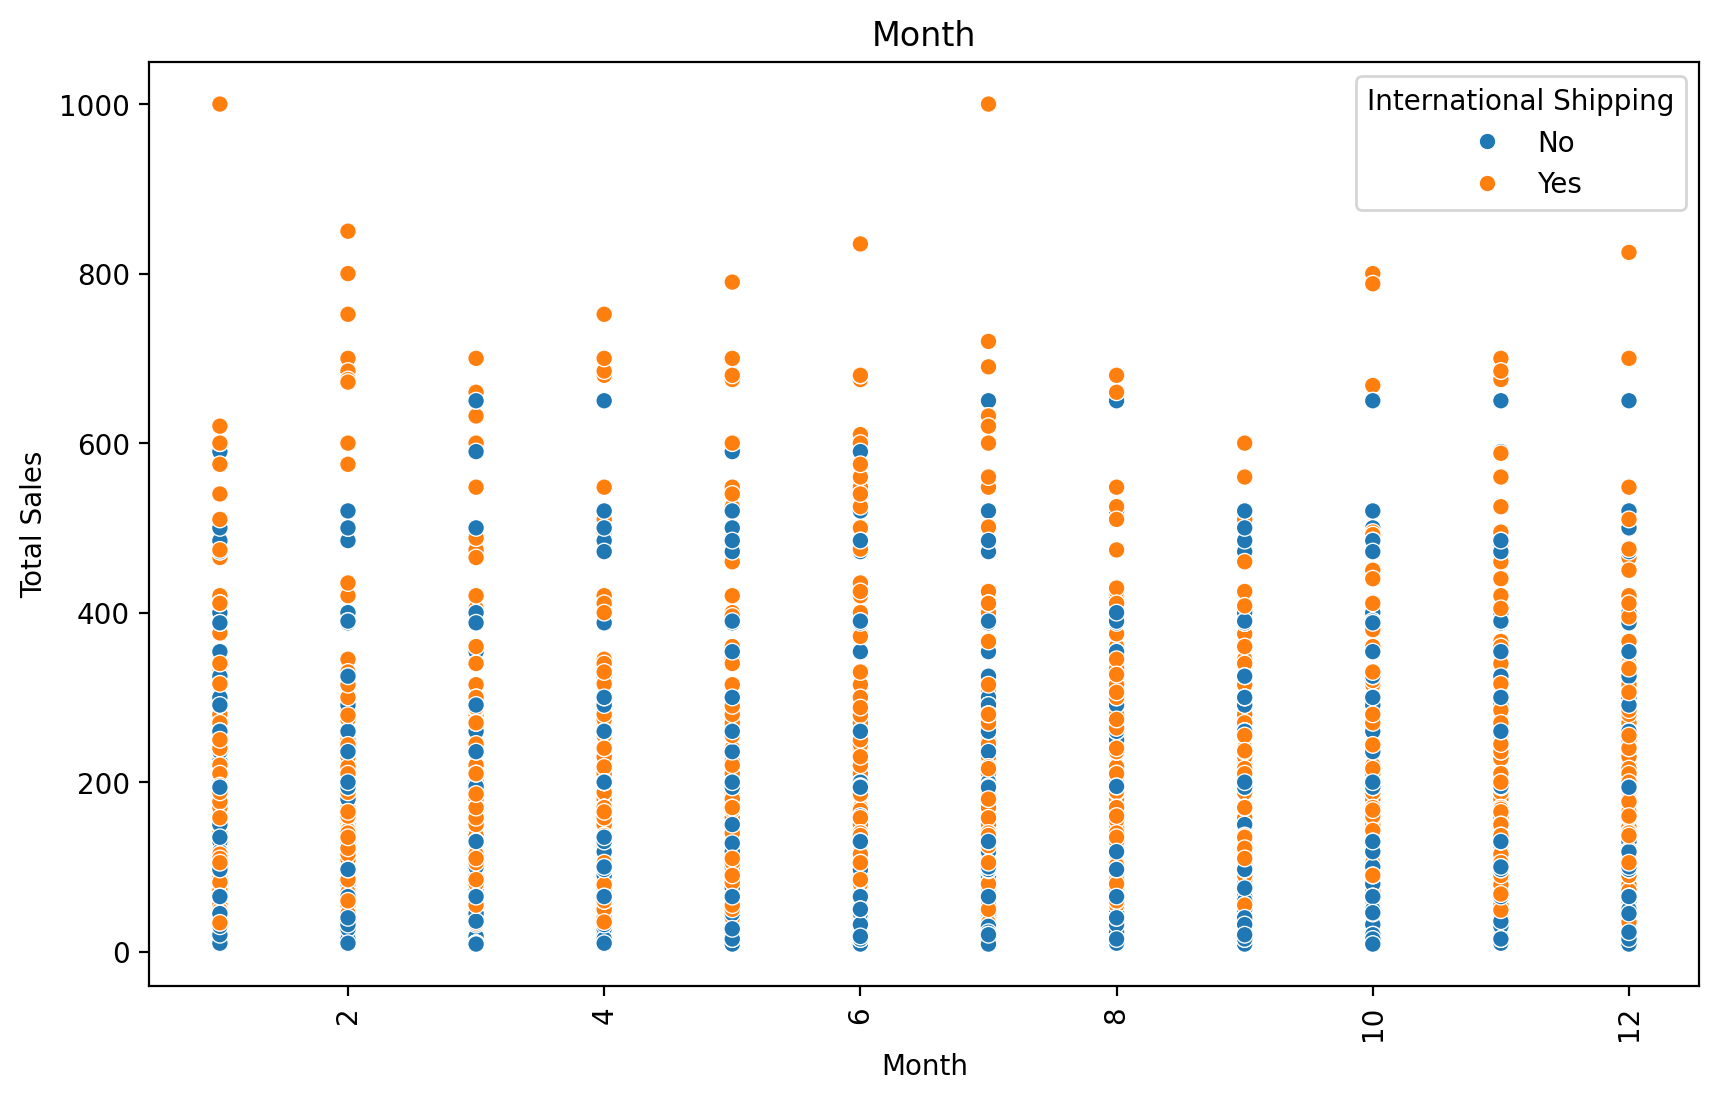

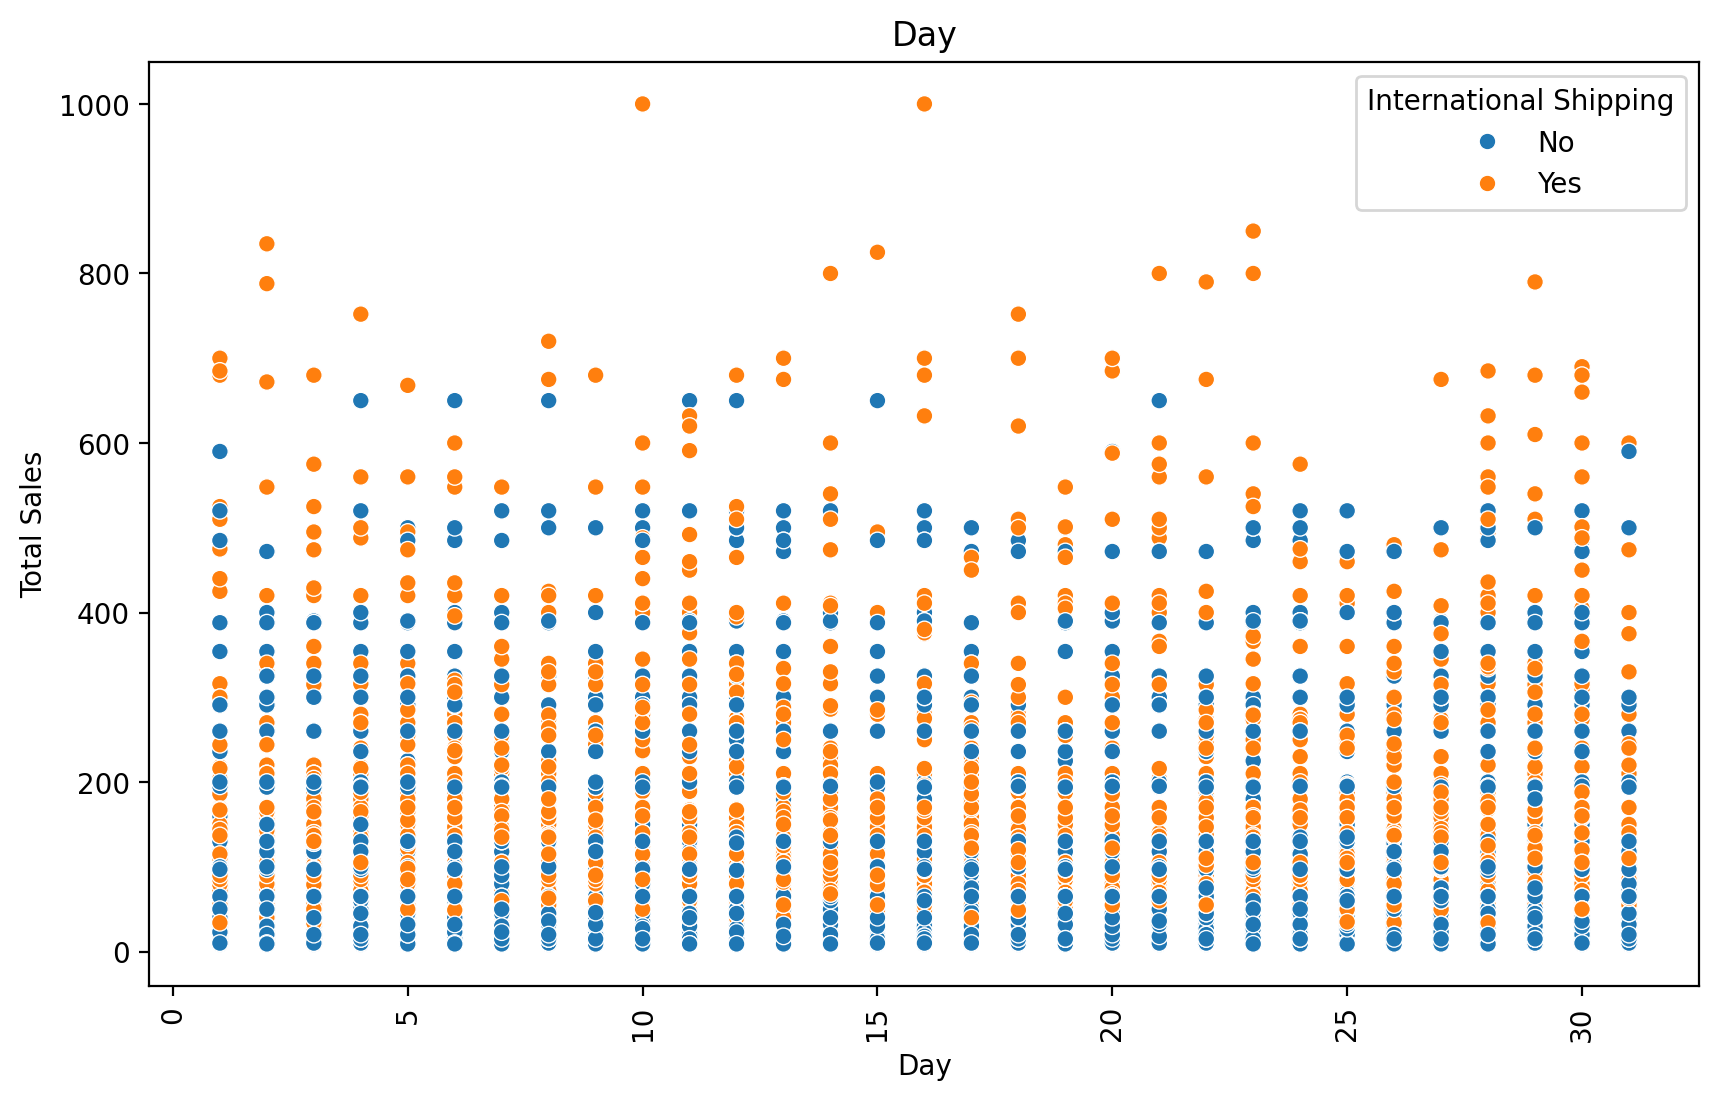

In [ ]:
# plot a scatterplot along with hue
for column in features:
  plt.figure(figsize=(10,6),dpi=200)
  sns.scatterplot(data=df,x=df[column],y=df['Total Sales'],hue='International Shipping')
  plt.xticks(rotation=90)
  plt.title(column)

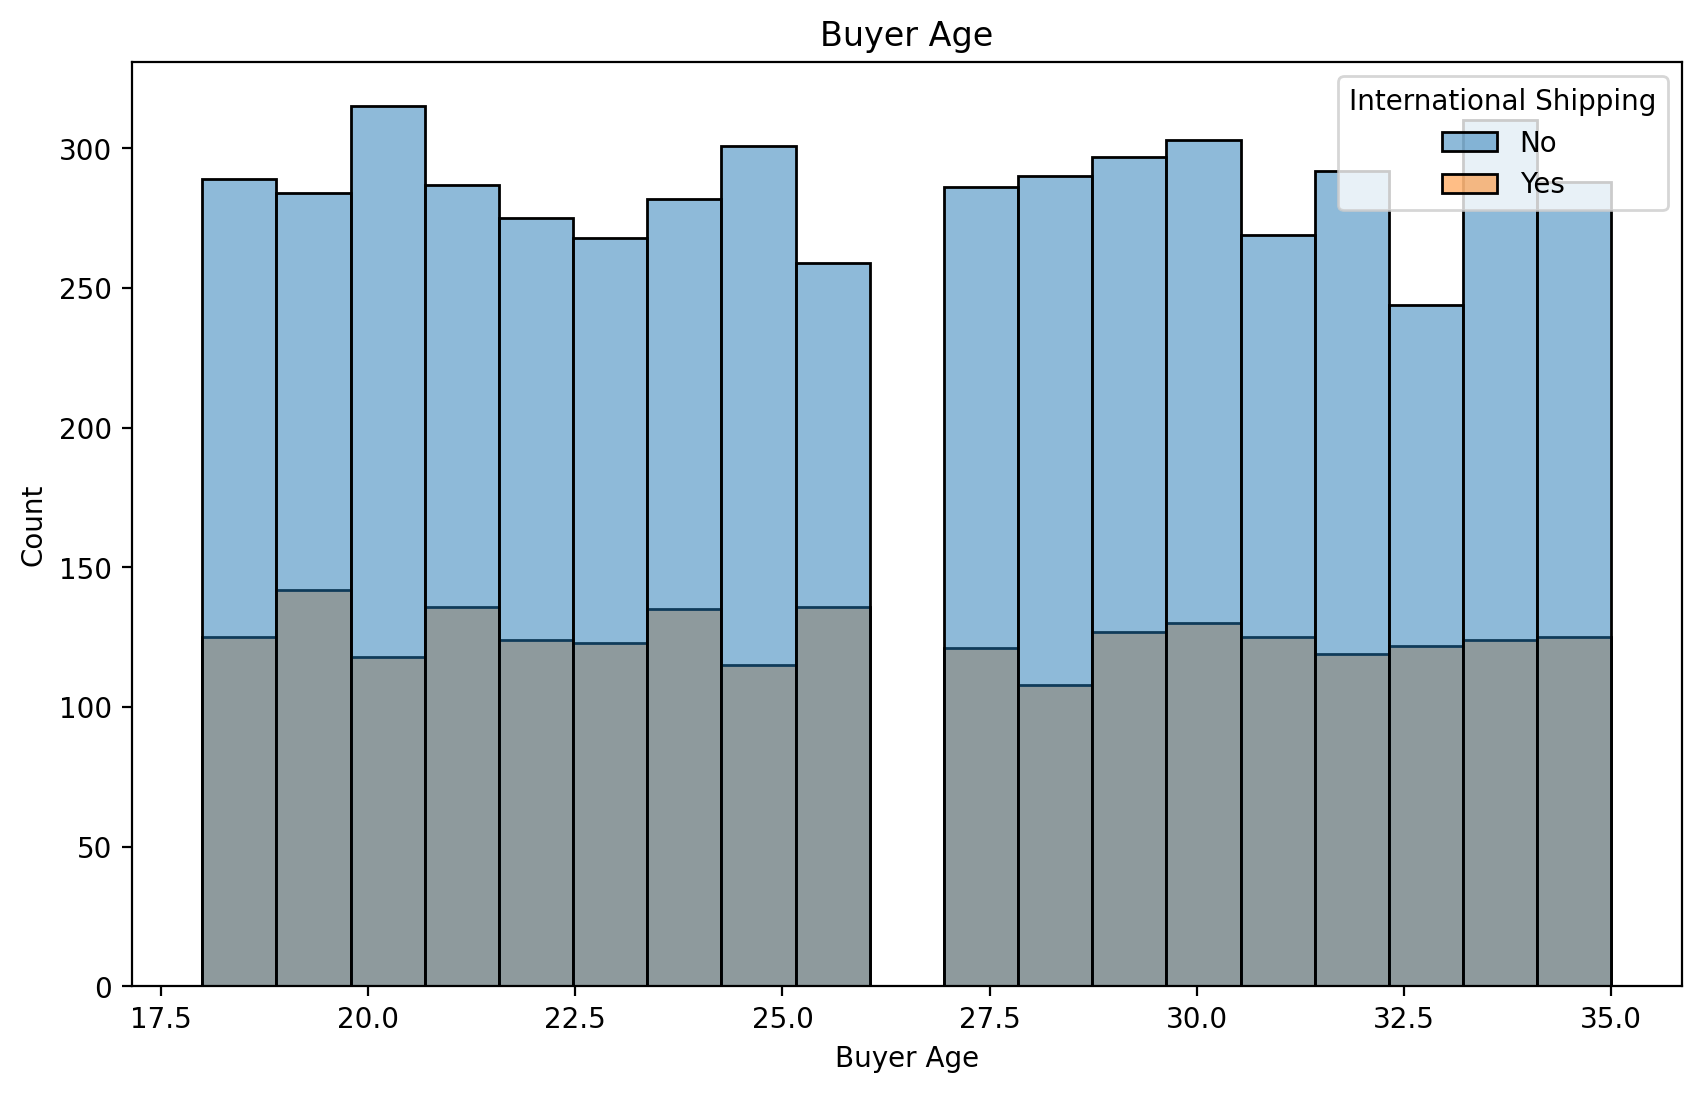

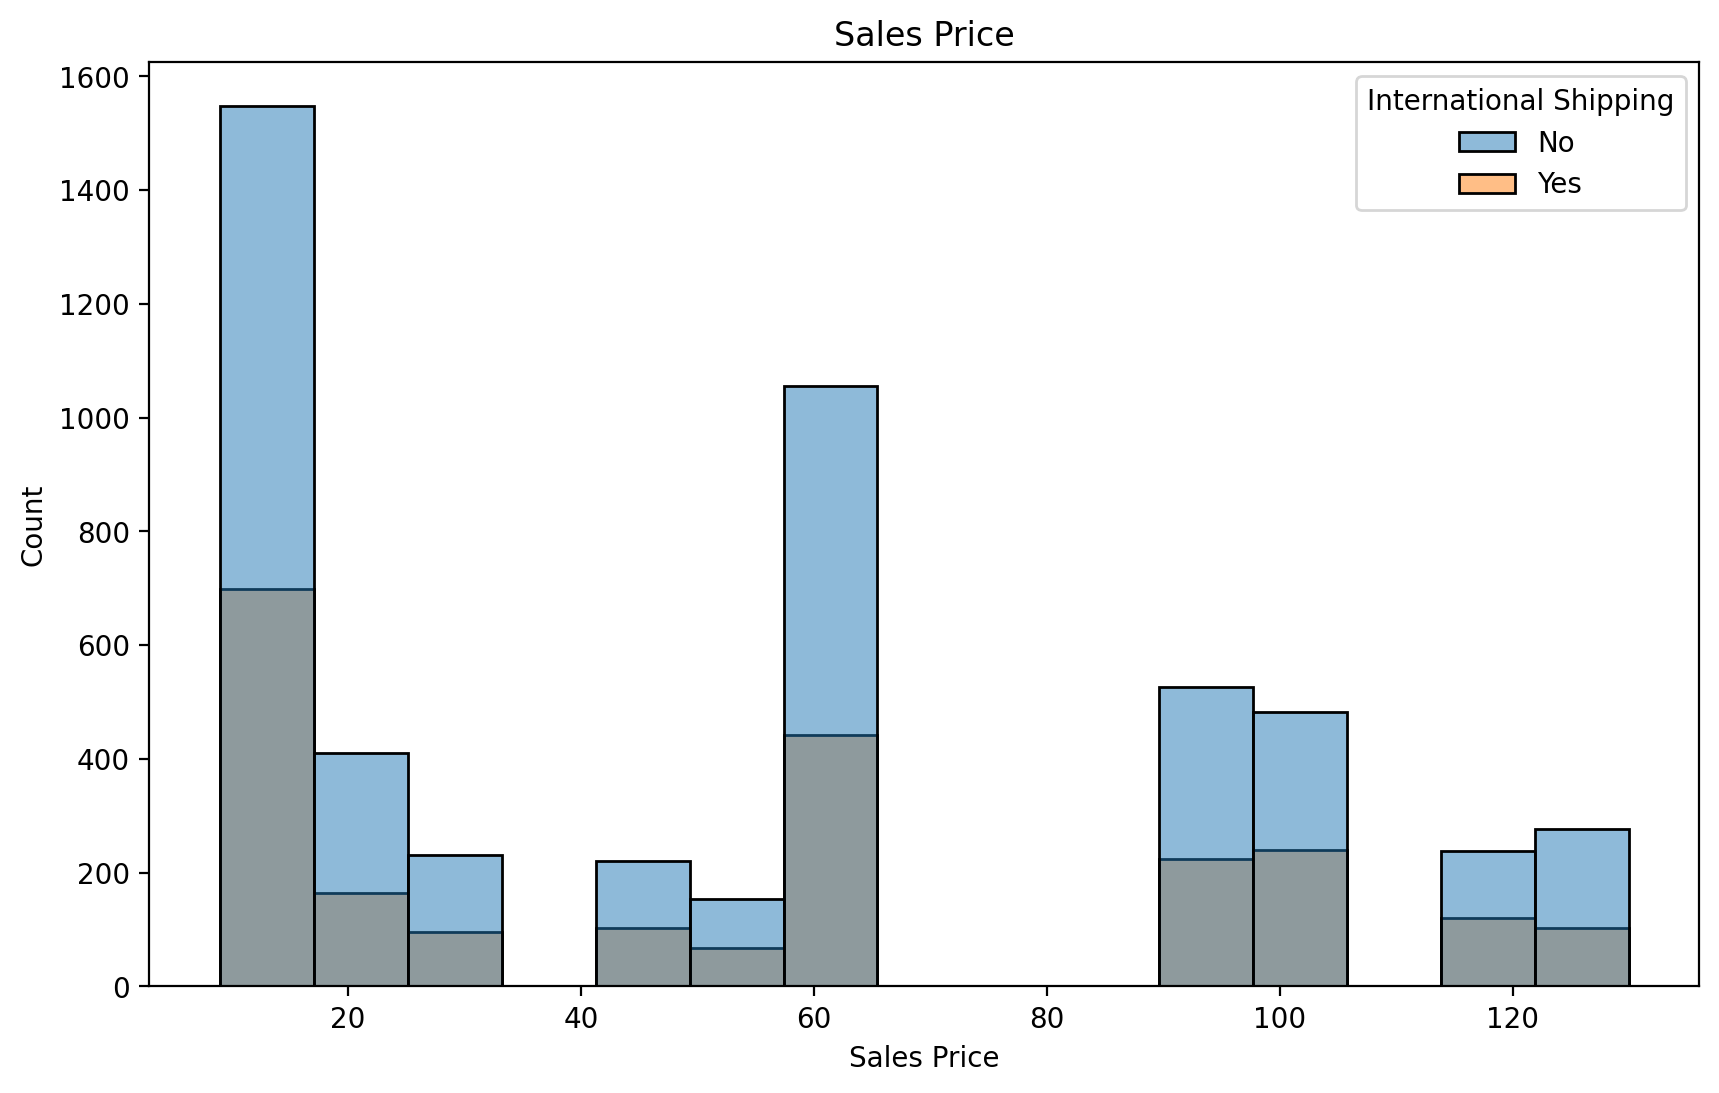

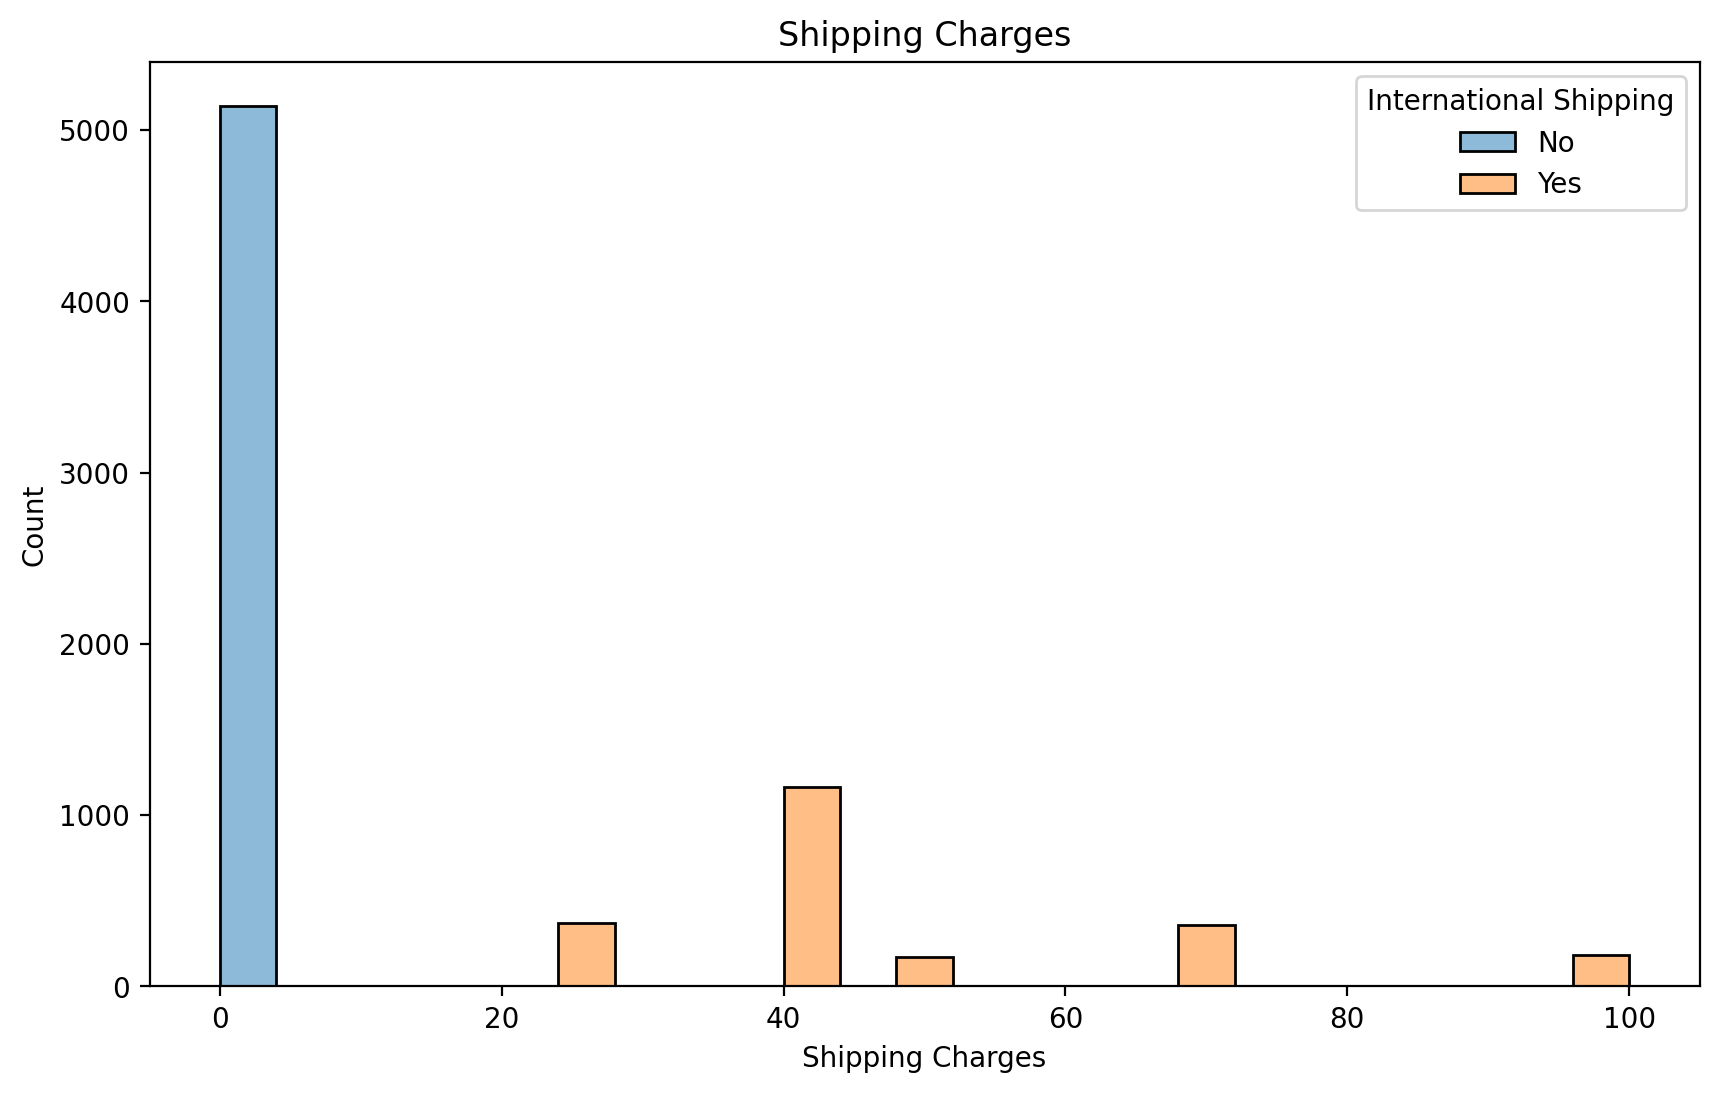

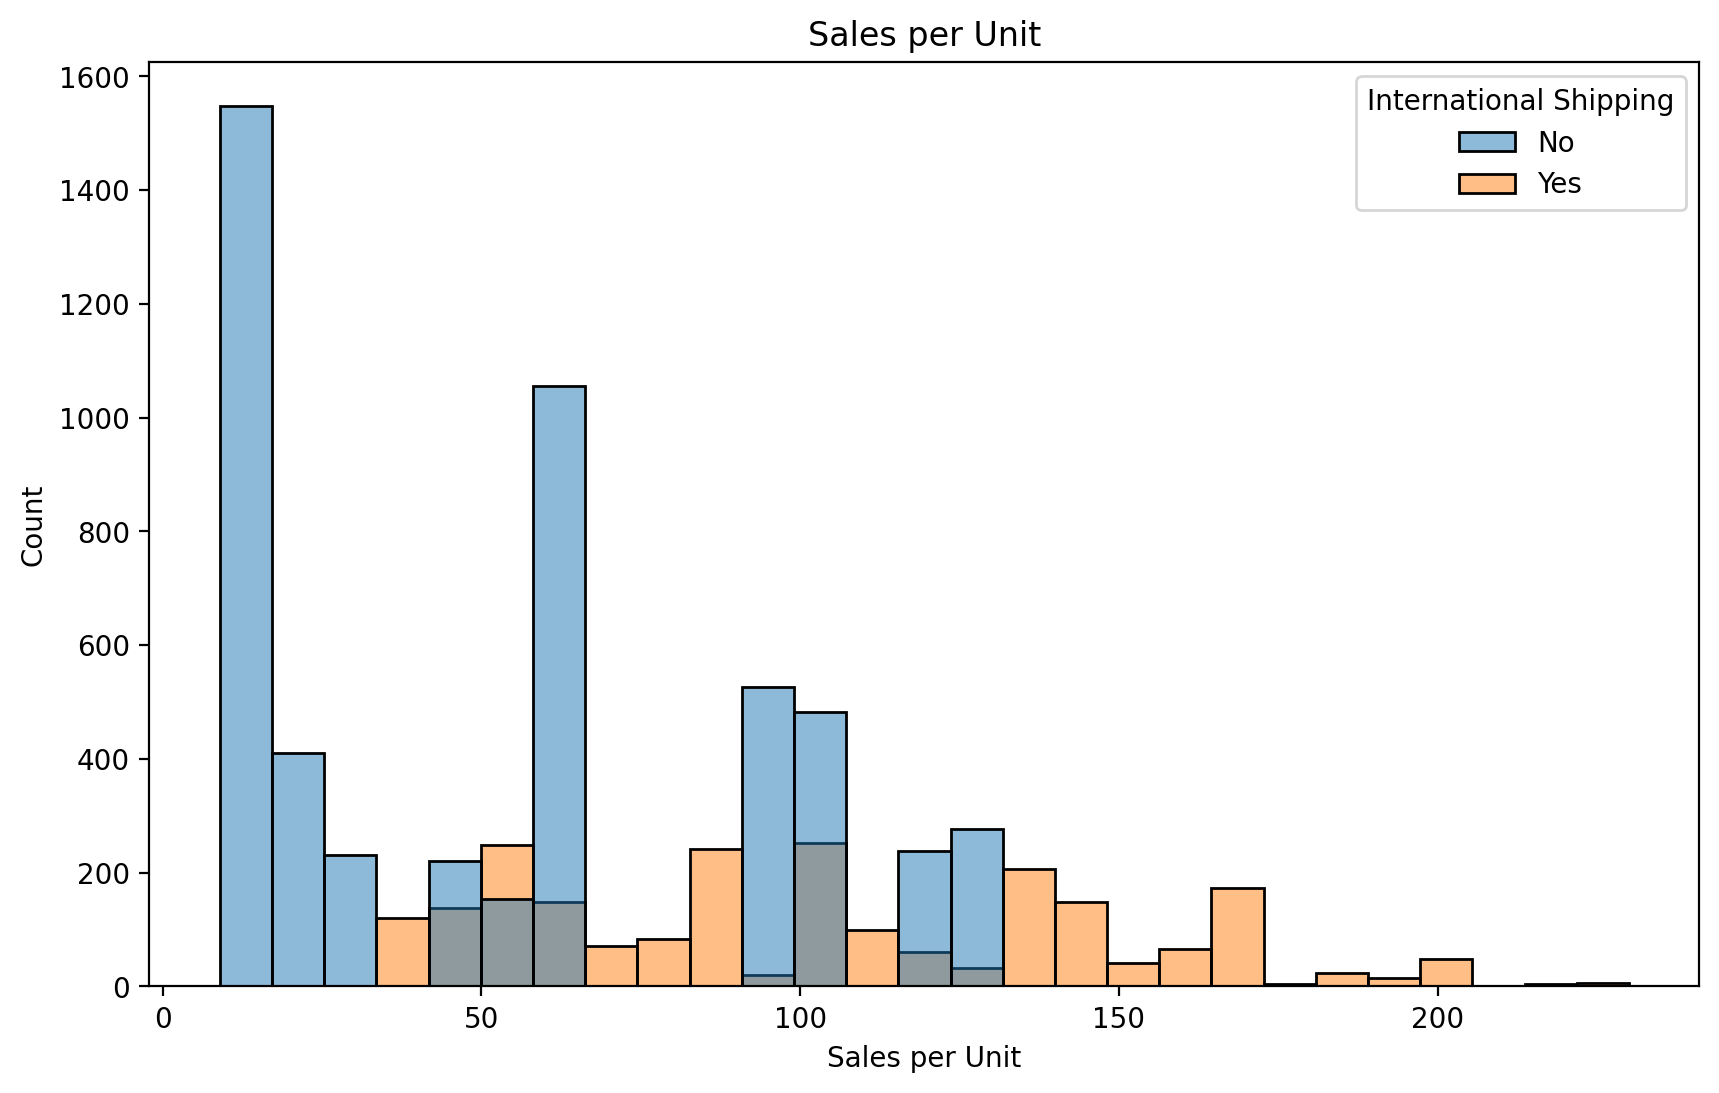

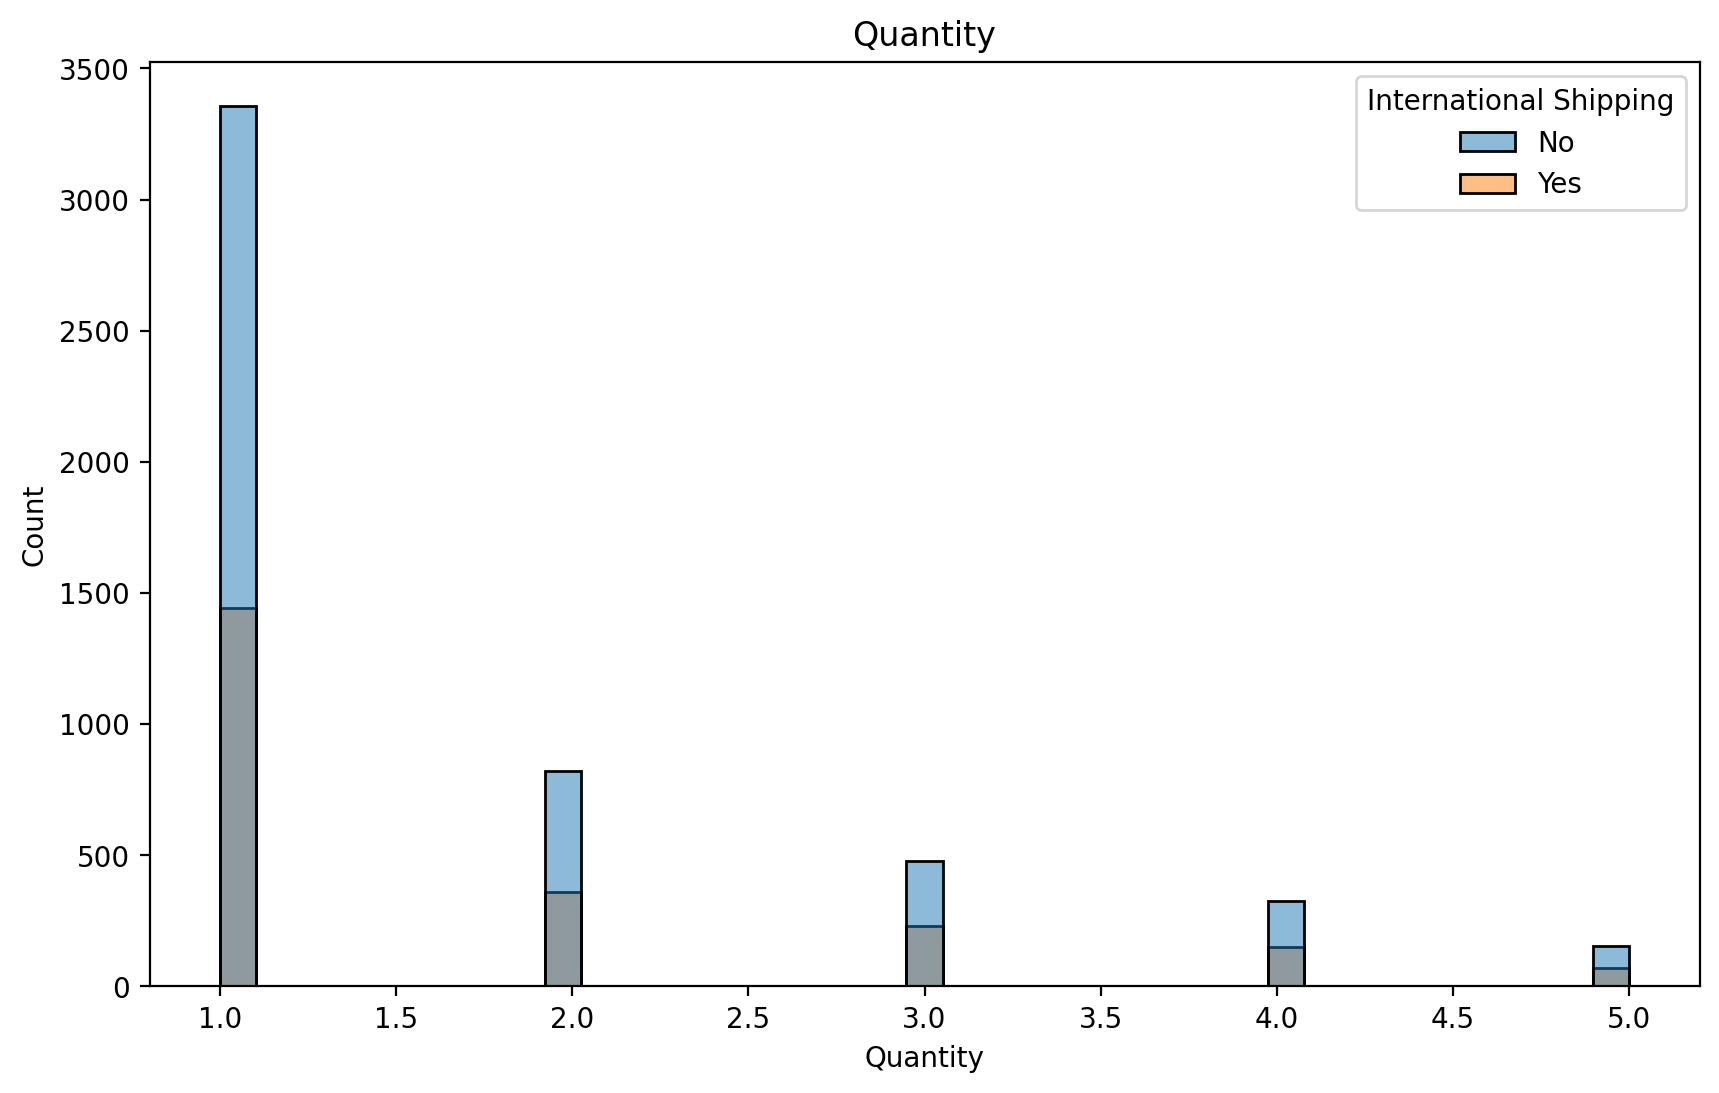

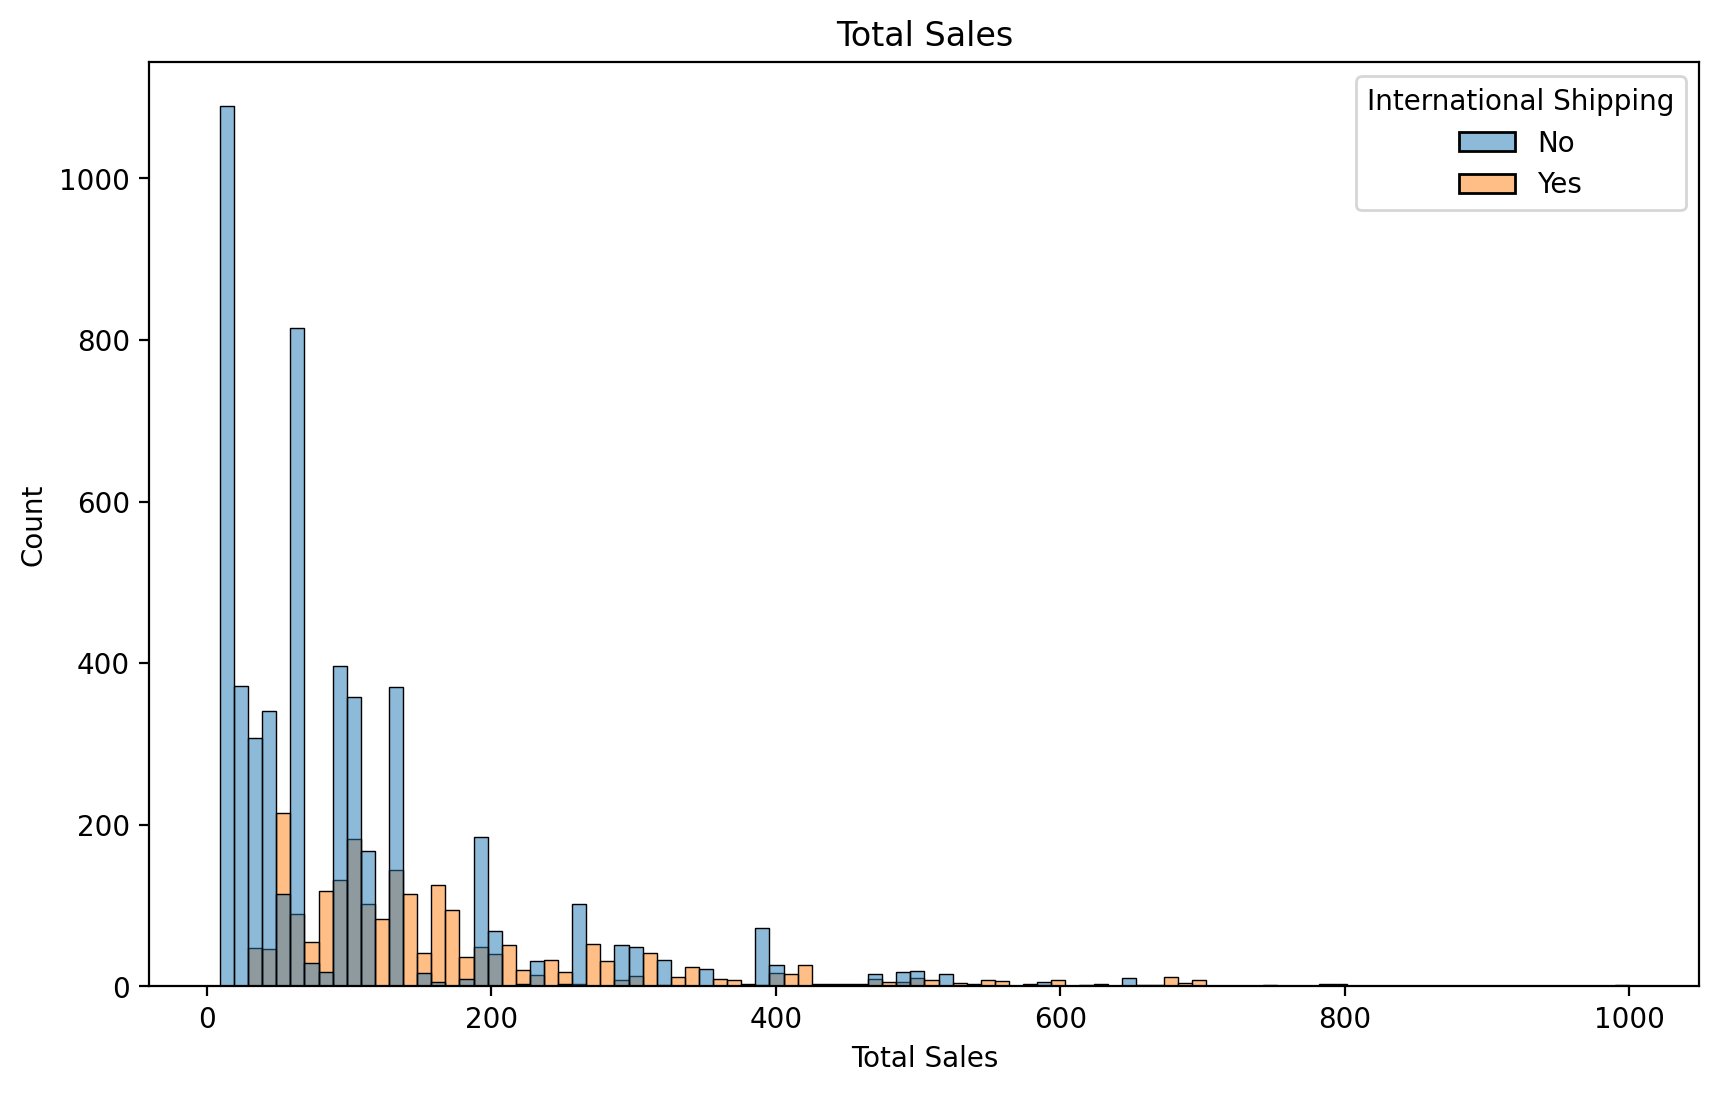

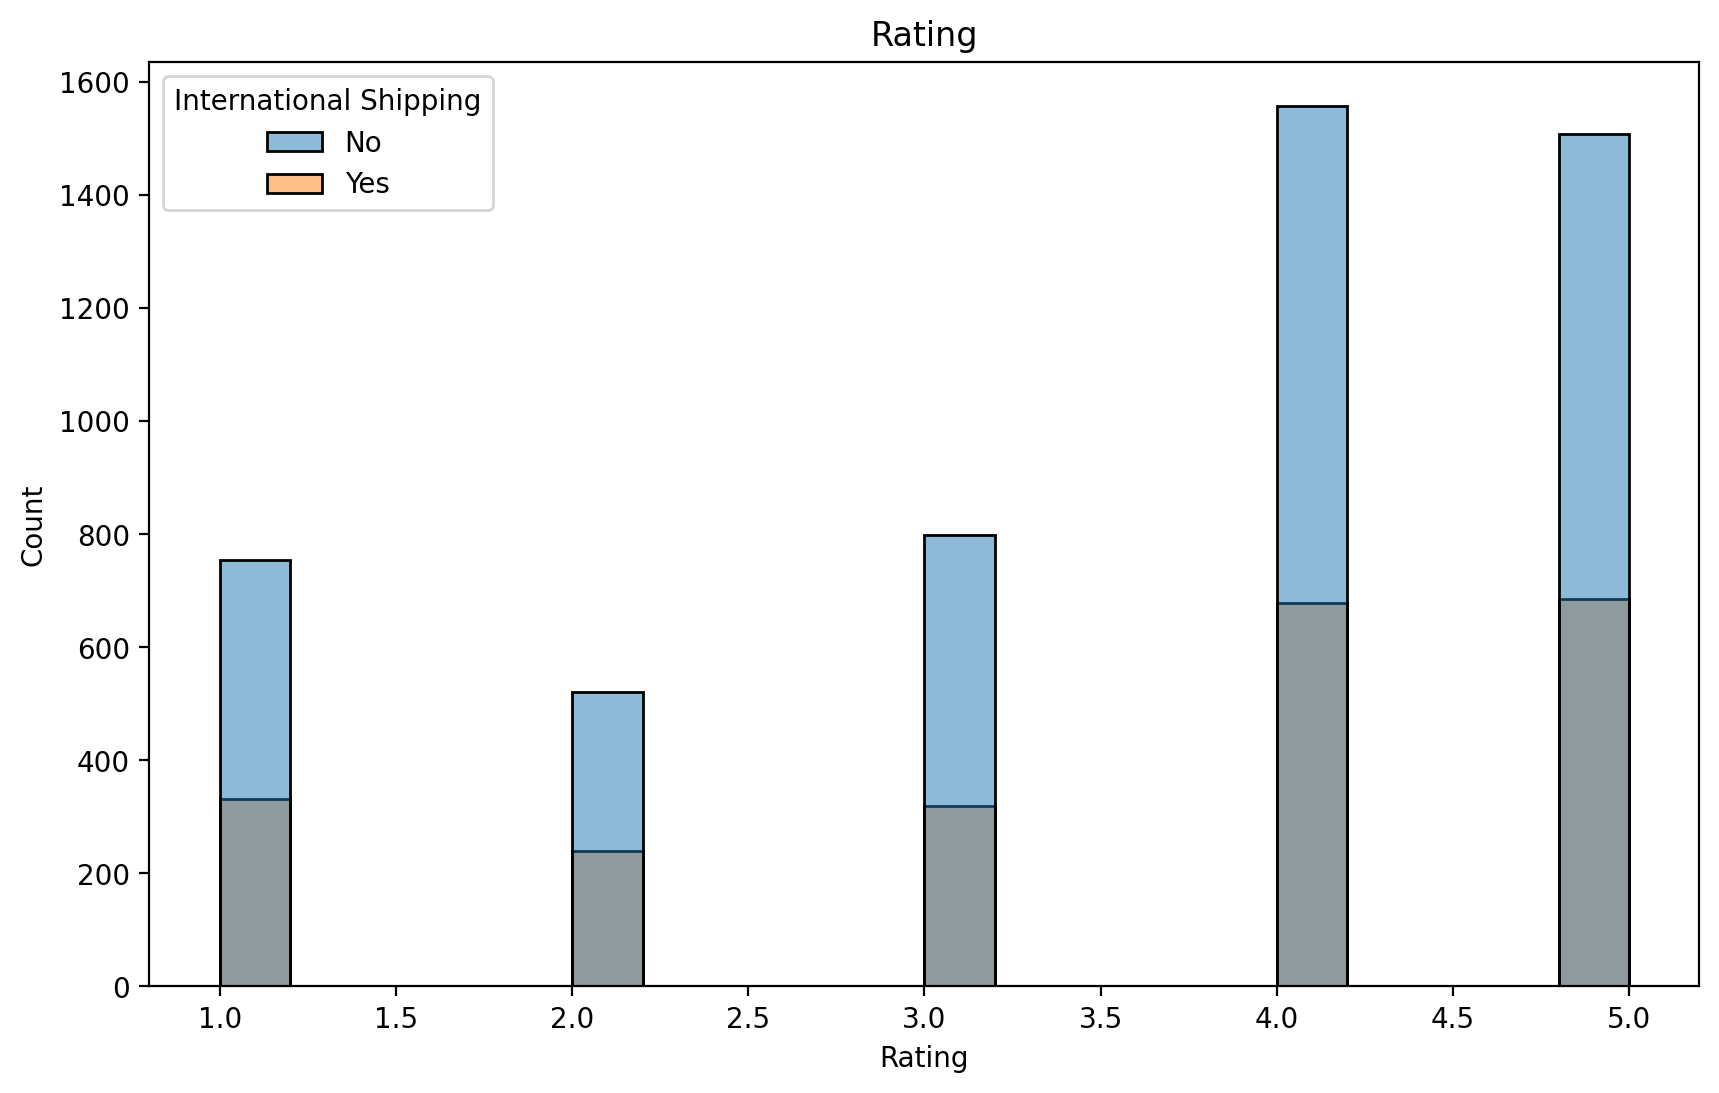

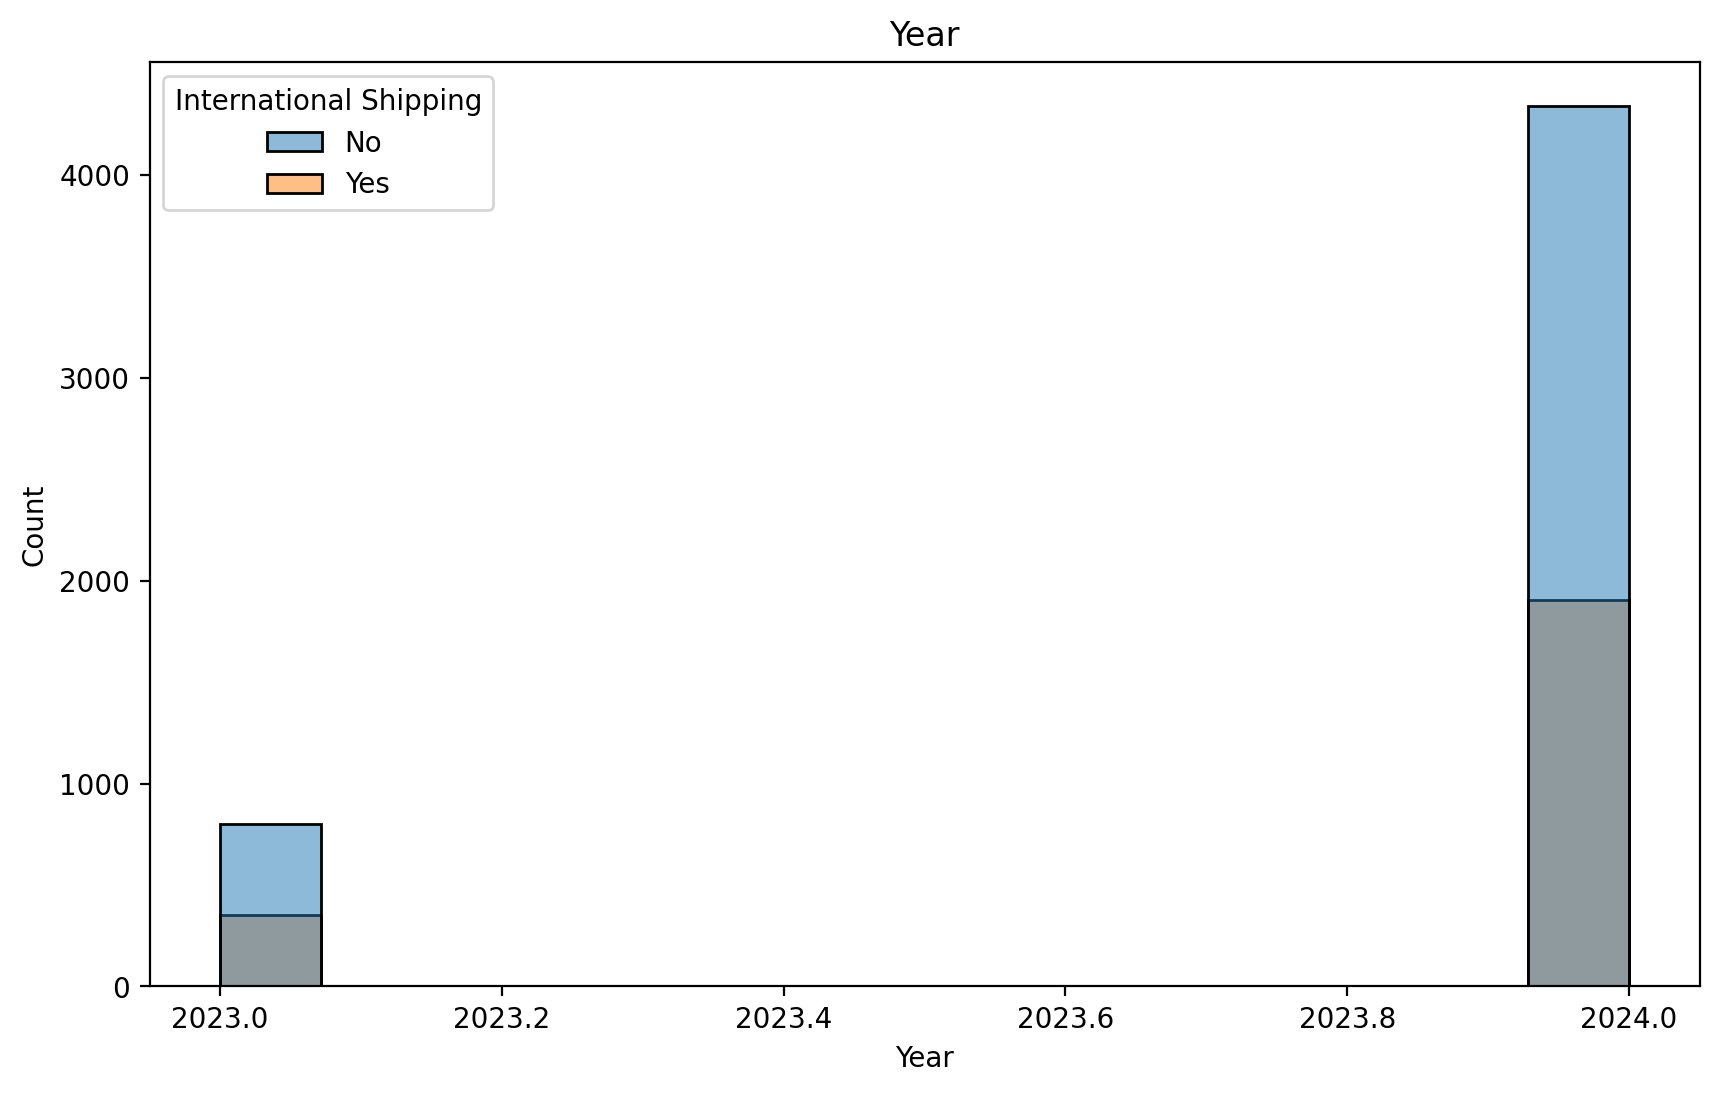

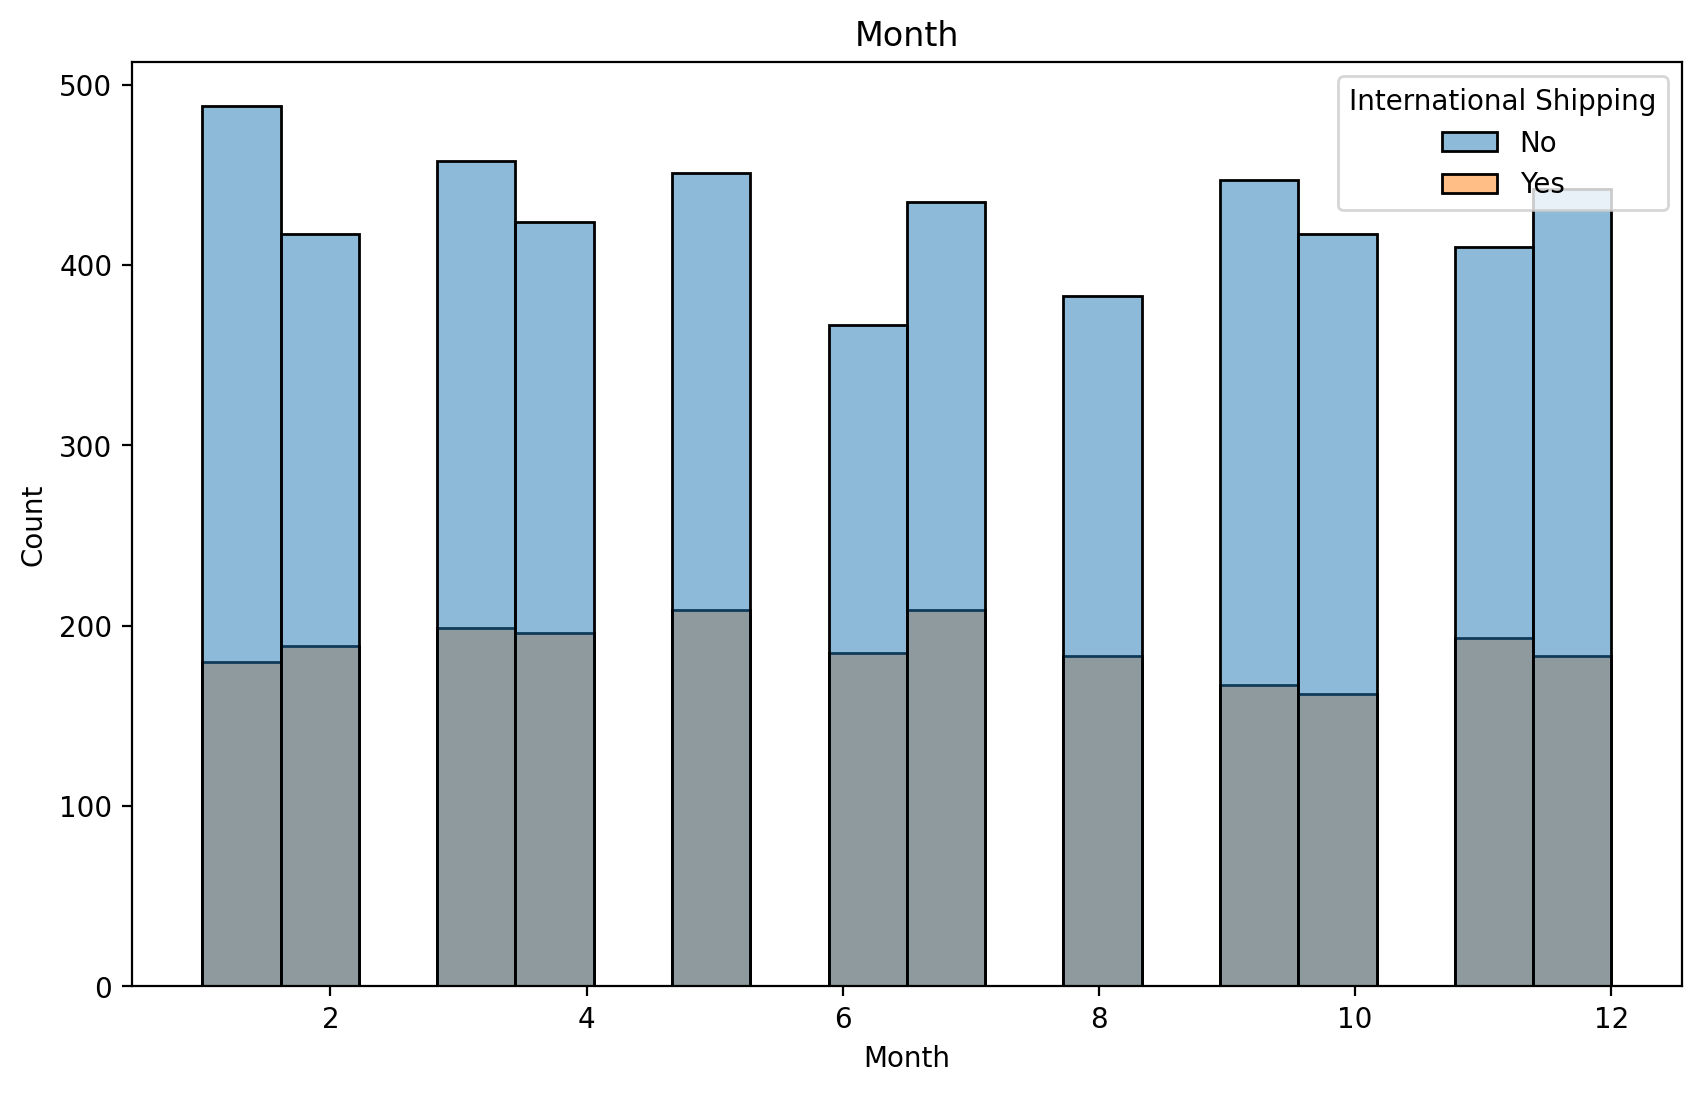

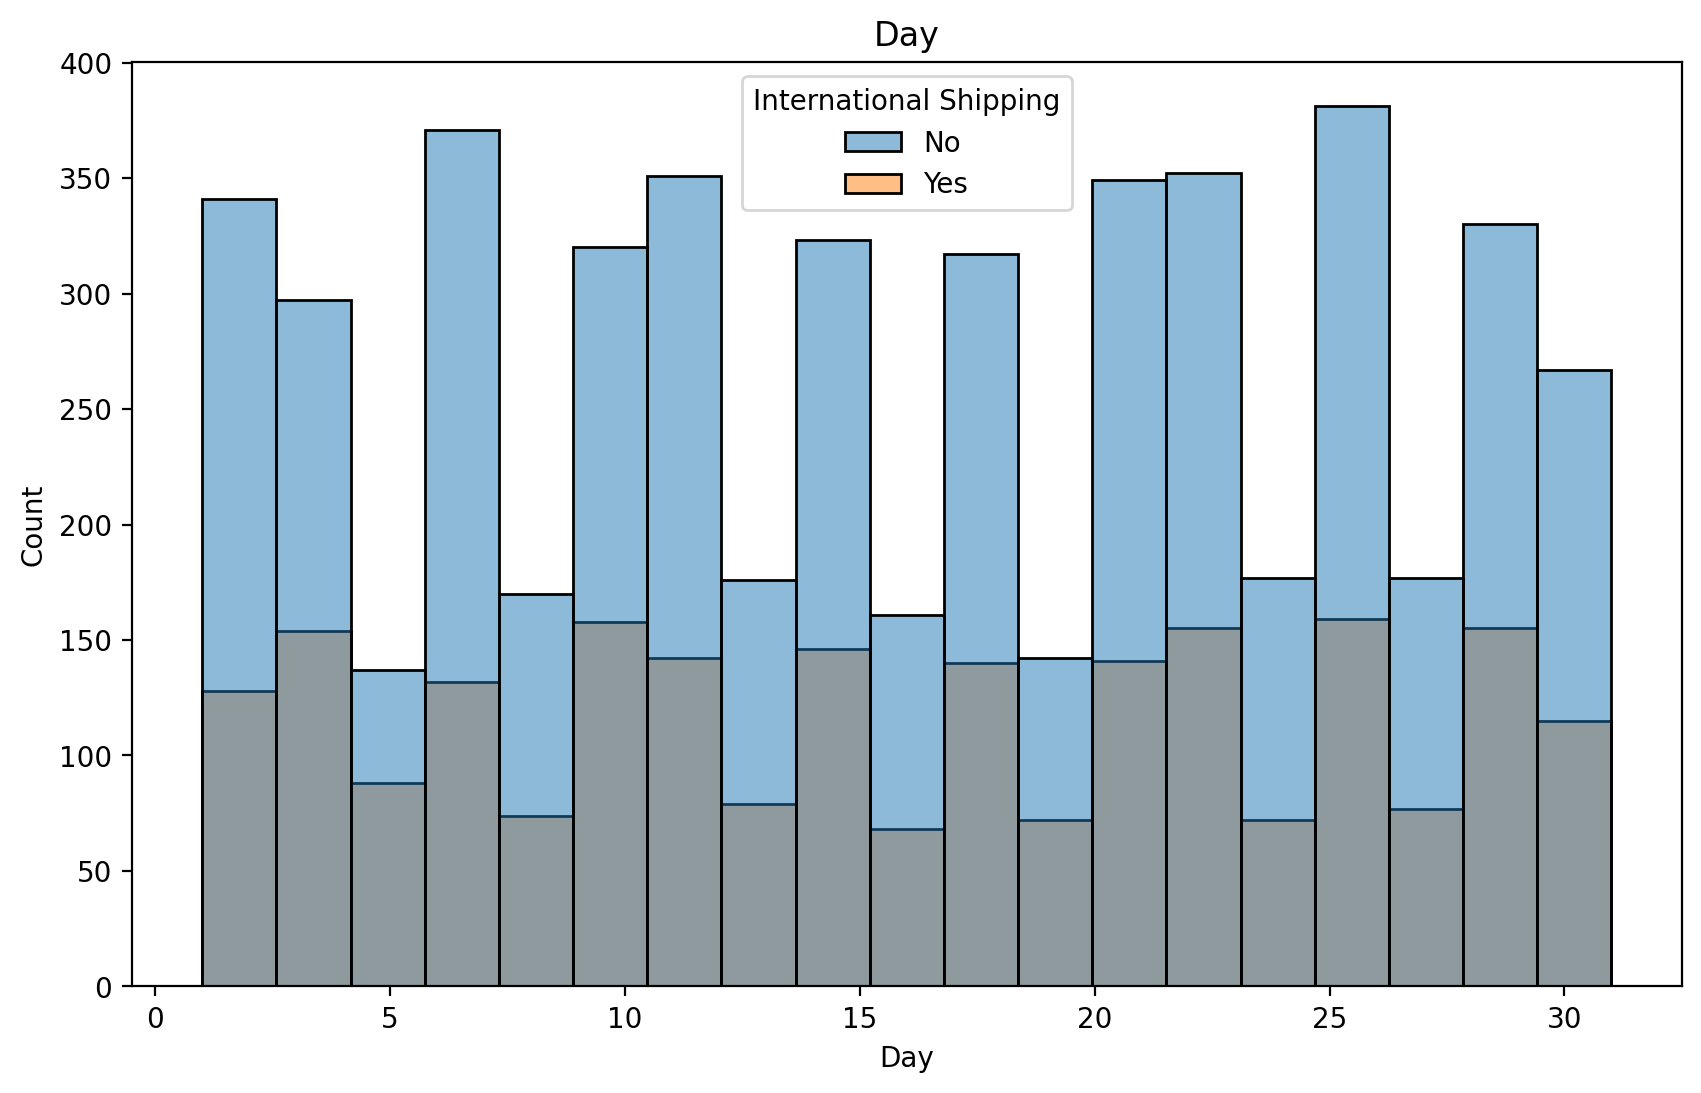

In [ ]:
# plot a histogram for numerical columns along with hue
for column in numerical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.histplot(data=df, x=column, hue='International Shipping')
  plt.title(column)
  plt.xlabel(column)
  plt.show()

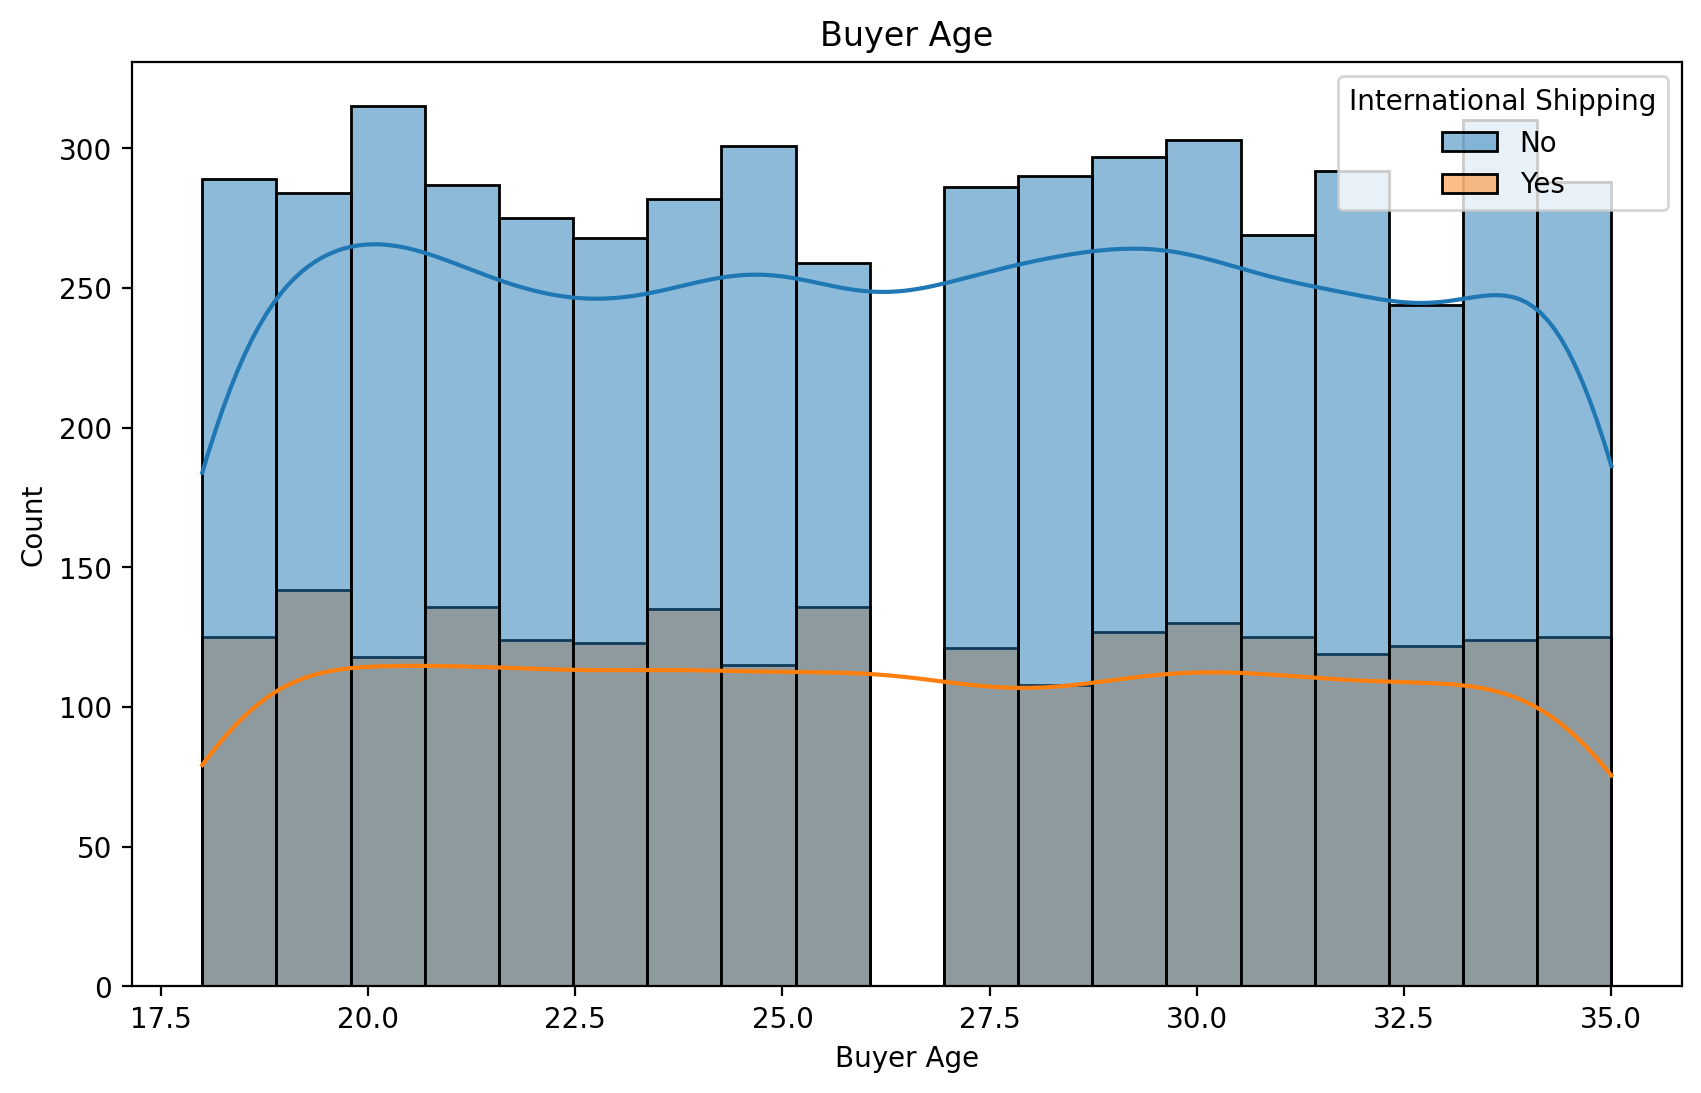

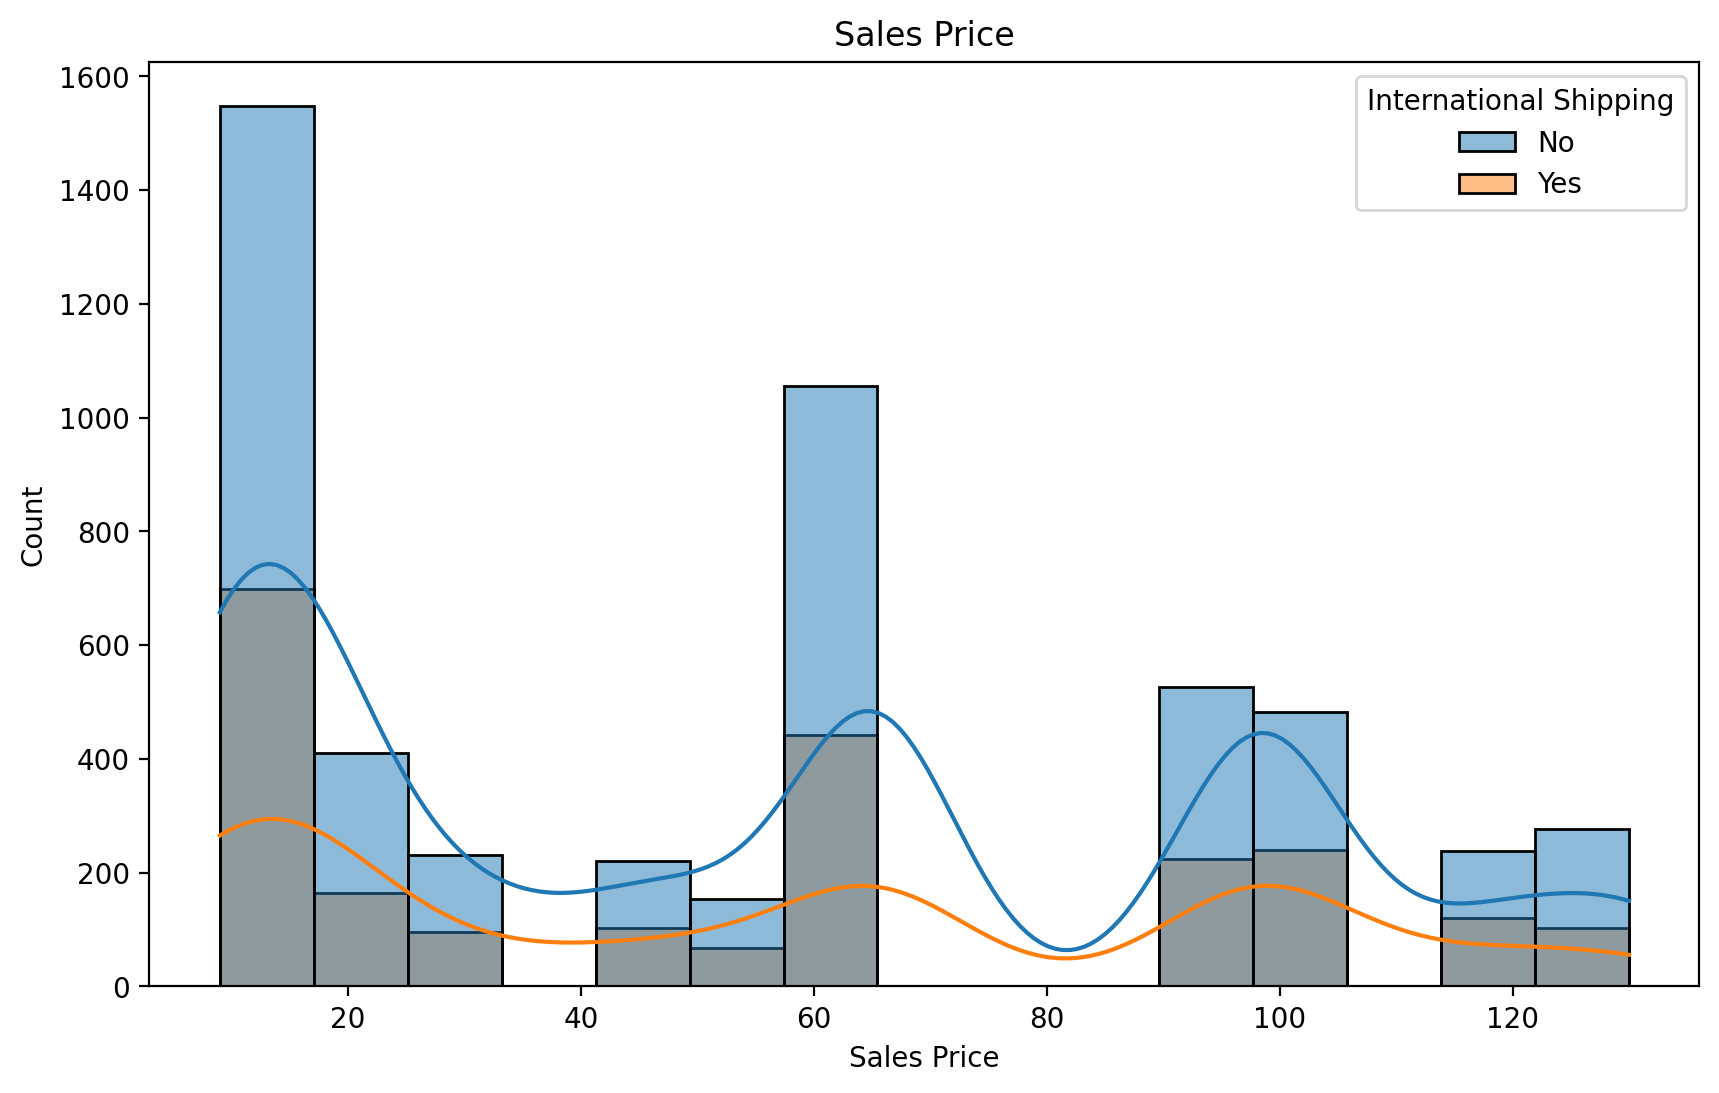

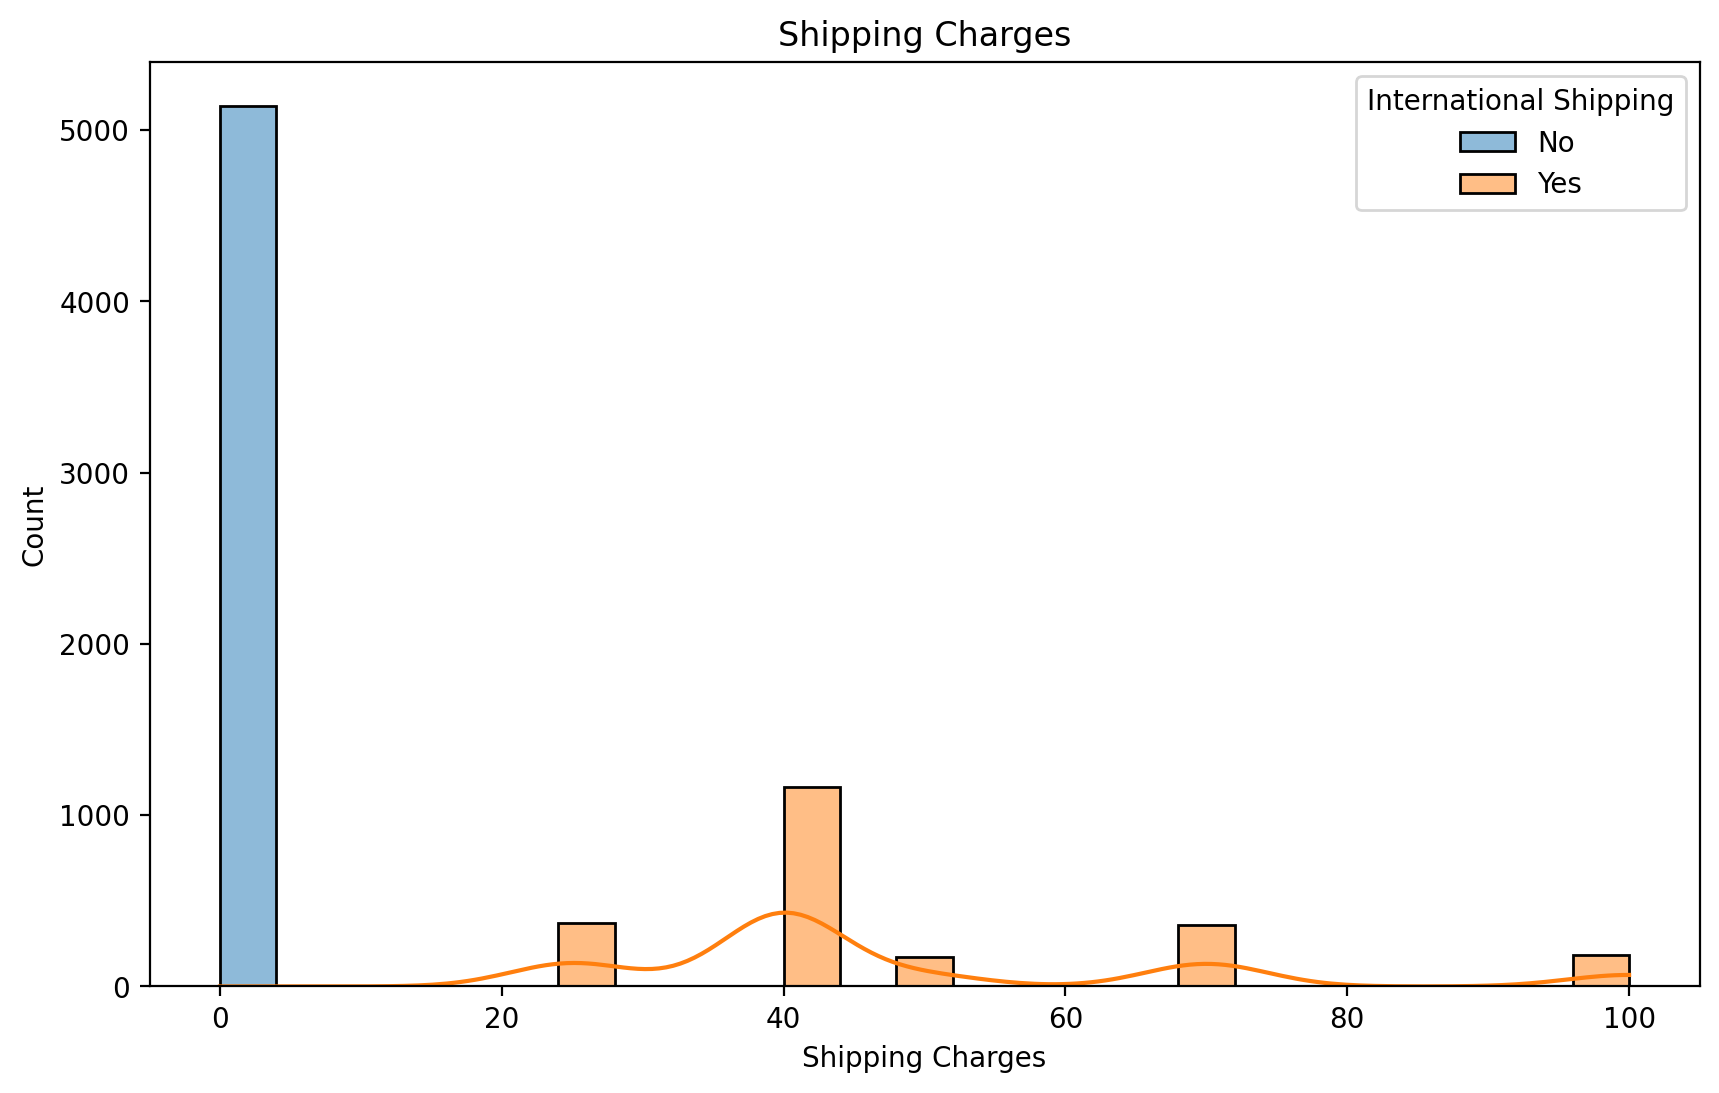

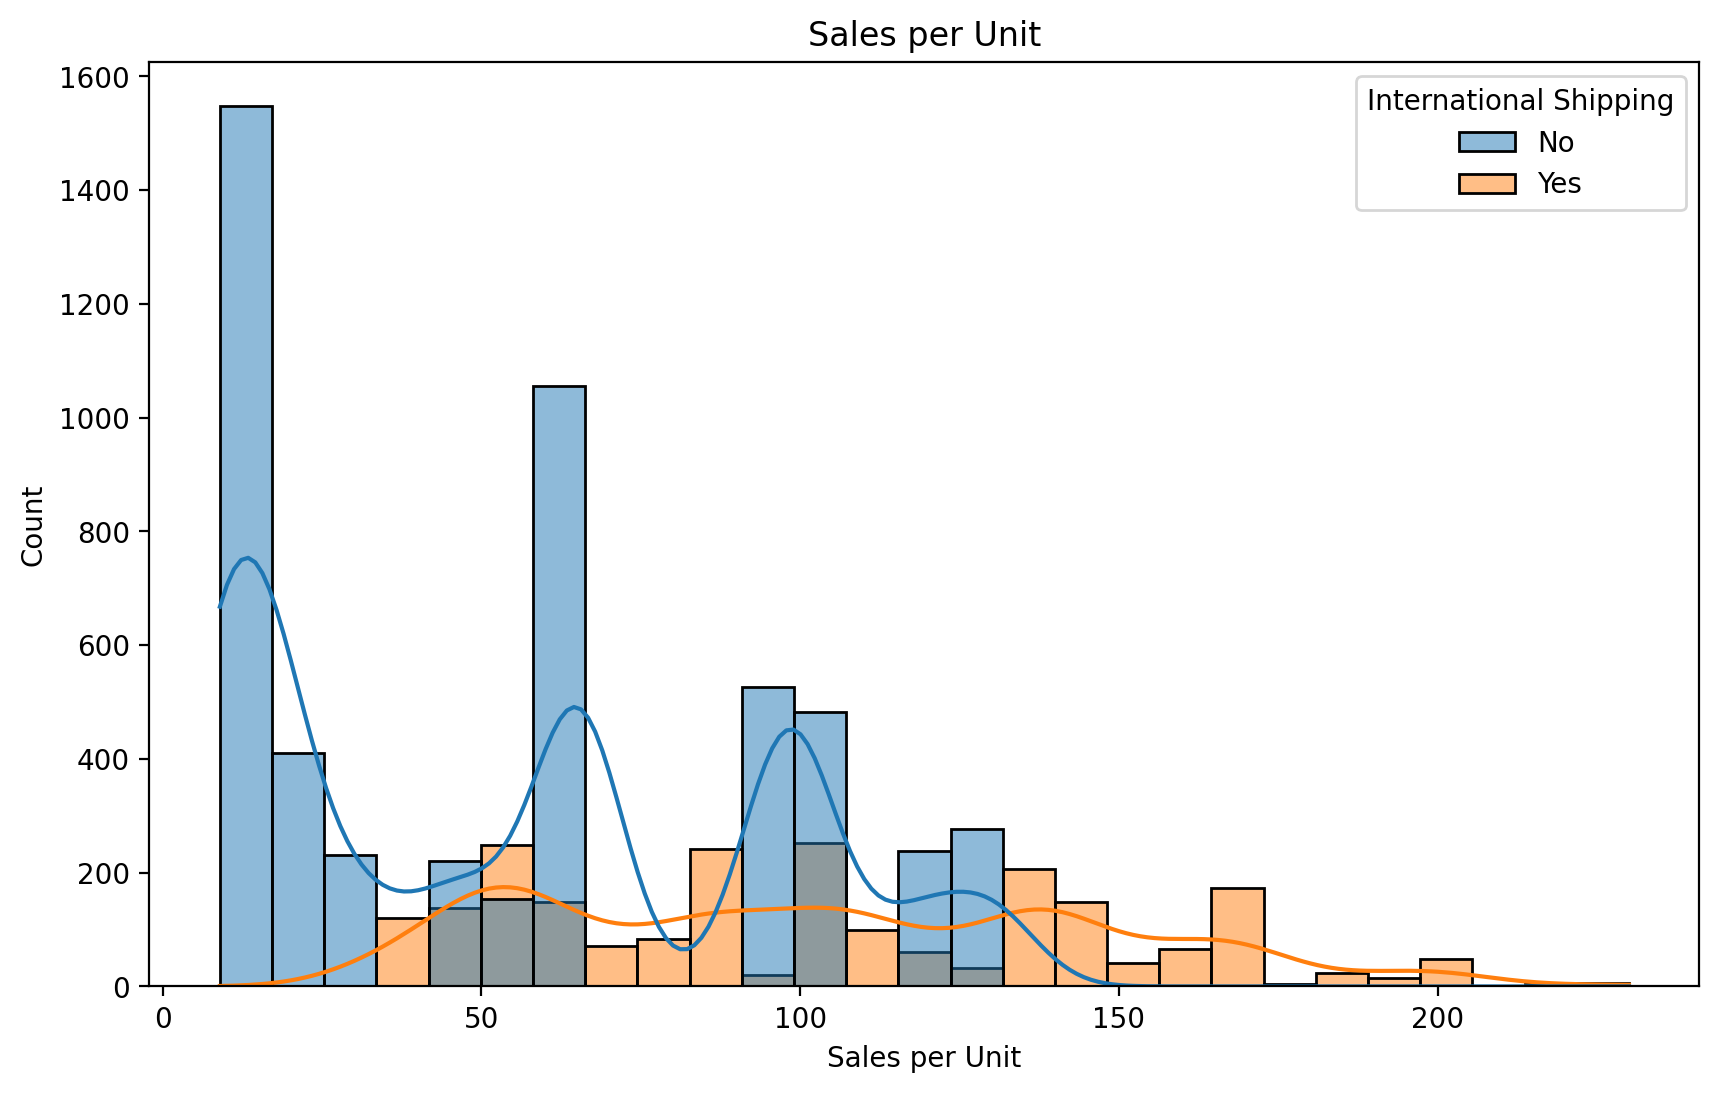

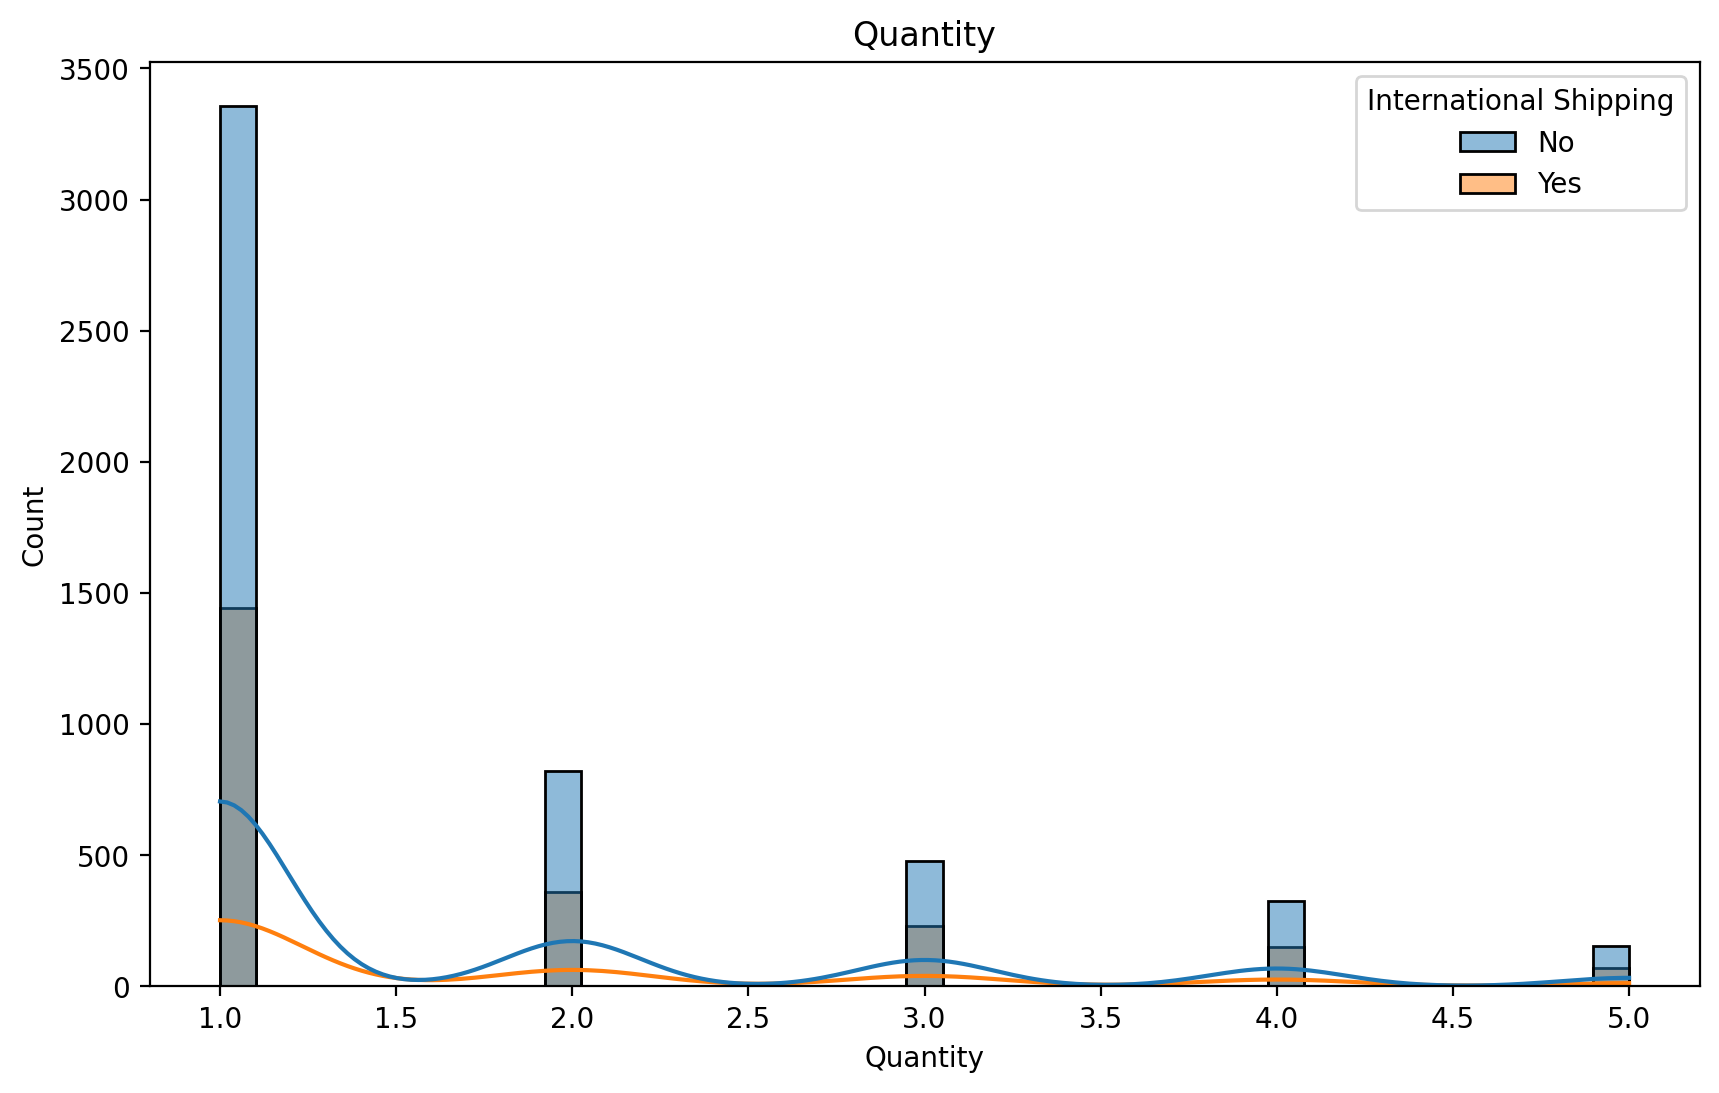

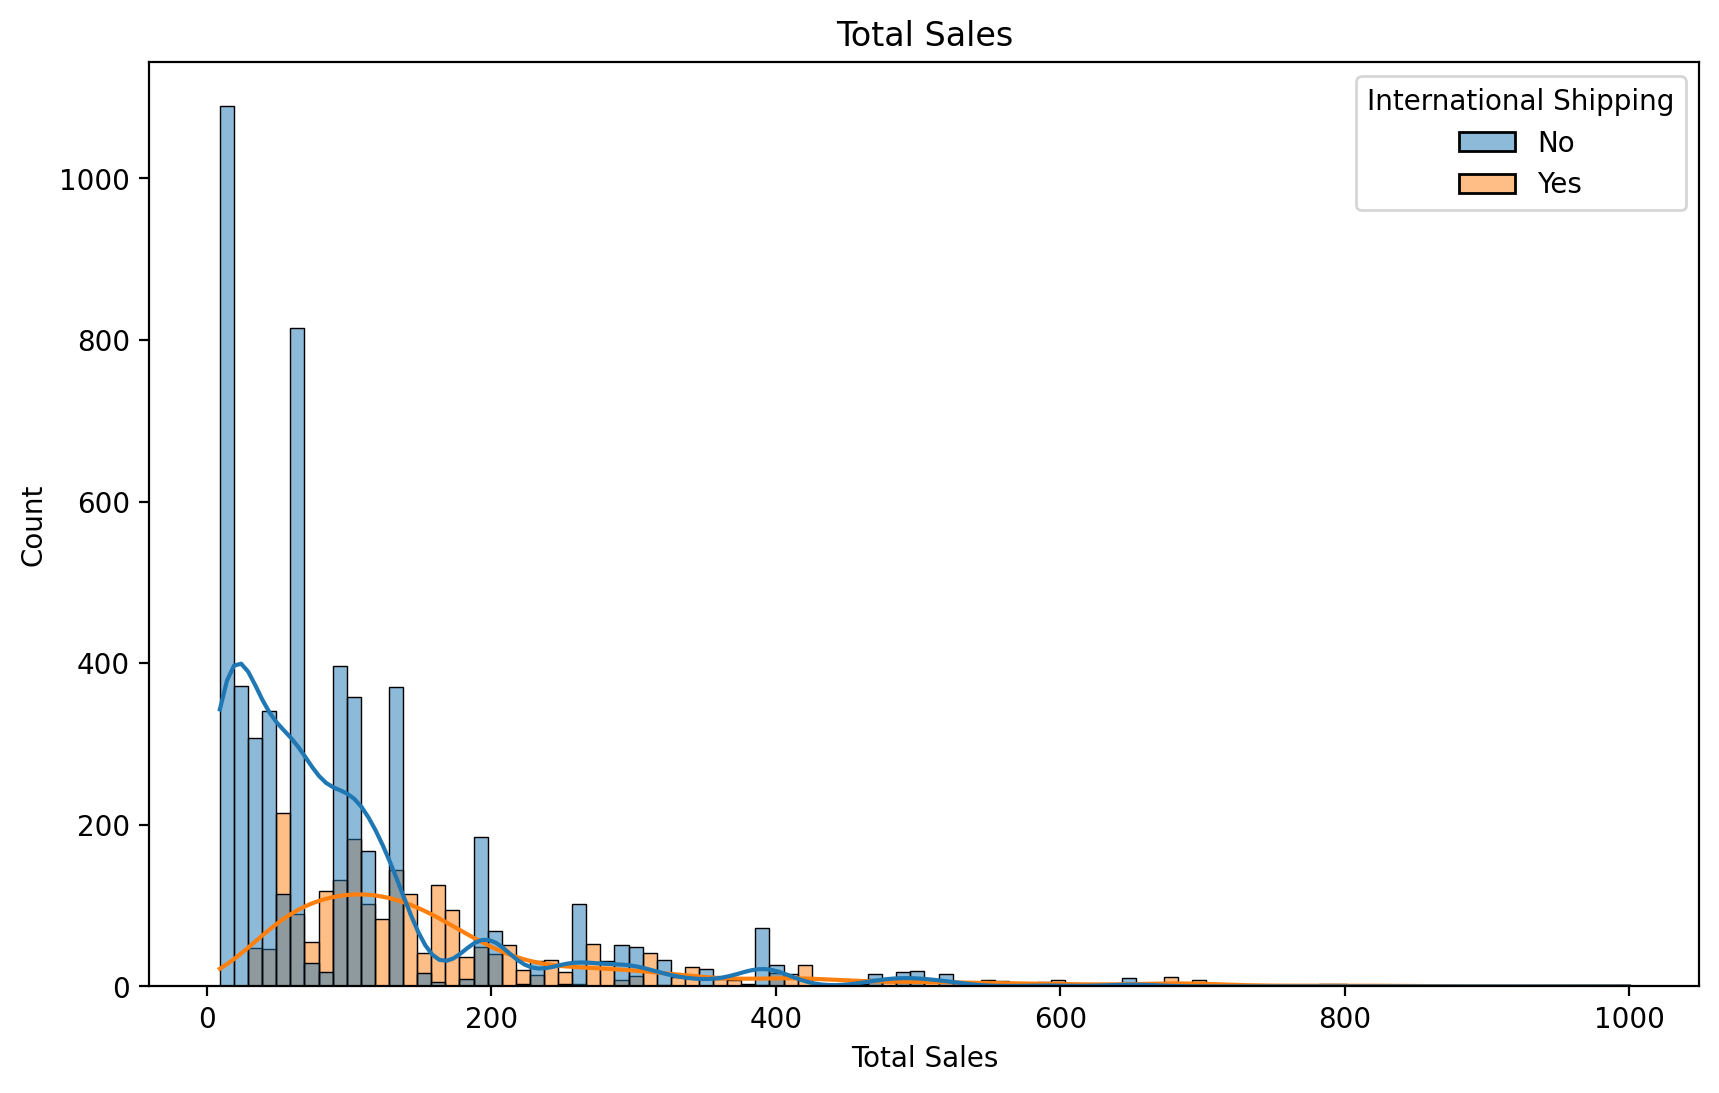

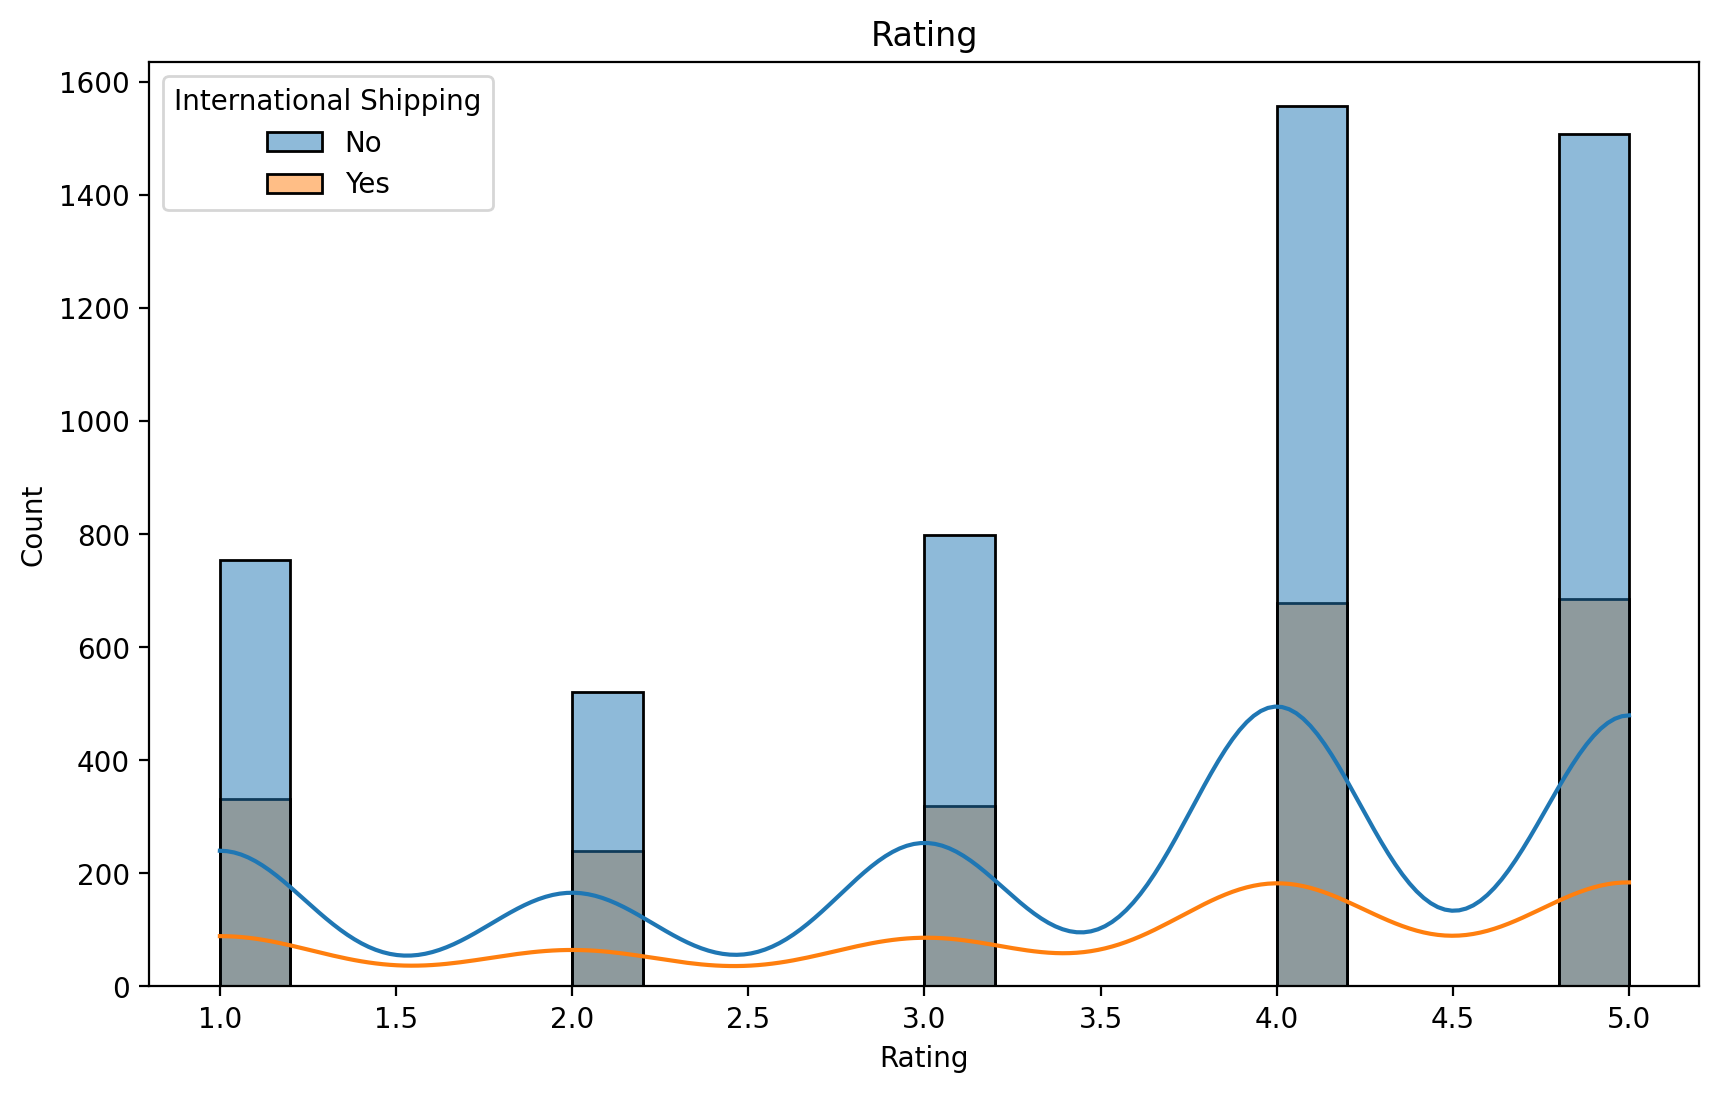

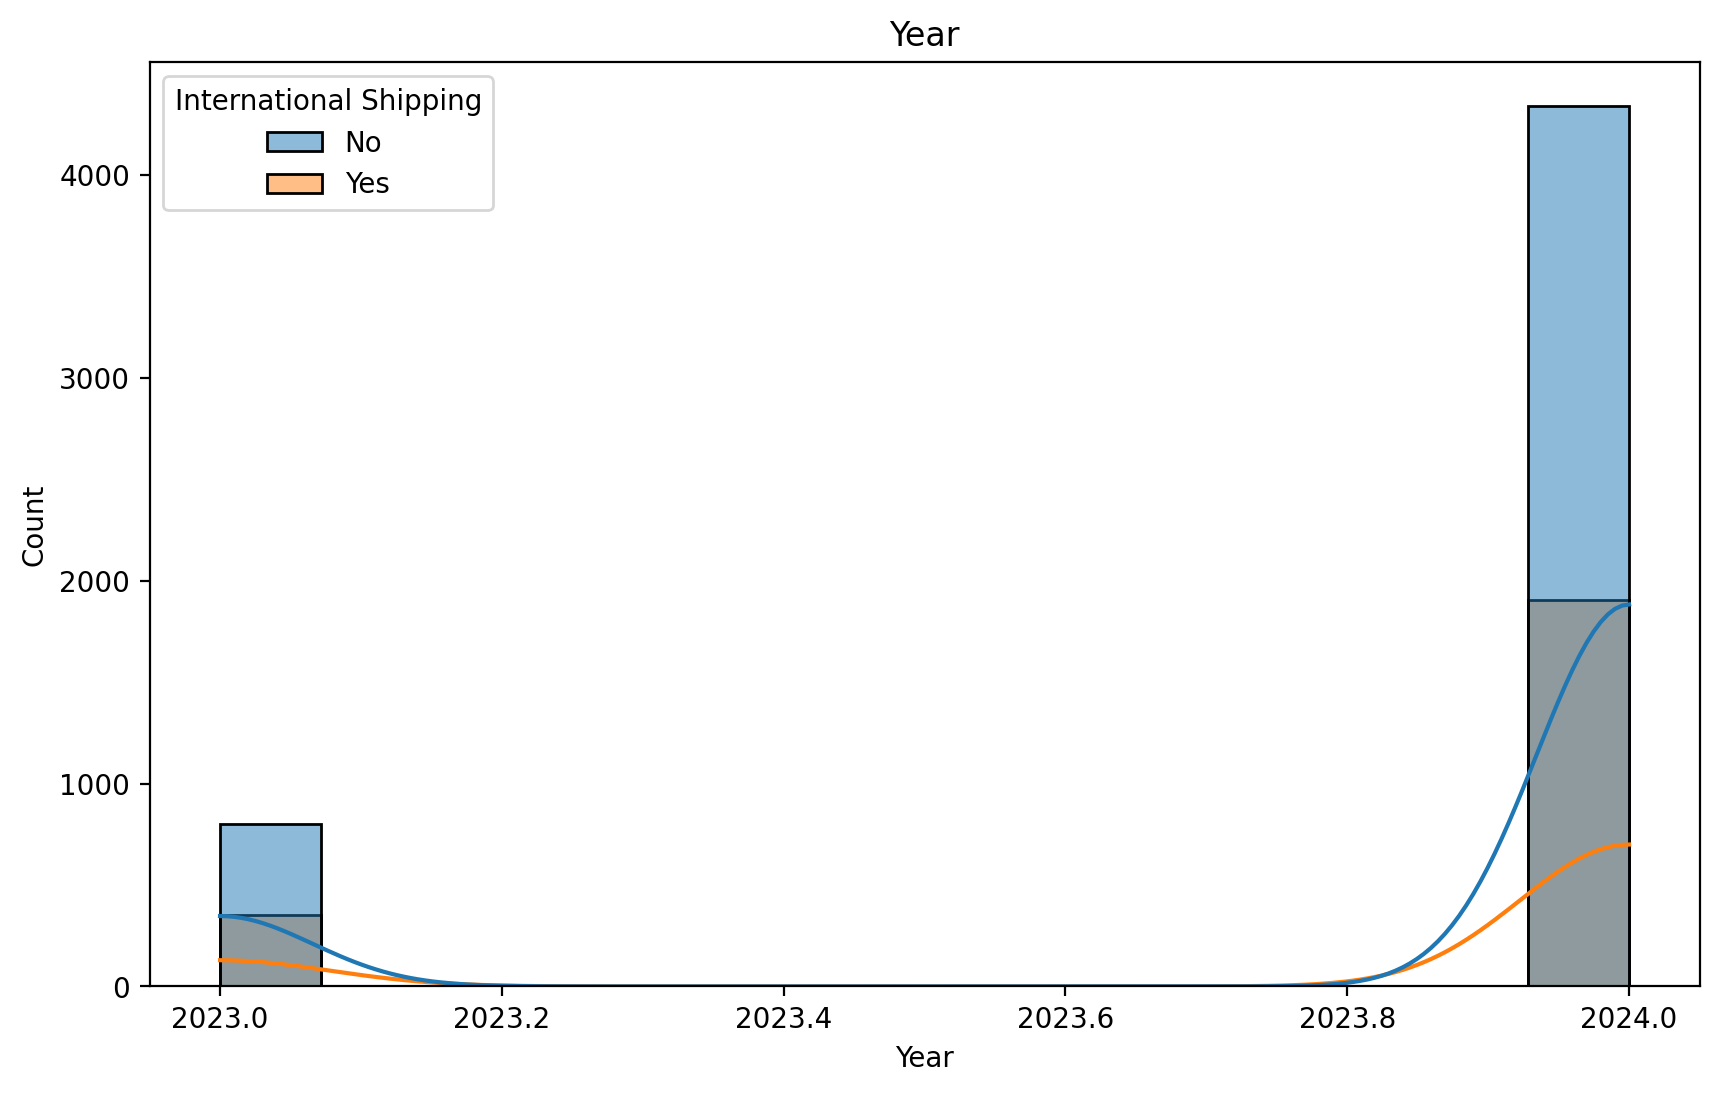

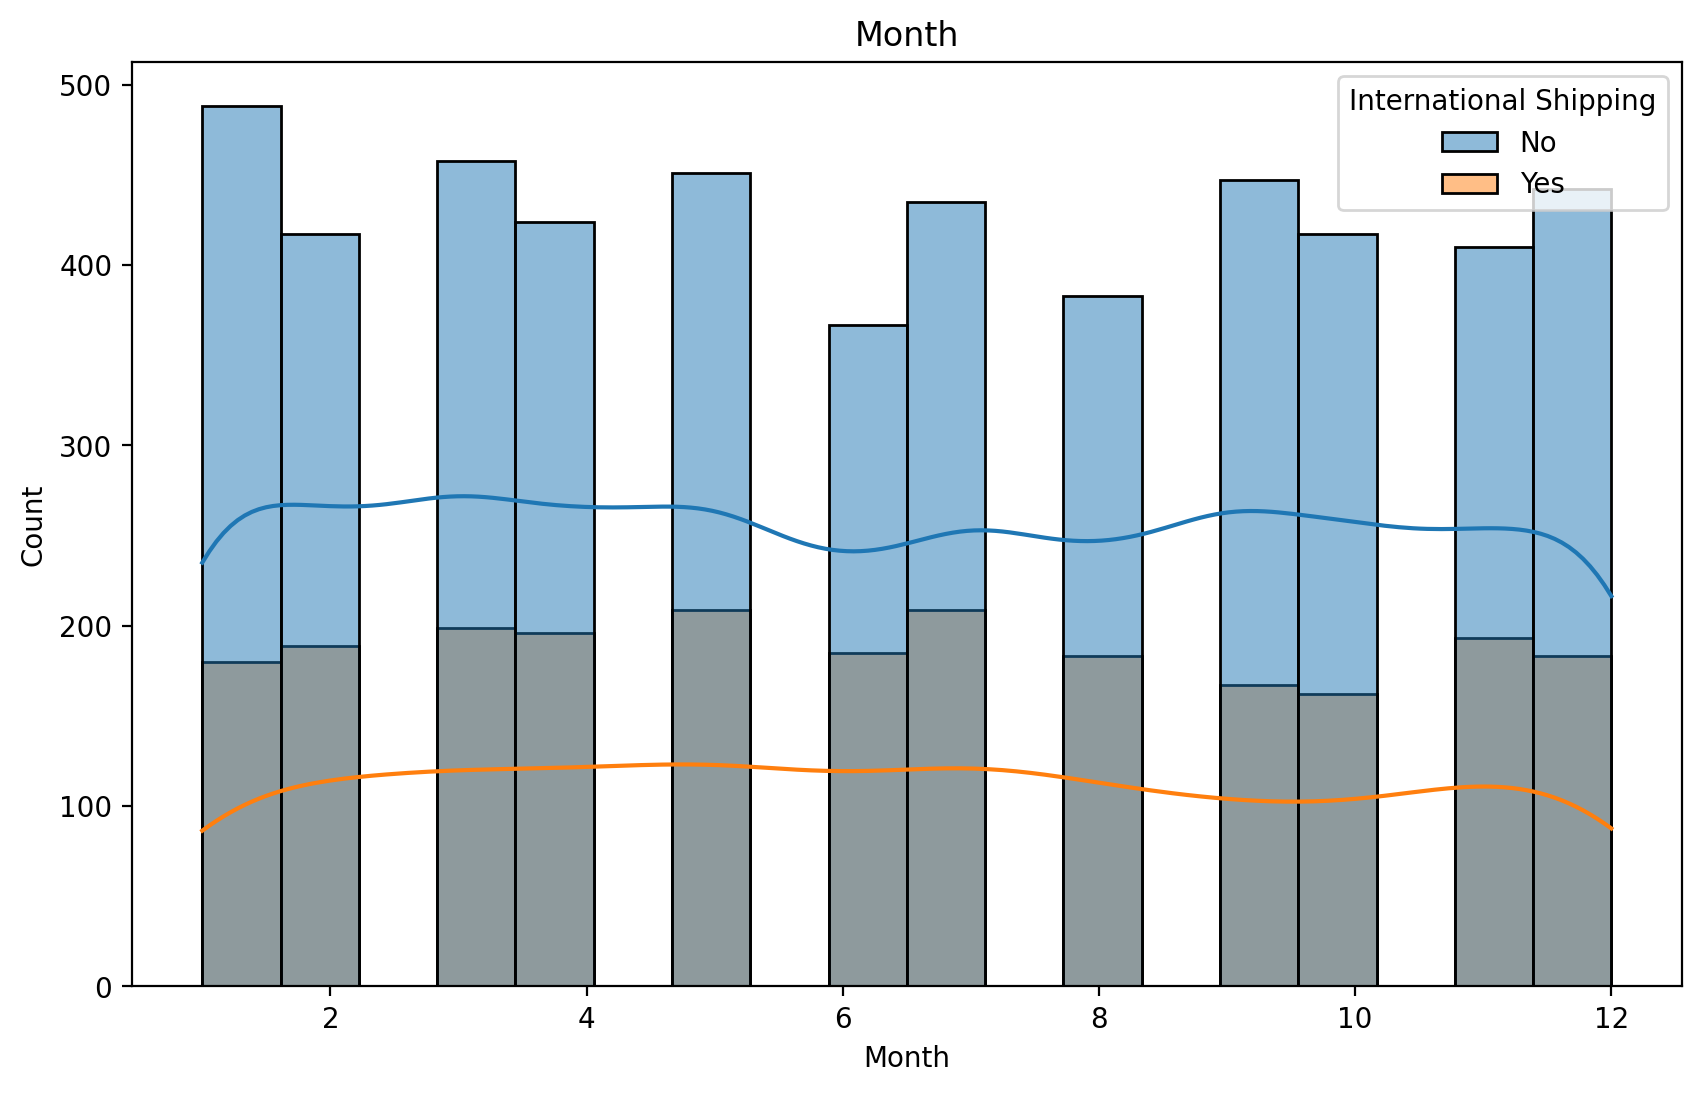

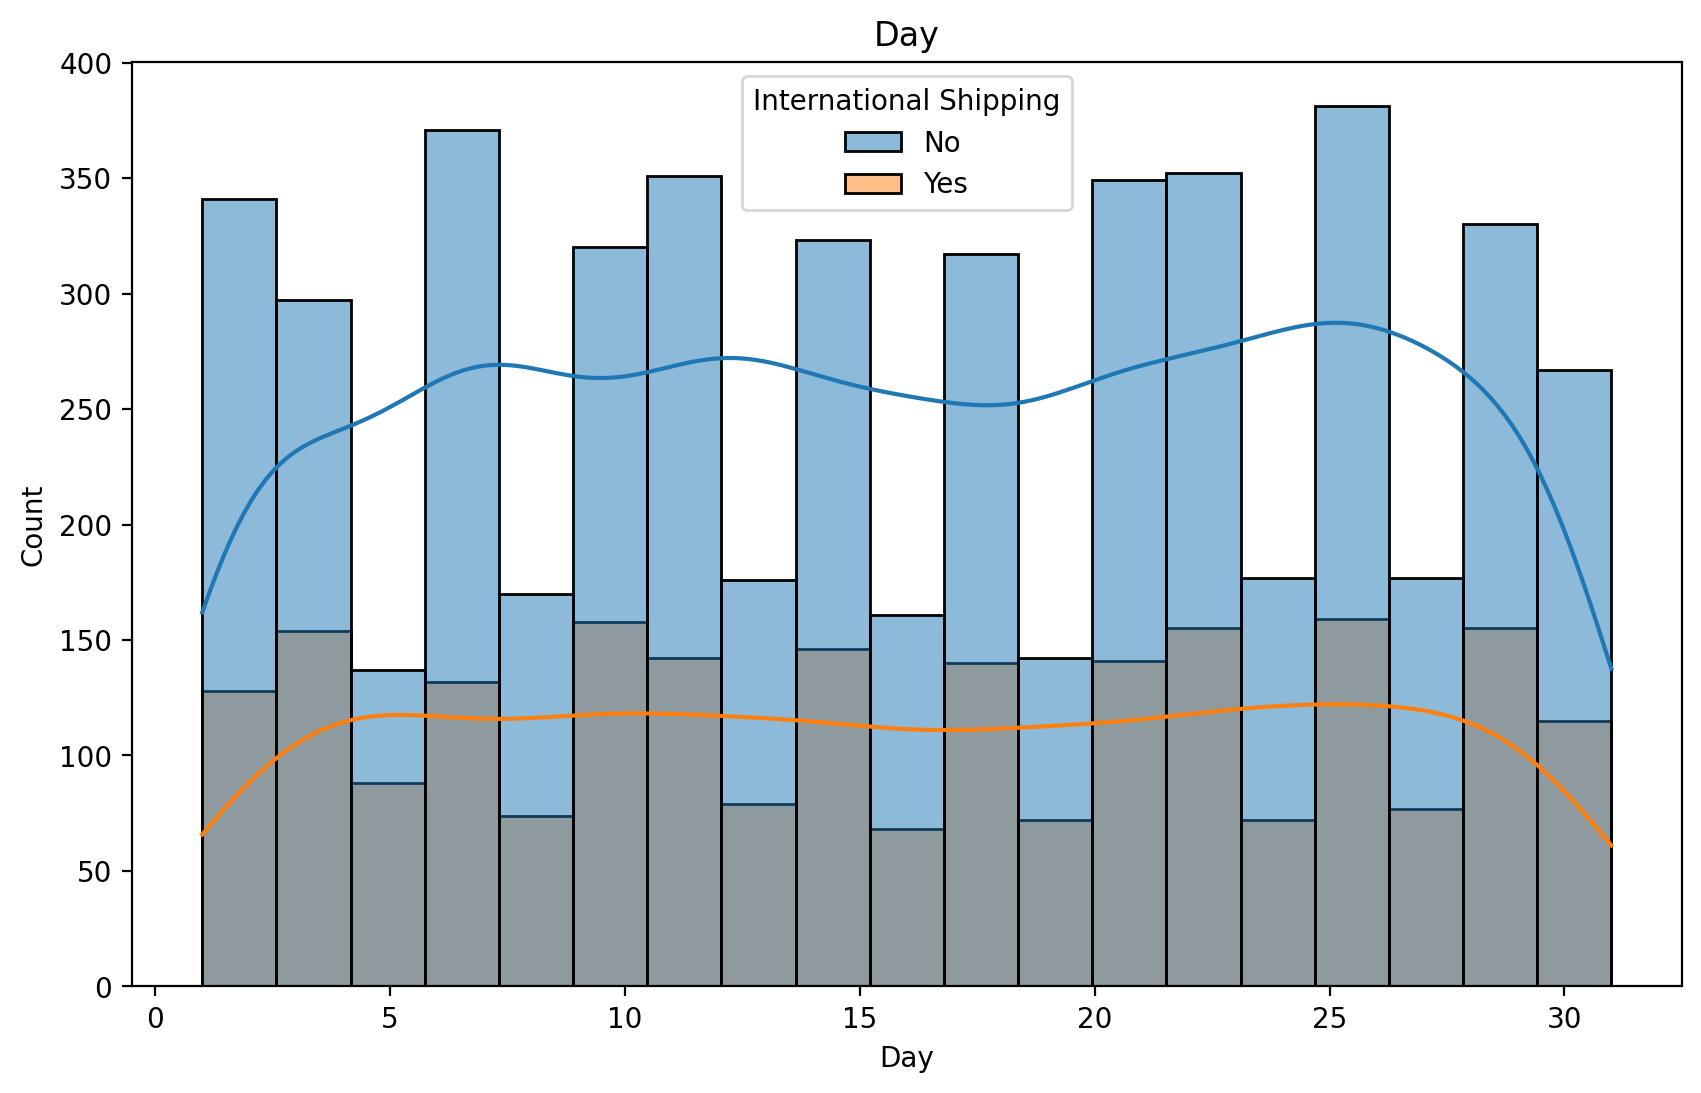

In [ ]:
# plot a histogram for numerical columns along with hue and kernel density estimator
for column in numerical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.histplot(data=df, x=column, color='green', edgecolor='black', hue='International Shipping',kde=True)
  plt.title(column)
  plt.xlabel(column)
  plt.show()

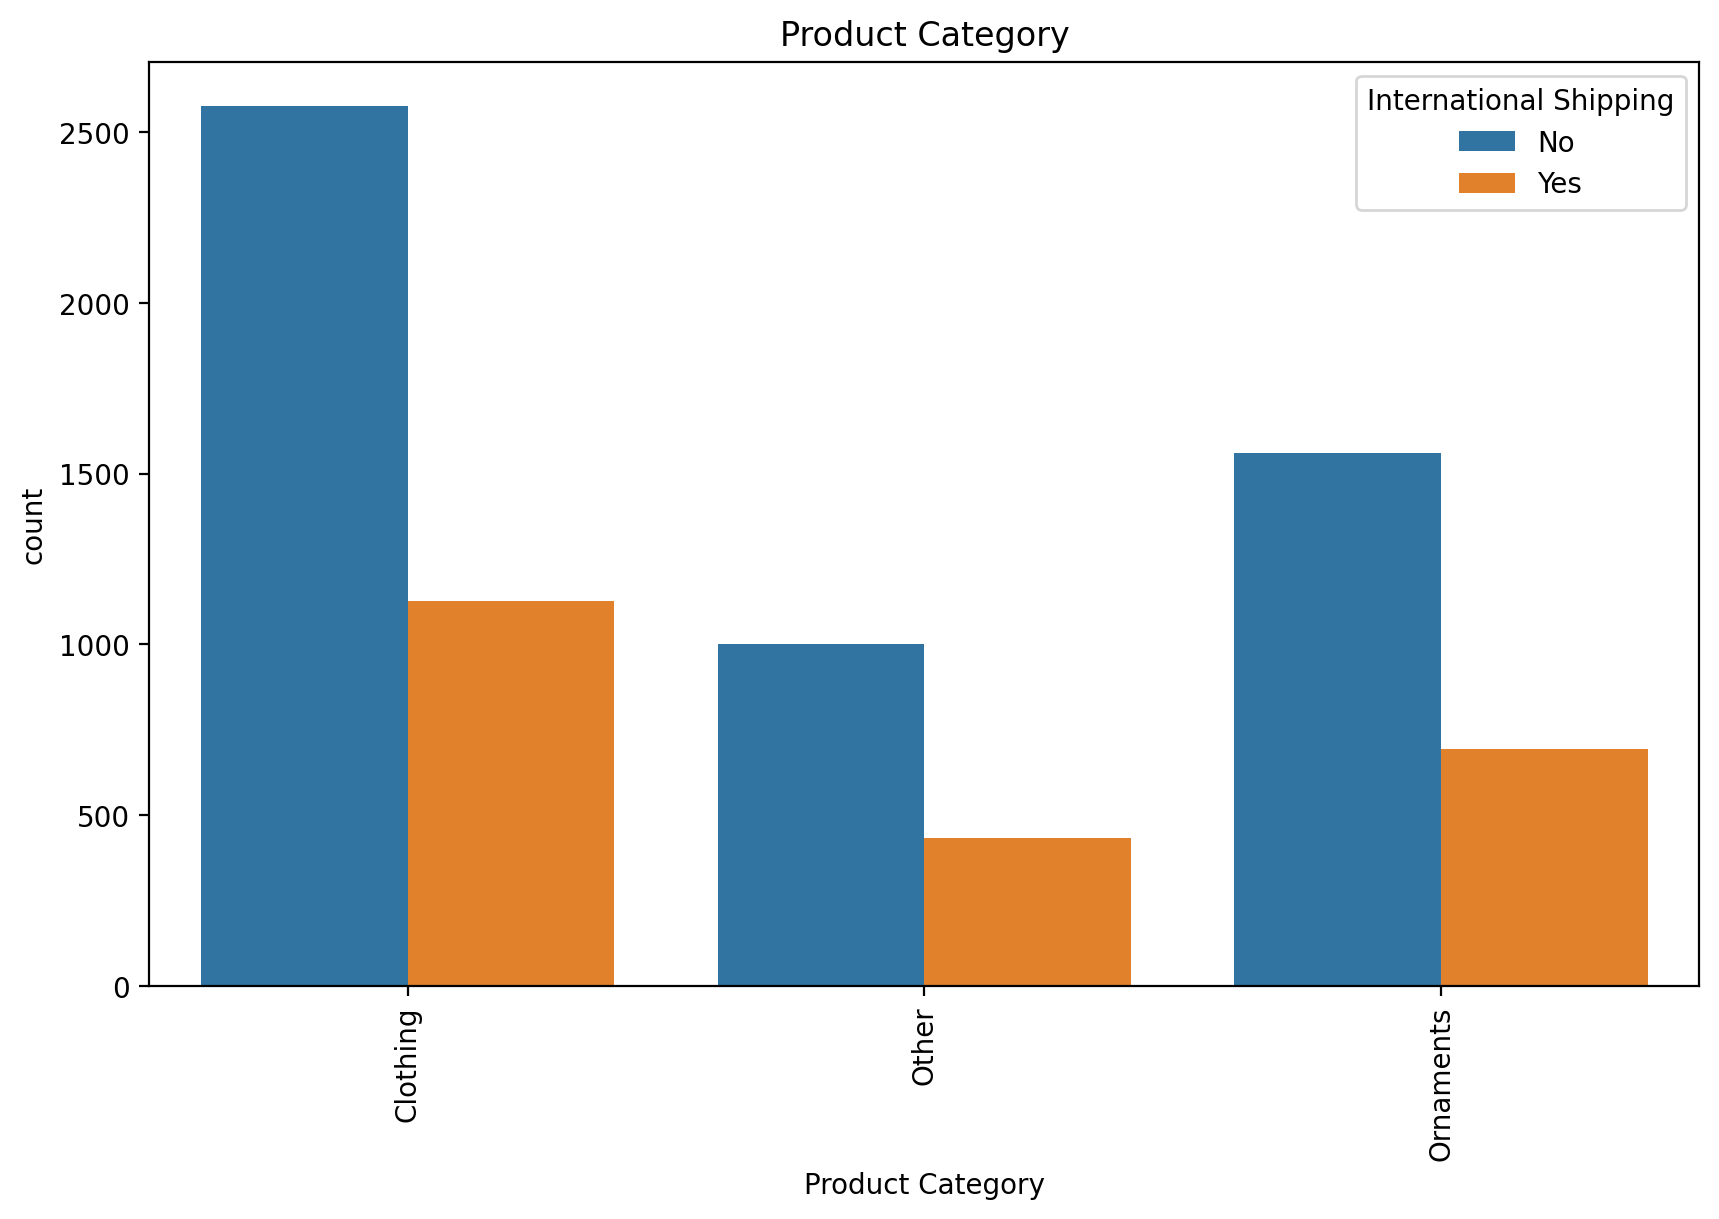

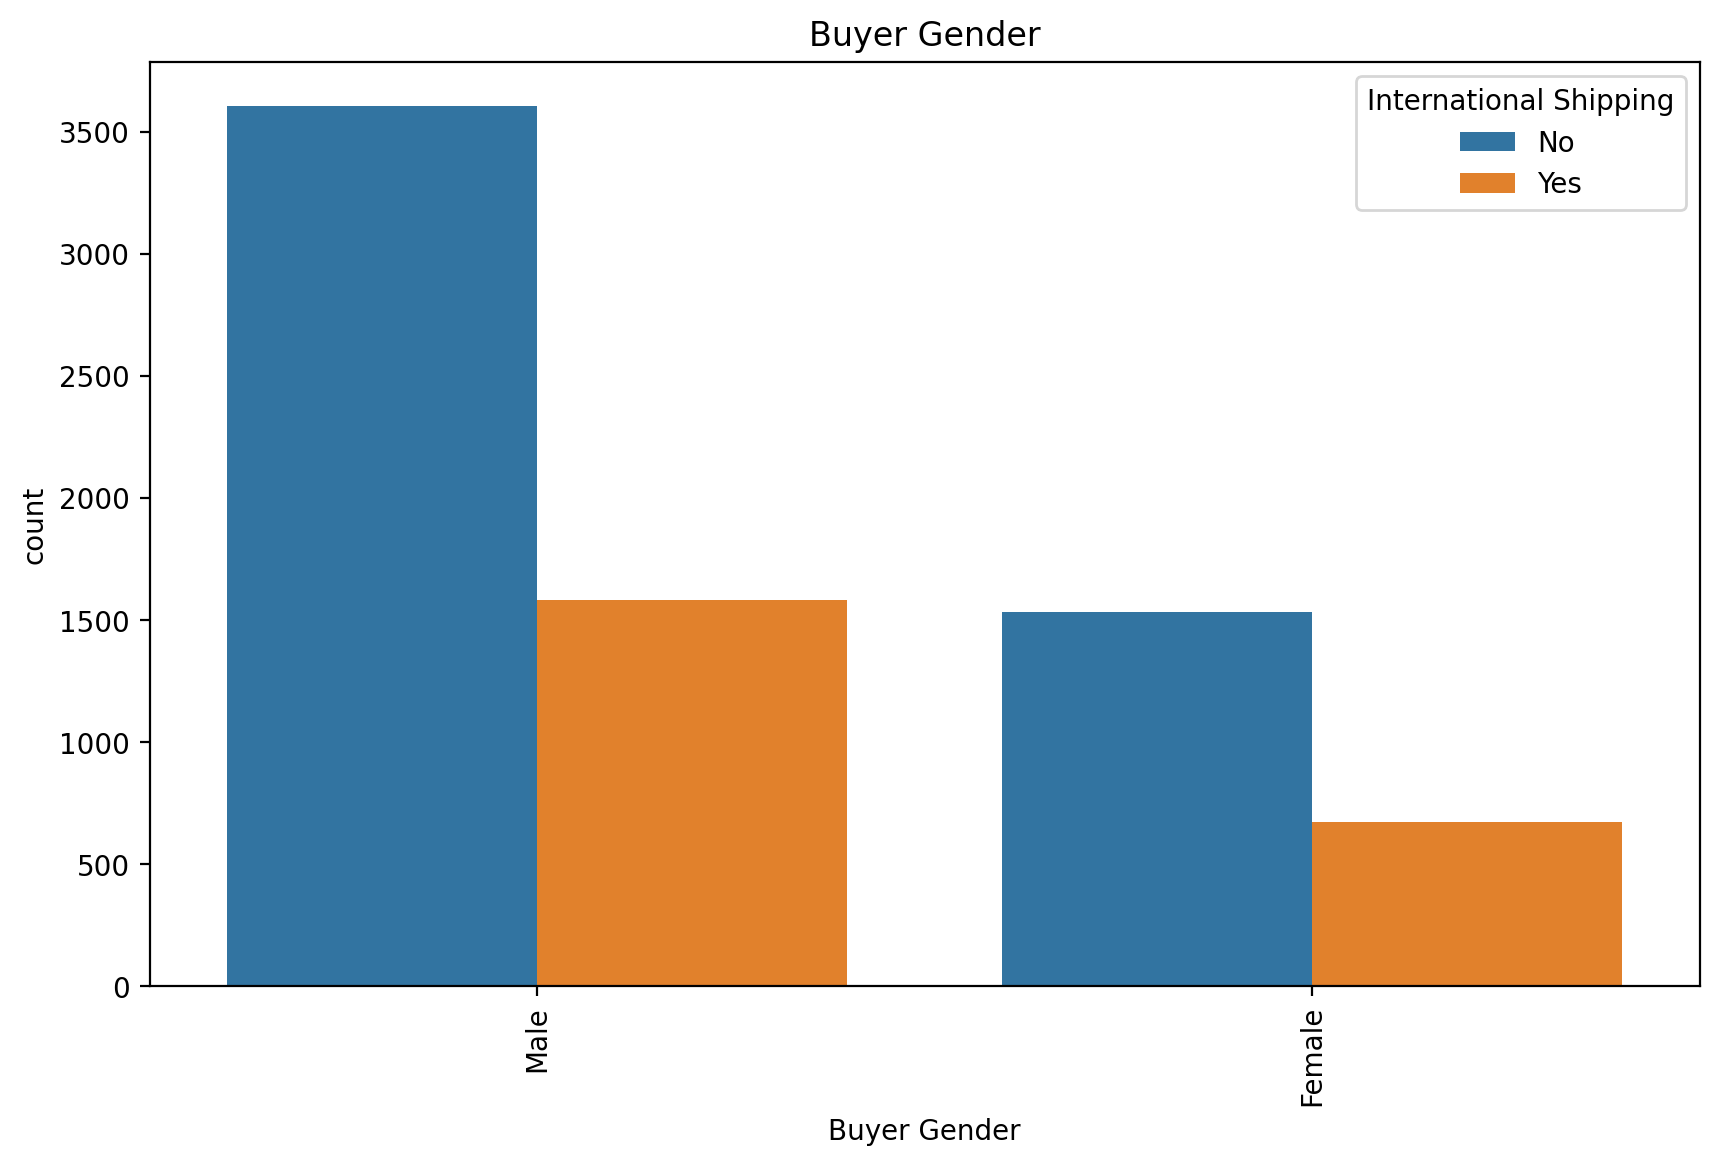

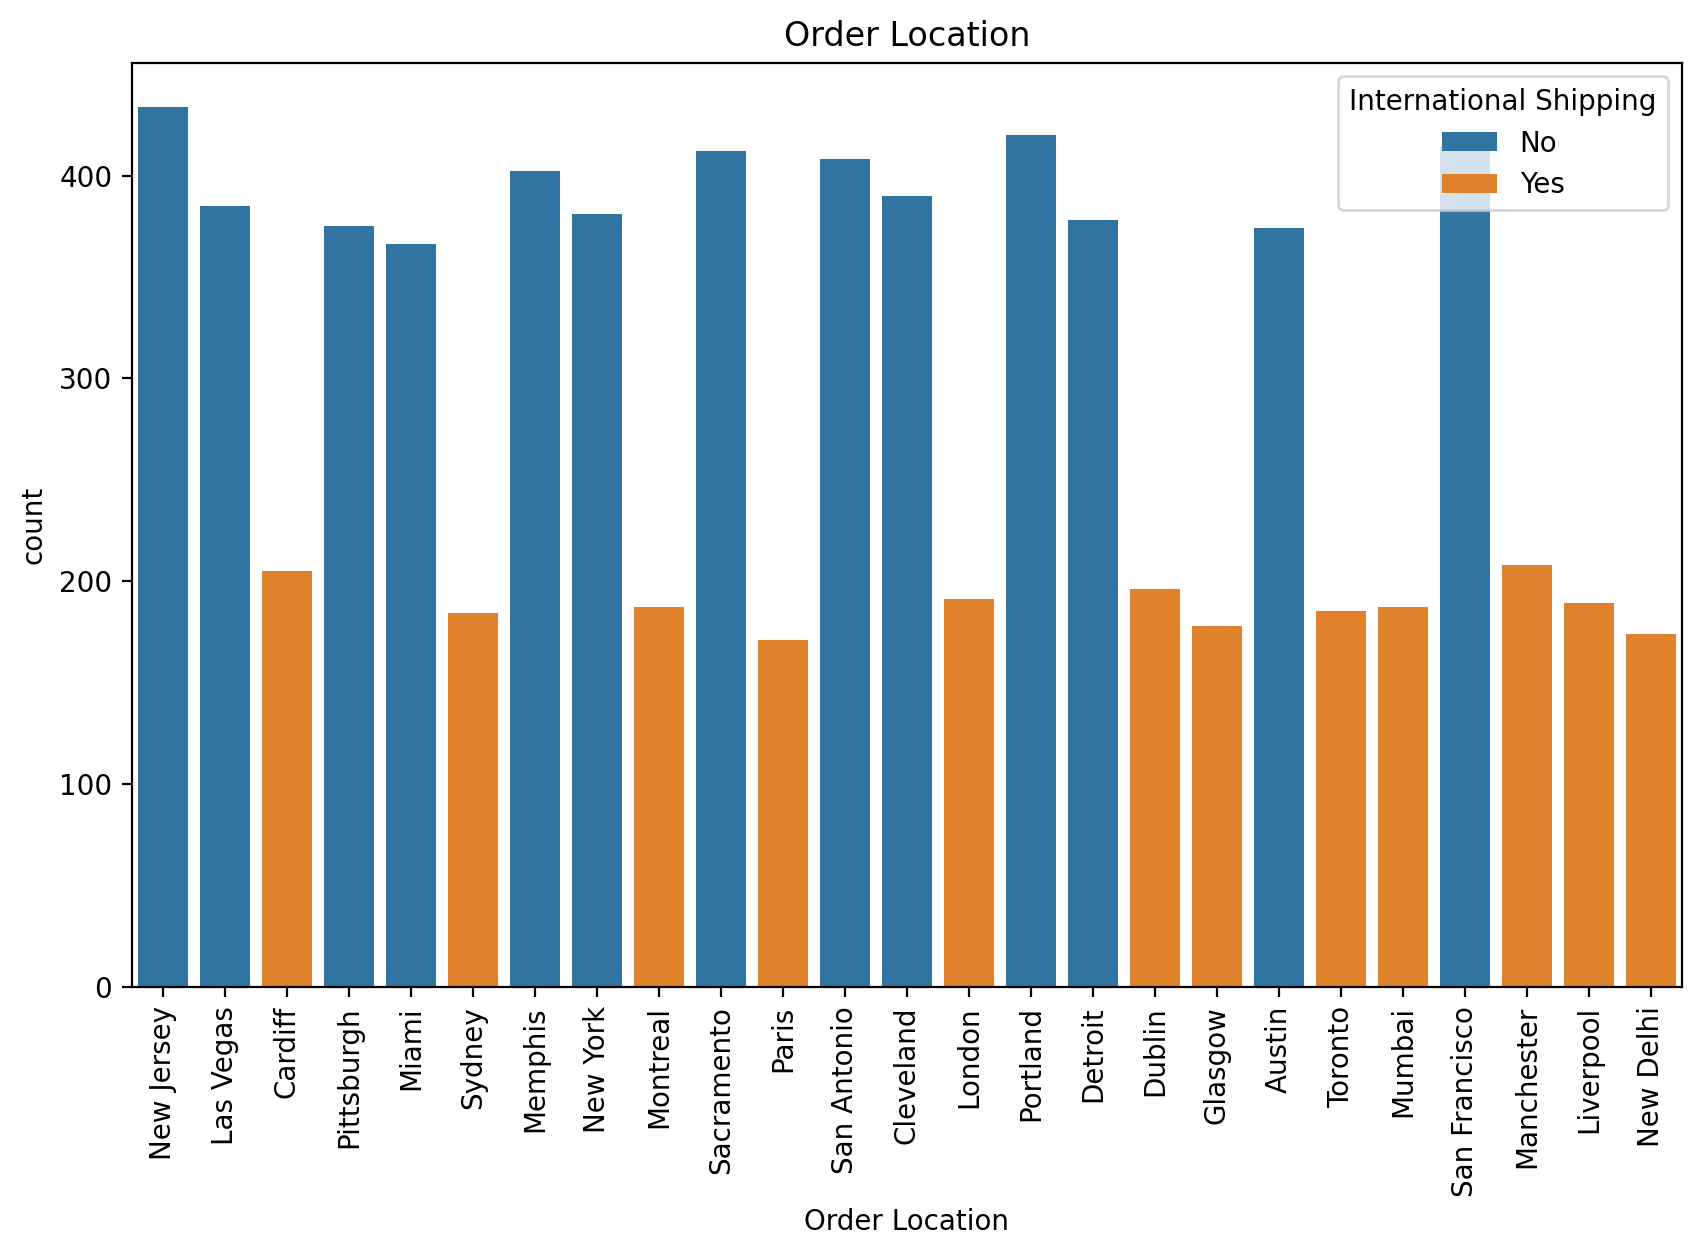

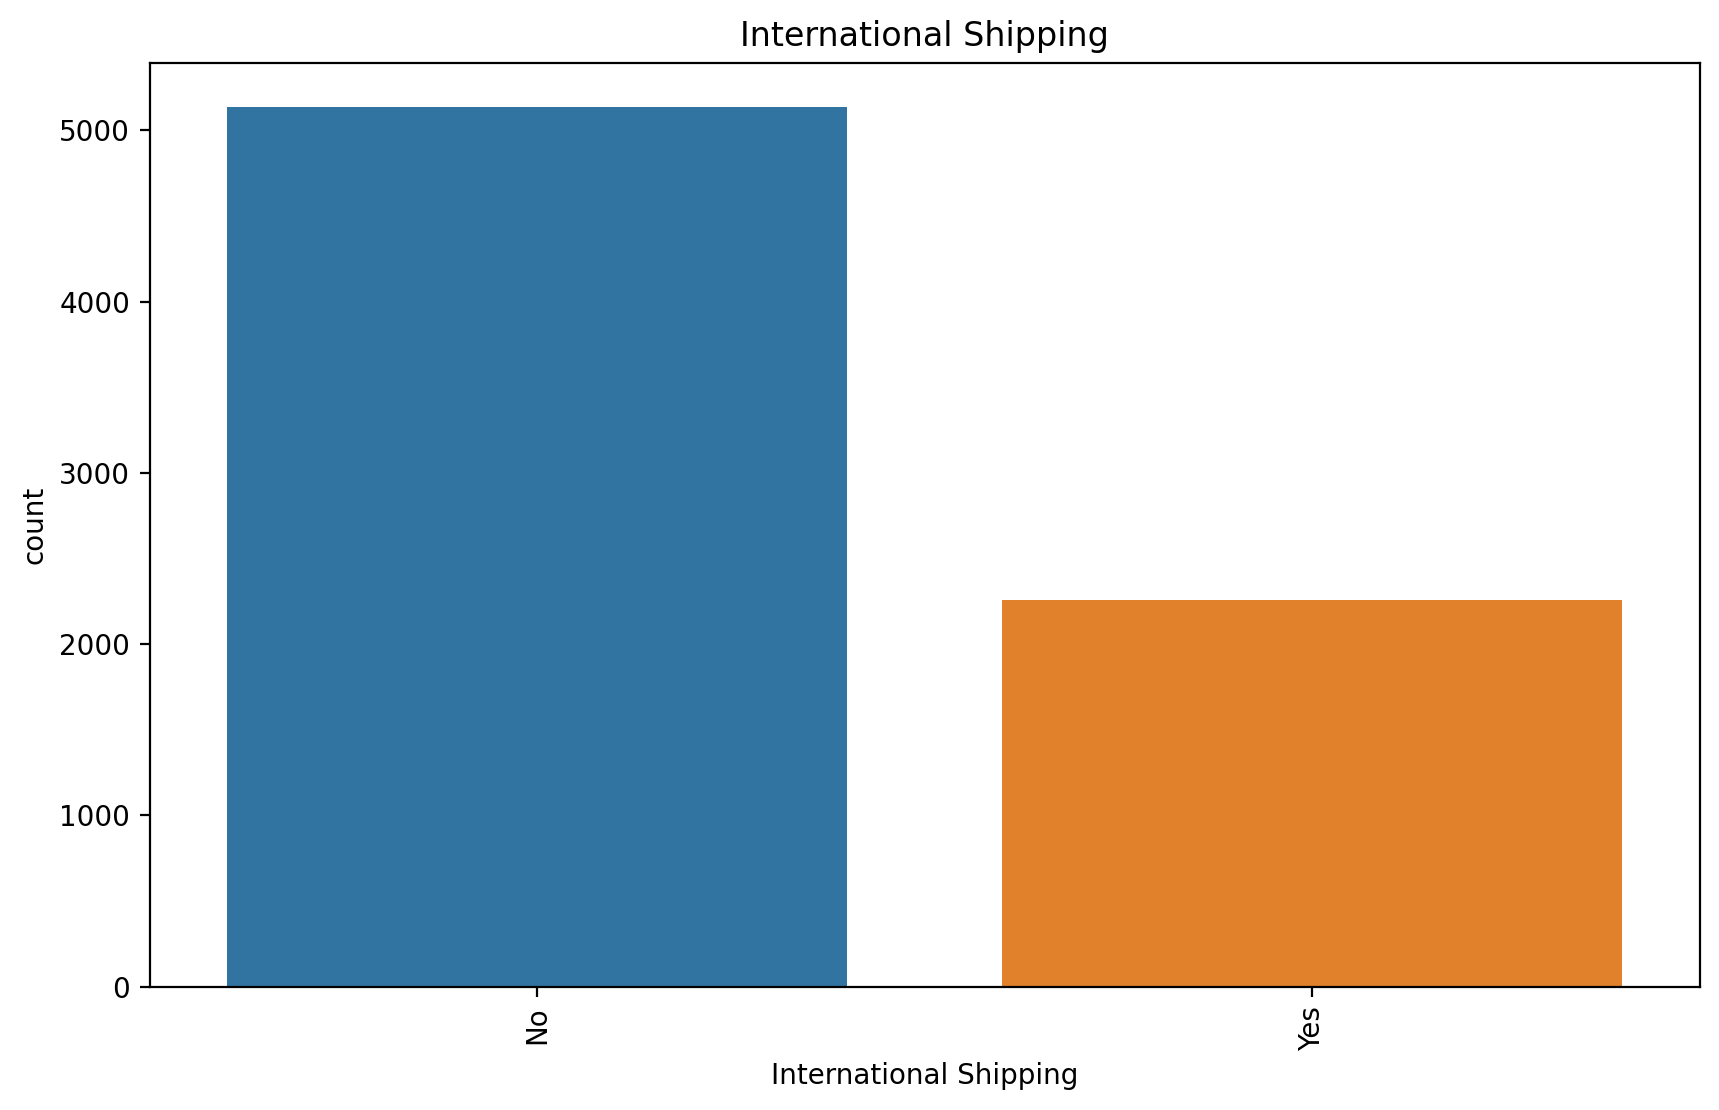

In [ ]:
# plot a count plot for categorical columns along with hue
for column in categorical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.countplot(data=df,x=df[column],hue='International Shipping')
  plt.xticks(rotation=90)
  plt.title(column)
  plt.show()

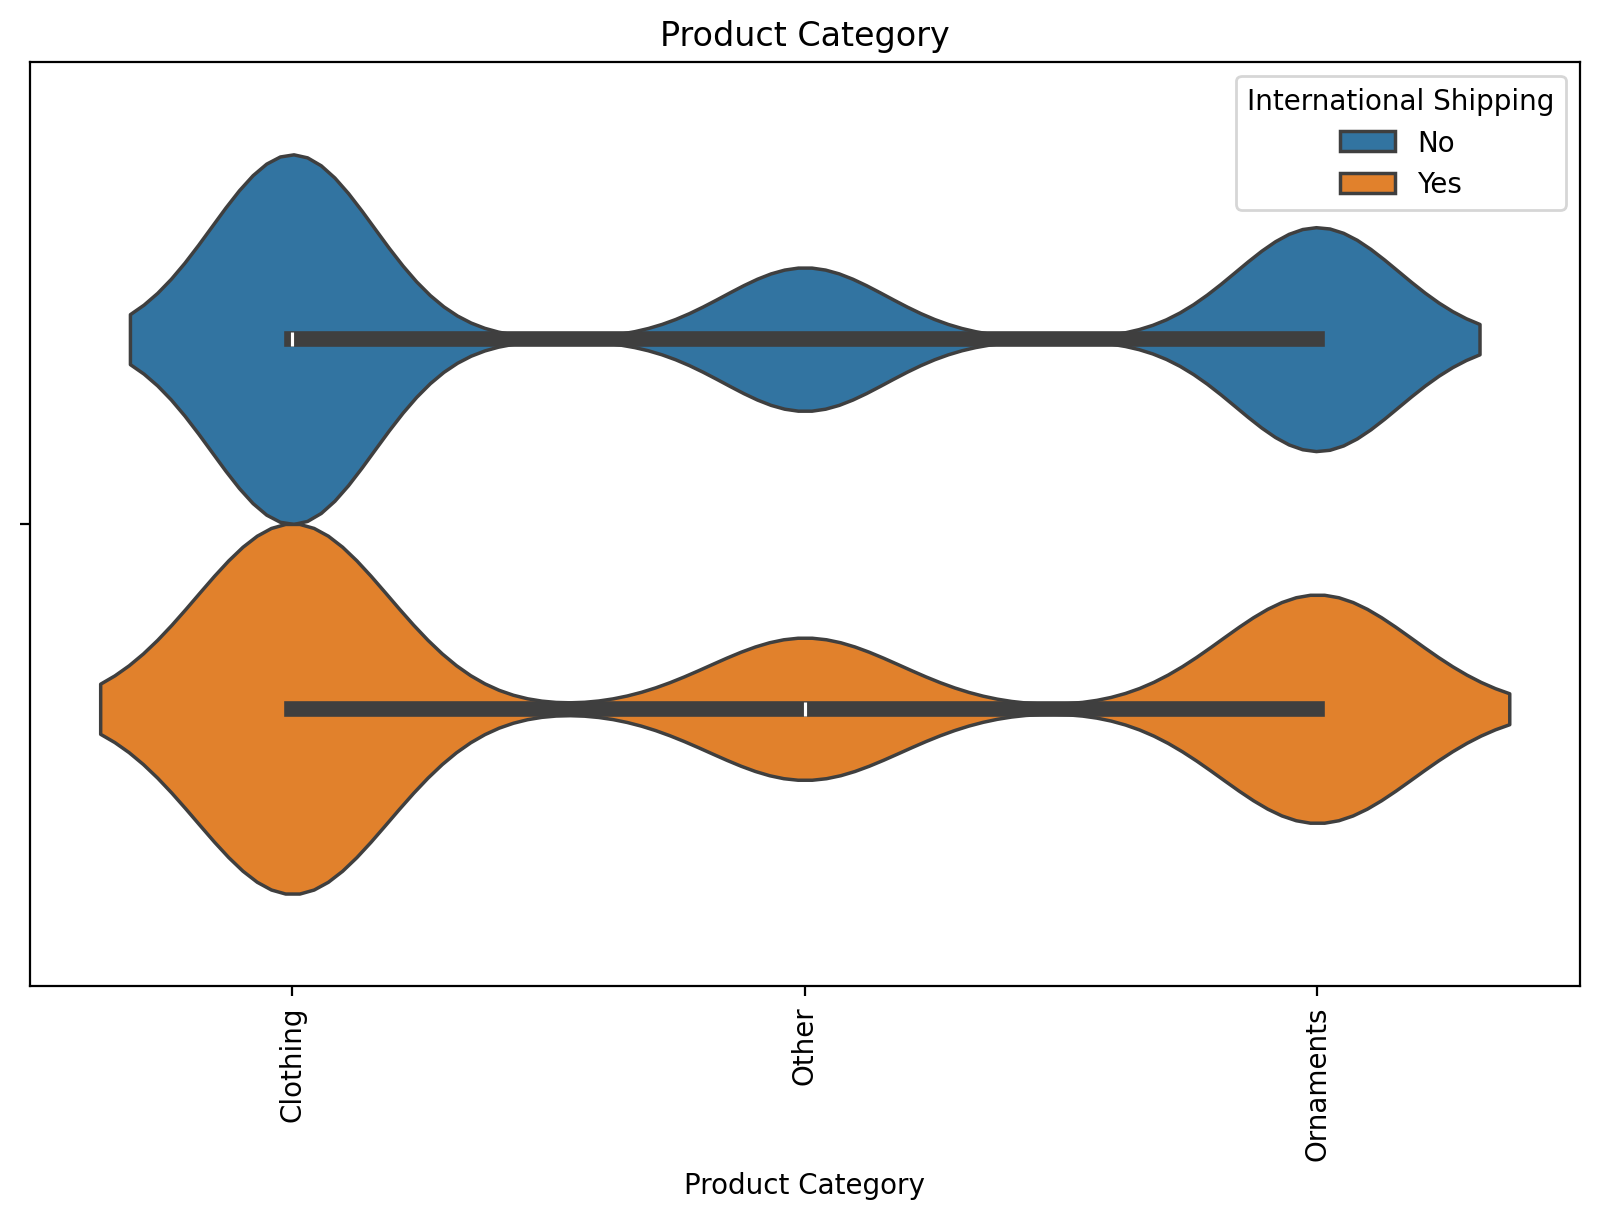

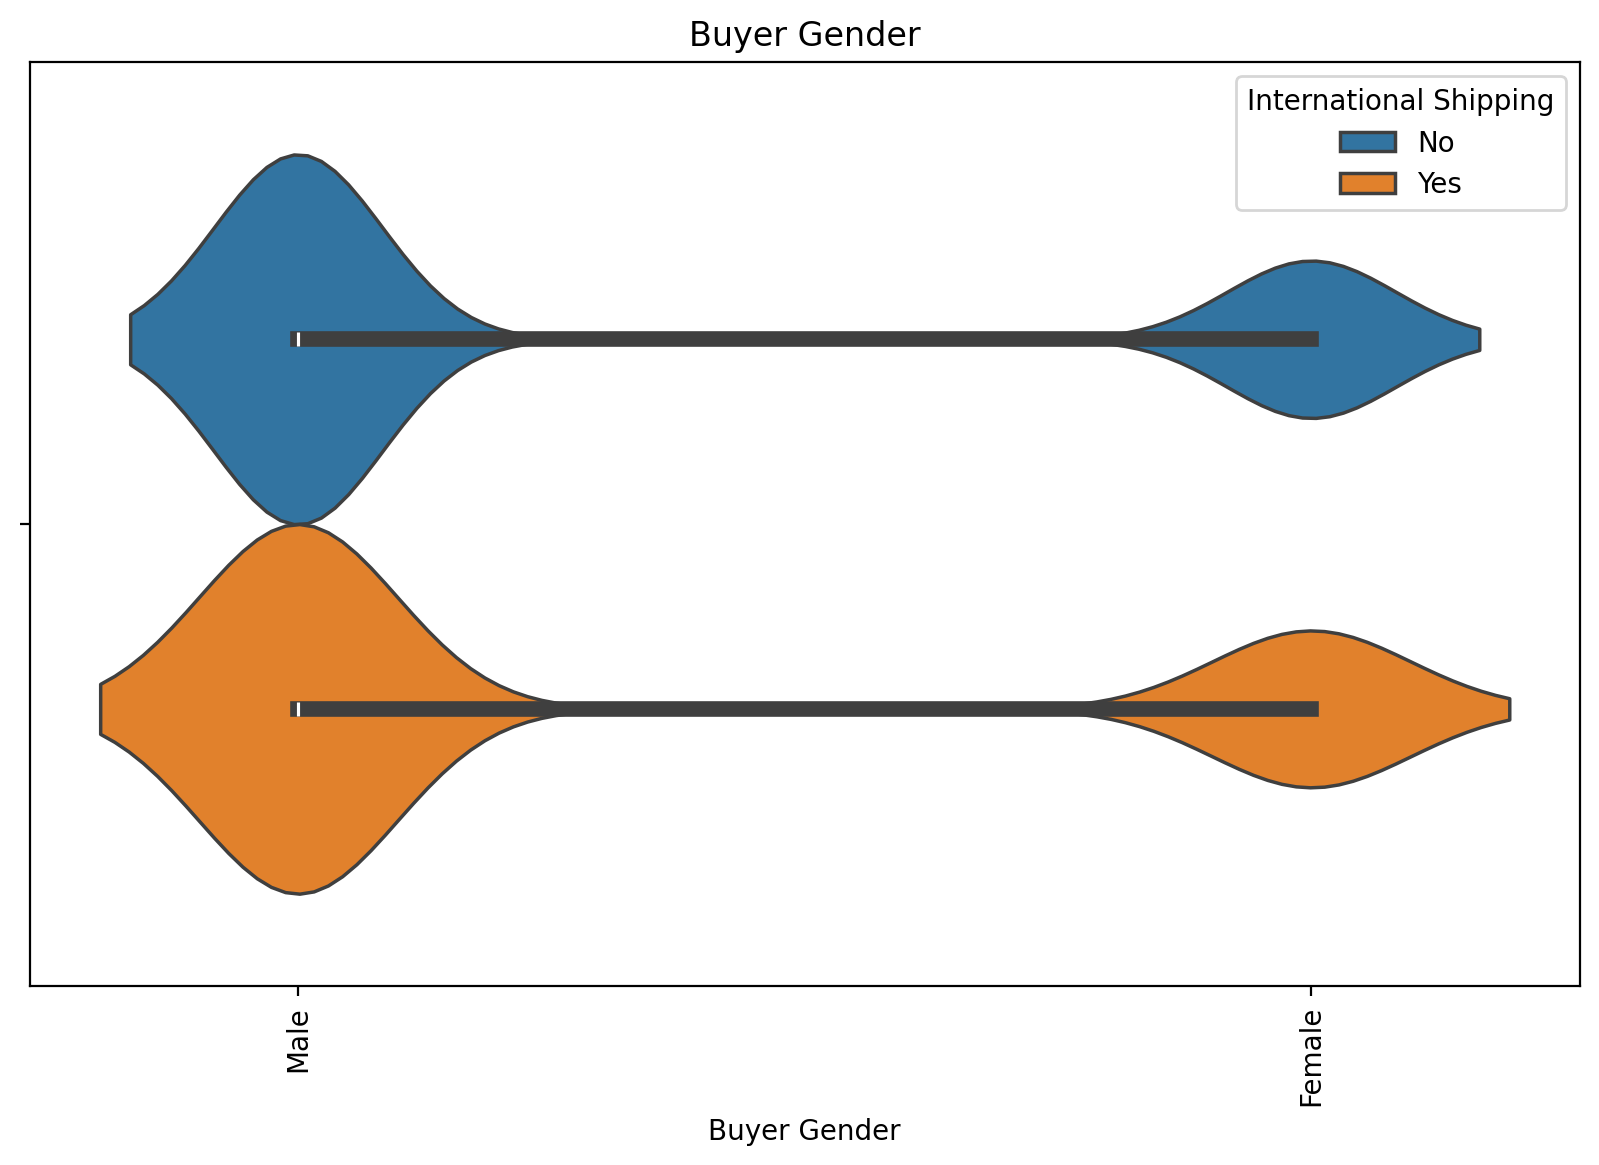

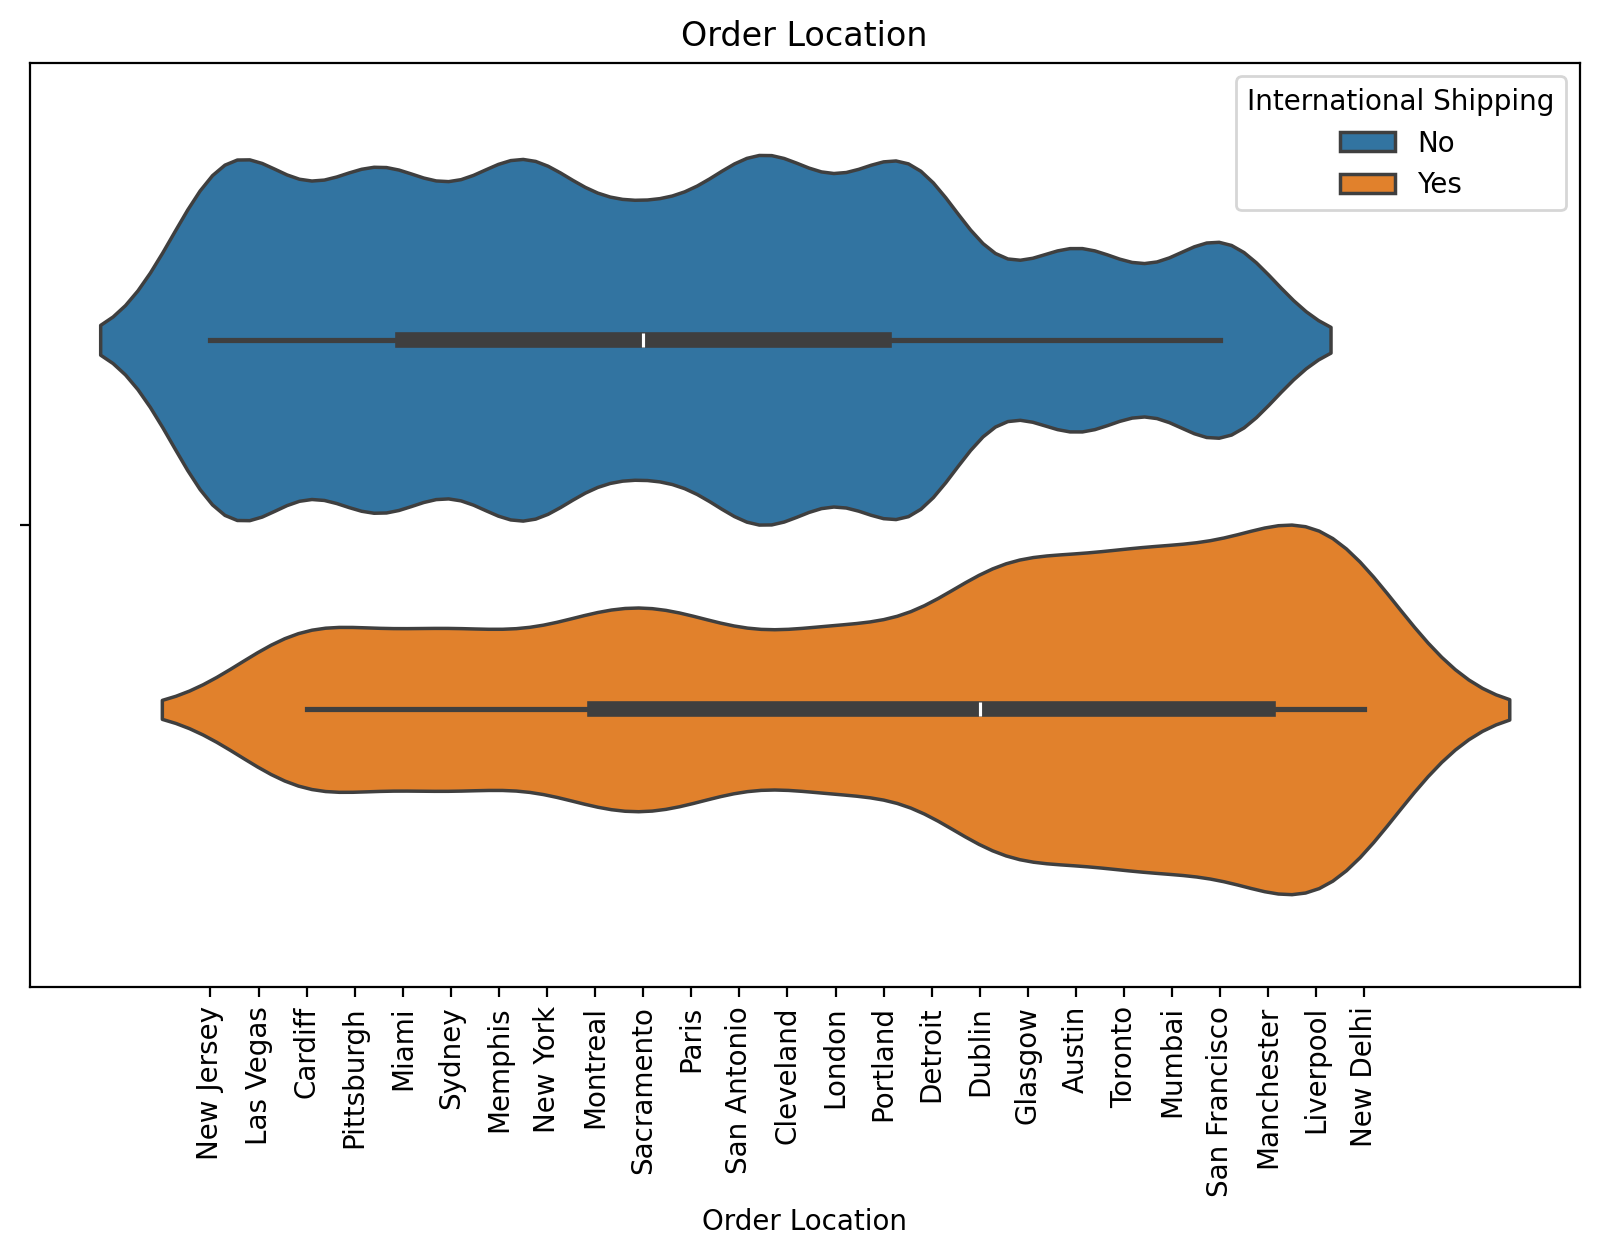

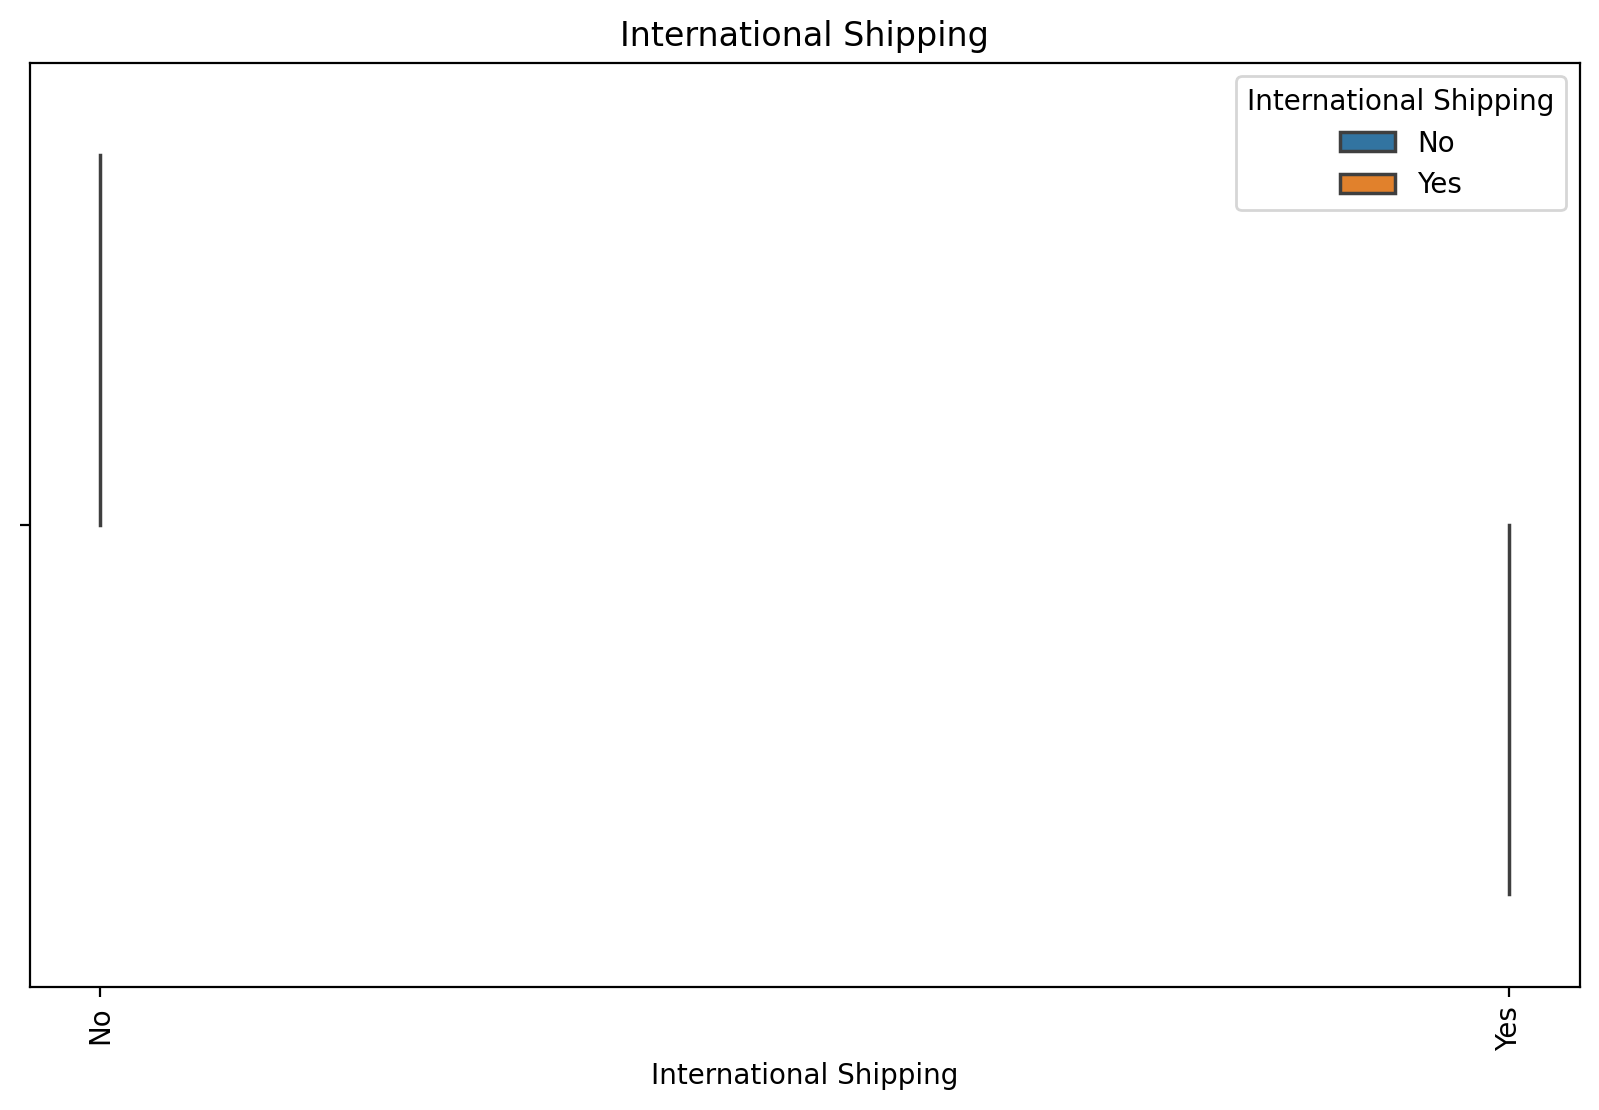

In [ ]:
# plot a violin plot for categorical columns along with hue
for column in categorical:
  plt.figure(figsize=(10,6),dpi=200)
  sns.violinplot(data=df,x=df[column],hue='International Shipping')
  plt.xticks(rotation=90)
  plt.title(column)
  plt.show()

### Multivariate Analysis

**Multivariate analysis** refers to statistical techniques that simultaneously examine the **relationships among three or more variables.** It aims to understand the **complex interactions and dependencies between multiple variables in a dataset.**

In [ ]:
# find correlation for numerical columns
df.corr(numeric_only=True)

,Buyer Age,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
Buyer Age,1.000000,-0.004254,-0.007771,-0.007735,0.010515,0.001450,0.009609,-0.008468,0.002504,0.004357
Sales Price,-0.004254,1.000000,-0.000480,0.847147,-0.020237,0.543286,-0.008842,0.005292,0.011103,0.013644
Shipping Charges,-0.007771,-0.000480,1.000000,0.530953,0.009907,0.349969,0.009521,0.007556,-0.004273,-0.000326
Sales per Unit,-0.007735,0.847147,0.530953,1.000000,-0.011885,0.646340,-0.002434,0.008499,0.007138,0.011389
Quantity,0.010515,-0.020237,0.009907,-0.011885,1.000000,0.627677,0.011671,-0.022878,0.023658,-0.014699
Total Sales,0.001450,0.543286,0.349969,0.646340,0.627677,1.000000,0.006114,-0.006167,0.018896,-0.005155
Rating,0.009609,-0.008842,0.009521,-0.002434,0.011671,0.006114,1.000000,0.010442,-0.011895,0.003594
Year,-0.008468,0.005292,0.007556,0.008499,-0.022878,-0.006167,0.010442,1.000000,-0.633386,-0.046361
Month,0.002504,0.011103,-0.004273,0.007138,0.023658,0.018896,-0.011895,-0.633386,1.000000,-0.002226
Day,0.004357,0.013644,-0.000326,0.011389,-0.014699,-0.005155,0.003594,-0.046361,-0.002226,1.000000


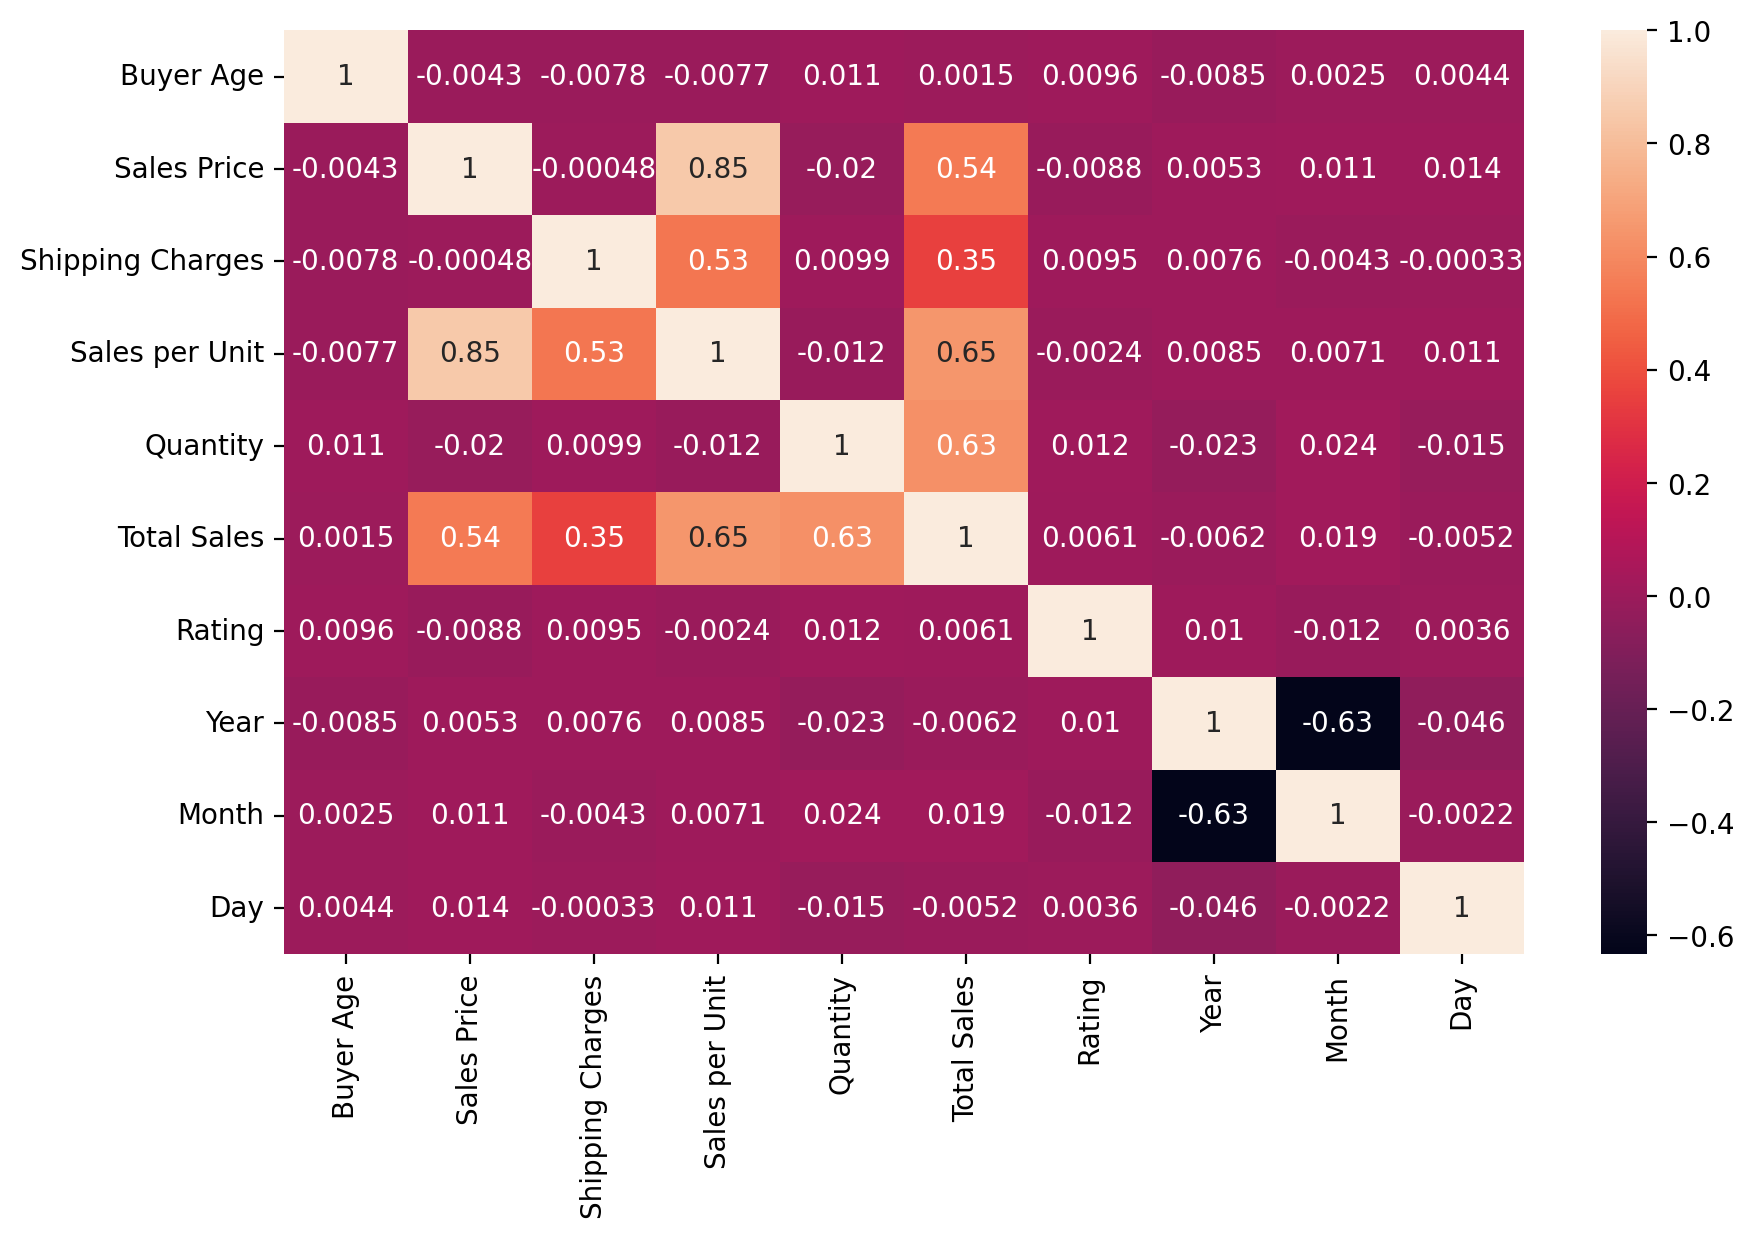

In [ ]:
# plot a heatmap
plt.figure(figsize=(10,6),dpi=200)
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

## Feature Engineering

**Feature Engineering** is a process of using **Domain Knowledge** to **Extract Data from Raw Data** via **Data Mining**(process of **discovering patterns and insights from large datasets**)

In [ ]:
# get all unique values from Product Category
df['Product Category'].unique()

array(['Clothing', 'Other', 'Ornaments'], dtype=object)

In [ ]:
# get all unique values from Buyer Gender
df['Buyer Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
# get all unique values from International Shipping
df['International Shipping'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# get all unique values from Order Location
df['Order Location'].unique()

array(['New Jersey', 'Las Vegas', 'Cardiff', 'Pittsburgh', 'Miami',
       'Sydney', 'Memphis', 'New York', 'Montreal', 'Sacramento', 'Paris',
       'San Antonio', 'Cleveland', 'London', 'Portland', 'Detroit',
       'Dublin', 'Glasgow', 'Austin', 'Toronto', 'Mumbai',
       'San Francisco', 'Manchester', 'Liverpool', 'New Delhi'],
      dtype=object)

In [ ]:
# get number of unique values from Order Location
df['Order Location'].nunique()

25

### Feature Encoding

**Feature encoding** is the process of **transforming categorical data into numerical representations** that machine learning models can understand and utilize effectively. This is crucial because most **machine learning algorithms work with numerical data** and **cannot directly handle categorical features.**

In [ ]:
# Load the library
from sklearn.preprocessing import LabelEncoder

In [ ]:
# create an instance for LabelEncoder()
encoder = LabelEncoder()

In [ ]:
# encode all categorical columns
df['Product Category'] = encoder.fit_transform(df['Product Category'])
df['Buyer Gender'] = encoder.fit_transform(df['Buyer Gender'])
df['International Shipping'] = encoder.fit_transform(df['International Shipping'])
df['Order Location'] = encoder.fit_transform(df['Order Location'])
df.head()

,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
0,0,1,30,15,0,100,0,100,1,100,4,2024,7,21
1,0,1,32,6,0,100,0,100,1,100,3,2024,7,20
2,2,0,26,1,1,9,40,49,1,49,2,2024,7,21
3,2,1,28,18,0,9,0,9,2,18,3,2024,8,19
4,2,0,19,11,0,10,0,10,3,30,5,2024,1,6


## Train Test Split

**Train-test split** is a technique used in machine learning to **divide a dataset into two subsets:** a **training set** and a **testing set**. The training set is used to **train the machine learning model**, while the testing set is used to **evaluate its performance on unseen data.**

In [ ]:
# Split the data as features and label
X = df.drop(['Total Sales'],axis=1)
y = df['Total Sales']

In [ ]:
# train test split
# load the library
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# get the number of rows and columns in X_train
X_train.shape

(5175, 13)

In [ ]:
# get the number of rows and columns in X_test
X_test.shape

(2219, 13)

In [ ]:
# get the number of rows and columns in y_train
y_train.shape

(5175,)

In [ ]:
# get the number of rows and columns in y_test
y_test.shape

(2219,)

### Validation

In [ ]:
# holdout
X_validation, X_holdout_test, y_validation, y_holdout_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
# get the number of rows and columns in X_validate
X_validation.shape

(1109, 13)

In [ ]:
# get the number of rows and columns in X_holdout_test
X_holdout_test.shape

(1110, 13)

In [ ]:
# get the number of rows and columns in X_validate
y_validation.shape

(1109,)

In [ ]:
# get the number of rows and columns in y_holdout_test
y_holdout_test.shape

(1110,)

## Feature Scaling

**Feature scaling** is a preprocessing technique used to **standardize the range of independent variables or features** of data.

In [ ]:
# load the library
from sklearn.preprocessing import StandardScaler
# create an Instance for StandardScaler
scaler = StandardScaler()
# scale the training data
scaled_X_train = scaler.fit_transform(X_train)
# transform the test data
scaled_X_test = scaler.transform(X_test)
# scale the validation data
scaled_X_validation = scaler.transform(X_validation)
# scale the holdout data
scaled_X_holdout_test = scaler.transform(X_holdout_test)

## Model Building

**Model building** is the **core of machine learning** where you **create a predictive or descriptive model using algorithms and data.** It involves **selecting an appropriate algorithm,** **training it on data, and evaluating its performance to achieve a desired outcome.**

### Linear Regression

**Linear regression** is a statistical method used to model the **relationship between a dependent variable and one or more independent variables** by f**itting a linear equation** to the **observed data.**

In [ ]:
# load the libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
lr_model = LinearRegression()
# fit the model
lr_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_lr = lr_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_lr = lr_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_lr)

0.8219250514643247

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_lr)

32.99900165622615

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_lr)

2228.415475586102

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_lr))

47.20609574605913

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_lr)

24.91091537967705

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_lr)

0.8219741136421055

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_lr)

0.8248057857948017

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_lr)

33.7068540025166

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_lr)

2445.940660501185

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_lr))

49.45645216249529

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_lr)

22.810003209487853

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_lr)

0.8248360474815222

### Random Forest

**Random Forest** is an **ensemble learning** method used for both **classification and regression** tasks. It works by **constructing multiple decision trees** during training and outputting the class that is the **mode of the classes (classification)** or **mean/average prediction (regression)** of the individual trees.

In [ ]:
# load the libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
rf_model = RandomForestRegressor()
# fit the model
rf_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_rf = rf_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_rf = rf_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_rf)

0.9995293248334597

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_rf)

0.32891794409377784

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_rf)

5.889990892696124

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_rf))

2.4269303436020007

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_rf)

0.0

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_rf)

0.9995300572315515

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_rf)

0.9989212098312722

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_rf)

0.39445945945945926

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_rf)

15.061323513513514

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_rf))

3.8808921027920262

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_rf)

0.0

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_rf)

0.9989215610722849

### Support Vector Machine

**Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used for both **classification and regression** tasks. It's particularly effective in **high-dimensional spaces** and is known for its ability to **create a clear separation between different classes by finding an optimal hyperplane.**

In [ ]:
# load the libraries
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
svr_model = SVR()
# fit the model
svr_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_svr = svr_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_svr = svr_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_svr)

0.6143539756966898

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_svr)

29.245597649791012

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_svr)

4825.943097120048

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_svr))

69.46900817717241

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_svr)

6.64979217644256

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_svr)

0.6553212641947523

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_svr)

0.6069633948294142

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_svr)

30.859767320828272

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_svr)

5487.305719617546

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_svr))

74.07635060947283

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_svr)

6.038038837584089

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_svr)

0.6491971732271338

### K-Nearest Neighbors

**K-Nearest Neighbors (KNN)** is a **supervised machine learning algorithm** used for both **classification and regression** tasks. **KNN** works based on the principle that **similar data points tend to be close to each other.**

In [ ]:
# load the libraries
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
knn_model = KNeighborsRegressor()
# fit the model
knn_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_knn = knn_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_knn = knn_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_knn)

0.8979985823128526

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_knn)

19.896663660955813

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_knn)

1276.4374752028857

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_knn))

35.727265151462205

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_knn)

9.0

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_knn)

0.9034638928014802

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_knn)

0.9035190536392255

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_knn)

19.92072072072072

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_knn)

1347.0003603603602

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_knn))

36.70150351634603

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_knn)

8.900000000000006

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_knn)

0.9084527618234475

### Decision Tree

A **Decision Tree** is a **supervised machine learning algorithm** used for both **classification and regression** tasks. It's a **tree-like model** where **each internal node represents a feature**, **each branch represents a decision rule**, and **each leaf node represents an outcome or prediction.**

In [ ]:
# load the libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
dt_model = DecisionTreeRegressor()
# fit the model
dt_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_dt = dt_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_dt = dt_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_dt)

0.9994556827522233

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_dt)

0.21280432822362488

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_dt)

6.811541929666366

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_dt))

2.609893087784702

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_dt)

0.0

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_dt)

0.9994574731921148

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_dt)

0.9993731711696884

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_dt)

0.1963963963963964

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_dt)

8.751351351351351

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_dt))

2.9582683028000267

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_dt)

0.0

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_dt)

0.9993732104680624

### Gradient Boosting

**Gradient Boosting** is a powerful **ensemble learning technique** used for both **classification and regression** tasks. It works by **sequentially building a series of weak learners** (typically decision trees) and **combining their predictions to create a strong learner**. Each subsequent **weak learner is trained to correct the errors of the previous learners, leading to improved accuracy over time.**

In [ ]:
# load the libraries
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
gb_model = GradientBoostingRegressor()
# fit the model
gb_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_gb = gb_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_gb = gb_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_gb)

0.9992829405126734

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_gb)

1.546933070958641

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_gb)

8.973224317143938

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_gb))

2.995534062090421

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_gb)

0.530402361495371

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_gb)

0.9992830427566549

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_gb)

0.9992592904658947

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_gb)

1.531993204438928

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_gb)

10.341275111786304

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_gb))

3.215785302501755

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_gb)

0.5473719001803659

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_gb)

0.9992631205872429

### Adaptive Boosting

**AdaBoosting (Adaptive Boosting)** is an **ensemble learning method** used for both **classification and regression** tasks. It works by **sequentially building a series of weak learners** (typically decision trees called "decision stumps") and **combining their predictions to create a strong learner.** AdaBoost focuses on improving the performance of the model by **giving more weight to misclassified data points in subsequent iterations.**

In [ ]:
# load the libraries
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
ada_model = AdaBoostRegressor()
# fit the model
ada_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_ada = ada_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_ada = ada_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_ada)

0.9219840682487924

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_ada)

28.64158126378035

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_ada)

976.2850478759556

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_ada))

31.245560450661717

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_ada)

31.457413249211356

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_ada)

0.9676559812452659

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_ada)

0.9267094712229961

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_ada)

29.037549781622733

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_ada)

1023.2317612689005

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_ada))

31.987994017582604

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_ada)

31.781553398058264

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_ada)

0.9659574757125471

### XGBoost

**XGBoost** stands for **Extreme Gradient Boosting.** It's a powerful and popular machine learning algorithm known for its high accuracy and efficiency in both classification and regression tasks. It's an implementation of gradient boosting that builds an **ensemble of decision trees sequentially, where each new tree tries to correct the errors of the previous ones.**

In [ ]:
# load the libraries
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
xgb_model = XGBRegressor()
# fit the model
xgb_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_xgb = xgb_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_xgb = xgb_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_xgb)

0.9998552203178406

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_xgb)

0.2692667245864868

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_xgb)

1.8119513988494873

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_xgb))

1.3460874410117225

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_xgb)

0.01824188232421875

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_xgb)

0.9998552660756336

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_xgb)

0.9995110630989075

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_xgb)

0.3069385886192322

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_xgb)

6.826263427734375

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_xgb))

2.6127118914519403

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_xgb)

0.01822376251220703

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_xgb)

0.9995113845928149

### Bagging Regressor

**Bagging Regressor** is an **ensemble learning method** that **aims to improve the accuracy and stability of regression models.** It works by creating **multiple subsets of the original training data** (through **bootstrapping**) and t**raining a base regressor** (like a **Decision Tree**) on each subset. The final prediction is then obtained by **averaging the predictions of all the individual regressors.**

In [ ]:
# load the libraries
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
bag_model = BaggingRegressor()
# fit the model
bag_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_bag = bag_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_bag = bag_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_bag)

0.9996744530341442

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_bag)

0.3242560865644727

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_bag)

4.073868349864745

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_bag))

2.018382607402458

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_bag)

0.0

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_bag)

0.99967485240438

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_bag)

0.9991025152049988

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_bag)

0.35828828828828846

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_bag)

12.530063063063068

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_bag))

3.53978291185534

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_bag)

0.0

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_bag)

0.9991027265843252

### Extra Tree Regressor

**Extra Trees Regressor**, short for Extremely Randomized Trees Regressor, is an ensemble learning method similar to Random Forest but with some key differences that make it even more randomized. It builds multiple decision trees and averages their predictions to make a final prediction, **just like Random Forest.** However, it introduces **extra randomness in the tree construction process.**

In [ ]:
# load the libraries
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score

In [ ]:
# create an Instance of the model
ext_model = ExtraTreesRegressor()
# fit the model
ext_model.fit(scaled_X_train, y_train)
# predict the scaled_X_validation
y_val_pred_ext = ext_model.predict(scaled_X_validation)
# predict the scaled_X_holdout_test
y_pred_ext = ext_model.predict(scaled_X_holdout_test)

#### Model Evaluation for Validation Data

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.** Here, I have used the **validation data** to **check the model performance.** if the model doesn't perform well we **tune the hyperparameters** to **make the model perform well.**

In [ ]:
# model evaluation for validation data using r2_score
r2_score(y_validation, y_val_pred_ext)

0.9998889601677525

In [ ]:
# model evaluation for validation data using mean_absolute_error
mean_absolute_error(y_validation, y_val_pred_ext)

0.12848512173128943

In [ ]:
# model evaluation for validation data using mean_squared_error
mean_squared_error(y_validation, y_val_pred_ext)

1.3895434625789005

In [ ]:
# model evaluation for validation data using root mean squared error
np.sqrt(mean_squared_error(y_validation, y_val_pred_ext))

1.178788981361338

In [ ]:
# model evaluation for validation data using median_absolute_error
median_absolute_error(y_validation, y_val_pred_ext)

0.0

In [ ]:
# model evaluation for validation data using explained_variance_score
explained_variance_score(y_validation, y_val_pred_ext)

0.9998890955697692

#### Model Evaluation

**Model evaluation** is the process of **assessing the performance** of a trained machine learning model. Model Evaluation is done on the **Test data or Unseen data.**

In [ ]:
# model evaluation using r2_score
r2_score(y_holdout_test, y_pred_ext)

0.9993954685759087

In [ ]:
# model evaluation using mean_absolute_error
mean_absolute_error(y_holdout_test, y_pred_ext)

0.195972972972973

In [ ]:
# model evaluation using mean_squared_error
mean_squared_error(y_holdout_test, y_pred_ext)

8.440050360360358

In [ ]:
# model evaluation using root mean squared error
np.sqrt(mean_squared_error(y_holdout_test, y_pred_ext))

2.9051764766293213

In [ ]:
# model evaluation using median_absolute_error
median_absolute_error(y_holdout_test, y_pred_ext)

0.0

In [ ]:
# model evaluation using explained_variance_score
explained_variance_score(y_holdout_test, y_pred_ext)

0.9993959592298796

## Final Model - Random Forest





### Load Necessary Libraries

In [ ]:
# load the libraries
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

### Read the CSV File

In [ ]:
# read a csv file
df = pd.read_csv('merch_sales.csv')
df.head()

,Order ID,Order Date,Product ID,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Review
0,189440,2024-07-21,BF1543,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,The delivery team handled the product with care.
1,187385,2024-07-20,BF1543,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,Had slight delays but the product was in good ...
2,181844,2024-07-21,BF1544,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,Waste of Money.
3,197934,2024-08-19,BF1544,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,Had slight delays but the product was in good ...
4,122470,2024-01-06,BF1545,Other,Female,19,Miami,No,10,0,10,3,30,5,Lack of delivery delays is greatly appreciated.


### Data Cleaning and Feature Encoding

In [ ]:
# drop all the unnecessary columns
df = df.drop(['Order ID','Product ID','Review'],axis=1)

In [ ]:
# extract the day,month and year from the Order_Date
df['Year'] = pd.DatetimeIndex(df['Order Date']).year
df['Month'] = pd.DatetimeIndex(df['Order Date']).month
df['Day'] = pd.DatetimeIndex(df['Order Date']).day

In [ ]:
# drop the Order_Date column
df = df.drop(['Order Date'],axis=1)
df.head()

,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
0,Clothing,Male,30,New Jersey,No,100,0,100,1,100,4,2024,7,21
1,Clothing,Male,32,Las Vegas,No,100,0,100,1,100,3,2024,7,20
2,Other,Female,26,Cardiff,Yes,9,40,49,1,49,2,2024,7,21
3,Other,Male,28,Pittsburgh,No,9,0,9,2,18,3,2024,8,19
4,Other,Female,19,Miami,No,10,0,10,3,30,5,2024,1,6


### Feature Encoding

In [ ]:
# Feature Encoding for Categorical Data
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# encode all categorical columns
df['Product Category'] = encoder.fit_transform(df['Product Category'])
df['Buyer Gender'] = encoder.fit_transform(df['Buyer Gender'])
df['International Shipping'] = encoder.fit_transform(df['International Shipping'])
df['Order Location'] = encoder.fit_transform(df['Order Location'])
df.head()

,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Total Sales,Rating,Year,Month,Day
0,0,1,30,15,0,100,0,100,1,100,4,2024,7,21
1,0,1,32,6,0,100,0,100,1,100,3,2024,7,20
2,2,0,26,1,1,9,40,49,1,49,2,2024,7,21
3,2,1,28,18,0,9,0,9,2,18,3,2024,8,19
4,2,0,19,11,0,10,0,10,3,30,5,2024,1,6


### Feature Vectors and Labels

In [ ]:
X = df.drop(['Total Sales'],axis=1)
y = df['Total Sales']

In [ ]:
X.head()

,Product Category,Buyer Gender,Buyer Age,Order Location,International Shipping,Sales Price,Shipping Charges,Sales per Unit,Quantity,Rating,Year,Month,Day
0,0,1,30,15,0,100,0,100,1,4,2024,7,21
1,0,1,32,6,0,100,0,100,1,3,2024,7,20
2,2,0,26,1,1,9,40,49,1,2,2024,7,21
3,2,1,28,18,0,9,0,9,2,3,2024,8,19
4,2,0,19,11,0,10,0,10,3,5,2024,1,6


In [ ]:
y.head()

,Total Sales
0,100
1,100
2,49
3,18
4,30


### Feature Scaling

In [ ]:
# load the library
from sklearn.preprocessing import StandardScaler
# create an Instance for StandardScaler
scaler = StandardScaler()
# scale the training data
scaled_X = scaler.fit_transform(X)

### Model Building - Random Forest

In [ ]:
# load the library
from sklearn.ensemble import RandomForestRegressor
# create an instance for the model
model = RandomForestRegressor()
# fitting the model
model.fit(scaled_X, y)

RandomForestRegressor()

## Model Deployment - Joblib

**Joblib** is a Python library designed for **efficient data (pickling)** and **machine learning model persistence.** **Joblib** is frequently used in machine learning **model deployment.**

In [ ]:
# load the library
import joblib

### Save the Model in a Pickle File

In [ ]:
# dumb the final model to joblib
joblib.dump(model,'final_model.pkl')

['final_model.pkl']

In [ ]:
# get all the columns as list
list(X.columns)

['Product Category',
 'Buyer Gender',
 'Buyer Age',
 'Order Location',
 'International Shipping',
 'Sales Price',
 'Shipping Charges',
 'Sales per Unit',
 'Quantity',
 'Rating',
 'Year',
 'Month',
 'Day']

### Save the Columns in a Pickle File

In [ ]:
# get all the columns as list and save them or dumb them in a pickle file (.pkl)
joblib.dump(list(X.columns),'column_names.pkl')

['column_names.pkl']

## Load the Model - Joblib

### Load the Model and Columns from the Pickle File

In [ ]:
# Load the Libraries
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the column names used during training
new_columns = joblib.load('column_names.pkl')

# Load the trained model
loaded_model = joblib.load('final_model.pkl')

# Assuming 'scaler' was saved within 'final_model.pkl' or separately
# If saved separately, load it using: scaler = joblib.load('scaler.pkl')


# Your input data
data = [[0, 1, 30, 15, 0, 100, 0, 100, 1, 100, 4, 2024, 7, 21]]

# Convert the input data into a pandas DataFrame with correct column names
input_df = pd.DataFrame(data, columns=new_columns + ['extra_column']) # adjust column if needed



# Remove extra features if present
input_df = input_df[new_columns] # adjust column if needed

# Now transform using the scaler
scaled_data = scaler.transform(input_df)

### Check the Columns from the Pickle File

In [ ]:
# check the columns from the pickle file
new_columns

['Product Category',
 'Buyer Gender',
 'Buyer Age',
 'Order Location',
 'International Shipping',
 'Sales Price',
 'Shipping Charges',
 'Sales per Unit',
 'Quantity',
 'Rating',
 'Year',
 'Month',
 'Day']

### Prediction using the Loaded Model

In [ ]:
# prediction using the loaded model
loaded_model.predict(scaled_data)

array([100.])

## Model Deployment - Streamlit

In [ ]:
import joblib

In [ ]:
new_columns = joblib.load('column_names.pkl')

In [ ]:
new_columns

['Product Category',
 'Buyer Gender',
 'Buyer Age',
 'Order Location',
 'International Shipping',
 'Sales Price',
 'Shipping Charges',
 'Sales per Unit',
 'Quantity',
 'Rating',
 'Year',
 'Month',
 'Day']

In [ ]:
# !pip install streamlit

In [ ]:
!pip install streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
%%writefile app_new.py
import pickle
import pandas as pd
import streamlit as st
import joblib

# Load the model using joblib
model = joblib.load('final_model.pkl')

# Load the column names
new_columns = joblib.load('column_names.pkl')

st.title('Sales Prediction')

def main():
  st.title('Sales Prediction')
  Product_Category = st.text_input('Product Category')
  Buyer_Gender = st.text_input('Buyer Gender')
  Buyer_Age = st.text_input('Buyer Age')
  Order_Location = st.text_input('Order Location')
  International_Shipping = st.text_input('International Shipping')
  Sales_Price = st.text_input('Sales Price')
  Shipping_Charges = st.text_input('Shipping Charges')
  Sales_per_Unit = st.text_input('Sales per Unit')
  Quantity = st.text_input('Quantity')
  Rating = st.text_input('Rating')
  Year = st.text_input('Year')
  Month = st.text_input('Month')
  Day = st.text_input('Day')

  if st.button('Predict'):
    # Assuming your model expects data in the same order as new_columns
    input_data = [Product_Category, Buyer_Gender, Buyer_Age,Order_Location,
                  International_Shipping, Sales_Price,Shipping_Charges,
                  Sales_per_Unit, Quantity, Rating,Year, Month, Day]

    # Create a DataFrame for prediction
    input_df = pd.DataFrame([input_data], columns=new_columns)

    prediction = model.predict(input_df)
    output = round(prediction[0], 2)
    st.success('The Sales is {}'.format(output))

if __name__ == '__main__':
  main()

Writing app_new.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.139.85.186


In [ ]:
!streamlit run app_new.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.139.85.186:8501

⠧⠇your url is: https://spotty-dryers-write.loca.lt
